# Análisis exploratorio orientado a TARGET

Notebook reorganizado por temas. El bloque inicial mantiene el análisis global (target, ranking, bivariado, multivariado y hallazgos). Después, cada variable se agrupa por familia: scores externos, demografía (edad y género), buró e historial, educación/ocupación/ingreso, y crédito/empleo/vivienda. El orden respeta las dependencias de funciones auxiliares (p. ej. `plot_age_normal` y `plot_score_normal` se definen antes de reutilizarse).

# Analisis exploratorio orientado a `TARGET` (default crediticio)

**Objetivo del notebook.** Entender los determinantes del incumplimiento de pago (`TARGET = 1`) sobre el dataset reducido de features seleccionadas, con foco explicito en el **desbalance de clases** (~8% default). No nos interesa el accuracy ni los promedios globales, sino *que perfiles concentran el riesgo* y *que variables y segmentos llevar al modelo*.

Cubre los puntos pedidos:
1. Distribucion general de `TARGET`.
2. Variables con mayor relacion con el default (ranking multi-metrica).
3. Patrones bivariados variable a variable.
4. Combinaciones multivariadas (perfiles de alto y bajo riesgo).
5. Visualizaciones.
6. Hallazgos interpretables para negocio.
7. Recomendaciones de variables y segmentos para el modelo.

> **Nota metodologica.** Con clases desbalanceadas la metrica de lectura no es la media global sino la **tasa de default por segmento** comparada contra la **tasa base** (prior). Usamos el concepto de *lift* = tasa del segmento / tasa base. Lift > 1 = segmento mas riesgoso que el promedio.

## Índice del EDA (orden del notebook)

Orden sugerido de lectura y ejecución. Las celdas de código van justo debajo de cada sección.

### Bloque inicial
1. **Carga de datos** — imports, rutas, `df`, tipado de columnas

### Análisis global del target y ranking
2. **1. Distribución de `TARGET`** — tasa base y desbalance
3. **2. Variables con mayor relación con el default** — ranking numérico y categórico
4. **3. Análisis bivariado**
   - 3.1 Numéricas: tasa de default por decil
   - 3.2 Categóricas: tasa de default por categoría
5. **4. Análisis multivariado: perfiles de riesgo**
   - 4.1 Árbol de segmentación
   - 4.2 Score externo × educación
   - 4.3 Perfiles extremos (alto / bajo riesgo)
6. **5–6. Hallazgos para negocio**
7. **7. Recomendaciones para el modelo**

### Distribuciones y riesgo por variable numérica
8. **Edad (`AGE_YEARS`)** — histogramas normal, default vs al día
9. **`EXT_SOURCE_1`** — distribución, rangos 0.1, default, detalle 0.50–0.60
10. **`EXT_SOURCE_2`** — idem
11. **`EXT_SOURCE_3`** — idem
12. **`EXT_SOURCE_MEAN`** — idem
13. **`bureau_avg_days_credit`** — histogramas y deciles
14. **`bureau_avg_days_update`** — histogramas y deciles
15. **`DAYS_ID_PUBLISH`** — histogramas y deciles
16. **`REGION_RATING_CLIENT_W_CITY`** — por nivel 1 / 2 / 3
17. **Boxplots TARGET 0 vs 1** — comparación y outliers (IQR) de variables continuas estudiadas

### Edad, género y demografía
18. Default y al día **por rango de edad** (5 en 5)
19. **Edad por género** (`CODE_GENDER`)
20. **Tasa vs participación en defaults por edad**
21. **Género** — tasas, edad × género, conteos por rango

### Crédito, buró e ingresos
22. **Ratio crédito / ingreso** (`CREDIT_INCOME_RATIO`)
23. **Sin historial de buró** (`no_bureau_history`)
24. **Créditos activos** (`bureau_n_active`, 0–10)
25. **Monto total en buró** (`bureau_total_credit`)
26. **`prev_refused_rate`** y matriz con solicitudes previas
27. **`bureau_pct_paid_early`**

### Educación, ocupación e ingreso
28. **Educación** (`NAME_EDUCATION_TYPE`) — tasas, matriz edad × educación, `Academic degree`
29. **Ocupación e ingreso** — distribución y tasa de default

### Cuota, empleo y vivienda
30. **Cuota del crédito** (`AMT_ANNUITY`)
31. **Cantidad de hijos** (`CNT_CHILDREN`)
32. **Años empleados** (`YEARS_EMPLOYED`)
33. **Tipo de organización** (`ORGANIZATION_TYPE`)
34. **Propiedad inmobiliaria** (`FLAG_OWN_REALTY`)



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier, export_text

mpl.rcParams.update({
    'figure.dpi': 110, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titleweight': 'bold', 'figure.facecolor': 'white', 'axes.facecolor': 'white'
})
INK, BASE, RISK, SAFE, ACCENT = '#1e293b', '#94a3b8', '#dc2626', '#0ea5e9', '#f59e0b'

from pathlib import Path


def find_joined_dataset(start: Path = None) -> Path:
    """Localiza data/trusted/joined_df.parquet desde el cwd o carpetas padre."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    checked: list[Path] = []
    for base in [start, *start.parents]:
        candidates = [
            base / 'data' / 'trusted' / 'train_selected_features.parquet',
            base / 'Proyecto_Integrador' / 'data' / 'trusted' / 'train_selected_features.parquet',
        ]
        for path in candidates:
            checked.append(path)
            if path.exists():
                return path
    checked_txt = '\n  - '.join(str(p) for p in checked)
    raise FileNotFoundError(
        f'No se encontró joined_df.parquet. Rutas revisadas:\n  - {checked_txt}'
    )


DATA_PATH = find_joined_dataset()
df = pd.read_parquet(DATA_PATH)
print('Archivo cargado:', DATA_PATH.resolve())
print('Shape:', df.shape)
df.head()

Archivo cargado: C:\Users\camil\Music\PI\Proyecto_Integrador\data\trusted\train_selected_features.parquet
Shape: (307511, 92)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_INCOME_TYPE,...,prev_credit_application_ratio_mean,prev_goods_price_mean,prev_goods_price_max,prev_cnt_payment_mean,prev_reject_hc_rate,prev_reject_limit_rate,prev_reject_sco_rate,prev_yield_high_rate,prev_yield_low_rate,no_previous_application_history
0,100002,1,Cash loans,M,N,0,202500.0,24700.5,351000.0,Working,...,1.000000,179055.000,179055.0,24.000000,0.0,0.0,0.0,0.000000,1.000000,0
1,100003,0,Cash loans,F,N,0,270000.0,35698.5,1129500.0,State servant,...,1.057664,435436.500,900000.0,10.000000,0.0,0.0,0.0,0.000000,0.333333,0
2,100004,0,Revolving loans,M,Y,0,67500.0,6750.0,135000.0,Working,...,0.828021,24282.000,24282.0,4.000000,0.0,0.0,0.0,0.000000,0.000000,0
3,100006,0,Cash loans,F,N,0,135000.0,29686.5,297000.0,Working,...,0.951861,408304.875,688500.0,27.600000,0.0,1.0,0.0,0.222222,0.222222,0
4,100007,0,Cash loans,M,N,0,121500.0,21865.5,513000.0,Working,...,1.046356,150530.250,247500.0,20.666666,0.0,0.0,0.0,0.500000,0.000000,0


In [3]:
# Tipado de columnas
DROP = ['TARGET', 'SK_ID_CURR']
num_cols = [c for c in df.columns if c not in DROP and df[c].dtype != 'object' and str(df[c].dtype) != 'str']
cat_cols = [c for c in df.columns if c not in DROP and (df[c].dtype == 'object' or str(df[c].dtype) == 'str')]
print(f'Numericas: {len(num_cols)} | Categoricas: {len(cat_cols)}')
print('Nulos totales:', int(df.isna().sum().sum()))

Numericas: 81 | Categoricas: 9
Nulos totales: 0


## 1. Distribucion de `TARGET`

Establecemos la tasa base de default (prior). Todo el analisis posterior se lee *contra* este numero.

TARGET=0 (no default): 282,686 (91.93%)
TARGET=1 (default)   : 24,825 (8.07%)
Desbalance: 11.4 : 1   |   tasa base = 0.0807


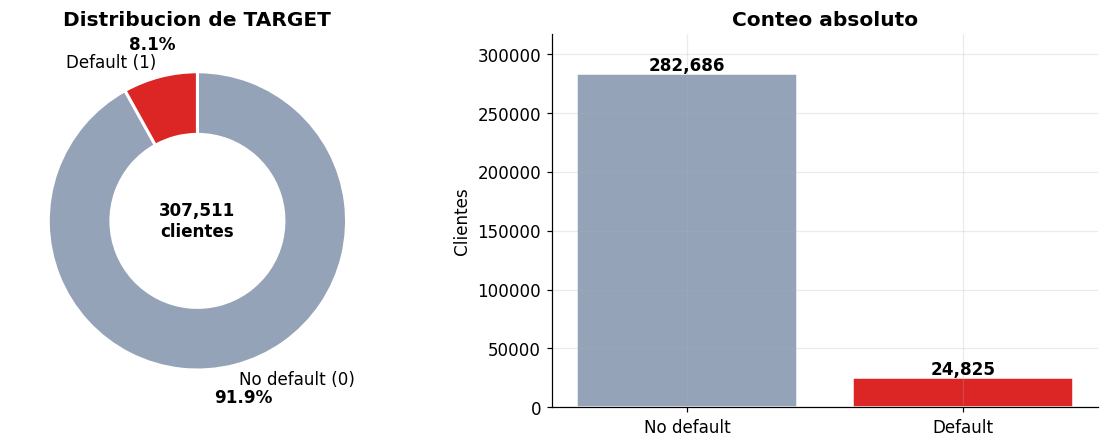

In [3]:
base = df['TARGET'].mean()
vc = df['TARGET'].value_counts().sort_index()
print(f'TARGET=0 (no default): {vc[0]:,} ({(1-base)*100:.2f}%)')
print(f'TARGET=1 (default)   : {vc[1]:,} ({base*100:.2f}%)')
print(f'Desbalance: {vc[0]/vc[1]:.1f} : 1   |   tasa base = {base:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
w, _, at = ax[0].pie(vc, labels=['No default (0)', 'Default (1)'], colors=[BASE, RISK],
    autopct=lambda p: f'{p:.1f}%', startangle=90, counterclock=False, pctdistance=1.22,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
for t in at: t.set_fontweight('bold')
ax[0].text(0, 0, f'{len(df):,}\nclientes', ha='center', va='center', fontweight='bold')
ax[0].set_title('Distribucion de TARGET')
b = ax[1].bar(['No default', 'Default'], vc.values, color=[BASE, RISK], edgecolor='white')
for r, v in zip(b, vc.values): ax[1].text(r.get_x()+r.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')
ax[1].set_title('Conteo absoluto'); ax[1].set_ylabel('Clientes'); ax[1].set_ylim(0, vc.max()*1.12)
plt.tight_layout(); plt.show()

## 2. Variables con mayor relacion con el default

No nos casamos con una sola metrica. Para **numericas** combinamos tres lentes complementarias:
- **Correlacion punto-biserial** (Pearson con target binario): direccion y fuerza lineal.
- **AUC univariada**: poder discriminante de la variable sola, robusto al desbalance e invariante a monotonias.
- **Informacion mutua**: dependencia no lineal.

Para **categoricas** usamos **V de Cramer** (asociacion) y el **rango de tasa de default** entre categorias.

In [4]:
# ---- Numericas ----
rows = []
for c in num_cols:
    x = df[c].values.astype(float)
    r = np.corrcoef(x, df['TARGET'])[0, 1]
    auc = roc_auc_score(df['TARGET'], x)
    rows.append((c, r, max(auc, 1-auc)))
num_rank = pd.DataFrame(rows, columns=['feature', 'pointbiserial_r', 'univ_auc'])

samp = df.sample(min(60000, len(df)), random_state=42)
mi = mutual_info_classif(samp[num_cols].fillna(samp[num_cols].median()), samp['TARGET'], random_state=42)
num_rank['mutual_info'] = num_rank['feature'].map(dict(zip(num_cols, mi)))
num_rank = num_rank.sort_values('univ_auc', ascending=False).reset_index(drop=True)
num_rank.head(20)

,feature,pointbiserial_r,univ_auc,mutual_info
0,EXT_SOURCE_MEAN,-0.220840,0.717037,0.023893
1,EXT_SOURCE_MIN,-0.192750,0.690803,0.020915
2,EXT_SOURCE_2,-0.160295,0.655914,0.014138
3,EXT_SOURCE_3,-0.155892,0.649330,0.012274
4,bureau_avg_days_credit,0.083961,0.592476,0.006493
5,AGE_YEARS,-0.078239,0.583003,0.002282
6,EXT_SOURCE_1,-0.098887,0.581976,0.008050
7,bureau_closed_pct,-0.076501,0.581582,0.004791
8,DAYS_EMPLOYED,0.063368,0.579283,0.004532
9,CREDIT_GOODS_RATIO,0.068474,0.569071,0.005845


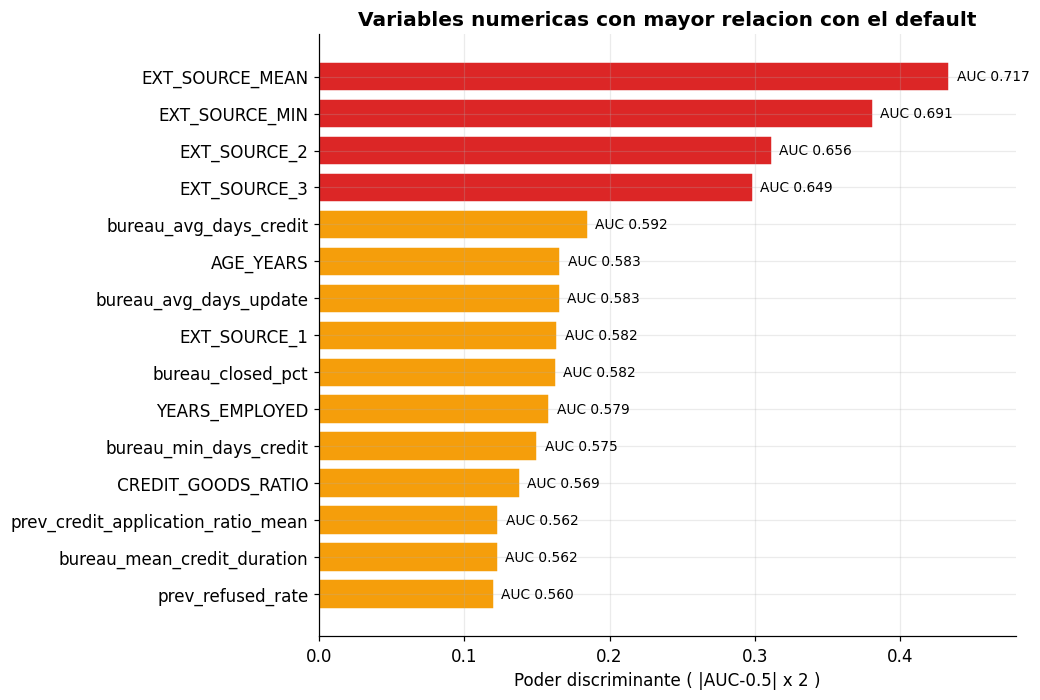

In [5]:
# Visual del ranking numerico
top = num_rank.head(15)
colors = [RISK if v > 0.60 else (ACCENT if v > 0.56 else BASE) for v in top['univ_auc']]
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.barh(top['feature'][::-1], (top['univ_auc']-0.5)[::-1]*2, color=colors[::-1], edgecolor='white')
for i, v in enumerate(top['univ_auc'][::-1]):
    ax.text((v-0.5)*2 + 0.005, i, f'AUC {v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Poder discriminante ( |AUC-0.5| x 2 )'); ax.set_xlim(0, 0.48)
ax.set_title('Variables numericas con mayor relacion con el default')
plt.tight_layout(); plt.show()

In [6]:
# ---- Categoricas: V de Cramer ----
def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2 = stats.chi2_contingency(ct)[0]; n = ct.sum().sum()
    phi2 = chi2/n; r, k = ct.shape
    phi2c = max(0, phi2 - (k-1)*(r-1)/(n-1))
    rc, kc = r-(r-1)**2/(n-1), k-(k-1)**2/(n-1)
    return np.sqrt(phi2c/min(kc-1, rc-1))

rows = []
for c in cat_cols:
    g = df.groupby(c)['TARGET'].agg(['mean', 'count'])
    g = g[g['count'] >= 200]
    rows.append((c, cramers_v(df[c], df['TARGET']), g['mean'].max()-g['mean'].min()))
cat_rank = pd.DataFrame(rows, columns=['feature', 'cramers_v', 'rate_spread']).sort_values('cramers_v', ascending=False)
cat_rank

,feature,cramers_v,rate_spread
8,OCCUPATION_TYPE,0.079776,0.123221
10,ORGANIZATION_TYPE,0.071048,0.119600
4,NAME_INCOME_TYPE,0.063667,0.042021
5,NAME_EDUCATION_TYPE,0.057458,0.055726
0,CODE_GENDER,0.054661,0.031426
13,WALLSMATERIAL_MODE,0.043878,0.049761
14,EMERGENCYSTATE_MODE,0.042136,0.026141
12,HOUSETYPE_MODE,0.040581,0.031967
6,NAME_FAMILY_STATUS,0.040311,0.041204
7,NAME_HOUSING_TYPE,0.036761,0.057406


### 3.2 Categoricas: tasa de default por categoria
Linea punteada = tasa base. Rojo = por encima del promedio (mas riesgo).

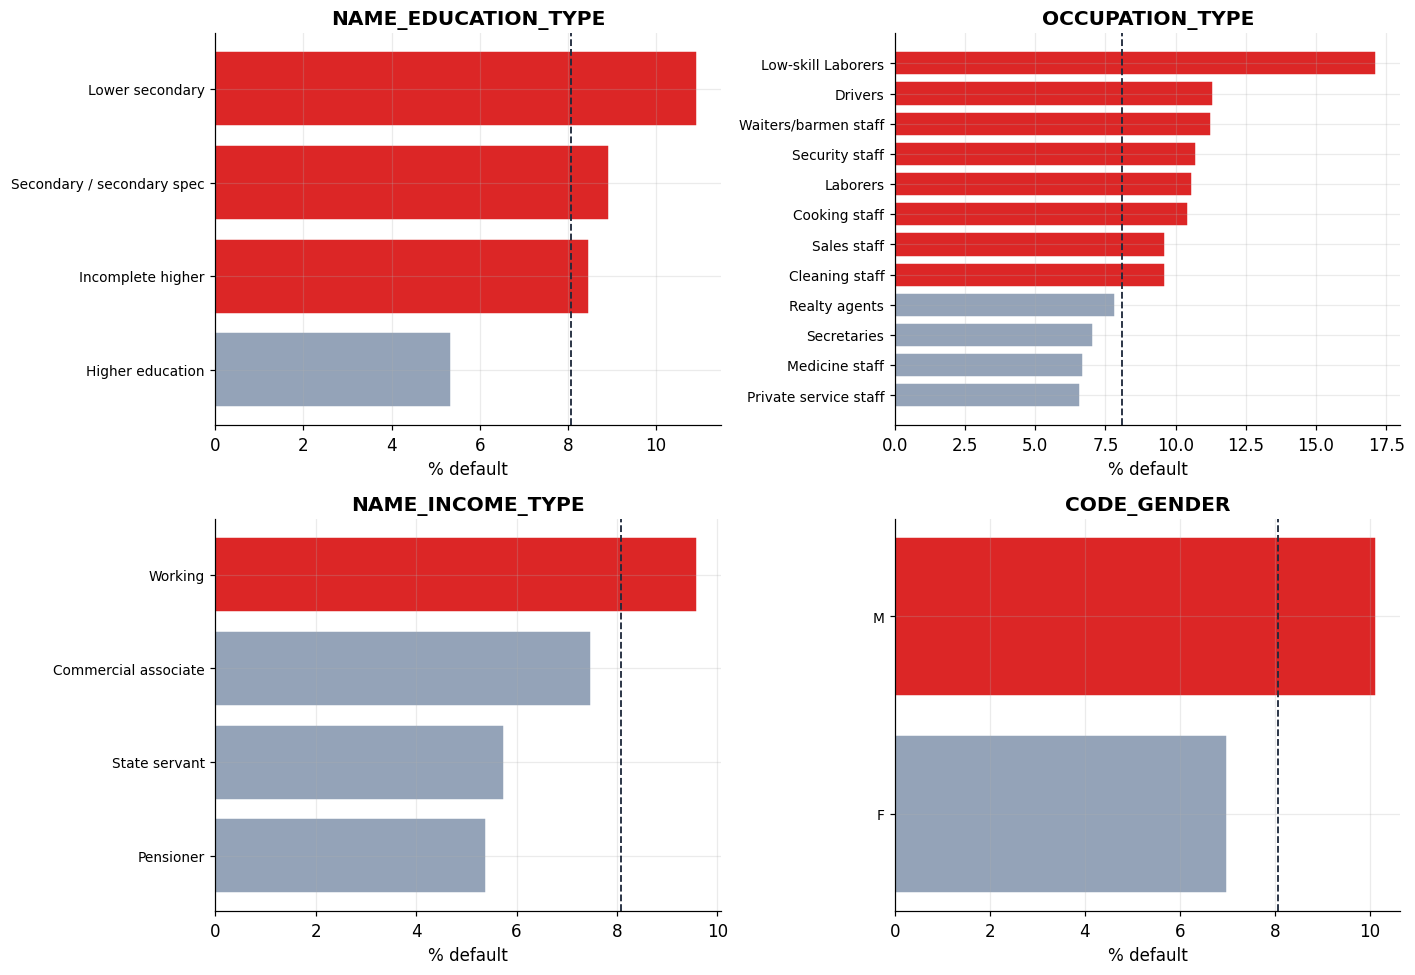

In [8]:
def plot_cat(col, minc=200, top=None, ax=None):
    g = df.groupby(col)['TARGET'].agg(['mean', 'count'])
    g = g[g['count'] >= minc].sort_values('mean')
    if top: g = g.tail(top)
    if ax is None: fig, ax = plt.subplots(figsize=(8, 0.4*len(g)+1))
    cols = [RISK if v > base else BASE for v in g['mean']]
    ax.barh(range(len(g)), g['mean']*100, color=cols, edgecolor='white')
    ax.set_yticks(range(len(g))); ax.set_yticklabels([str(i)[:26] for i in g.index], fontsize=9)
    ax.axvline(base*100, color=INK, ls='--', lw=1.2); ax.set_title(col); ax.set_xlabel('% default')
    return g

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_cat('NAME_EDUCATION_TYPE', ax=axes[0, 0])
plot_cat('OCCUPATION_TYPE', top=12, ax=axes[0, 1])
plot_cat('NAME_INCOME_TYPE', ax=axes[1, 0])
plot_cat('CODE_GENDER', minc=50, ax=axes[1, 1])
plt.tight_layout(); plt.show()

## 4. Analisis multivariado: perfiles de riesgo

### 4.1 Segmentacion automatica con un arbol poco profundo
Un arbol de decision de profundidad limitada (con `class_weight='balanced'` por el desbalance) descubre los cortes que mas separan el riesgo. Lo usamos como *generador de segmentos interpretables*, no como modelo final.

In [9]:
feat = ['EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'AGE_YEARS', 'YEARS_EMPLOYED', 'CREDIT_GOODS_RATIO', 'bureau_avg_days_credit']
X = df[feat].fillna(df[feat].median())
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=3000, class_weight='balanced', random_state=42).fit(X, df['TARGET'])
leaf = tree.apply(X)
seg = pd.DataFrame({'leaf': leaf, 'y': df['TARGET']}).groupby('leaf')['y'].agg(['mean', 'count']).sort_values('mean', ascending=False)
seg['lift'] = seg['mean']/base
print(seg.to_string(float_format=lambda x: f'{x:.4f}'))
print('\n', export_text(tree, feature_names=feat, max_depth=3))

       mean  count   lift
leaf                     
3    0.2599  18137 3.2196
4    0.1656  29047 2.0512
7    0.1284  25595 1.5903
6    0.0893  41334 1.1058
11   0.0720  41770 0.8920
10   0.0488  59874 0.6047
13   0.0326  48383 0.4035
14   0.0189  43371 0.2336

 |--- EXT_SOURCE_MEAN <= 0.48
|   |--- EXT_SOURCE_MEAN <= 0.40
|   |   |--- EXT_SOURCE_MEAN <= 0.33
|   |   |   |--- class: 1
|   |   |--- EXT_SOURCE_MEAN >  0.33
|   |   |   |--- class: 1
|   |--- EXT_SOURCE_MEAN >  0.40
|   |   |--- CREDIT_GOODS_RATIO <= 1.16
|   |   |   |--- class: 1
|   |   |--- CREDIT_GOODS_RATIO >  1.16
|   |   |   |--- class: 1
|--- EXT_SOURCE_MEAN >  0.48
|   |--- EXT_SOURCE_MEAN <= 0.57
|   |   |--- CREDIT_GOODS_RATIO <= 1.14
|   |   |   |--- class: 0
|   |   |--- CREDIT_GOODS_RATIO >  1.14
|   |   |   |--- class: 0
|   |--- EXT_SOURCE_MEAN >  0.57
|   |   |--- EXT_SOURCE_MEAN <= 0.62
|   |   |   |--- class: 0
|   |   |--- EXT_SOURCE_MEAN >  0.62
|   |   |   |--- class: 0



### 4.2 Interaccion Score externo x Educacion
El score externo domina, pero la educacion (y el genero) siguen separando *dentro* de cada banda de score: el efecto es aditivo.

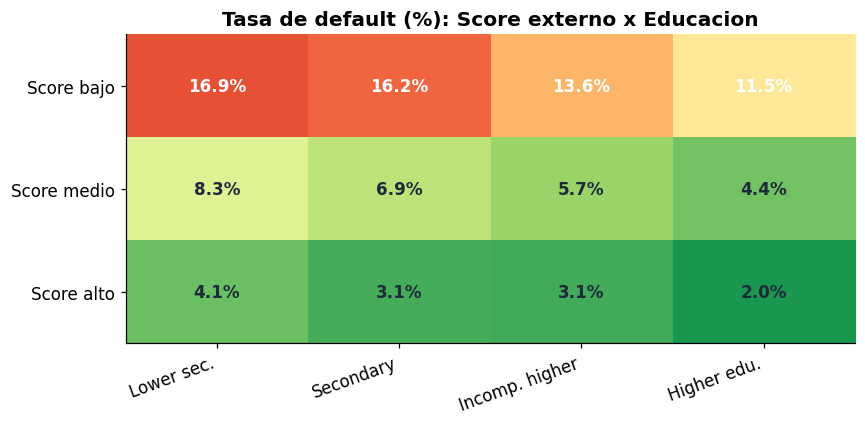

In [10]:
df['EXT_T'] = pd.qcut(df['EXT_SOURCE_MEAN'], 3, labels=['Score bajo', 'Score medio', 'Score alto'])
order = ['Lower secondary', 'Secondary / secondary special', 'Incomplete higher', 'Higher education']
p = df[df.NAME_EDUCATION_TYPE.isin(order)].pivot_table(index='EXT_T', columns='NAME_EDUCATION_TYPE', values='TARGET', aggfunc='mean')[order]*100

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(p.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=20)
ax.set_xticks(range(len(order))); ax.set_xticklabels(['Lower sec.', 'Secondary', 'Incomp. higher', 'Higher edu.'], rotation=20, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(p.index)
for i in range(p.shape[0]):
    for j in range(p.shape[1]):
        ax.text(j, i, f'{p.values[i,j]:.1f}%', ha='center', va='center', fontweight='bold',
                color='white' if p.values[i, j] > 11 else INK)
ax.set_title('Tasa de default (%): Score externo x Educacion'); ax.grid(False)
plt.tight_layout(); plt.show()

### 4.3 Perfiles combinados extremos
Cruzando las senales mas fuertes construimos un segmento de muy alto y otro de muy bajo riesgo.

In [11]:
hr = df[(df.EXT_SOURCE_MEAN < df.EXT_SOURCE_MEAN.quantile(.33)) & (df.AGE_YEARS < 35) &
        (df.CODE_GENDER == 'M') & (df.NAME_EDUCATION_TYPE.isin(['Lower secondary', 'Secondary / secondary special']))]
lr = df[(df.EXT_SOURCE_MEAN > df.EXT_SOURCE_MEAN.quantile(.66)) & (df.AGE_YEARS > 45) &
        (df.NAME_EDUCATION_TYPE == 'Higher education')]
print(f'ALTO RIESGO (score bajo + <35a + hombre + edu<=secundaria): n={len(hr):,}  default={hr.TARGET.mean()*100:.1f}%  lift={hr.TARGET.mean()/base:.2f}x')
print(f'BAJO RIESGO (score alto + >45a + edu superior)            : n={len(lr):,}  default={lr.TARGET.mean()*100:.1f}%  lift={lr.TARGET.mean()/base:.2f}x')

ALTO RIESGO (score bajo + <35a + hombre + edu<=secundaria): n=13,846  default=18.9%  lift=2.34x
BAJO RIESGO (score alto + >45a + edu superior)            : n=14,551  default=2.2%  lift=0.28x


## 5-6. Hallazgos para negocio

1. **El riesgo esta muy concentrado.** Con base 8.07%, el decil mas bajo de score externo concentra ~22.6% de default y el mas alto ~1.7%: una diferencia de **13x** explicada por una sola familia de variables.
2. **El score externo (`EXT_SOURCE_*`) es el termometro principal.** `EXT_SOURCE_MEAN` (promedio de las tres fuentes) y `EXT_SOURCE_MIN` son las variables individuales mas potentes (AUC univariada 0.72 y 0.69). Tienen relacion monotona y limpia con el default.
3. **El perfil socio-laboral aporta senal real y accionable:** trabajo manual / baja calificacion (Low-skill Laborers 17%, Drivers 11%), educacion baja (Lower secondary 11% vs Higher education 5%), ser hombre (10% vs 7% mujeres) y ser mas joven elevan el riesgo de forma consistente.
4. **El comportamiento de credito historico importa:** mayor ratio credito/valor del bien (sobre-apalancamiento), buro de credito reciente y cambio reciente de telefono se asocian a mayor default.
5. **Los efectos son aditivos:** combinando senales se llega a segmentos de 18.9% (alto riesgo) vs 2.2% (bajo riesgo), una separacion de **8.6x** con reglas simples y explicables.

## 7. Recomendaciones para el modelo

- **Nucleo predictivo obligatorio:** `EXT_SOURCE_MEAN`, `EXT_SOURCE_MIN`, `EXT_SOURCE_2`, `EXT_SOURCE_3`. Cuidar que la imputacion de estos campos no destruya senal (idealmente flag de "score faltante").
- **Segundo anillo:** `AGE_YEARS`, `YEARS_EMPLOYED`, `CREDIT_GOODS_RATIO`, `bureau_avg_days_credit`, `bureau_closed_pct`, `prev_refused_rate`, `DAYS_LAST_PHONE_CHANGE`.
- **Categoricas de alto valor:** `OCCUPATION_TYPE`, `ORGANIZATION_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_INCOME_TYPE`, `CODE_GENDER`. Para modelos lineales usar target/WoE encoding; para arboles/boosting bastan como categoricas.
- **Desbalance:** no optimizar accuracy. Usar **ROC-AUC y PR-AUC** como metricas, `class_weight='balanced'` o `scale_pos_weight ~ 11.4` en boosting, y validacion **estratificada**.
- **Variables a vigilar / candidatas a poda:** las de baja senal (`FLAG_OWN_REALTY`, `WEEKDAY_APPR_PROCESS_START`, gran parte de las de area del edificio) pueden quedar como ruido; confirmar con importancia del modelo.
- **Feature engineering sugerido:** interacciones explicitas score x educacion y score x edad, y una variable de "sobre-apalancamiento" (`CREDIT_GOODS_RATIO > 1.2`), que mostraron lift claro.

# Scores externos (EXT_SOURCE)

Las variables de scoring externo son las más predictivas. La primera celda de `EXT_SOURCE_1` define `plot_score_normal`, reutilizada en el resto de scores y en varias variables numéricas posteriores.

## Distribución del score externo 1 (`EXT_SOURCE_1`)

En Home Credit el **score 1** corresponde a la variable `EXT_SOURCE_1` (primera fuente de scoring externo). Valores típicos entre 0 y 1: **más alto = mejor perfil crediticio**.

Se muestran histogramas con **curva normal ajustada** (media y desviación del grupo), igual que en el análisis de edad:

1. Todos los clientes.
2. Clientes en default (`TARGET = 1`).
3. Clientes al día (`TARGET = 0`).

EXT_SOURCE_1: nulos = 0 (0.00%)


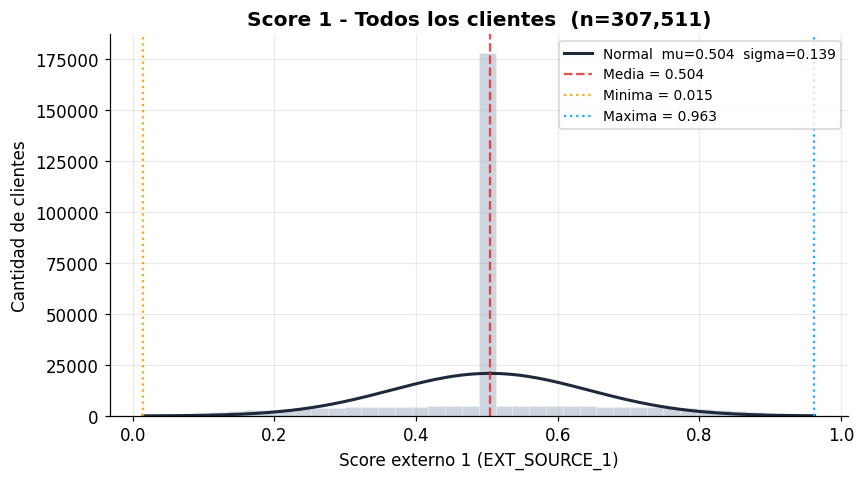

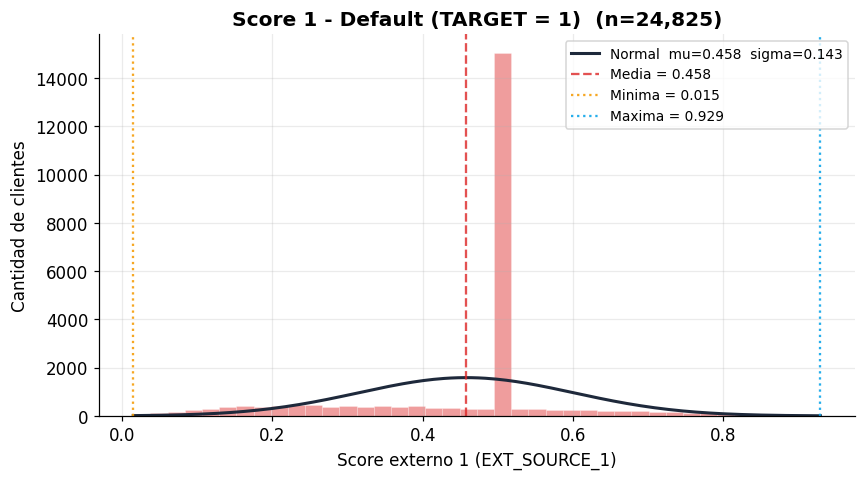

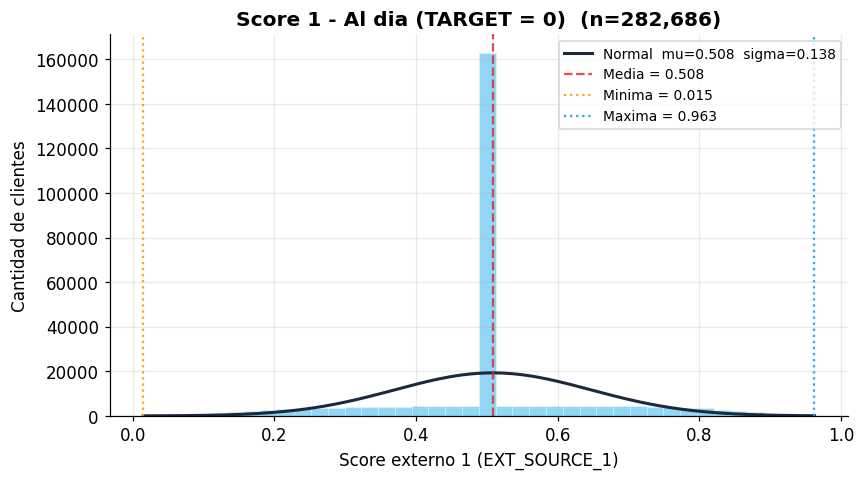


Resumen de score 1 por grupo:
               minima  media    maxima   desv         n
grupo                                                  
Al dia (0)   0.015000  0.508  0.963000  0.138  282686.0
Default (1)  0.015000  0.458  0.929000  0.143   24825.0
Todos        0.014568  0.504  0.962693  0.139  307511.0


In [5]:
SCORE_COL = 'EXT_SOURCE_1'

if SCORE_COL not in df.columns:
    raise KeyError(f'La columna {SCORE_COL} no está en el dataset cargado.')

def plot_score_normal(serie, titulo, color, bins=40, xlabel='Score externo 1 (EXT_SOURCE_1)'):
    """Histograma con curva normal superpuesta."""
    datos = pd.to_numeric(serie, errors='coerce').dropna()
    if datos.empty:
        print(f'[AVISO] Sin datos para: {titulo}')
        return

    media, desv = datos.mean(), datos.std()
    if desv == 0 or pd.isna(desv):
        desv = 1e-6

    fig, ax = plt.subplots(figsize=(8, 4.5))
    counts, edges, _ = ax.hist(
        datos, bins=bins, color=color, alpha=0.45, edgecolor='white', linewidth=0.4
    )

    ancho_bin = edges[1] - edges[0]
    x = np.linspace(datos.min(), datos.max(), 200)
    curva = stats.norm.pdf(x, media, desv) * len(datos) * ancho_bin
    ax.plot(x, curva, color=INK, linewidth=2,
            label=f'Normal  mu={media:.3f}  sigma={desv:.3f}')

    ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, alpha=0.8,
               label=f'Media = {media:.3f}')
    ax.axvline(datos.min(), color=ACCENT, linestyle=':', linewidth=1.5, alpha=0.9,
               label=f'Minima = {datos.min():.3f}')
    ax.axvline(datos.max(), color=SAFE, linestyle=':', linewidth=1.5, alpha=0.9,
               label=f'Maxima = {datos.max():.3f}')

    ax.set_title(f'{titulo}  (n={len(datos):,})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Cantidad de clientes')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

nulos_score = int(df[SCORE_COL].isna().sum())
print(f'{SCORE_COL}: nulos = {nulos_score:,} ({nulos_score / len(df) * 100:.2f}%)')

plot_score_normal(df[SCORE_COL], f'Score 1 - Todos los clientes', BASE)
plot_score_normal(df.loc[df['TARGET'] == 1, SCORE_COL], f'Score 1 - Default (TARGET = 1)', RISK)
plot_score_normal(df.loc[df['TARGET'] == 0, SCORE_COL], f'Score 1 - Al dia (TARGET = 0)', SAFE)

resumen_score = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[SCORE_COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(3)
)
resumen_score.loc['Todos'] = [
    df[SCORE_COL].min(), round(df[SCORE_COL].mean(), 3),
    df[SCORE_COL].max(), round(df[SCORE_COL].std(), 3), df[SCORE_COL].count(),
]

print('\nResumen de score 1 por grupo:')
print(resumen_score.to_string())

### Score 1 por rangos de 0.1

Distribución de clientes en intervalos `[0.0, 0.1)`, `[0.1, 0.2)`, …, `[0.9, 1.0]` sobre `EXT_SOURCE_1`.

Distribución de EXT_SOURCE_1 por rangos de 0.1 (n=307,511):
     rango  cantidad  porcentaje
[0.0, 0.1)      2096        0.68
[0.1, 0.2)      9565        3.11
[0.2, 0.3)     15798        5.14
[0.3, 0.4)     18744        6.10
[0.4, 0.5)     19676        6.40
[0.5, 0.6)    193404       62.89
[0.6, 0.7)     19464        6.33
[0.7, 0.8)     17522        5.70
[0.8, 0.9)     10435        3.39
[0.9, 1.0]       807        0.26

Total: 307,511


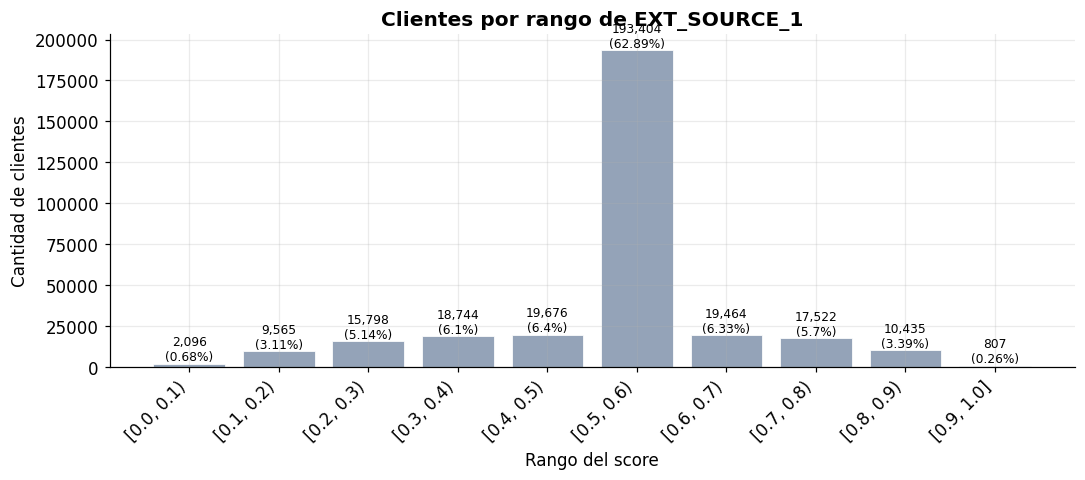

In [6]:
edges = np.arange(0, 1.1, 0.1)
labels = [f'[{edges[i]:.1f}, {edges[i + 1]:.1f})' for i in range(len(edges) - 1)]
labels[-1] = f'[{edges[-2]:.1f}, {edges[-1]:.1f}]'

score_vals = pd.to_numeric(df[SCORE_COL], errors='coerce').dropna()
counts, _ = np.histogram(score_vals, bins=edges)

dist_score_rangos = pd.DataFrame({
    'rango': labels,
    'cantidad': counts.astype(int),
})
dist_score_rangos['porcentaje'] = (
    dist_score_rangos['cantidad'] / len(score_vals) * 100
).round(2)
dist_score_rangos = dist_score_rangos.sort_values('rango')

print(f'Distribución de {SCORE_COL} por rangos de 0.1 (n={len(score_vals):,}):')
print(dist_score_rangos.to_string(index=False))
print(f"\nTotal: {dist_score_rangos['cantidad'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    dist_score_rangos['rango'],
    dist_score_rangos['cantidad'],
    color=BASE,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title(f'Clientes por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
for i, (cnt, pct) in enumerate(
    zip(dist_score_rangos['cantidad'], dist_score_rangos['porcentaje'])
):
    ax.text(
        i, cnt, f'{cnt:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=8,
    )
fig.tight_layout()
plt.show()

### Default por rango de `EXT_SOURCE_1`

Mismos intervalos de 0.1 que la distribución anterior. Tres lecturas complementarias:

- **Cantidad de defaults**: volumen absoluto de `TARGET = 1` en cada rango.
- **Tasa de default**: `defaults en el rango / clientes en el rango` (riesgo relativo).
- **Participación en defaults**: `defaults en el rango / total de defaults` (dónde se concentran los incumplimientos del portfolio).

Base de default global: 8.07%  |  Total defaults: 24,825

Resumen por rango de score 1:
     rango  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[0.0, 0.1)            2096               541             25.81                           2.18  3.20
[0.1, 0.2)            9565              1585             16.57                           6.38  2.05
[0.2, 0.3)           15798              1850             11.71                           7.45  1.45
[0.3, 0.4)           18744              1712              9.13                           6.90  1.13
[0.4, 0.5)           19676              1396              7.09                           5.62  0.88
[0.5, 0.6)          193404             15925              8.23                          64.15  1.02
[0.6, 0.7)           19464               937              4.81                           3.77  0.60
[0.7, 0.8)           17522               603              3.44                           2.43  0.43
[0.8, 0.9)  

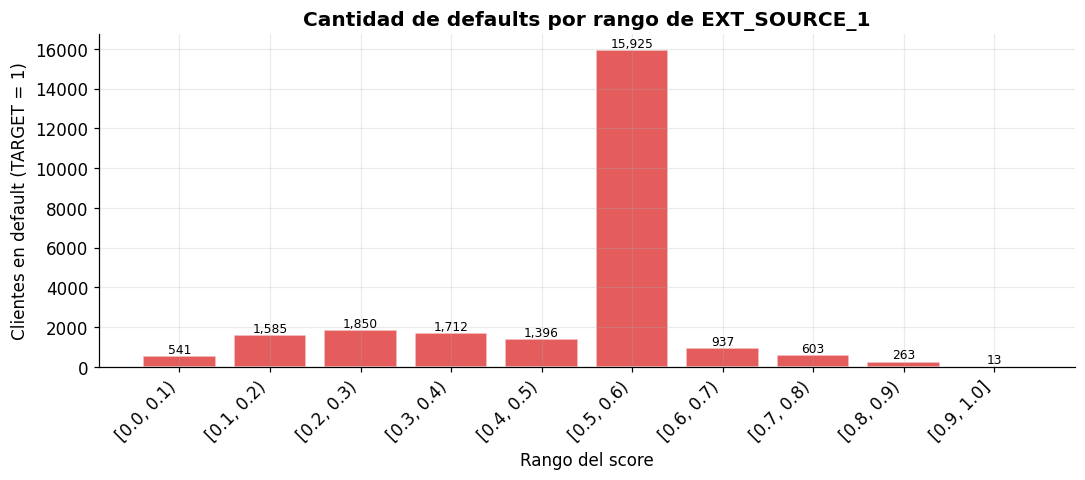

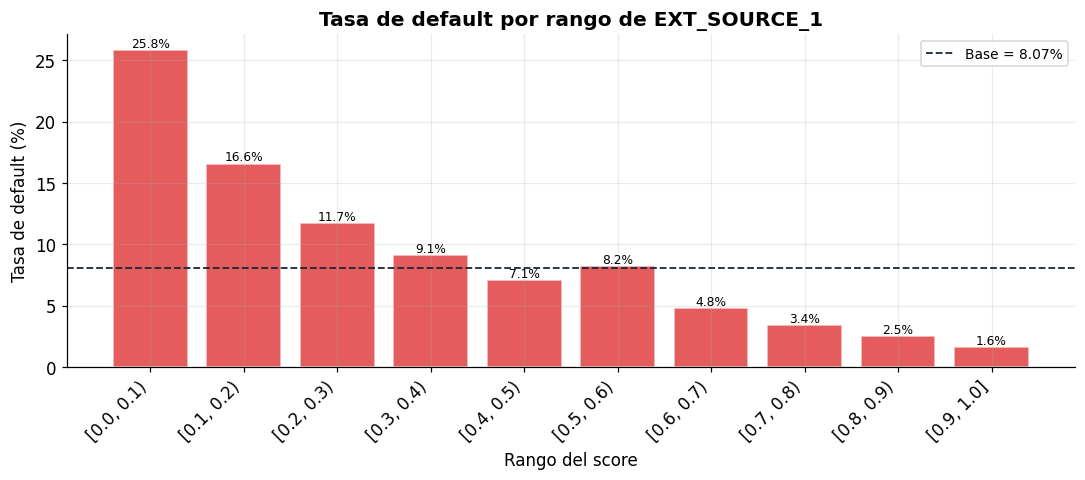

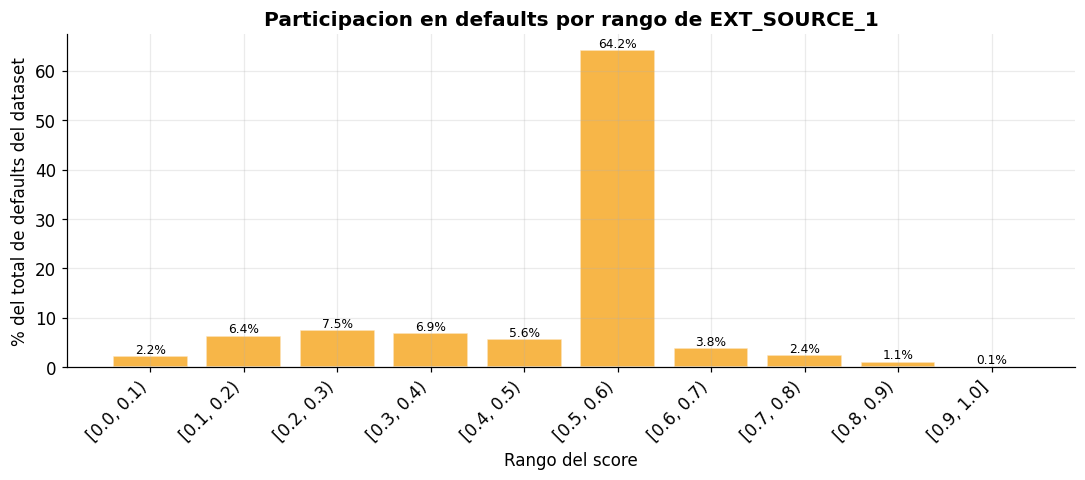


Interpretacion:
  Mayor tasa de default     : [0.0, 0.1) (25.81%, lift=3.20x)
  Mayor cantidad de defaults: [0.5, 0.6) (15,925 casos)
  Mayor participacion       : [0.5, 0.6) (64.15% del total de defaults)


In [7]:
score_df = df[[SCORE_COL, 'TARGET']].copy()
score_df[SCORE_COL] = pd.to_numeric(score_df[SCORE_COL], errors='coerce')
score_df = score_df.dropna(subset=[SCORE_COL])

score_df['rango_score'] = pd.cut(
    score_df[SCORE_COL],
    bins=edges,
    labels=labels,
    include_lowest=True,
    ordered=True,
)

total_defaults_score = int((score_df['TARGET'] == 1).sum())
base_default = score_df['TARGET'].mean()

resumen_score_default = (
    score_df.groupby('rango_score', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
    .reset_index()
    .rename(columns={'rango_score': 'rango'})
)
resumen_score_default['clientes_default'] = resumen_score_default['clientes_default'].astype(int)
resumen_score_default['tasa_default_pct'] = (
    resumen_score_default['clientes_default'] / resumen_score_default['total_clientes'] * 100
).round(2)
resumen_score_default['participacion_en_defaults_pct'] = (
    resumen_score_default['clientes_default'] / total_defaults_score * 100
).round(2)
resumen_score_default['lift'] = (
    resumen_score_default['tasa_default_pct'] / (base_default * 100)
).round(2)

print(f'Base de default global: {base_default * 100:.2f}%  |  Total defaults: {total_defaults_score:,}')
print('\nResumen por rango de score 1:')
print(resumen_score_default.to_string(index=False))

# Grafica 1: cantidad de defaults por rango
fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Cantidad de defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

# Grafica 2: tasa de default por rango
fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default * 100:.2f}%')
for b, v in zip(barras, resumen_score_default['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Tasa de default por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

# Grafica 3: participacion en el total de defaults
fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Participacion en defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

r_tasa = resumen_score_default.loc[resumen_score_default['tasa_default_pct'].idxmax()]
r_cant = resumen_score_default.loc[resumen_score_default['clientes_default'].idxmax()]
r_part = resumen_score_default.loc[resumen_score_default['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')

### Detalle de defaults entre 0.50 y 0.60 (`EXT_SOURCE_1`)

El rango `[0.5, 0.6)` concentra la mayoría de clientes y de defaults. Aquí se parte en **intervalos de 0.01** (`[0.50, 0.51)`, `[0.51, 0.52)`, …, `[0.59, 0.60]`) y se cuenta solo `TARGET = 1`.

Segmento EXT_SOURCE_1 en [0.50, 0.60]: 193,404 clientes | 15,925 defaults

Cantidad de defaults por centésima:
       rango  clientes_default  participacion_pct
[0.50, 0.51)             14888              93.49
[0.51, 0.52)               120               0.75
[0.52, 0.53)               138               0.87
[0.53, 0.54)               110               0.69
[0.54, 0.55)               121               0.76
[0.55, 0.56)               107               0.67
[0.56, 0.57)               132               0.83
[0.57, 0.58)                97               0.61
[0.58, 0.59)               104               0.65
[0.59, 0.60]               108               0.68


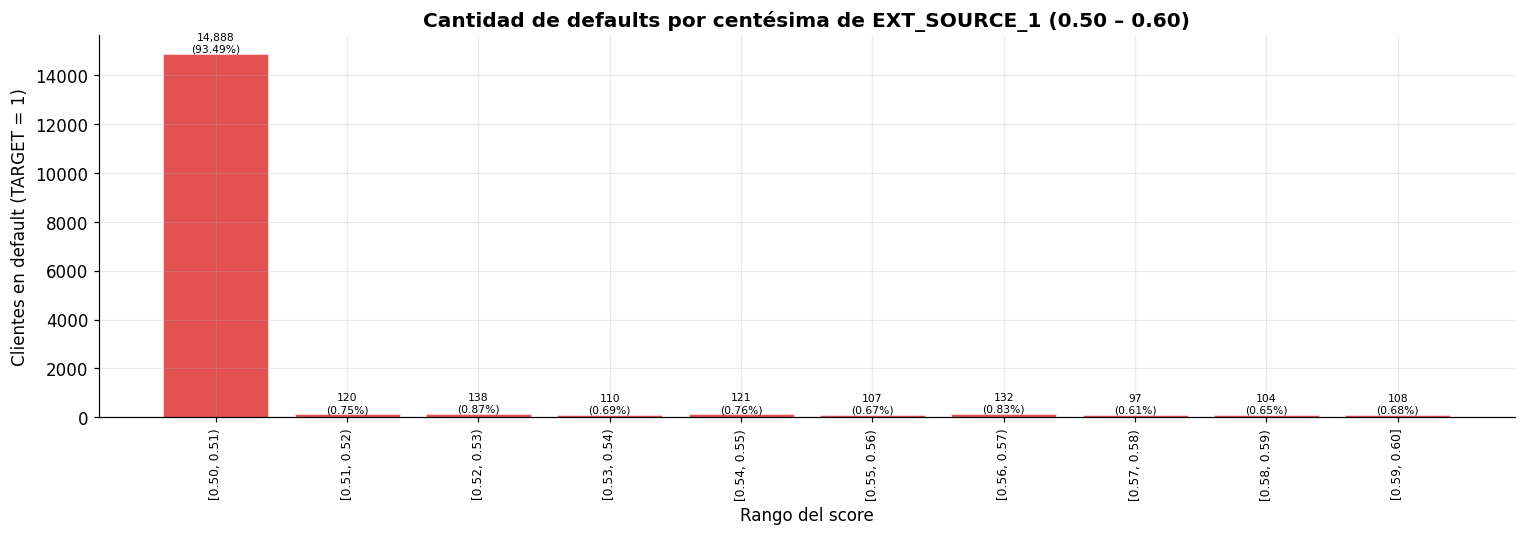


Pico de defaults: [0.50, 0.51) (14,888 casos, 93.49% del subtotal 0.5–0.6)


In [8]:
edges_fine = np.arange(0.50, 0.601, 0.01)
labels_fine = [
    f'[{edges_fine[i]:.2f}, {edges_fine[i + 1]:.2f})'
    for i in range(len(edges_fine) - 1)
]
labels_fine[-1] = f'[{edges_fine[-2]:.2f}, {edges_fine[-1]:.2f}]'

detalle_score = df[[SCORE_COL, 'TARGET']].copy()
detalle_score[SCORE_COL] = pd.to_numeric(detalle_score[SCORE_COL], errors='coerce')
detalle_score = detalle_score.dropna(subset=[SCORE_COL])
detalle_score = detalle_score[
    (detalle_score[SCORE_COL] >= 0.5) & (detalle_score[SCORE_COL] <= 0.6)
]

defaults_det = detalle_score[detalle_score['TARGET'] == 1].copy()
defaults_det['rango_fino'] = pd.cut(
    defaults_det[SCORE_COL],
    bins=edges_fine,
    labels=labels_fine,
    include_lowest=True,
    ordered=True,
)

resumen_fino = (
    defaults_det.groupby('rango_fino', observed=False)
    .size()
    .reset_index(name='clientes_default')
    .rename(columns={'rango_fino': 'rango'})
)
resumen_fino['clientes_default'] = resumen_fino['clientes_default'].astype(int)
total_defaults_fino = int(resumen_fino['clientes_default'].sum())

resumen_fino['participacion_pct'] = (
    resumen_fino['clientes_default'] / total_defaults_fino * 100
).round(2)

n_clientes_fino = len(detalle_score)
n_defaults_fino = len(defaults_det)

print(
    f'Segmento {SCORE_COL} en [0.50, 0.60]: '
    f'{n_clientes_fino:,} clientes | {n_defaults_fino:,} defaults'
)
print('\nCantidad de defaults por centésima:')
print(resumen_fino.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
barras = ax.bar(
    resumen_fino['rango'],
    resumen_fino['clientes_default'],
    color=RISK,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.4,
)
for b, cnt, pct in zip(
    barras,
    resumen_fino['clientes_default'],
    resumen_fino['participacion_pct'],
):
    if cnt > 0:
        ax.text(
            b.get_x() + b.get_width() / 2,
            cnt,
            f'{cnt:,}\n({pct}%)',
            ha='center',
            va='bottom',
            fontsize=7,
        )
ax.set_title(
    f'Cantidad de defaults por centésima de {SCORE_COL} (0.50 – 0.60)'
)
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=90, ha='center', fontsize=8)
fig.tight_layout()
plt.show()

r_max = resumen_fino.loc[resumen_fino['clientes_default'].idxmax()]
print(
    f'\nPico de defaults: {r_max["rango"]} '
    f'({r_max["clientes_default"]:,} casos, {r_max["participacion_pct"]:.2f}% del subtotal 0.5–0.6)'
)

## Distribución del score externo 2 (`EXT_SOURCE_2`)

El **score 2** corresponde a `EXT_SOURCE_2` (segunda fuente de scoring externo). Misma escala 0–1: **más alto = mejor perfil crediticio**.

Misma metodología que `EXT_SOURCE_1`: histogramas con curva normal para todos, default y al día; luego rangos de 0.1, métricas de default y detalle centésimo en `[0.50, 0.60]`.


EXT_SOURCE_2: nulos = 0 (0.00%)


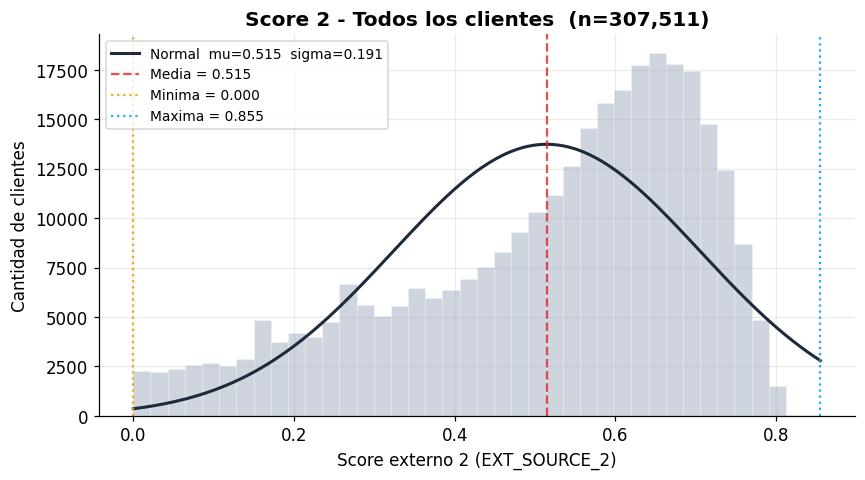

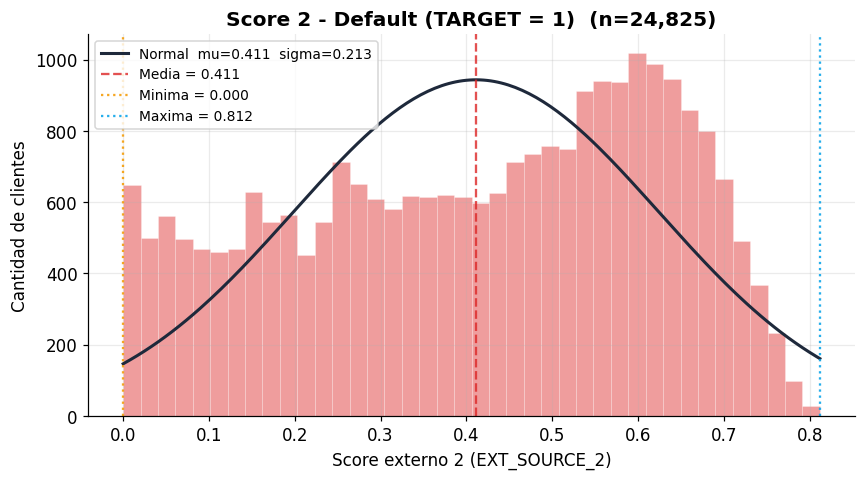

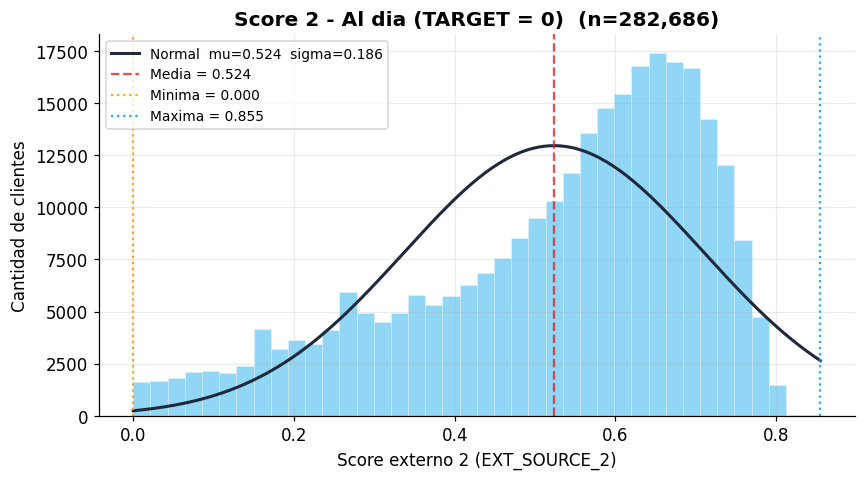


Resumen de EXT_SOURCE_2 por grupo:
                   minima  media  maxima   desv         n
grupo                                                    
Al dia (0)   0.000000e+00  0.524   0.855  0.186  282686.0
Default (1)  0.000000e+00  0.411   0.812  0.213   24825.0
Todos        8.173617e-08  0.515   0.855  0.191  307511.0


In [9]:
SCORE_COL = 'EXT_SOURCE_2'
SCORE_LABEL = 'Score 2'

if SCORE_COL not in df.columns:
    raise KeyError(f'La columna {SCORE_COL} no está en el dataset cargado.')

nulos_score = int(df[SCORE_COL].isna().sum())
print(f'{SCORE_COL}: nulos = {nulos_score:,} ({nulos_score / len(df) * 100:.2f}%)')

plot_score_normal(
    df[SCORE_COL],
    f'{SCORE_LABEL} - Todos los clientes',
    BASE,
    xlabel=f'Score externo 2 ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, SCORE_COL],
    f'{SCORE_LABEL} - Default (TARGET = 1)',
    RISK,
    xlabel=f'Score externo 2 ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, SCORE_COL],
    f'{SCORE_LABEL} - Al dia (TARGET = 0)',
    SAFE,
    xlabel=f'Score externo 2 ({SCORE_COL})',
)

resumen_score = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[SCORE_COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(3)
)
resumen_score.loc['Todos'] = [
    df[SCORE_COL].min(), round(df[SCORE_COL].mean(), 3),
    df[SCORE_COL].max(), round(df[SCORE_COL].std(), 3), df[SCORE_COL].count(),
]

print(f'\nResumen de {SCORE_COL} por grupo:')
print(resumen_score.to_string())


### Score 2 por rangos de 0.1

Distribución de clientes en intervalos `[0.0, 0.1)`, …, `[0.9, 1.0]` sobre `EXT_SOURCE_2`.


Distribución de EXT_SOURCE_2 por rangos de 0.1 (n=307,511):
     rango  cantidad  porcentaje
[0.0, 0.1)     11365        3.70
[0.1, 0.2)     16500        5.37
[0.2, 0.3)     23709        7.71
[0.3, 0.4)     27369        8.90
[0.4, 0.5)     37854       12.31
[0.5, 0.6)     61675       20.06
[0.6, 0.7)     82426       26.80
[0.7, 0.8)     46044       14.97
[0.8, 0.9)       569        0.19
[0.9, 1.0]         0        0.00

Total: 307,511


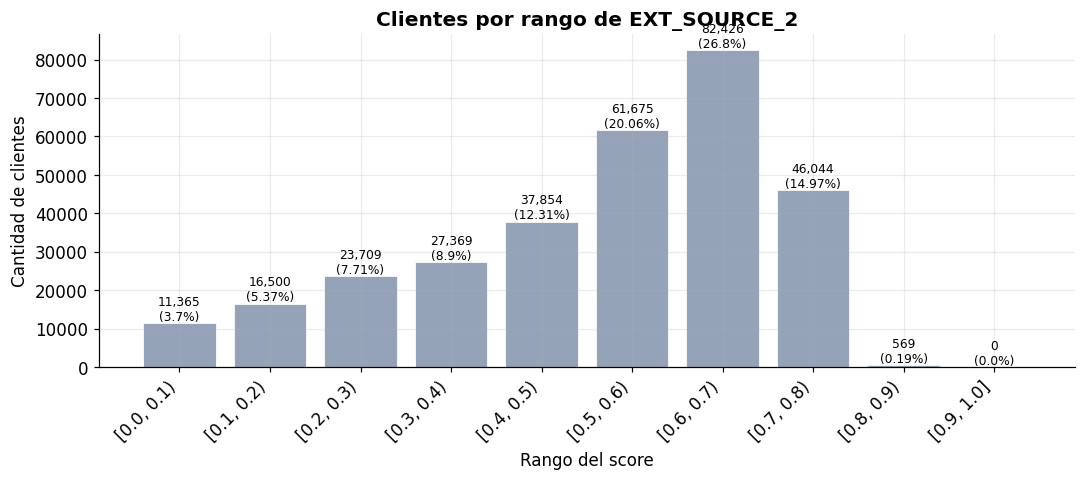

In [10]:
edges = np.arange(0, 1.1, 0.1)
labels = [f'[{edges[i]:.1f}, {edges[i + 1]:.1f})' for i in range(len(edges) - 1)]
labels[-1] = f'[{edges[-2]:.1f}, {edges[-1]:.1f}]'

score_vals = pd.to_numeric(df[SCORE_COL], errors='coerce').dropna()
counts, _ = np.histogram(score_vals, bins=edges)

dist_score_rangos = pd.DataFrame({
    'rango': labels,
    'cantidad': counts.astype(int),
})
dist_score_rangos['porcentaje'] = (
    dist_score_rangos['cantidad'] / len(score_vals) * 100
).round(2)
dist_score_rangos = dist_score_rangos.sort_values('rango')

print(f'Distribución de {SCORE_COL} por rangos de 0.1 (n={len(score_vals):,}):')
print(dist_score_rangos.to_string(index=False))
print(f"\nTotal: {dist_score_rangos['cantidad'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    dist_score_rangos['rango'],
    dist_score_rangos['cantidad'],
    color=BASE,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title(f'Clientes por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
for i, (cnt, pct) in enumerate(
    zip(dist_score_rangos['cantidad'], dist_score_rangos['porcentaje'])
):
    ax.text(
        i, cnt, f'{cnt:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=8,
    )
fig.tight_layout()
plt.show()


### Default por rango de `EXT_SOURCE_2`

- **Cantidad de defaults** por rango de 0.1.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default global: 8.07%  |  Total defaults: 24,825

Resumen por rango de EXT_SOURCE_2:
     rango  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[0.0, 0.1)           11365              2645             23.27                          10.65  2.88
[0.1, 0.2)           16500              2606             15.79                          10.50  1.96
[0.2, 0.3)           23709              2939             12.40                          11.84  1.54
[0.3, 0.4)           27369              2994             10.94                          12.06  1.36
[0.4, 0.5)           37854              3309              8.74                          13.33  1.08
[0.5, 0.6)           61675              4449              7.21                          17.92  0.89
[0.6, 0.7)           82426              4342              5.27                          17.49  0.65
[0.7, 0.8)           46044              1531              3.33                           6.17  0.41
[0.8, 0

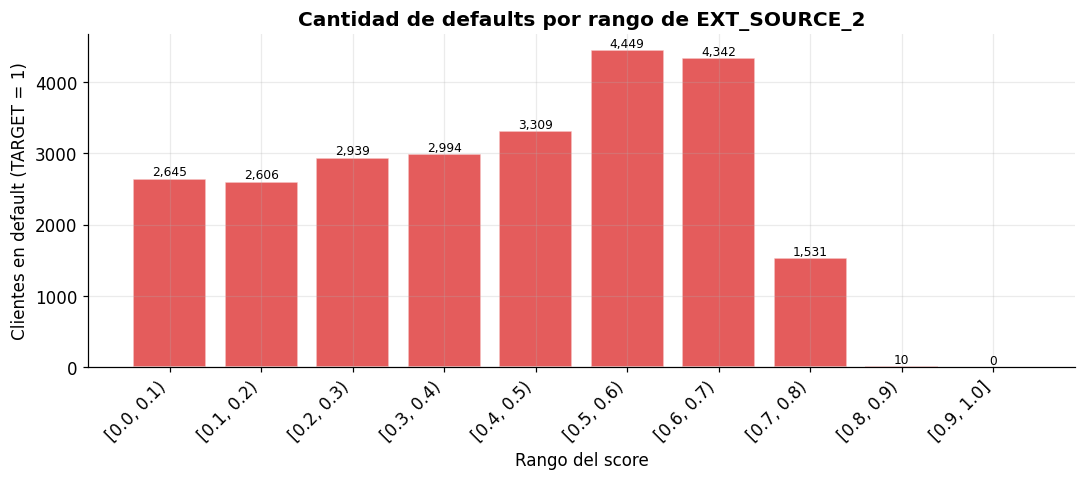

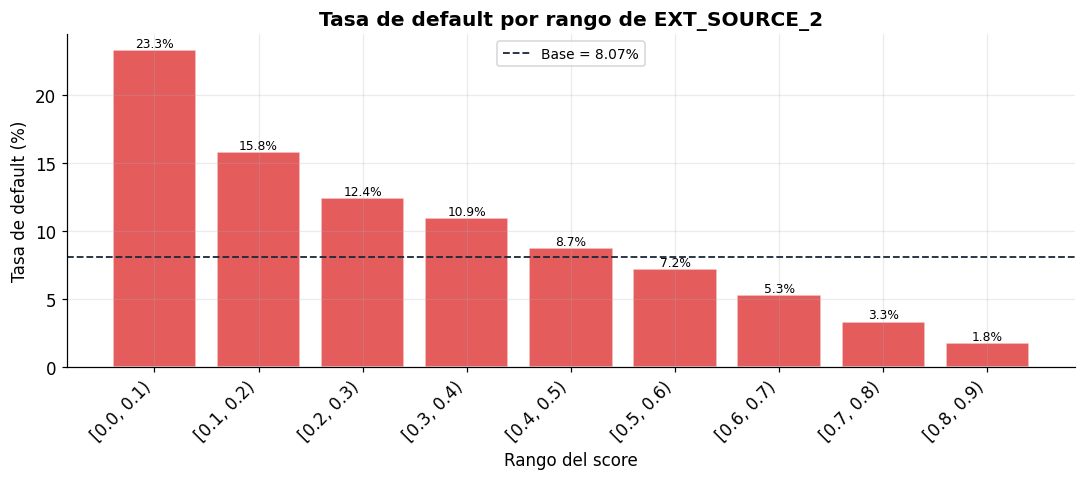

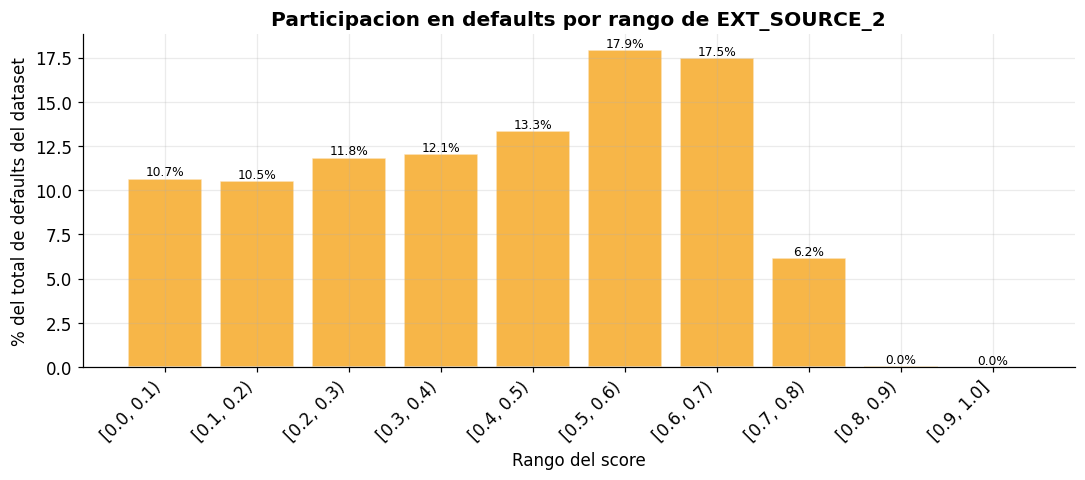


Interpretacion:
  Mayor tasa de default     : [0.0, 0.1) (23.27%, lift=2.88x)
  Mayor cantidad de defaults: [0.5, 0.6) (4,449 casos)
  Mayor participacion       : [0.5, 0.6) (17.92% del total de defaults)


In [11]:
score_df = df[[SCORE_COL, 'TARGET']].copy()
score_df[SCORE_COL] = pd.to_numeric(score_df[SCORE_COL], errors='coerce')
score_df = score_df.dropna(subset=[SCORE_COL])

score_df['rango_score'] = pd.cut(
    score_df[SCORE_COL],
    bins=edges,
    labels=labels,
    include_lowest=True,
    ordered=True,
)

total_defaults_score = int((score_df['TARGET'] == 1).sum())
base_default = score_df['TARGET'].mean()

resumen_score_default = (
    score_df.groupby('rango_score', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
    .reset_index()
    .rename(columns={'rango_score': 'rango'})
)
resumen_score_default['clientes_default'] = resumen_score_default['clientes_default'].astype(int)
resumen_score_default['tasa_default_pct'] = (
    resumen_score_default['clientes_default'] / resumen_score_default['total_clientes'] * 100
).round(2)
resumen_score_default['participacion_en_defaults_pct'] = (
    resumen_score_default['clientes_default'] / total_defaults_score * 100
).round(2)
resumen_score_default['lift'] = (
    resumen_score_default['tasa_default_pct'] / (base_default * 100)
).round(2)

print(f'Base de default global: {base_default * 100:.2f}%  |  Total defaults: {total_defaults_score:,}')
print(f'\nResumen por rango de {SCORE_COL}:')
print(resumen_score_default.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Cantidad de defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default * 100:.2f}%')
for b, v in zip(barras, resumen_score_default['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Tasa de default por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Participacion en defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

r_tasa = resumen_score_default.loc[resumen_score_default['tasa_default_pct'].idxmax()]
r_cant = resumen_score_default.loc[resumen_score_default['clientes_default'].idxmax()]
r_part = resumen_score_default.loc[resumen_score_default['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')


### Detalle de defaults entre 0.50 y 0.60 (`EXT_SOURCE_2`)

Intervalos de **0.01** en `[0.50, 0.60]`; solo `TARGET = 1` (mismo corte que en score 1).


Segmento EXT_SOURCE_2 en [0.50, 0.60]: 61,675 clientes | 4,449 defaults

Cantidad de defaults por centésima:
       rango  clientes_default  participacion_pct
[0.50, 0.51)               381               8.56
[0.51, 0.52)               371               8.34
[0.52, 0.53)               400               8.99
[0.53, 0.54)               421               9.46
[0.54, 0.55)               493              11.08
[0.55, 0.56)               429               9.64
[0.56, 0.57)               470              10.56
[0.57, 0.58)               474              10.65
[0.58, 0.59)               480              10.79
[0.59, 0.60]               530              11.91


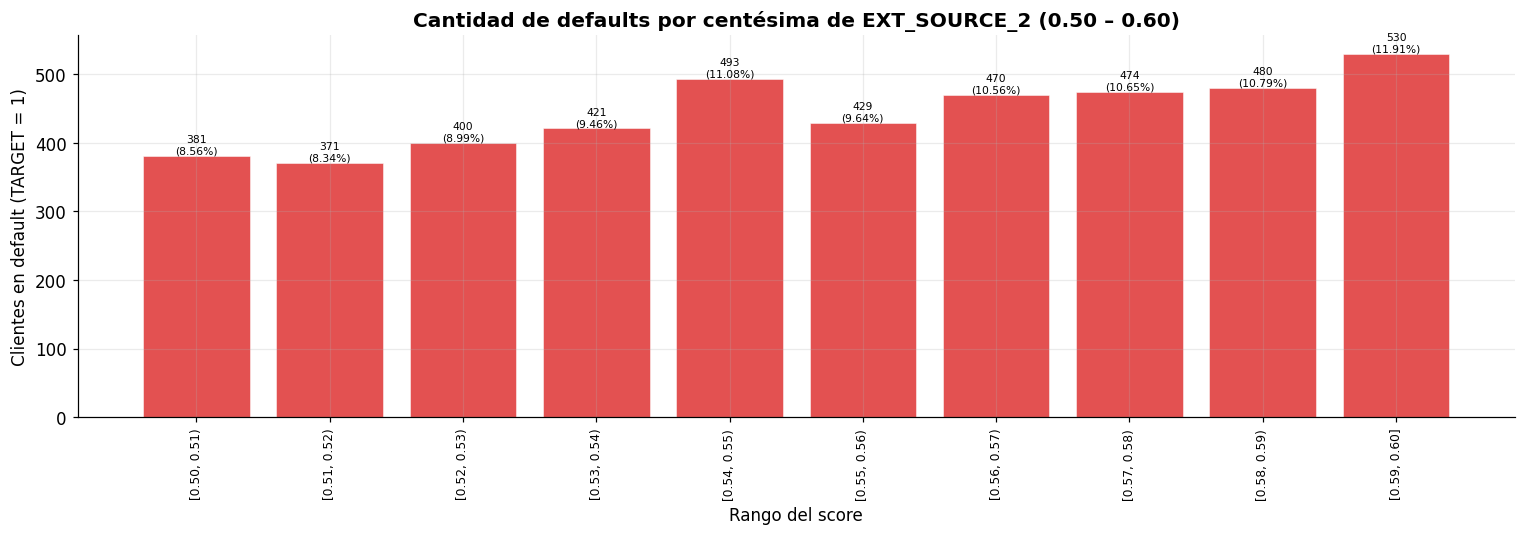


Pico de defaults: [0.59, 0.60] (530 casos, 11.91% del subtotal 0.5–0.6)


In [12]:
edges_fine = np.arange(0.50, 0.601, 0.01)
labels_fine = [
    f'[{edges_fine[i]:.2f}, {edges_fine[i + 1]:.2f})'
    for i in range(len(edges_fine) - 1)
]
labels_fine[-1] = f'[{edges_fine[-2]:.2f}, {edges_fine[-1]:.2f}]'

detalle_score = df[[SCORE_COL, 'TARGET']].copy()
detalle_score[SCORE_COL] = pd.to_numeric(detalle_score[SCORE_COL], errors='coerce')
detalle_score = detalle_score.dropna(subset=[SCORE_COL])
detalle_score = detalle_score[
    (detalle_score[SCORE_COL] >= 0.5) & (detalle_score[SCORE_COL] <= 0.6)
]

defaults_det = detalle_score[detalle_score['TARGET'] == 1].copy()
defaults_det['rango_fino'] = pd.cut(
    defaults_det[SCORE_COL],
    bins=edges_fine,
    labels=labels_fine,
    include_lowest=True,
    ordered=True,
)

resumen_fino = (
    defaults_det.groupby('rango_fino', observed=False)
    .size()
    .reset_index(name='clientes_default')
    .rename(columns={'rango_fino': 'rango'})
)
resumen_fino['clientes_default'] = resumen_fino['clientes_default'].astype(int)
total_defaults_fino = int(resumen_fino['clientes_default'].sum())
if total_defaults_fino > 0:
    resumen_fino['participacion_pct'] = (
        resumen_fino['clientes_default'] / total_defaults_fino * 100
    ).round(2)
else:
    resumen_fino['participacion_pct'] = 0.0

n_clientes_fino = len(detalle_score)
n_defaults_fino = len(defaults_det)

print(
    f'Segmento {SCORE_COL} en [0.50, 0.60]: '
    f'{n_clientes_fino:,} clientes | {n_defaults_fino:,} defaults'
)
print('\nCantidad de defaults por centésima:')
print(resumen_fino.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
barras = ax.bar(
    resumen_fino['rango'],
    resumen_fino['clientes_default'],
    color=RISK,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.4,
)
for b, cnt, pct in zip(
    barras,
    resumen_fino['clientes_default'],
    resumen_fino['participacion_pct'],
):
    if cnt > 0:
        ax.text(
            b.get_x() + b.get_width() / 2,
            cnt,
            f'{cnt:,}\n({pct}%)',
            ha='center',
            va='bottom',
            fontsize=7,
        )
ax.set_title(
    f'Cantidad de defaults por centésima de {SCORE_COL} (0.50 – 0.60)'
)
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=90, ha='center', fontsize=8)
fig.tight_layout()
plt.show()

if total_defaults_fino > 0:
    r_max = resumen_fino.loc[resumen_fino['clientes_default'].idxmax()]
    print(
        f'\nPico de defaults: {r_max["rango"]} '
        f'({r_max["clientes_default"]:,} casos, {r_max["participacion_pct"]:.2f}% del subtotal 0.5–0.6)'
    )
else:
    print('\nSin defaults en el segmento [0.50, 0.60].')


## Distribución del score externo 3 (`EXT_SOURCE_3`)

El **score 3** corresponde a `EXT_SOURCE_3` (tercera fuente de scoring externo). Misma escala 0–1: **más alto = mejor perfil crediticio**.

Misma metodología que scores 1 y 2: histogramas con curva normal, rangos de 0.1, métricas de default y detalle centésimo en `[0.50, 0.60]`.


EXT_SOURCE_3: nulos = 0 (0.00%)


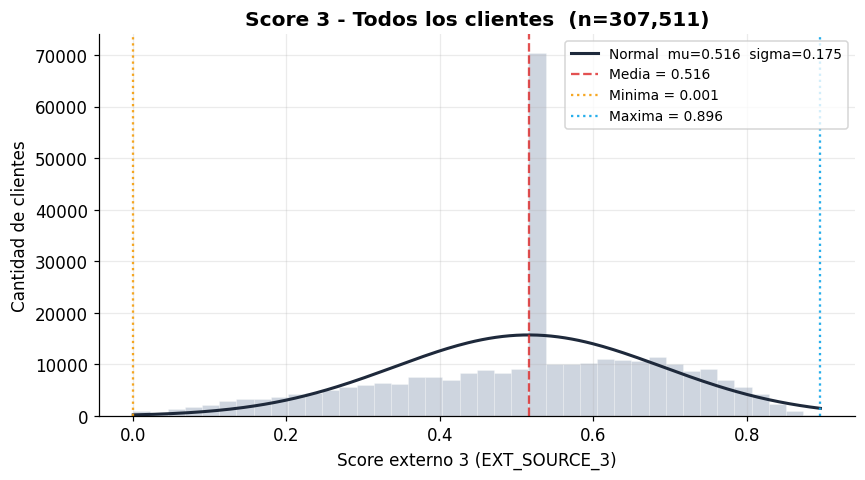

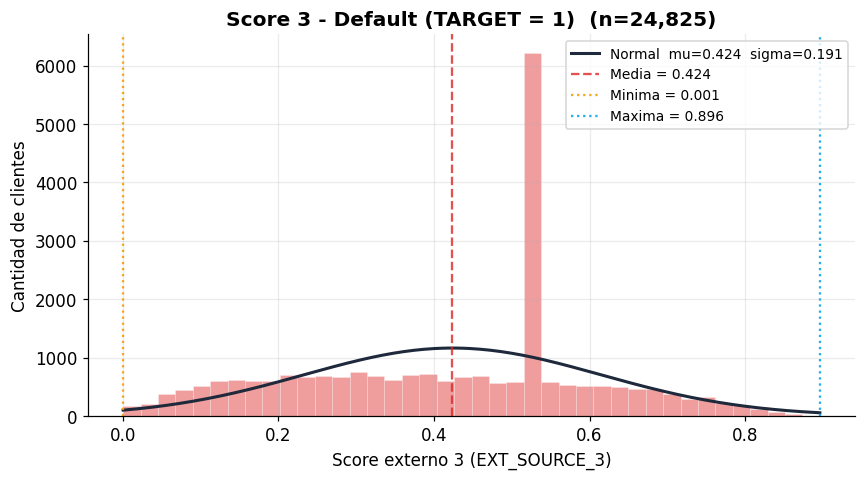

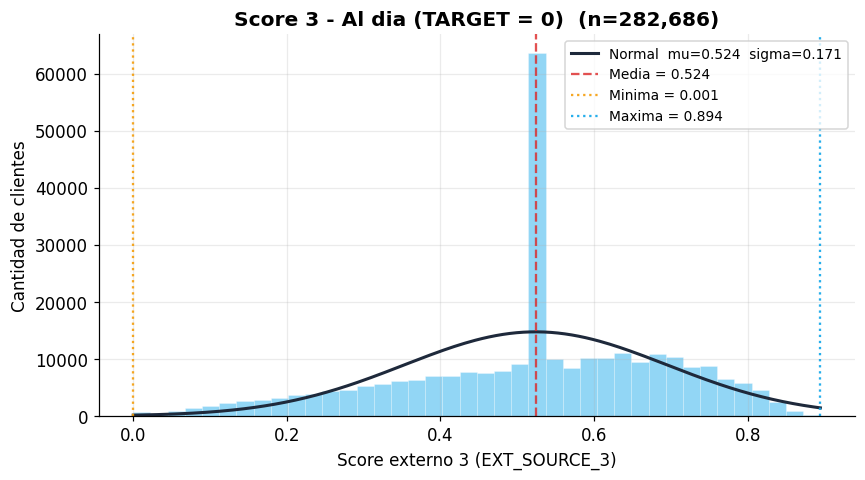


Resumen de EXT_SOURCE_3 por grupo:
               minima  media   maxima   desv         n
grupo                                                 
Al dia (0)   0.001000  0.524  0.89400  0.171  282686.0
Default (1)  0.001000  0.424  0.89600  0.191   24825.0
Todos        0.000527  0.516  0.89601  0.175  307511.0


In [13]:
SCORE_COL = 'EXT_SOURCE_3'
SCORE_LABEL = 'Score 3'

if SCORE_COL not in df.columns:
    raise KeyError(f'La columna {SCORE_COL} no está en el dataset cargado.')

nulos_score = int(df[SCORE_COL].isna().sum())
print(f'{SCORE_COL}: nulos = {nulos_score:,} ({nulos_score / len(df) * 100:.2f}%)')

plot_score_normal(
    df[SCORE_COL],
    f'{SCORE_LABEL} - Todos los clientes',
    BASE,
    xlabel=f'Score externo 3 ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, SCORE_COL],
    f'{SCORE_LABEL} - Default (TARGET = 1)',
    RISK,
    xlabel=f'Score externo 3 ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, SCORE_COL],
    f'{SCORE_LABEL} - Al dia (TARGET = 0)',
    SAFE,
    xlabel=f'Score externo 3 ({SCORE_COL})',
)

resumen_score = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[SCORE_COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(3)
)
resumen_score.loc['Todos'] = [
    df[SCORE_COL].min(), round(df[SCORE_COL].mean(), 3),
    df[SCORE_COL].max(), round(df[SCORE_COL].std(), 3), df[SCORE_COL].count(),
]

print(f'\nResumen de {SCORE_COL} por grupo:')
print(resumen_score.to_string())


### Score 3 por rangos de 0.1

Distribución de clientes en intervalos `[0.0, 0.1)`, …, `[0.9, 1.0]` sobre `EXT_SOURCE_3`.


Distribución de EXT_SOURCE_3 por rangos de 0.1 (n=307,511):
     rango  cantidad  porcentaje
[0.0, 0.1)      5363        1.74
[0.1, 0.2)     14151        4.60
[0.2, 0.3)     21581        7.02
[0.3, 0.4)     30491        9.92
[0.4, 0.5)     36559       11.89
[0.5, 0.6)    105183       34.20
[0.6, 0.7)     47680       15.51
[0.7, 0.8)     37244       12.11
[0.8, 0.9)      9259        3.01
[0.9, 1.0]         0        0.00

Total: 307,511


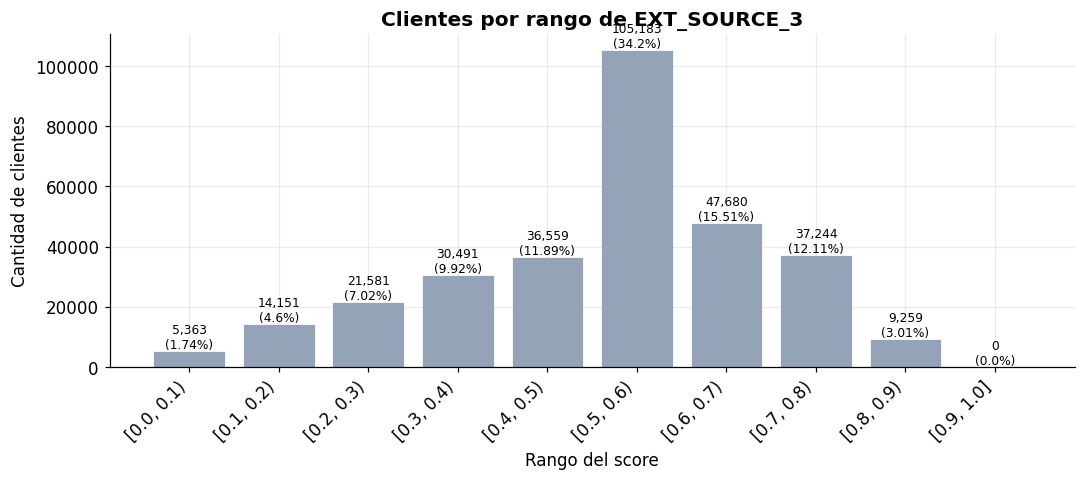

In [14]:
edges = np.arange(0, 1.1, 0.1)
labels = [f'[{edges[i]:.1f}, {edges[i + 1]:.1f})' for i in range(len(edges) - 1)]
labels[-1] = f'[{edges[-2]:.1f}, {edges[-1]:.1f}]'

score_vals = pd.to_numeric(df[SCORE_COL], errors='coerce').dropna()
counts, _ = np.histogram(score_vals, bins=edges)

dist_score_rangos = pd.DataFrame({
    'rango': labels,
    'cantidad': counts.astype(int),
})
dist_score_rangos['porcentaje'] = (
    dist_score_rangos['cantidad'] / len(score_vals) * 100
).round(2)
dist_score_rangos = dist_score_rangos.sort_values('rango')

print(f'Distribución de {SCORE_COL} por rangos de 0.1 (n={len(score_vals):,}):')
print(dist_score_rangos.to_string(index=False))
print(f"\nTotal: {dist_score_rangos['cantidad'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    dist_score_rangos['rango'],
    dist_score_rangos['cantidad'],
    color=BASE,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title(f'Clientes por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
for i, (cnt, pct) in enumerate(
    zip(dist_score_rangos['cantidad'], dist_score_rangos['porcentaje'])
):
    ax.text(
        i, cnt, f'{cnt:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=8,
    )
fig.tight_layout()
plt.show()


### Default por rango de `EXT_SOURCE_3`

- **Cantidad de defaults** por rango de 0.1.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default global: 8.07%  |  Total defaults: 24,825

Resumen por rango de EXT_SOURCE_3:
     rango  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[0.0, 0.1)            5363              1412             26.33                           5.69  3.26
[0.1, 0.2)           14151              2675             18.90                          10.78  2.34
[0.2, 0.3)           21581              3030             14.04                          12.21  1.74
[0.3, 0.4)           30491              3103             10.18                          12.50  1.26
[0.4, 0.5)           36559              2824              7.72                          11.38  0.96
[0.5, 0.6)          105183              8119              7.72                          32.70  0.96
[0.6, 0.7)           47680              2107              4.42                           8.49  0.55
[0.7, 0.8)           37244              1289              3.46                           5.19  0.43
[0.8, 0

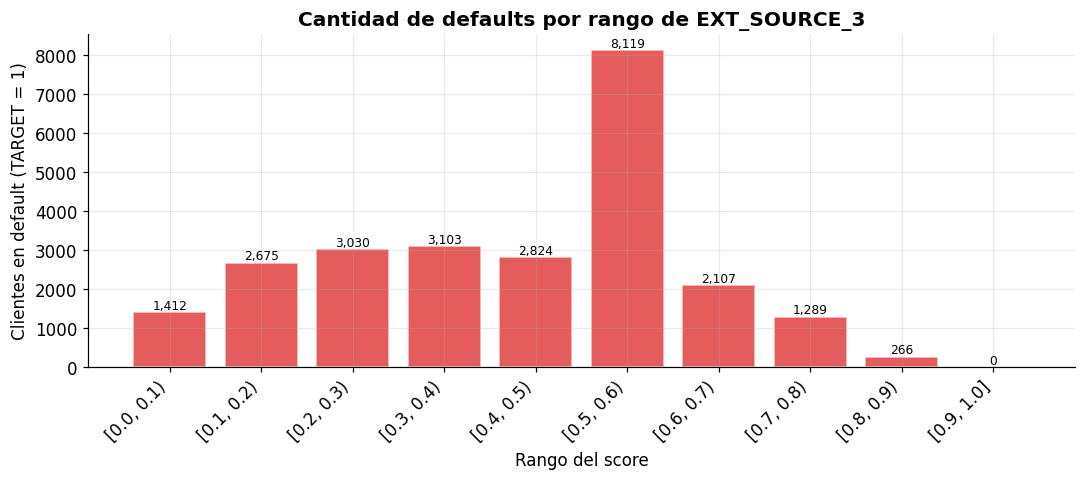

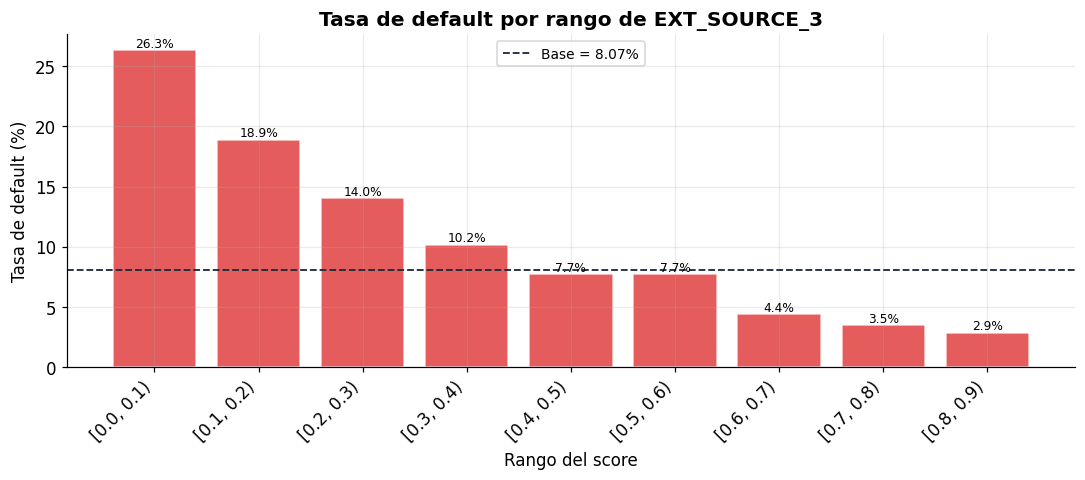

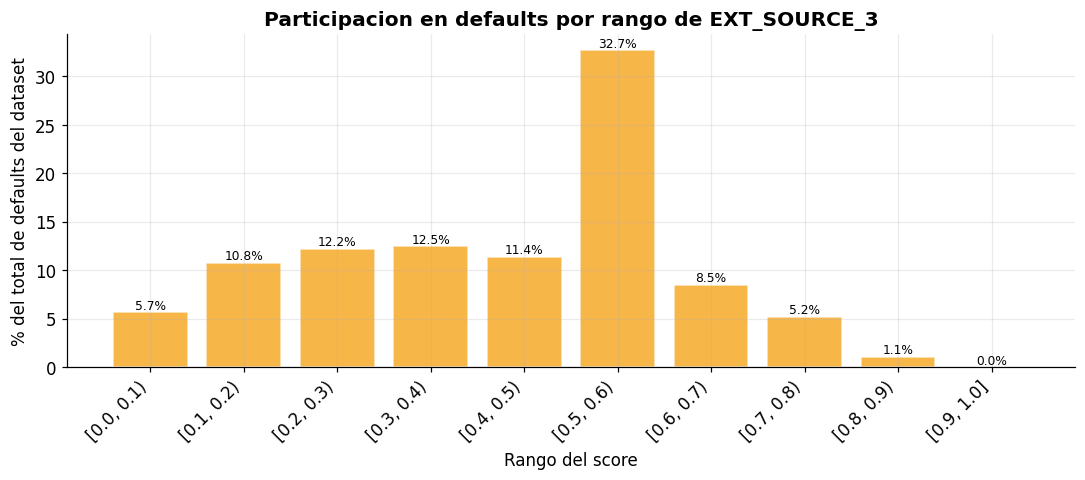


Interpretacion:
  Mayor tasa de default     : [0.0, 0.1) (26.33%, lift=3.26x)
  Mayor cantidad de defaults: [0.5, 0.6) (8,119 casos)
  Mayor participacion       : [0.5, 0.6) (32.70% del total de defaults)


In [15]:
score_df = df[[SCORE_COL, 'TARGET']].copy()
score_df[SCORE_COL] = pd.to_numeric(score_df[SCORE_COL], errors='coerce')
score_df = score_df.dropna(subset=[SCORE_COL])

score_df['rango_score'] = pd.cut(
    score_df[SCORE_COL],
    bins=edges,
    labels=labels,
    include_lowest=True,
    ordered=True,
)

total_defaults_score = int((score_df['TARGET'] == 1).sum())
base_default = score_df['TARGET'].mean()

resumen_score_default = (
    score_df.groupby('rango_score', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
    .reset_index()
    .rename(columns={'rango_score': 'rango'})
)
resumen_score_default['clientes_default'] = resumen_score_default['clientes_default'].astype(int)
resumen_score_default['tasa_default_pct'] = (
    resumen_score_default['clientes_default'] / resumen_score_default['total_clientes'] * 100
).round(2)
resumen_score_default['participacion_en_defaults_pct'] = (
    resumen_score_default['clientes_default'] / total_defaults_score * 100
).round(2)
resumen_score_default['lift'] = (
    resumen_score_default['tasa_default_pct'] / (base_default * 100)
).round(2)

print(f'Base de default global: {base_default * 100:.2f}%  |  Total defaults: {total_defaults_score:,}')
print(f'\nResumen por rango de {SCORE_COL}:')
print(resumen_score_default.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Cantidad de defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default * 100:.2f}%')
for b, v in zip(barras, resumen_score_default['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Tasa de default por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Participacion en defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

r_tasa = resumen_score_default.loc[resumen_score_default['tasa_default_pct'].idxmax()]
r_cant = resumen_score_default.loc[resumen_score_default['clientes_default'].idxmax()]
r_part = resumen_score_default.loc[resumen_score_default['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')


### Detalle de defaults entre 0.50 y 0.60 (`EXT_SOURCE_3`)

Intervalos de **0.01** en `[0.50, 0.60]`; solo `TARGET = 1` (mismo corte que en scores 1 y 2).


Segmento EXT_SOURCE_3 en [0.50, 0.60]: 105,183 clientes | 8,119 defaults

Cantidad de defaults por centésima:
       rango  clientes_default  participacion_pct
[0.50, 0.51)               240               2.96
[0.51, 0.52)               281               3.46
[0.52, 0.53)               249               3.07
[0.53, 0.54)              5902              72.69
[0.54, 0.55)               272               3.35
[0.55, 0.56)               250               3.08
[0.56, 0.57)               248               3.05
[0.57, 0.58)               223               2.75
[0.58, 0.59)               187               2.30
[0.59, 0.60]               267               3.29


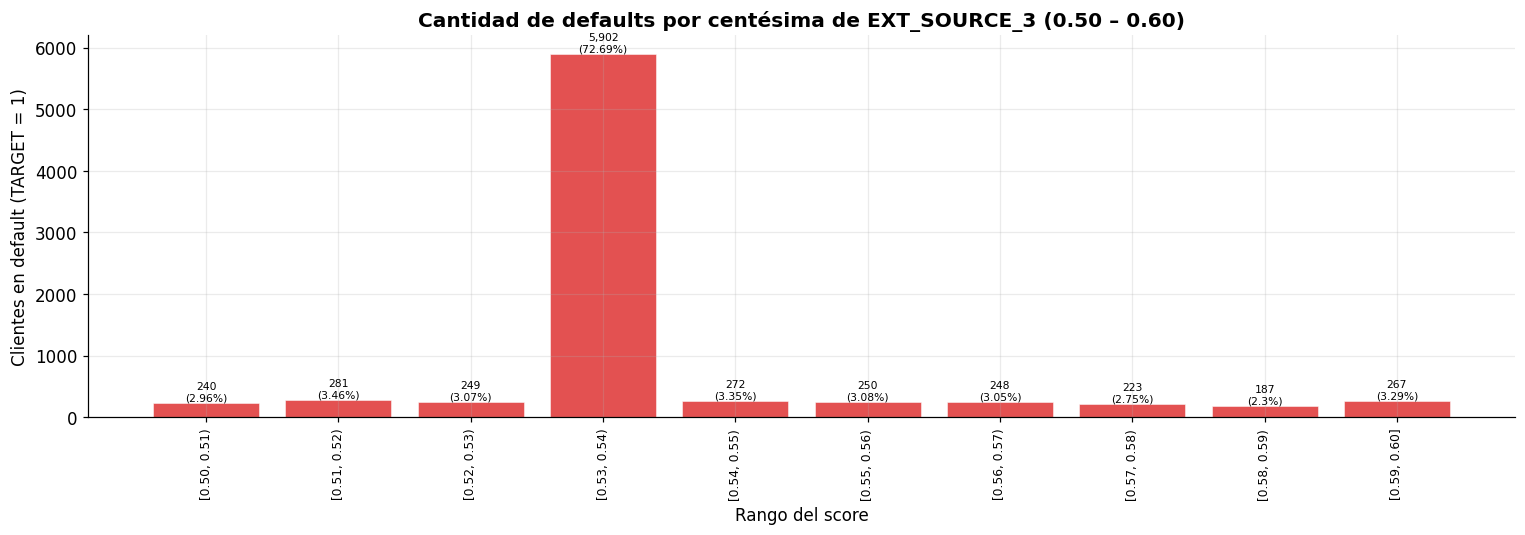


Pico de defaults: [0.53, 0.54) (5,902 casos, 72.69% del subtotal 0.5–0.6)


In [16]:
edges_fine = np.arange(0.50, 0.601, 0.01)
labels_fine = [
    f'[{edges_fine[i]:.2f}, {edges_fine[i + 1]:.2f})'
    for i in range(len(edges_fine) - 1)
]
labels_fine[-1] = f'[{edges_fine[-2]:.2f}, {edges_fine[-1]:.2f}]'

detalle_score = df[[SCORE_COL, 'TARGET']].copy()
detalle_score[SCORE_COL] = pd.to_numeric(detalle_score[SCORE_COL], errors='coerce')
detalle_score = detalle_score.dropna(subset=[SCORE_COL])
detalle_score = detalle_score[
    (detalle_score[SCORE_COL] >= 0.5) & (detalle_score[SCORE_COL] <= 0.6)
]

defaults_det = detalle_score[detalle_score['TARGET'] == 1].copy()
defaults_det['rango_fino'] = pd.cut(
    defaults_det[SCORE_COL],
    bins=edges_fine,
    labels=labels_fine,
    include_lowest=True,
    ordered=True,
)

resumen_fino = (
    defaults_det.groupby('rango_fino', observed=False)
    .size()
    .reset_index(name='clientes_default')
    .rename(columns={'rango_fino': 'rango'})
)
resumen_fino['clientes_default'] = resumen_fino['clientes_default'].astype(int)
total_defaults_fino = int(resumen_fino['clientes_default'].sum())
if total_defaults_fino > 0:
    resumen_fino['participacion_pct'] = (
        resumen_fino['clientes_default'] / total_defaults_fino * 100
    ).round(2)
else:
    resumen_fino['participacion_pct'] = 0.0

n_clientes_fino = len(detalle_score)
n_defaults_fino = len(defaults_det)

print(
    f'Segmento {SCORE_COL} en [0.50, 0.60]: '
    f'{n_clientes_fino:,} clientes | {n_defaults_fino:,} defaults'
)
print('\nCantidad de defaults por centésima:')
print(resumen_fino.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
barras = ax.bar(
    resumen_fino['rango'],
    resumen_fino['clientes_default'],
    color=RISK,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.4,
)
for b, cnt, pct in zip(
    barras,
    resumen_fino['clientes_default'],
    resumen_fino['participacion_pct'],
):
    if cnt > 0:
        ax.text(
            b.get_x() + b.get_width() / 2,
            cnt,
            f'{cnt:,}\n({pct}%)',
            ha='center',
            va='bottom',
            fontsize=7,
        )
ax.set_title(
    f'Cantidad de defaults por centésima de {SCORE_COL} (0.50 – 0.60)'
)
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=90, ha='center', fontsize=8)
fig.tight_layout()
plt.show()

if total_defaults_fino > 0:
    r_max = resumen_fino.loc[resumen_fino['clientes_default'].idxmax()]
    print(
        f'\nPico de defaults: {r_max["rango"]} '
        f'({r_max["clientes_default"]:,} casos, {r_max["participacion_pct"]:.2f}% del subtotal 0.5–0.6)'
    )
else:
    print('\nSin defaults en el segmento [0.50, 0.60].')


## Distribución del score externo medio (`EXT_SOURCE_MEAN`)

`EXT_SOURCE_MEAN` es el **promedio** de las fuentes externas disponibles (`EXT_SOURCE_1`, `2`, `3`). Escala 0–1: **más alto = mejor perfil crediticio**.

Misma metodología que los scores individuales: histogramas con curva normal, rangos de 0.1, métricas de default y detalle centésimo en `[0.50, 0.60]`.


EXT_SOURCE_MEAN: nulos = 0 (0.00%)


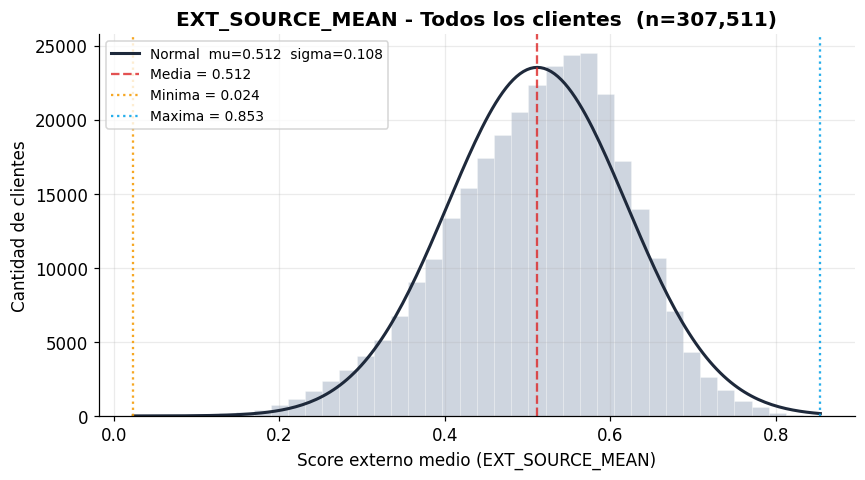

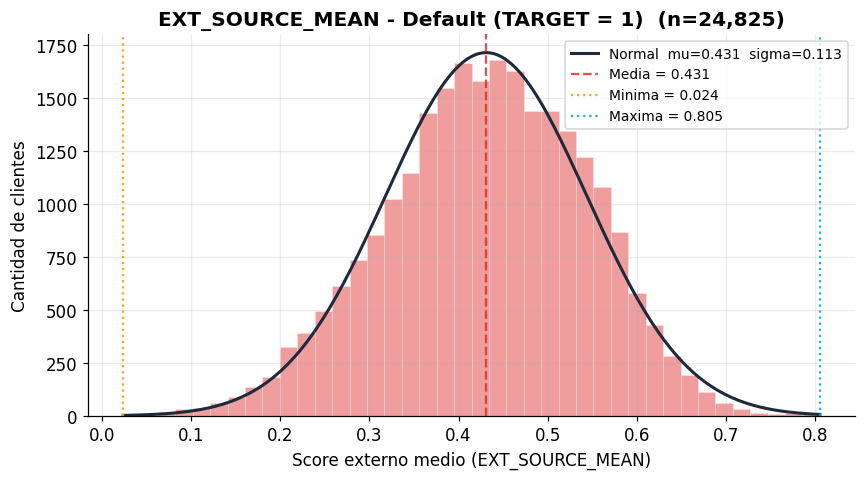

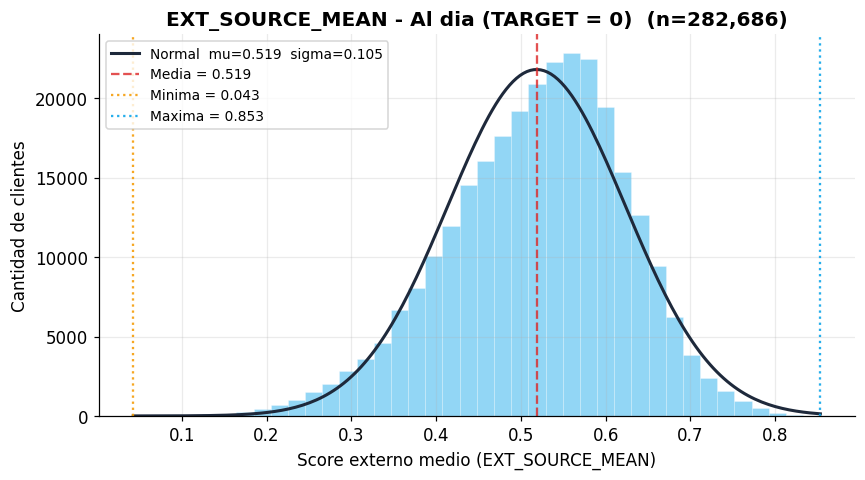


Resumen de EXT_SOURCE_MEAN por grupo:
               minima  media    maxima   desv         n
grupo                                                  
Al dia (0)   0.043000  0.519  0.853000  0.105  282686.0
Default (1)  0.024000  0.431  0.805000  0.113   24825.0
Todos        0.023705  0.512  0.853417  0.108  307511.0


In [17]:
SCORE_COL = 'EXT_SOURCE_MEAN'
SCORE_LABEL = 'EXT_SOURCE_MEAN'

if SCORE_COL not in df.columns:
    raise KeyError(f'La columna {SCORE_COL} no está en el dataset cargado.')

nulos_score = int(df[SCORE_COL].isna().sum())
print(f'{SCORE_COL}: nulos = {nulos_score:,} ({nulos_score / len(df) * 100:.2f}%)')

plot_score_normal(
    df[SCORE_COL],
    f'{SCORE_LABEL} - Todos los clientes',
    BASE,
    xlabel=f'Score externo medio ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, SCORE_COL],
    f'{SCORE_LABEL} - Default (TARGET = 1)',
    RISK,
    xlabel=f'Score externo medio ({SCORE_COL})',
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, SCORE_COL],
    f'{SCORE_LABEL} - Al dia (TARGET = 0)',
    SAFE,
    xlabel=f'Score externo medio ({SCORE_COL})',
)

resumen_score = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[SCORE_COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(3)
)
resumen_score.loc['Todos'] = [
    df[SCORE_COL].min(), round(df[SCORE_COL].mean(), 3),
    df[SCORE_COL].max(), round(df[SCORE_COL].std(), 3), df[SCORE_COL].count(),
]

print(f'\nResumen de {SCORE_COL} por grupo:')
print(resumen_score.to_string())


### `EXT_SOURCE_MEAN` por rangos de 0.1

Distribución de clientes en intervalos `[0.0, 0.1)`, …, `[0.9, 1.0]`.


Distribución de EXT_SOURCE_MEAN por rangos de 0.1 (n=307,511):
     rango  cantidad  porcentaje
[0.0, 0.1)        98        0.03
[0.1, 0.2)      1402        0.46
[0.2, 0.3)      9815        3.19
[0.3, 0.4)     36106       11.74
[0.4, 0.5)     83132       27.03
[0.5, 0.6)    113168       36.80
[0.6, 0.7)     56045       18.23
[0.7, 0.8)      7599        2.47
[0.8, 0.9)       146        0.05
[0.9, 1.0]         0        0.00

Total: 307,511


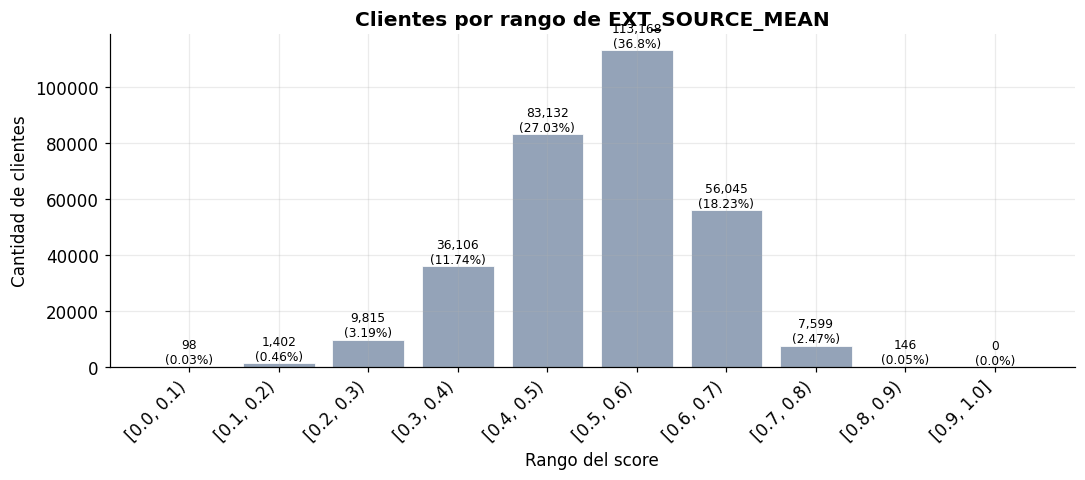

In [18]:
edges = np.arange(0, 1.1, 0.1)
labels = [f'[{edges[i]:.1f}, {edges[i + 1]:.1f})' for i in range(len(edges) - 1)]
labels[-1] = f'[{edges[-2]:.1f}, {edges[-1]:.1f}]'

score_vals = pd.to_numeric(df[SCORE_COL], errors='coerce').dropna()
counts, _ = np.histogram(score_vals, bins=edges)

dist_score_rangos = pd.DataFrame({
    'rango': labels,
    'cantidad': counts.astype(int),
})
dist_score_rangos['porcentaje'] = (
    dist_score_rangos['cantidad'] / len(score_vals) * 100
).round(2)
dist_score_rangos = dist_score_rangos.sort_values('rango')

print(f'Distribución de {SCORE_COL} por rangos de 0.1 (n={len(score_vals):,}):')
print(dist_score_rangos.to_string(index=False))
print(f"\nTotal: {dist_score_rangos['cantidad'].sum():,}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(
    dist_score_rangos['rango'],
    dist_score_rangos['cantidad'],
    color=BASE,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title(f'Clientes por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right')
for i, (cnt, pct) in enumerate(
    zip(dist_score_rangos['cantidad'], dist_score_rangos['porcentaje'])
):
    ax.text(
        i, cnt, f'{cnt:,}\n({pct}%)',
        ha='center', va='bottom', fontsize=8,
    )
fig.tight_layout()
plt.show()


### Default por rango de `EXT_SOURCE_MEAN`

- **Cantidad de defaults** por rango de 0.1.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default global: 8.07%  |  Total defaults: 24,825

Resumen por rango de EXT_SOURCE_MEAN:
     rango  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[0.0, 0.1)              98                54             55.10                           0.22  6.83
[0.1, 0.2)            1402               521             37.16                           2.10  4.60
[0.2, 0.3)            9815              2662             27.12                          10.72  3.36
[0.3, 0.4)           36106              6314             17.49                          25.43  2.17
[0.4, 0.5)           83132              8110              9.76                          32.67  1.21
[0.5, 0.6)          113168              5730              5.06                          23.08  0.63
[0.6, 0.7)           56045              1335              2.38                           5.38  0.29
[0.7, 0.8)            7599                97              1.28                           0.39  0.16
[0.8

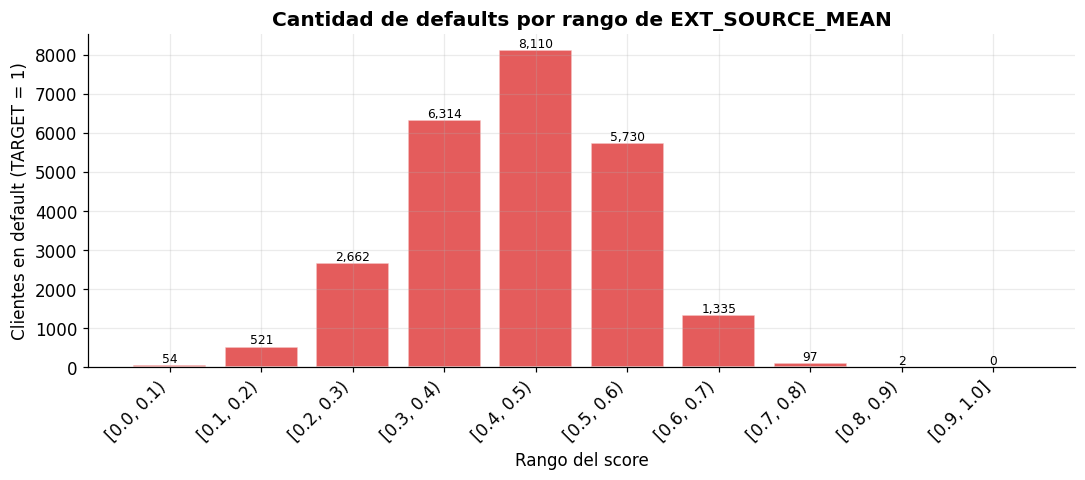

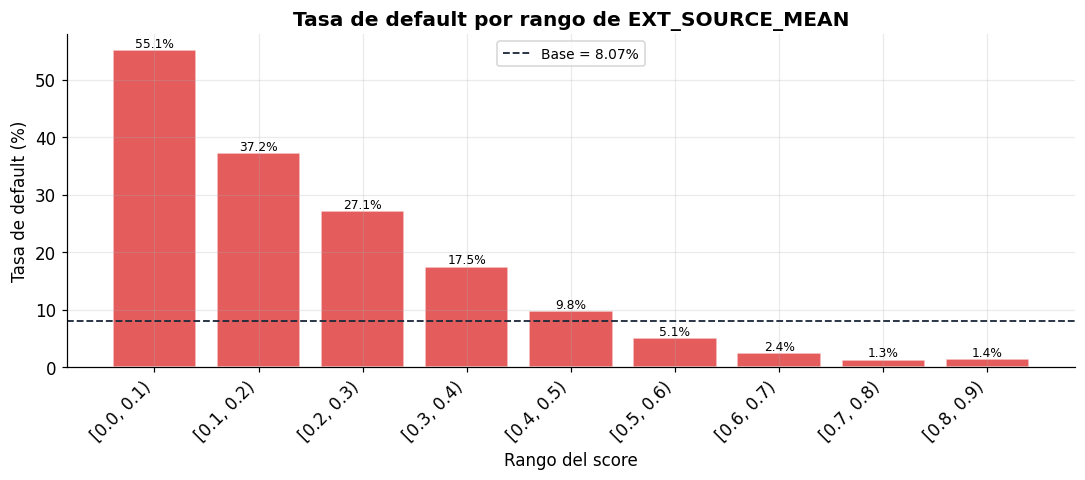

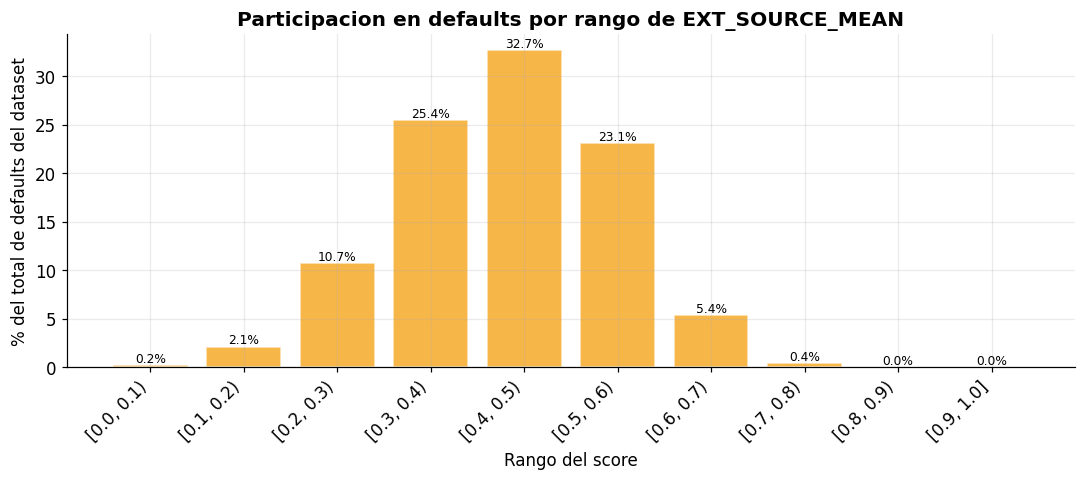


Interpretacion:
  Mayor tasa de default     : [0.0, 0.1) (55.10%, lift=6.83x)
  Mayor cantidad de defaults: [0.4, 0.5) (8,110 casos)
  Mayor participacion       : [0.4, 0.5) (32.67% del total de defaults)


In [19]:
score_df = df[[SCORE_COL, 'TARGET']].copy()
score_df[SCORE_COL] = pd.to_numeric(score_df[SCORE_COL], errors='coerce')
score_df = score_df.dropna(subset=[SCORE_COL])

score_df['rango_score'] = pd.cut(
    score_df[SCORE_COL],
    bins=edges,
    labels=labels,
    include_lowest=True,
    ordered=True,
)

total_defaults_score = int((score_df['TARGET'] == 1).sum())
base_default = score_df['TARGET'].mean()

resumen_score_default = (
    score_df.groupby('rango_score', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
    .reset_index()
    .rename(columns={'rango_score': 'rango'})
)
resumen_score_default['clientes_default'] = resumen_score_default['clientes_default'].astype(int)
resumen_score_default['tasa_default_pct'] = (
    resumen_score_default['clientes_default'] / resumen_score_default['total_clientes'] * 100
).round(2)
resumen_score_default['participacion_en_defaults_pct'] = (
    resumen_score_default['clientes_default'] / total_defaults_score * 100
).round(2)
resumen_score_default['lift'] = (
    resumen_score_default['tasa_default_pct'] / (base_default * 100)
).round(2)

print(f'Base de default global: {base_default * 100:.2f}%  |  Total defaults: {total_defaults_score:,}')
print(f'\nResumen por rango de {SCORE_COL}:')
print(resumen_score_default.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Cantidad de defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default * 100:.2f}%')
for b, v in zip(barras, resumen_score_default['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Tasa de default por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.bar(
    resumen_score_default['rango'],
    resumen_score_default['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_score_default['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=8)
ax.set_title(f'Participacion en defaults por rango de {SCORE_COL}')
ax.set_xlabel('Rango del score')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()

r_tasa = resumen_score_default.loc[resumen_score_default['tasa_default_pct'].idxmax()]
r_cant = resumen_score_default.loc[resumen_score_default['clientes_default'].idxmax()]
r_part = resumen_score_default.loc[resumen_score_default['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')


### Detalle de defaults entre 0.50 y 0.60 (`EXT_SOURCE_MEAN`)

Intervalos de **0.01** en `[0.50, 0.60]`; solo `TARGET = 1` (mismo corte que en los scores individuales).


Segmento EXT_SOURCE_MEAN en [0.50, 0.60]: 113,168 clientes | 5,730 defaults

Cantidad de defaults por centésima:
       rango  clientes_default  participacion_pct
[0.50, 0.51)               743              12.97
[0.51, 0.52)               705              12.30
[0.52, 0.53)               678              11.83
[0.53, 0.54)               666              11.62
[0.54, 0.55)               608              10.61
[0.55, 0.56)               597              10.42
[0.56, 0.57)               531               9.27
[0.57, 0.58)               468               8.17
[0.58, 0.59)               424               7.40
[0.59, 0.60]               310               5.41


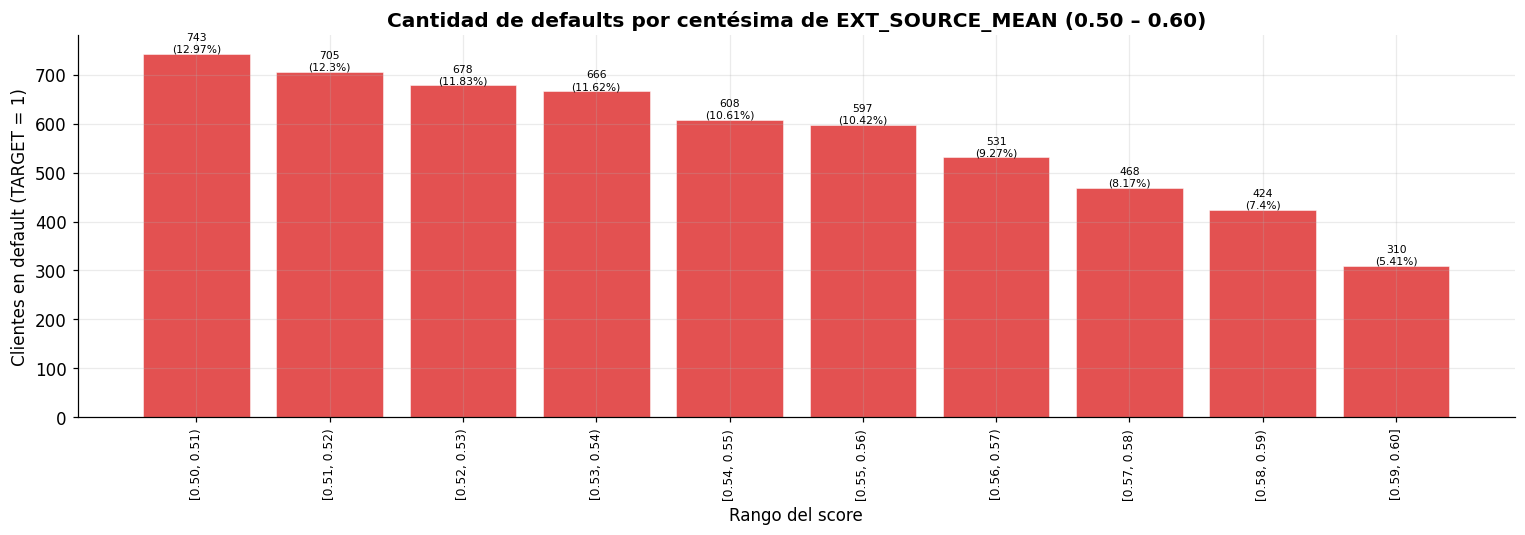


Pico de defaults: [0.50, 0.51) (743 casos, 12.97% del subtotal 0.5–0.6)


In [20]:
edges_fine = np.arange(0.50, 0.601, 0.01)
labels_fine = [
    f'[{edges_fine[i]:.2f}, {edges_fine[i + 1]:.2f})'
    for i in range(len(edges_fine) - 1)
]
labels_fine[-1] = f'[{edges_fine[-2]:.2f}, {edges_fine[-1]:.2f}]'

detalle_score = df[[SCORE_COL, 'TARGET']].copy()
detalle_score[SCORE_COL] = pd.to_numeric(detalle_score[SCORE_COL], errors='coerce')
detalle_score = detalle_score.dropna(subset=[SCORE_COL])
detalle_score = detalle_score[
    (detalle_score[SCORE_COL] >= 0.5) & (detalle_score[SCORE_COL] <= 0.6)
]

defaults_det = detalle_score[detalle_score['TARGET'] == 1].copy()
defaults_det['rango_fino'] = pd.cut(
    defaults_det[SCORE_COL],
    bins=edges_fine,
    labels=labels_fine,
    include_lowest=True,
    ordered=True,
)

resumen_fino = (
    defaults_det.groupby('rango_fino', observed=False)
    .size()
    .reset_index(name='clientes_default')
    .rename(columns={'rango_fino': 'rango'})
)
resumen_fino['clientes_default'] = resumen_fino['clientes_default'].astype(int)
total_defaults_fino = int(resumen_fino['clientes_default'].sum())
if total_defaults_fino > 0:
    resumen_fino['participacion_pct'] = (
        resumen_fino['clientes_default'] / total_defaults_fino * 100
    ).round(2)
else:
    resumen_fino['participacion_pct'] = 0.0

n_clientes_fino = len(detalle_score)
n_defaults_fino = len(defaults_det)

print(
    f'Segmento {SCORE_COL} en [0.50, 0.60]: '
    f'{n_clientes_fino:,} clientes | {n_defaults_fino:,} defaults'
)
print('\nCantidad de defaults por centésima:')
print(resumen_fino.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
barras = ax.bar(
    resumen_fino['rango'],
    resumen_fino['clientes_default'],
    color=RISK,
    alpha=0.8,
    edgecolor='white',
    linewidth=0.4,
)
for b, cnt, pct in zip(
    barras,
    resumen_fino['clientes_default'],
    resumen_fino['participacion_pct'],
):
    if cnt > 0:
        ax.text(
            b.get_x() + b.get_width() / 2,
            cnt,
            f'{cnt:,}\n({pct}%)',
            ha='center',
            va='bottom',
            fontsize=7,
        )
ax.set_title(
    f'Cantidad de defaults por centésima de {SCORE_COL} (0.50 – 0.60)'
)
ax.set_xlabel('Rango del score')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=90, ha='center', fontsize=8)
fig.tight_layout()
plt.show()

if total_defaults_fino > 0:
    r_max = resumen_fino.loc[resumen_fino['clientes_default'].idxmax()]
    print(
        f'\nPico de defaults: {r_max["rango"]} '
        f'({r_max["clientes_default"]:,} casos, {r_max["participacion_pct"]:.2f}% del subtotal 0.5–0.6)'
    )
else:
    print('\nSin defaults en el segmento [0.50, 0.60].')


# Demografía: edad y género

La primera celda de edad define `plot_age_normal` (usada también en género y en `Academic degree`). El bloque de tasa por edad y género define `bins_edad`, `labels_edad`, `tasa_default_por_edad` y `plot_tasa_edad`, reutilizados en cruces posteriores con educación.

## Distribucion de la edad de los clientes

Analizamos la distribucion de la variable `AGE_YEARS` (edad en anios) mediante histogramas con una **curva normal ajustada** (media y desviacion estandar de cada grupo). Esto permite comparar visualmente que tan cerca esta cada distribucion de una normal y detectar sesgos.

Se generan tres graficas:

1. **Todos los clientes:** distribucion global de la edad.
2. **Clientes en default (`TARGET = 1`):** edad de quienes incumplieron el pago.
3. **Clientes al dia (`TARGET = 0`):** edad de quienes pagaron correctamente.

La curva normal es solo una referencia teorica `N(media, desviacion)`; la edad no tiene por que seguirla exactamente, pero ayuda a interpretar la forma, el centro y la dispersion de cada grupo.

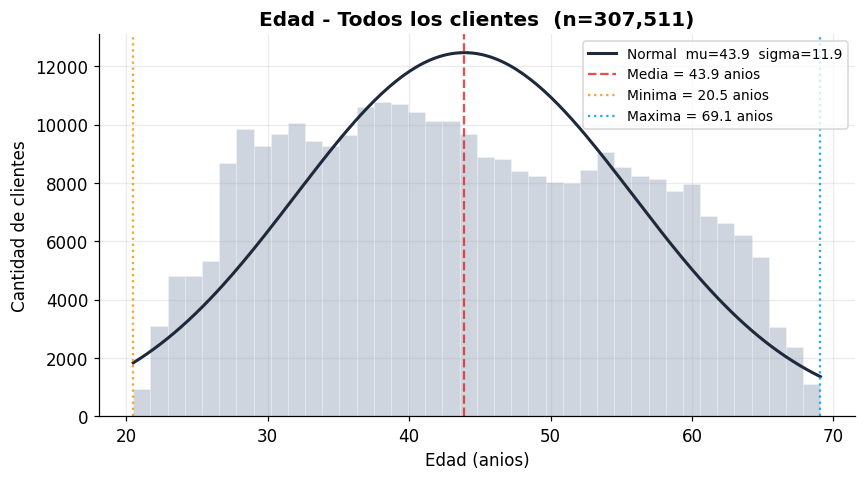

Edad - Todos los clientes
  Edad minima : 20.5
  Edad media  : 43.9
  Edad maxima : 69.1


In [20]:
def plot_age_normal(serie, titulo, color, bins=40):
    """Histograma de edad (cantidad de clientes) con curva normal superpuesta."""
    datos = serie.dropna()
    media, desv = datos.mean(), datos.std()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    counts, edges, _ = ax.hist(datos, bins=bins, color=color, alpha=0.45,
                               edgecolor='white', linewidth=0.4)

    # Escala la curva normal a conteo: pdf * n * ancho_de_bin
    ancho_bin = edges[1] - edges[0]
    x = np.linspace(datos.min(), datos.max(), 200)
    curva = stats.norm.pdf(x, media, desv) * len(datos) * ancho_bin
    ax.plot(x, curva, color=INK, linewidth=2,
            label=f'Normal  mu={media:.1f}  sigma={desv:.1f}')

    edad_min, edad_max = datos.min(), datos.max()

    ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, alpha=0.8,
               label=f'Media = {media:.1f} anios')
    ax.axvline(edad_min, color=ACCENT, linestyle=':', linewidth=1.5, alpha=0.9,
               label=f'Minima = {edad_min:.1f} anios')
    ax.axvline(edad_max, color=SAFE, linestyle=':', linewidth=1.5, alpha=0.9,
               label=f'Maxima = {edad_max:.1f} anios')

    ax.set_title(f'{titulo}  (n={len(datos):,})')
    ax.set_xlabel('Edad (anios)')
    ax.set_ylabel('Cantidad de clientes')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    print(f'{titulo}')
    print(f'  Edad minima : {edad_min:.1f}')
    print(f'  Edad media  : {media:.1f}')
    print(f'  Edad maxima : {edad_max:.1f}')


plot_age_normal(df['AGE_YEARS'], 'Edad - Todos los clientes', BASE)

### Edad de los clientes en default (`TARGET = 1`)

Distribucion de edad solo para los clientes que **incumplieron el pago**.

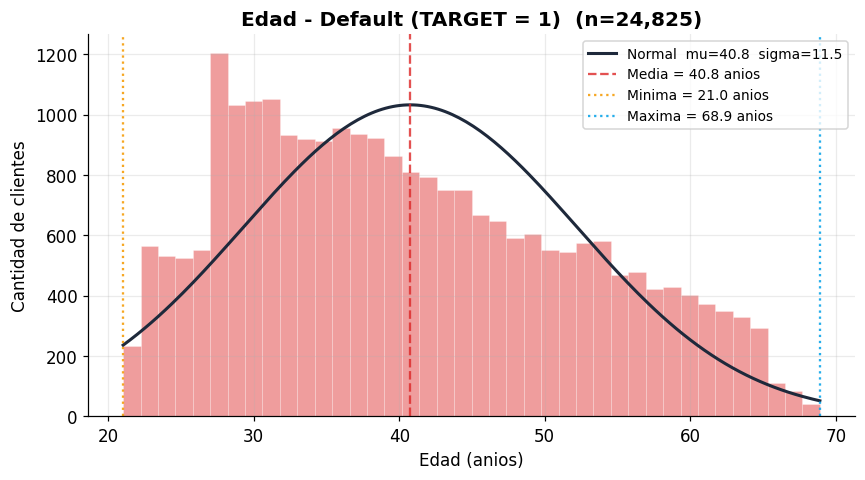

Edad - Default (TARGET = 1)
  Edad minima : 21.0
  Edad media  : 40.8
  Edad maxima : 68.9


In [21]:
plot_age_normal(df.loc[df['TARGET'] == 1, 'AGE_YEARS'], 'Edad - Default (TARGET = 1)', RISK)

### Edad de los clientes al dia (`TARGET = 0`)

Distribucion de edad solo para los clientes que **pagaron correctamente**.

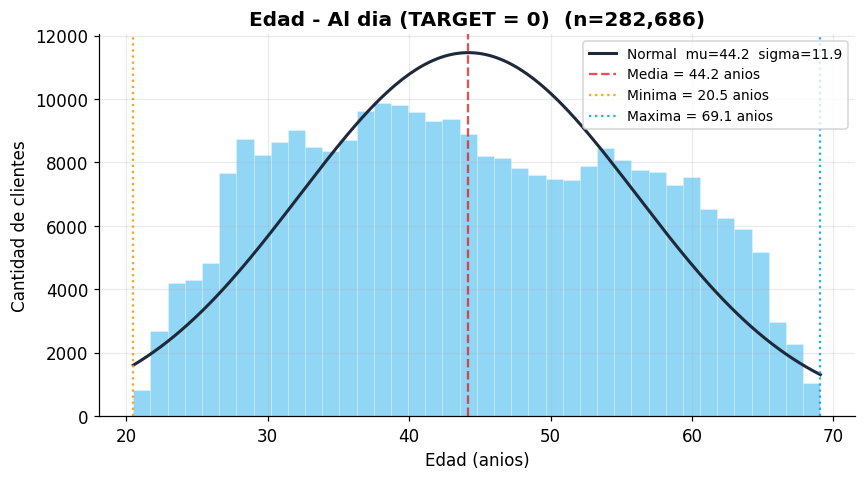

Edad - Al dia (TARGET = 0)
  Edad minima : 20.5
  Edad media  : 44.2
  Edad maxima : 69.1
Resumen de edad por grupo:
                minima  media     maxima         n
grupo                                             
Al dia (0)   20.500000   44.2  69.100000  282686.0
Default (1)  21.000000   40.8  68.900000   24825.0
Todos        20.503765   43.9  69.073238  307511.0


In [22]:
plot_age_normal(df.loc[df['TARGET'] == 0, 'AGE_YEARS'], 'Edad - Al dia (TARGET = 0)', SAFE)

resumen_edad = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo')['AGE_YEARS']
    .agg(minima='min', media='mean', maxima='max', n='count')
    .round(1)
)
resumen_edad.loc['Todos'] = [
    df['AGE_YEARS'].min(), round(df['AGE_YEARS'].mean(), 1),
    df['AGE_YEARS'].max(), df['AGE_YEARS'].count(),
]

print('Resumen de edad por grupo:')
print(resumen_edad.to_string())

### Clientes en default por rango de edad (de 5 en 5)

Contamos cuantos clientes que **incumplieron** (`TARGET = 1`) caen en cada rango de edad de 5 anios: `[20, 25)`, `[25, 30)`, ... hasta `[65, 70)`. Cada rango incluye el limite inferior y excluye el superior.

Clientes en default (TARGET = 1) por rango de edad:
---------------------------------------------
  20 a 25 anios :  1,504
  25 a 30 anios :  3,667
  30 a 35 anios :  4,054
  35 a 40 anios :  3,843
  40 a 45 anios :  3,242
  45 a 50 anios :  2,611
  50 a 55 anios :  2,335
  55 a 60 anios :  1,833
  60 a 65 anios :  1,448
  65 a 70 anios :    288
---------------------------------------------
  Total en rangos 20-70  : 24,825
  Total default          : 24,825


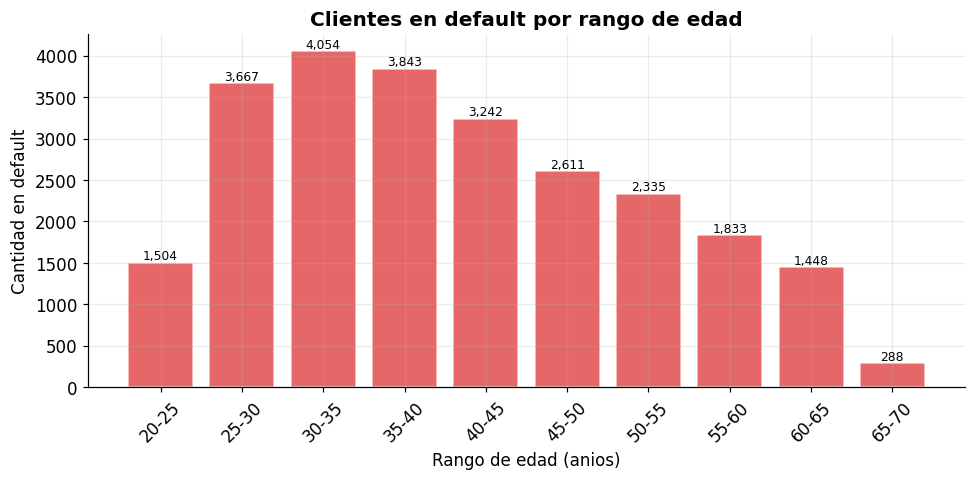

In [32]:
default = df.loc[df['TARGET'] == 1, 'AGE_YEARS'].dropna()

rangos = list(range(20, 75, 5))  # 20, 25, 30, ... 70
conteo = pd.cut(default, bins=rangos, right=False).value_counts().sort_index()

print('Clientes en default (TARGET = 1) por rango de edad:')
print('-' * 45)
for intervalo, cantidad in conteo.items():
    print(f'  {int(intervalo.left):>2} a {int(intervalo.right):>2} anios : {cantidad:>6,}')
print('-' * 45)
print(f'  Total en rangos 20-70  : {conteo.sum():>6,}')
print(f'  Total default          : {len(default):>6,}')

fig, ax = plt.subplots(figsize=(9, 4.5))
etiquetas = [f'{int(i.left)}-{int(i.right)}' for i in conteo.index]
ax.bar(etiquetas, conteo.values, color=RISK, alpha=0.7, edgecolor='white')
for x, v in enumerate(conteo.values):
    ax.text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Clientes en default por rango de edad')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Cantidad en default')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Clientes al dia por rango de edad (de 5 en 5)

Mismo analisis pero para los clientes que **pagaron correctamente** (`TARGET = 0`), agrupados en rangos de edad de 5 anios desde `[20, 25)` hasta `[65, 70)`.

Clientes al dia (TARGET = 0) por rango de edad:
---------------------------------------------
  20 a 25 anios : 10,729
  25 a 30 anios : 29,286
  30 a 35 anios : 35,422
  35 a 40 anios : 39,012
  40 a 45 anios : 38,164
  45 a 50 anios : 32,582
  50 a 55 anios : 32,662
  55 a 60 anios : 31,264
  60 a 65 anios : 25,977
  65 a 70 anios :  7,588
---------------------------------------------
  Total en rangos 20-70  : 282,686
  Total al dia           : 282,686


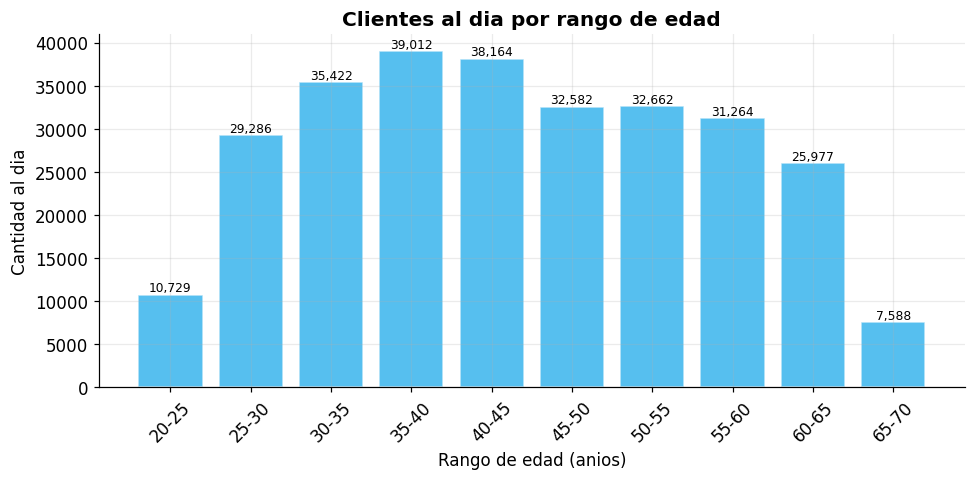

In [24]:
al_dia = df.loc[df['TARGET'] == 0, 'AGE_YEARS'].dropna()

rangos = list(range(20, 75, 5))  # 20, 25, 30, ... 70
conteo_al_dia = pd.cut(al_dia, bins=rangos, right=False).value_counts().sort_index()

print('Clientes al dia (TARGET = 0) por rango de edad:')
print('-' * 45)
for intervalo, cantidad in conteo_al_dia.items():
    print(f'  {int(intervalo.left):>2} a {int(intervalo.right):>2} anios : {cantidad:>6,}')
print('-' * 45)
print(f'  Total en rangos 20-70  : {conteo_al_dia.sum():>6,}')
print(f'  Total al dia           : {len(al_dia):>6,}')

fig, ax = plt.subplots(figsize=(9, 4.5))
etiquetas = [f'{int(i.left)}-{int(i.right)}' for i in conteo_al_dia.index]
ax.bar(etiquetas, conteo_al_dia.values, color=SAFE, alpha=0.7, edgecolor='white')
for x, v in enumerate(conteo_al_dia.values):
    ax.text(x, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Clientes al dia por rango de edad')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Cantidad al dia')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## Tasa de default vs. participacion por rango de edad

La grafica de **cantidad absoluta** de defaults indica donde hay mas casos de incumplimiento, pero puede ser **enganosa**: un rango con muchos clientes tendra muchos defaults solo por tamano, aunque su riesgo proporcional sea bajo.

Para evaluar bien el riesgo conviene mirar dos metricas distintas, que responden preguntas diferentes:

- **Tasa de default (`tasa_default_pct`)**: de cada rango, que porcentaje incumplio. Permite comparar el **riesgo proporcional** entre grupos, sin importar su tamano.
- **Participacion en defaults (`participacion_en_defaults_pct`)**: que porcentaje del total de defaults del dataset aporta cada rango. Permite ver donde se **concentra el volumen** de incumplimientos.

**Ejemplo:**

```text
Grupo 30-35: 4.000 defaults entre 40.000 clientes -> tasa = 10%
Grupo 20-25: 1.500 defaults entre  8.000 clientes -> tasa = 18,75%
```

Aunque el grupo 30-35 tiene **mas casos absolutos**, el grupo 20-25 es **proporcionalmente mas riesgoso**. La tasa mide riesgo; la participacion mide volumen. Para gestion de riesgo crediticio, ambas son complementarias.

Resumen por rango de edad:
AGE_RANGE  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct
    20-25           12233              1504             12.29                           6.06
    25-30           32953              3667             11.13                          14.77
    30-35           39476              4054             10.27                          16.33
    35-40           42855              3843              8.97                          15.48
    40-45           41406              3242              7.83                          13.06
    45-50           35193              2611              7.42                          10.52
    50-55           34997              2335              6.67                           9.41
    55-60           33097              1833              5.54                           7.38
    60-65           27425              1448              5.28                           5.83
    65-70            7876               288

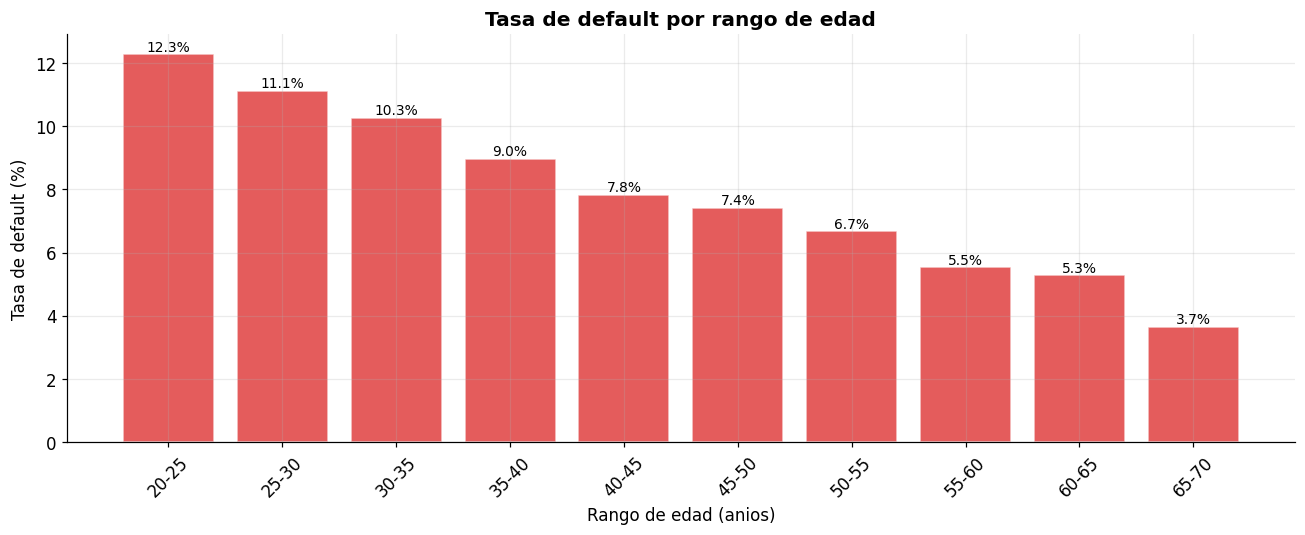

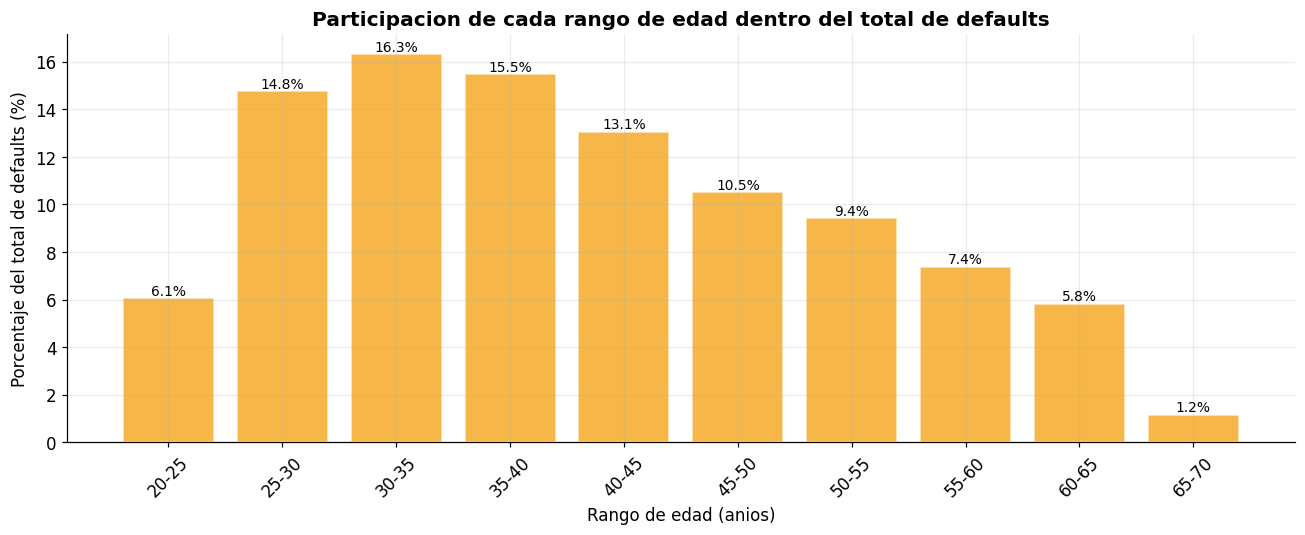


Interpretacion:
  Mayor tasa de default     : 20-25 (12.29%)
  Mayor cantidad de defaults: 30-35 (4,054 casos)
  Mayor participacion       : 30-35 (16.33% del total de defaults)


In [29]:
# Trabajamos sobre una copia para no modificar el df original.
edad = df[['AGE_YEARS', 'TARGET']].copy()

# Rangos de edad de 5 anios: 20-25, 25-30, ... 65-70.
bins = list(range(20, 75, 5))
etiquetas = [f'{b}-{b + 5}' for b in bins[:-1]]

# Clientes fuera de [20, 70) quedan como NaN y se excluyen del analisis por rango.
edad['AGE_RANGE'] = pd.cut(edad['AGE_YEARS'], bins=bins, right=False,
                           labels=etiquetas, ordered=True)

total_defaults = int((edad['TARGET'] == 1).sum())

# Tabla resumen por rango de edad.
resumen = (
    edad.groupby('AGE_RANGE', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)
resumen['participacion_en_defaults_pct'] = (
    resumen['clientes_default'] / total_defaults * 100
).round(2)

resumen = resumen.reset_index()

print('Resumen por rango de edad:')
print(resumen.to_string(index=False))

# --- Grafica 1: tasa de default por rango de edad ---
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(resumen['AGE_RANGE'], resumen['tasa_default_pct'],
                color=RISK, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Tasa de default por rango de edad')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Tasa de default (%)')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

# --- Grafica 2: participacion de cada rango dentro del total de defaults ---
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(resumen['AGE_RANGE'], resumen['participacion_en_defaults_pct'],
                color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Participacion de cada rango de edad dentro del total de defaults')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Porcentaje del total de defaults (%)')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

# Interpretacion breve.
r_tasa = resumen.loc[resumen['tasa_default_pct'].idxmax()]
r_cant = resumen.loc[resumen['clientes_default'].idxmax()]
r_part = resumen.loc[resumen['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["AGE_RANGE"]} ({r_tasa["tasa_default_pct"]:.2f}%)')
print(f'  Mayor cantidad de defaults: {r_cant["AGE_RANGE"]} ({int(r_cant["clientes_default"]):,} casos)')
print(f'  Mayor participacion       : {r_part["AGE_RANGE"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')

## Distribucion de la edad por genero (`CODE_GENDER`)

`CODE_GENDER` es una variable categorica (`M` = hombre, `F` = mujer), por lo que la distribucion normal se aplica sobre la **edad** de cada grupo, no sobre el genero en si.

Se generan dos graficas separadas, cada una con su curva normal ajustada y las lineas de edad **minima**, **media** y **maxima**:

1. **Hombres (`CODE_GENDER = 'M'`).**
2. **Mujeres (`CODE_GENDER = 'F'`).**

Se excluyen los pocos registros con `XNA`.

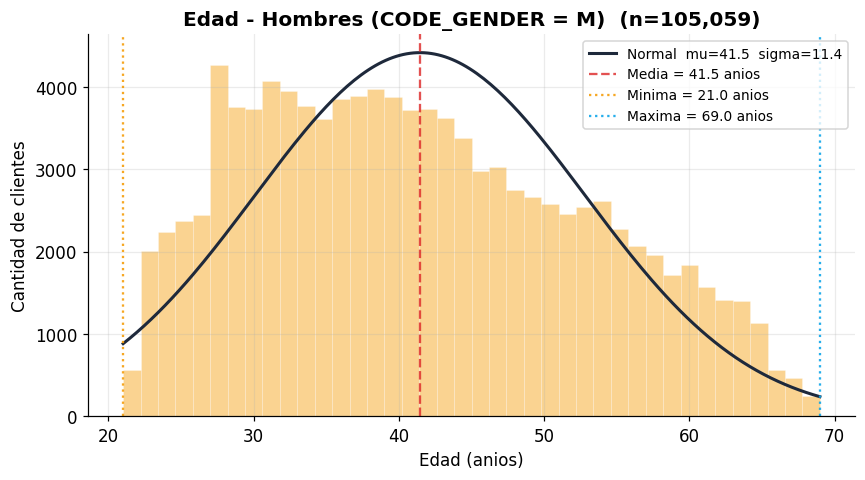

Edad - Hombres (CODE_GENDER = M)
  Edad minima : 21.0
  Edad media  : 41.5
  Edad maxima : 69.0


In [26]:
plot_age_normal(df.loc[df['CODE_GENDER'] == 'M', 'AGE_YEARS'], 'Edad - Hombres (CODE_GENDER = M)', ACCENT)

### Mujeres (`CODE_GENDER = 'F'`)

Distribucion de edad solo para las clientes mujeres.

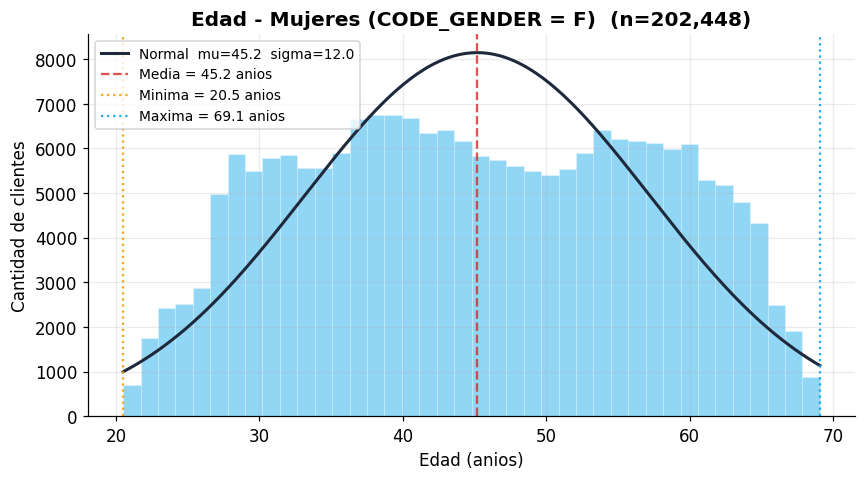

Edad - Mujeres (CODE_GENDER = F)
  Edad minima : 20.5
  Edad media  : 45.2
  Edad maxima : 69.1
Resumen de edad por genero:
             minima  media  maxima       n
CODE_GENDER                               
F              20.5   45.2    69.1  202448
M              21.0   41.5    69.0  105059


In [27]:
plot_age_normal(df.loc[df['CODE_GENDER'] == 'F', 'AGE_YEARS'], 'Edad - Mujeres (CODE_GENDER = F)', SAFE)

resumen_genero = (
    df[df['CODE_GENDER'].isin(['M', 'F'])]
    .groupby('CODE_GENDER')['AGE_YEARS']
    .agg(minima='min', media='mean', maxima='max', n='count')
    .round(1)
)
print('Resumen de edad por genero:')
print(resumen_genero.to_string())

### Total de clientes por genero

Cantidad total de hombres y mujeres en el dataset.

Total de clientes por genero:
-----------------------------------
  Hombres (M) : 105,059  (34.2%)
  Mujeres (F) : 202,448  (65.8%)
-----------------------------------
  Total       : 307,507


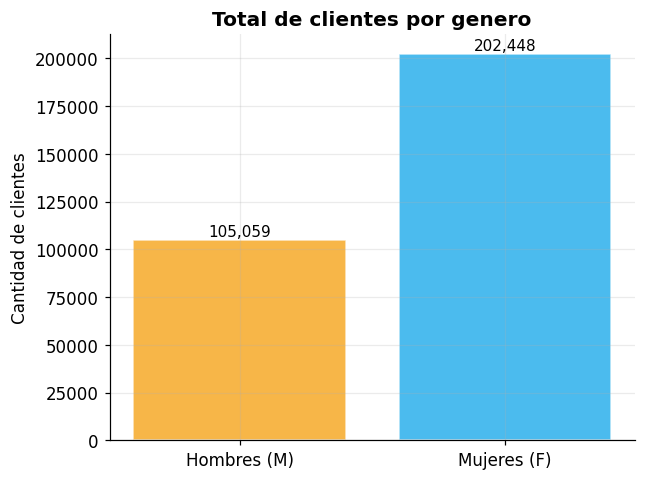

In [28]:
total_hombres = (df['CODE_GENDER'] == 'M').sum()
total_mujeres = (df['CODE_GENDER'] == 'F').sum()
total = total_hombres + total_mujeres

print('Total de clientes por genero:')
print('-' * 35)
print(f'  Hombres (M) : {total_hombres:>7,}  ({total_hombres / total * 100:.1f}%)')
print(f'  Mujeres (F) : {total_mujeres:>7,}  ({total_mujeres / total * 100:.1f}%)')
print('-' * 35)
print(f'  Total       : {total:>7,}')

fig, ax = plt.subplots(figsize=(6, 4.5))
barras = ax.bar(['Hombres (M)', 'Mujeres (F)'], [total_hombres, total_mujeres],
                color=[ACCENT, SAFE], alpha=0.75, edgecolor='white')
for b, v in zip(barras, [total_hombres, total_mujeres]):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Total de clientes por genero')
ax.set_ylabel('Cantidad de clientes')
fig.tight_layout()
plt.show()

## Tasa de default por genero (`CODE_GENDER`)

Comparamos el **riesgo proporcional** entre hombres y mujeres:

```text
Tasa de default = clientes con TARGET = 1 del genero / total del genero x 100
```

Asi vemos quien incumple en mayor proporcion, sin que influya que haya mas mujeres que hombres en el dataset. Se excluyen los pocos registros `XNA`.

Tasa de default por genero:
             total_clientes  clientes_default  tasa_default_pct
CODE_GENDER                                                    
Hombres (M)          105059             10655             10.14
Mujeres (F)          202448             14170              7.00

Tasa base (todo el dataset): 8.07%


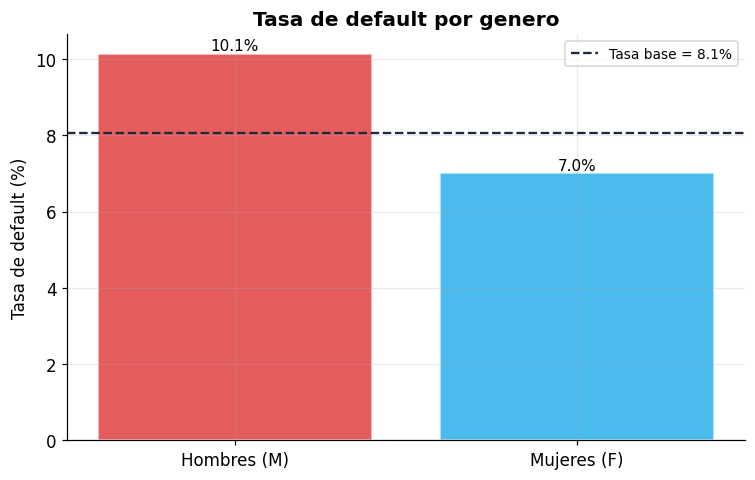


Mayor tasa de default: Hombres (M) (10.14%)


In [35]:
genero = df[df['CODE_GENDER'].isin(['M', 'F'])]

resumen_genero = (
    genero.groupby('CODE_GENDER')['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
)
resumen_genero['tasa_default_pct'] = (
    resumen_genero['clientes_default'] / resumen_genero['total_clientes'] * 100
).round(2)
resumen_genero.index = resumen_genero.index.map({'M': 'Hombres (M)', 'F': 'Mujeres (F)'})
resumen_genero = resumen_genero.sort_values('tasa_default_pct', ascending=False)

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default por genero:')
print(resumen_genero.to_string())
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(7, 4.5))
colores = [RISK if 'Hombres' in g else SAFE for g in resumen_genero.index]
barras = ax.bar(resumen_genero.index, resumen_genero['tasa_default_pct'],
                color=colores, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen_genero['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por genero')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

mayor = resumen_genero['tasa_default_pct'].idxmax()
print(f'\nMayor tasa de default: {mayor} ({resumen_genero.loc[mayor, "tasa_default_pct"]:.2f}%)')

## Tasa de default por rango de edad, separada por genero

Usamos los rangos de edad de 5 en 5 (`20-25`, ..., `65-70`) y calculamos la **tasa de default** dentro de cada rango, por separado para mujeres y hombres:

```text
Tasa de default = clientes con TARGET = 1 en el rango / total del rango x 100
```

Asi vemos si el riesgo segun la edad se comporta distinto entre generos.

1. **Mujeres** (`CODE_GENDER = 'F'`).
2. **Hombres** (`CODE_GENDER = 'M'`).

Mujeres - tasa de default por rango de edad:
AGE_RANGE  total_clientes  clientes_default  tasa_default_pct
    20-25            6679               765             11.45
    25-30           18970              1960             10.33
    30-35           23391              2205              9.43
    35-40           26728              2160              8.08
    40-45           26317              1841              7.00
    45-50           23319              1472              6.31
    50-55           24502              1353              5.52
    55-60           24848              1164              4.68
    60-65           21322              1046              4.91
    65-70            6372               204              3.20


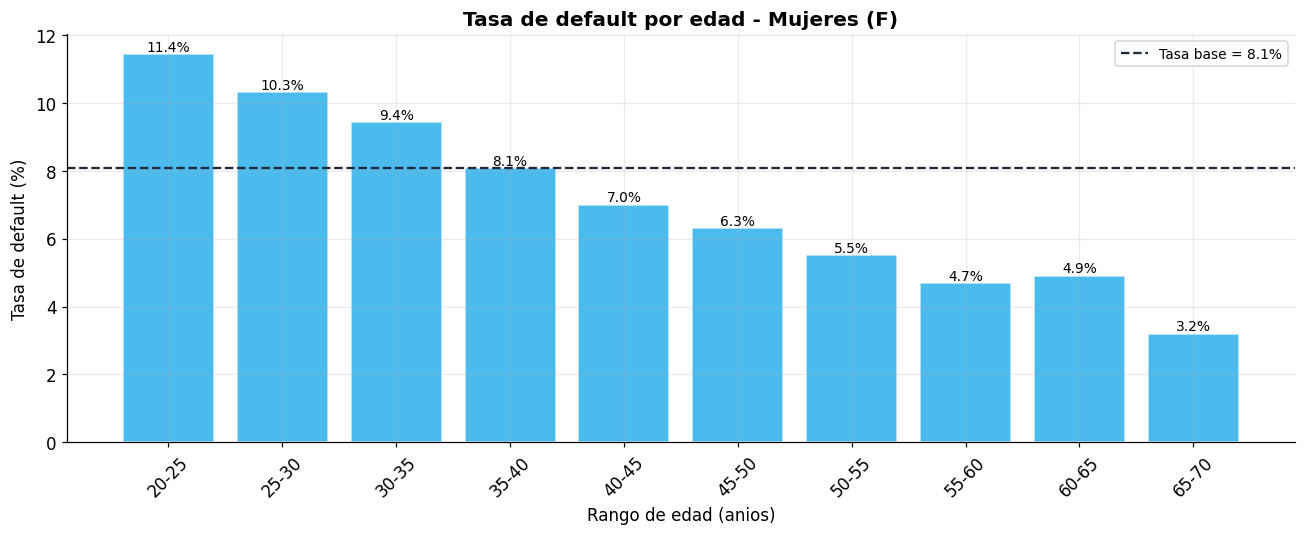

In [39]:
bins_edad = list(range(20, 75, 5))  # 20, 25, ... 70
labels_edad = [f'{b}-{b + 5}' for b in bins_edad[:-1]]
tasa_base = (df['TARGET'] == 1).mean() * 100


def tasa_default_por_edad(genero_cod):
    sub = df[df['CODE_GENDER'] == genero_cod][['AGE_YEARS', 'TARGET']].copy()
    sub['AGE_RANGE'] = pd.cut(sub['AGE_YEARS'], bins=bins_edad, right=False,
                              labels=labels_edad, ordered=True)
    res = (
        sub.groupby('AGE_RANGE', observed=False)['TARGET']
        .agg(total_clientes='size', clientes_default='sum')
    )
    res['tasa_default_pct'] = (res['clientes_default'] / res['total_clientes'] * 100).round(2)
    return res.reset_index()


def plot_tasa_edad(res, titulo, color):
    fig, ax = plt.subplots(figsize=(12, 5))
    barras = ax.bar(res['AGE_RANGE'], res['tasa_default_pct'],
                    color=color, alpha=0.75, edgecolor='white')
    for b, v in zip(barras, res['tasa_default_pct']):
        if pd.notna(v):
            ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
                    ha='center', va='bottom', fontsize=9)
    ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
               label=f'Tasa base = {tasa_base:.1f}%')
    ax.set_title(titulo)
    ax.set_xlabel('Rango de edad (anios)')
    ax.set_ylabel('Tasa de default (%)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=9)
    plt.xticks(rotation=45)
    fig.tight_layout()
    plt.show()


res_mujeres = tasa_default_por_edad('F')
print('Mujeres - tasa de default por rango de edad:')
print(res_mujeres.to_string(index=False))
plot_tasa_edad(res_mujeres, 'Tasa de default por edad - Mujeres (F)', SAFE)

### Hombres (`CODE_GENDER = 'M'`)

Tasa de default por rango de edad para los clientes hombres.

Hombres - tasa de default por rango de edad:
AGE_RANGE  total_clientes  clientes_default  tasa_default_pct
    20-25            5554               739             13.31
    25-30           13981              1707             12.21
    30-35           16085              1849             11.50
    35-40           16126              1683             10.44
    40-45           15089              1401              9.28
    45-50           11874              1139              9.59
    50-55           10495               982              9.36
    55-60            8248               669              8.11
    60-65            6103               402              6.59
    65-70            1504                84              5.59


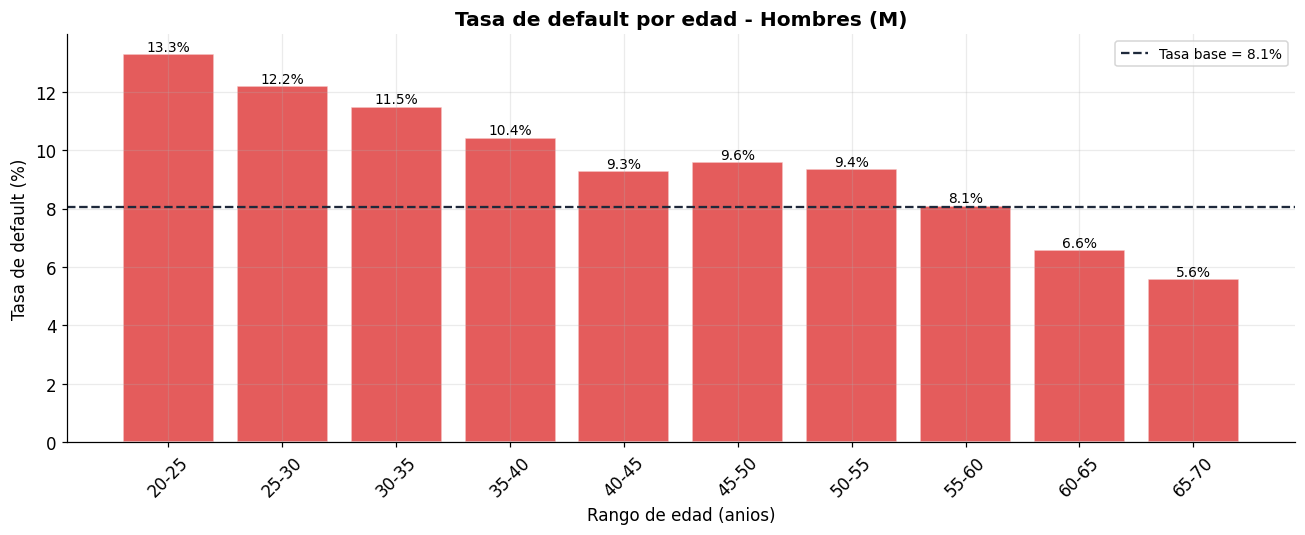

In [40]:
res_hombres = tasa_default_por_edad('M')
print('Hombres - tasa de default por rango de edad:')
print(res_hombres.to_string(index=False))
plot_tasa_edad(res_hombres, 'Tasa de default por edad - Hombres (M)', RISK)

## Cantidad de hombres y mujeres por rango de edad

Comparamos cuantos clientes hay de cada genero en los rangos de edad de 5 en 5 (`20-25`, ..., `65-70`), con barras agrupadas lado a lado.

Cantidad por rango de edad y genero:
CODE_GENDER  Hombres  Mujeres
AGE_RANGE                    
20-25           5554     6679
25-30          13981    18970
30-35          16085    23391
35-40          16126    26728
40-45          15089    26317
45-50          11874    23319
50-55          10495    24502
55-60           8248    24848
60-65           6103    21322
65-70           1504     6372


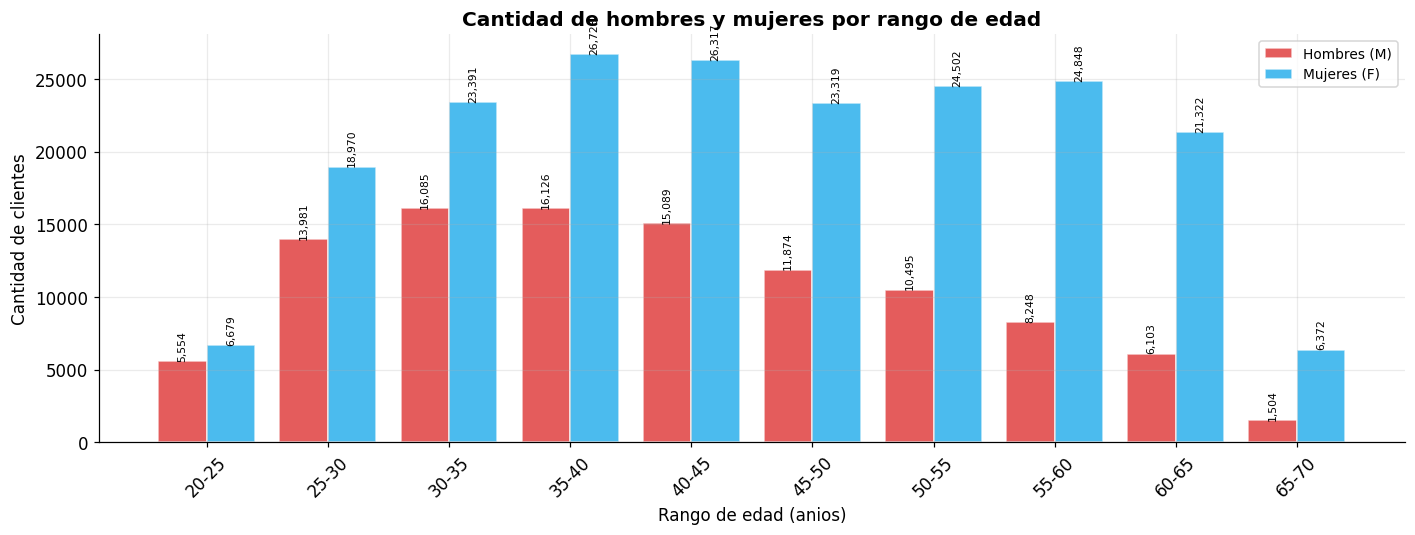

In [44]:
comp = df[df['CODE_GENDER'].isin(['M', 'F'])][['AGE_YEARS', 'CODE_GENDER']].copy()
comp['AGE_RANGE'] = pd.cut(comp['AGE_YEARS'], bins=bins_edad, right=False,
                           labels=labels_edad, ordered=True)

conteo = (
    comp.groupby(['AGE_RANGE', 'CODE_GENDER'], observed=False)
    .size()
    .unstack('CODE_GENDER')
    .reindex(columns=['M', 'F'])
)

print('Cantidad por rango de edad y genero:')
print(conteo.rename(columns={'M': 'Hombres', 'F': 'Mujeres'}).to_string())

x = np.arange(len(labels_edad))
ancho = 0.4

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - ancho / 2, conteo['M'].values, ancho, label='Hombres (M)',
            color=RISK, alpha=0.75, edgecolor='white')
b2 = ax.bar(x + ancho / 2, conteo['F'].values, ancho, label='Mujeres (F)',
            color=SAFE, alpha=0.75, edgecolor='white')

for barras in (b1, b2):
    for b in barras:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h, f'{int(h):,}',
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(labels_edad, rotation=45)
ax.set_title('Cantidad de hombres y mujeres por rango de edad')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# Buró, historial y otras variables numéricas de la solicitud

Variables del buró, del historial de solicitudes y otras numéricas de `application` (días del documento, rating regional). Las distribuciones reutilizan `plot_score_normal` definida en el bloque de scores externos.

## Distribución de `bureau_avg_days_credit`

Promedio de `DAYS_CREDIT` en el buró por cliente. En Home Credit los días suelen ser **negativos** (días antes de la solicitud): valores **más negativos** = créditos en buró **más antiguos** (mayor antigüedad del historial).

Histogramas con curva normal (todos / default / al día) y análisis por **deciles** de la variable.


bureau_avg_days_credit: nulos = 0 (0.00%)


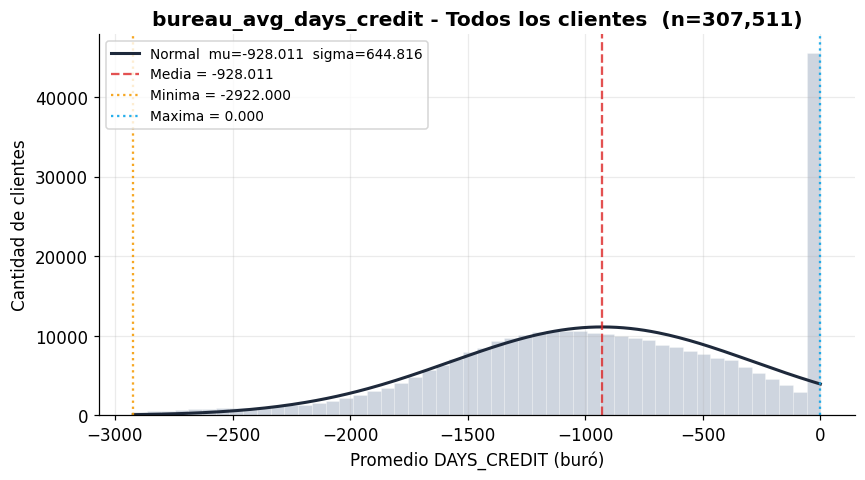

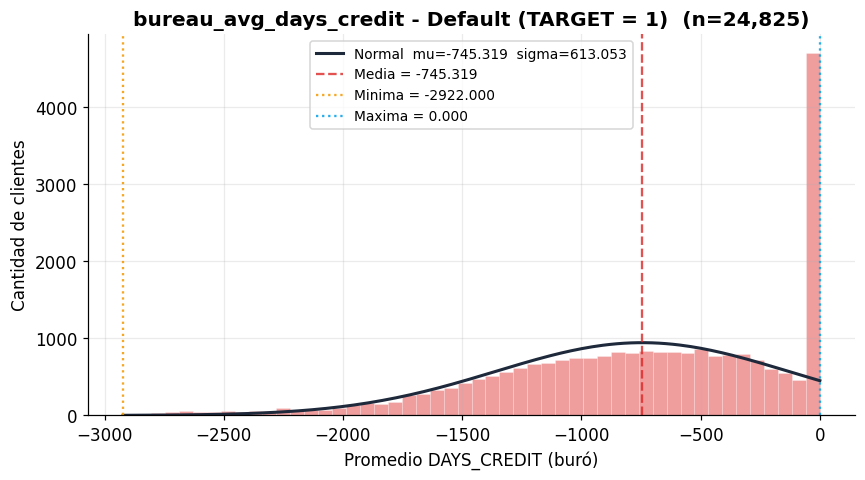

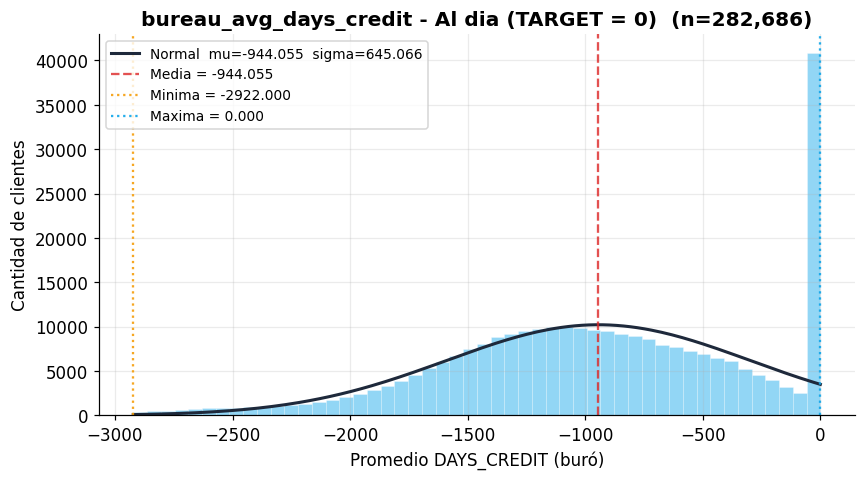


Resumen de bureau_avg_days_credit por grupo:
             minima       media  maxima        desv         n
grupo                                                        
Al dia (0)  -2922.0 -944.099976     0.0  645.099976  282686.0
Default (1) -2922.0 -745.299988     0.0  613.099976   24825.0
Todos       -2922.0 -928.000000     0.0  644.799988  307511.0


In [22]:
COL = 'bureau_avg_days_credit'
COL_LABEL = 'Promedio DAYS_CREDIT (buró)'

if COL not in df.columns:
    raise KeyError(f'La columna {COL} no está en el dataset cargado.')

nulos = int(df[COL].isna().sum())
print(f'{COL}: nulos = {nulos:,} ({nulos / len(df) * 100:.2f}%)')

plot_score_normal(
    df[COL],
    f'{COL} - Todos los clientes',
    BASE,
    xlabel=COL_LABEL,
    bins=50,
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, COL],
    f'{COL} - Default (TARGET = 1)',
    RISK,
    xlabel=COL_LABEL,
    bins=50,
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, COL],
    f'{COL} - Al dia (TARGET = 0)',
    SAFE,
    xlabel=COL_LABEL,
    bins=50,
)

resumen_bureau = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(1)
)
resumen_bureau.loc['Todos'] = [
    round(df[COL].min(), 1), round(df[COL].mean(), 1),
    round(df[COL].max(), 1), round(df[COL].std(), 1), df[COL].count(),
]

print(f'\nResumen de {COL} por grupo:')
print(resumen_bureau.to_string())


### Clientes por decil de `bureau_avg_days_credit`

La variable se parte en **10 deciles** (mismo número de clientes por decil, salvo empates). Las etiquetas muestran el intervalo de días de cada decil.


Distribución de bureau_avg_days_credit por decil (n=307,511):
     rango_label  cantidad  porcentaje
[-2,922, -1,746]     30752        10.0
[-1,746, -1,464]     30751        10.0
[-1,464, -1,270]     30764        10.0
[-1,270, -1,098]     30753        10.0
  [-1,098, -928]     30739        10.0
    [-928, -747]     30748        10.0
    [-747, -542]     30762        10.0
    [-542, -286]     30747        10.0
       [-286, 0]     61495        20.0


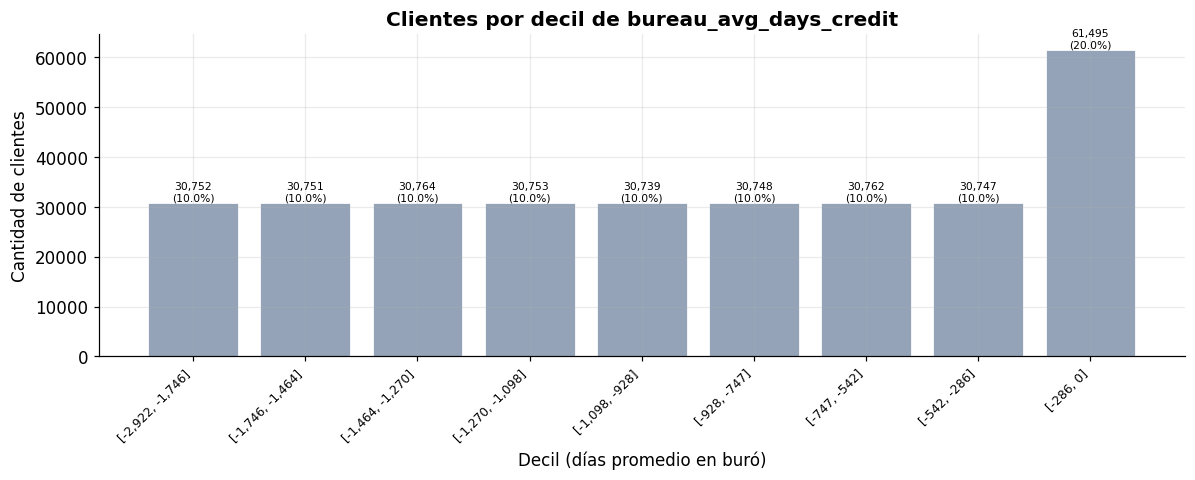

In [23]:
bureau = df[[COL, 'TARGET']].copy()
bureau[COL] = pd.to_numeric(bureau[COL], errors='coerce')
bureau = bureau.dropna(subset=[COL])

bureau['decil'], bins_decil = pd.qcut(
    bureau[COL], q=10, retbins=True, duplicates='drop'
)

def etiqueta_intervalo(left, right):
    return f'[{left:,.0f}, {right:,.0f}]'

intervalos = [
    etiqueta_intervalo(bins_decil[i], bins_decil[i + 1])
    for i in range(len(bins_decil) - 1)
]
mapa_decil = dict(zip(range(1, len(intervalos) + 1), intervalos))
bureau['rango'] = bureau['decil'].cat.codes + 1
bureau['rango_label'] = bureau['rango'].map(mapa_decil)

dist_decil = (
    bureau.groupby(['rango', 'rango_label'], observed=False)
    .size()
    .reset_index(name='cantidad')
    .sort_values('rango')
)
dist_decil['porcentaje'] = (
    dist_decil['cantidad'] / len(bureau) * 100
).round(2)

print(f'Distribución de {COL} por decil (n={len(bureau):,}):')
print(dist_decil[['rango_label', 'cantidad', 'porcentaje']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(
    dist_decil['rango_label'],
    dist_decil['cantidad'],
    color=BASE,
    edgecolor='white',
    linewidth=0.5,
)
ax.set_title(f'Clientes por decil de {COL}')
ax.set_xlabel('Decil (días promedio en buró)')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right', fontsize=8)
for i, (cnt, pct) in enumerate(zip(dist_decil['cantidad'], dist_decil['porcentaje'])):
    ax.text(i, cnt, f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=7)
fig.tight_layout()
plt.show()


### Default por decil de `bureau_avg_days_credit`

- **Cantidad de defaults** por decil.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default: 8.07%  |  Total defaults: 24,825
     rango_label  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[-2,922, -1,746]           30752              1538              5.00                           6.20  0.62
[-1,746, -1,464]           30751              1574              5.12                           6.34  0.63
[-1,464, -1,270]           30764              1741              5.66                           7.01  0.70
[-1,270, -1,098]           30753              1941              6.31                           7.82  0.78
  [-1,098, -928]           30739              2161              7.03                           8.70  0.87
    [-928, -747]           30748              2480              8.07                           9.99  1.00
    [-747, -542]           30762              2902              9.43                          11.69  1.17
    [-542, -286]           30747              3532             11.49                          14.23  1

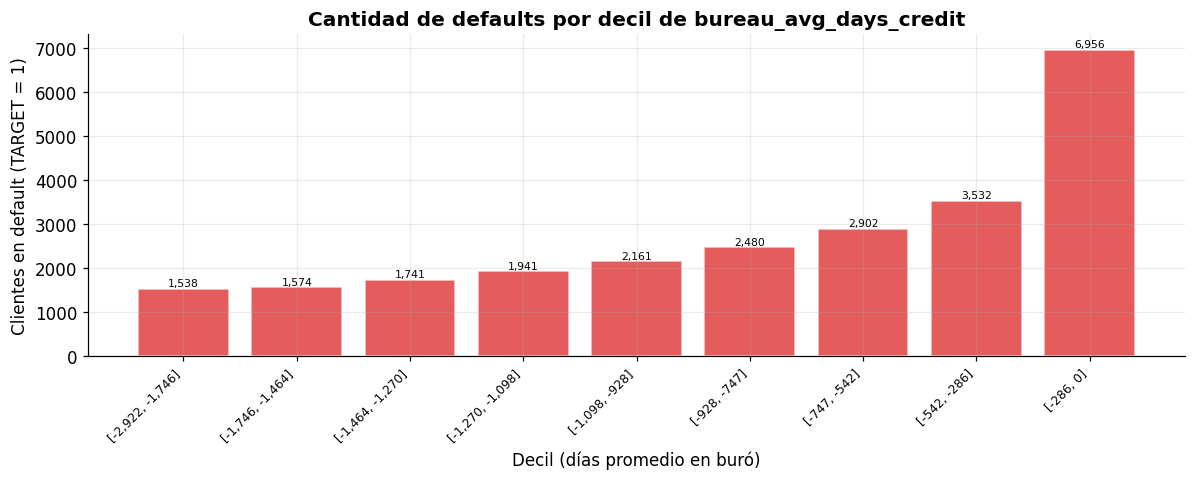

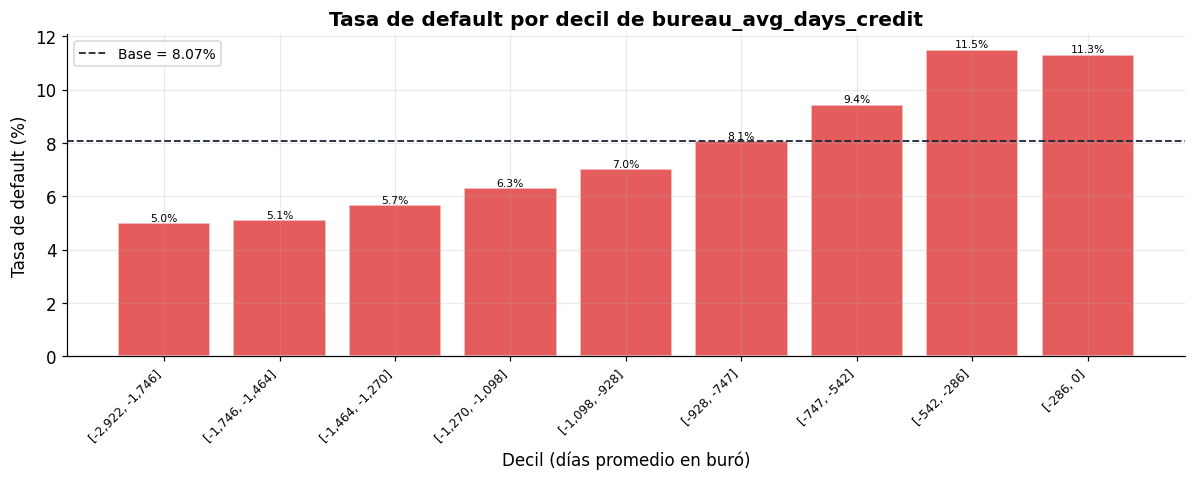

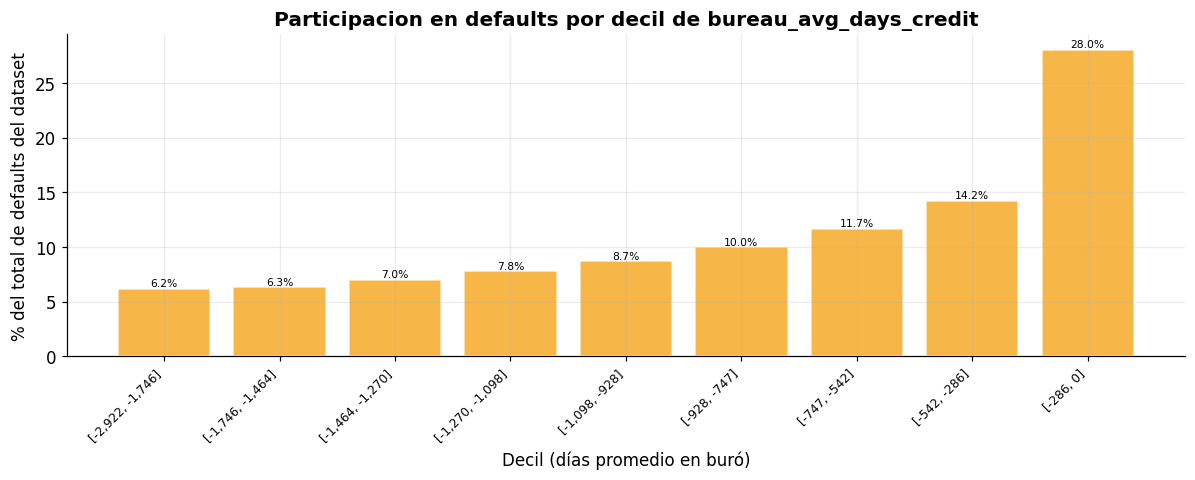


Interpretacion:
  Mayor tasa de default     : [-542, -286] (11.49%, lift=1.42x)
  Mayor cantidad de defaults: [-286, 0] (6,956 casos)
  Mayor participacion       : [-286, 0] (28.02% del total de defaults)


In [24]:
total_defaults_bureau = int((bureau['TARGET'] == 1).sum())
base_default_bureau = bureau['TARGET'].mean()

resumen_default = (
    bureau.groupby(['rango', 'rango_label'], observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
    .reset_index()
    .sort_values('rango')
)
resumen_default['clientes_default'] = resumen_default['clientes_default'].astype(int)
resumen_default['tasa_default_pct'] = (
    resumen_default['clientes_default'] / resumen_default['total_clientes'] * 100
).round(2)
resumen_default['participacion_en_defaults_pct'] = (
    resumen_default['clientes_default'] / total_defaults_bureau * 100
).round(2)
resumen_default['lift'] = (
    resumen_default['tasa_default_pct'] / (base_default_bureau * 100)
).round(2)

print(
    f'Base de default: {base_default_bureau * 100:.2f}%  |  '
    f'Total defaults: {total_defaults_bureau:,}'
)
print(resumen_default[
    ['rango_label', 'total_clientes', 'clientes_default',
     'tasa_default_pct', 'participacion_en_defaults_pct', 'lift']
].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default['rango_label'],
    resumen_default['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Cantidad de defaults por decil de {COL}')
ax.set_xlabel('Decil (días promedio en buró)')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default['rango_label'],
    resumen_default['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default_bureau * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default_bureau * 100:.2f}%')
for b, v in zip(barras, resumen_default['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Tasa de default por decil de {COL}')
ax.set_xlabel('Decil (días promedio en buró)')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default['rango_label'],
    resumen_default['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Participacion en defaults por decil de {COL}')
ax.set_xlabel('Decil (días promedio en buró)')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

r_tasa = resumen_default.loc[resumen_default['tasa_default_pct'].idxmax()]
r_cant = resumen_default.loc[resumen_default['clientes_default'].idxmax()]
r_part = resumen_default.loc[resumen_default['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(
    f'  Mayor tasa de default     : {r_tasa["rango_label"]} '
    f'({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)'
)
print(
    f'  Mayor cantidad de defaults: {r_cant["rango_label"]} '
    f'({r_cant["clientes_default"]:,} casos)'
)
print(
    f'  Mayor participacion       : {r_part["rango_label"]} '
    f'({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)'
)


## Distribución de `DAYS_ID_PUBLISH`

Días transcurridos entre la **publicación del documento de identidad** y la solicitud del crédito. En Home Credit suele expresarse en **días negativos** (respecto a la fecha de la solicitud). Histogramas con curva normal y análisis por **deciles**.


DAYS_ID_PUBLISH: nulos = 0 (0.00%)


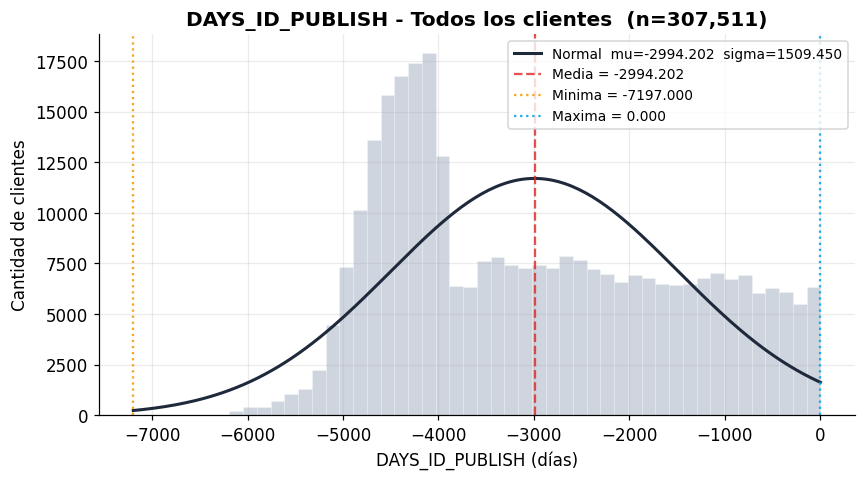

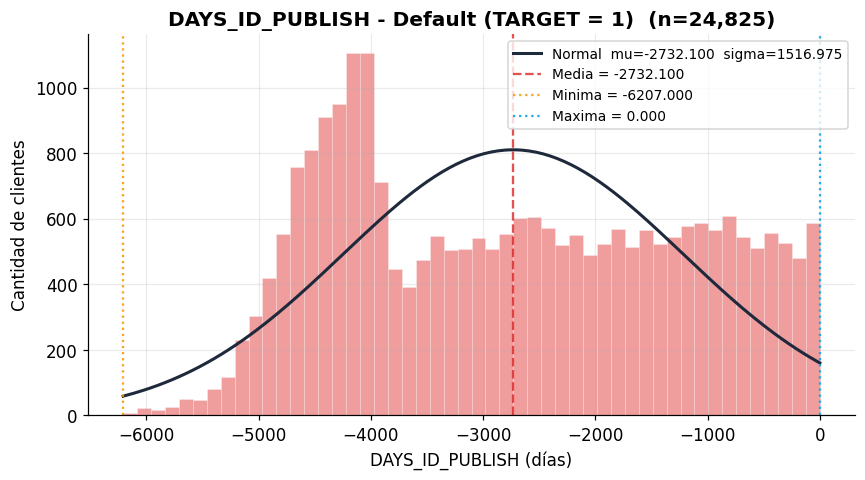

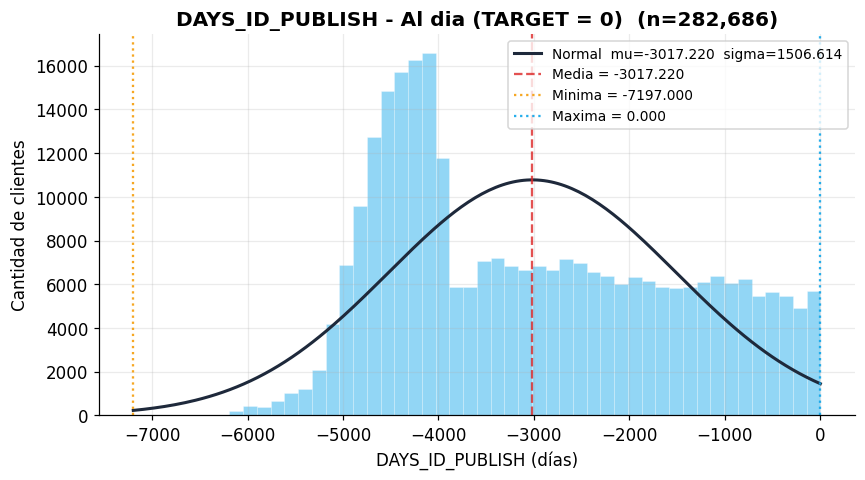


Resumen de DAYS_ID_PUBLISH por grupo:
             minima   media  maxima    desv         n
grupo                                                
Al dia (0)  -7197.0 -3017.2     0.0  1506.6  282686.0
Default (1) -6207.0 -2732.1     0.0  1517.0   24825.0
Todos       -7197.0 -2994.2     0.0  1509.5  307511.0


In [33]:
COL = 'DAYS_ID_PUBLISH'
COL_LABEL = 'DAYS_ID_PUBLISH (días)'

if COL not in df.columns:
    raise KeyError(f'La columna {COL} no está en el dataset cargado.')

nulos = int(df[COL].isna().sum())
print(f'{COL}: nulos = {nulos:,} ({nulos / len(df) * 100:.2f}%)')

plot_score_normal(
    df[COL], f'{COL} - Todos los clientes', BASE,
    xlabel=COL_LABEL, bins=50,
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, COL], f'{COL} - Default (TARGET = 1)', RISK,
    xlabel=COL_LABEL, bins=50,
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, COL], f'{COL} - Al dia (TARGET = 0)', SAFE,
    xlabel=COL_LABEL, bins=50,
)

resumen_id_publish = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(1)
)
resumen_id_publish.loc['Todos'] = [
    round(df[COL].min(), 1), round(df[COL].mean(), 1),
    round(df[COL].max(), 1), round(df[COL].std(), 1), df[COL].count(),
]

print(f'\nResumen de {COL} por grupo:')
print(resumen_id_publish.to_string())


### Clientes por decil de `DAYS_ID_PUBLISH`

La variable se parte en **10 deciles**. Las etiquetas muestran el intervalo de cada decil.


Distribución de DAYS_ID_PUBLISH por decil (n=307,511):
     rango_label  cantidad  porcentaje
[-7,197, -4,724]     30757       10.00
[-4,724, -4,430]     30841       10.03
[-4,430, -4,172]     30744       10.00
[-4,172, -3,881]     30670        9.97
[-3,881, -3,254]     30790       10.01
[-3,254, -2,654]     30761       10.00
[-2,654, -2,044]     30712        9.99
[-2,044, -1,378]     30735        9.99
  [-1,378, -730]     30766       10.00
       [-730, 0]     30735        9.99


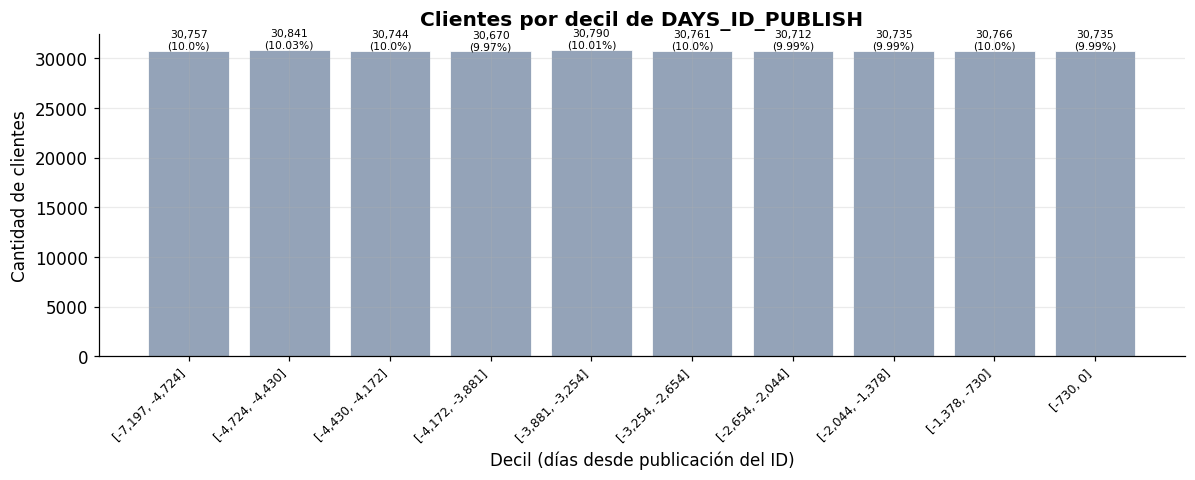

In [34]:
id_publish = df[[COL, 'TARGET']].copy()
id_publish[COL] = pd.to_numeric(id_publish[COL], errors='coerce')
id_publish = id_publish.dropna(subset=[COL])

id_publish['decil'], bins_decil = pd.qcut(
    id_publish[COL], q=10, retbins=True, duplicates='drop'
)

def etiqueta_intervalo(left, right):
    return f'[{left:,.0f}, {right:,.0f}]'

intervalos = [
    etiqueta_intervalo(bins_decil[i], bins_decil[i + 1])
    for i in range(len(bins_decil) - 1)
]
mapa_decil = dict(zip(range(1, len(intervalos) + 1), intervalos))
id_publish['rango'] = id_publish['decil'].cat.codes + 1
id_publish['rango_label'] = id_publish['rango'].map(mapa_decil)

dist_decil = (
    id_publish.groupby(['rango', 'rango_label'], observed=False)
    .size()
    .reset_index(name='cantidad')
    .sort_values('rango')
)
dist_decil['porcentaje'] = (
    dist_decil['cantidad'] / len(id_publish) * 100
).round(2)

print(f'Distribución de {COL} por decil (n={len(id_publish):,}):')
print(dist_decil[['rango_label', 'cantidad', 'porcentaje']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(dist_decil['rango_label'], dist_decil['cantidad'],
       color=BASE, edgecolor='white', linewidth=0.5)
ax.set_title(f'Clientes por decil de {COL}')
ax.set_xlabel('Decil (días desde publicación del ID)')
ax.set_ylabel('Cantidad de clientes')
plt.xticks(rotation=45, ha='right', fontsize=8)
for i, (cnt, pct) in enumerate(zip(dist_decil['cantidad'], dist_decil['porcentaje'])):
    ax.text(i, cnt, f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=7)
fig.tight_layout()
plt.show()


### Default por decil de `DAYS_ID_PUBLISH`

- **Cantidad de defaults** por decil.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default: 8.07%  |  Total defaults: 24,825
     rango_label  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
[-7,197, -4,724]           30757              1829              5.95                           7.37  0.74
[-4,724, -4,430]           30841              1902              6.17                           7.66  0.76
[-4,430, -4,172]           30744              2008              6.53                           8.09  0.81
[-4,172, -3,881]           30670              2355              7.68                           9.49  0.95
[-3,881, -3,254]           30790              2396              7.78                           9.65  0.96
[-3,254, -2,654]           30761              2571              8.36                          10.36  1.04
[-2,654, -2,044]           30712              2754              8.97                          11.09  1.11
[-2,044, -1,378]           30735              2864              9.32                          11.54  1

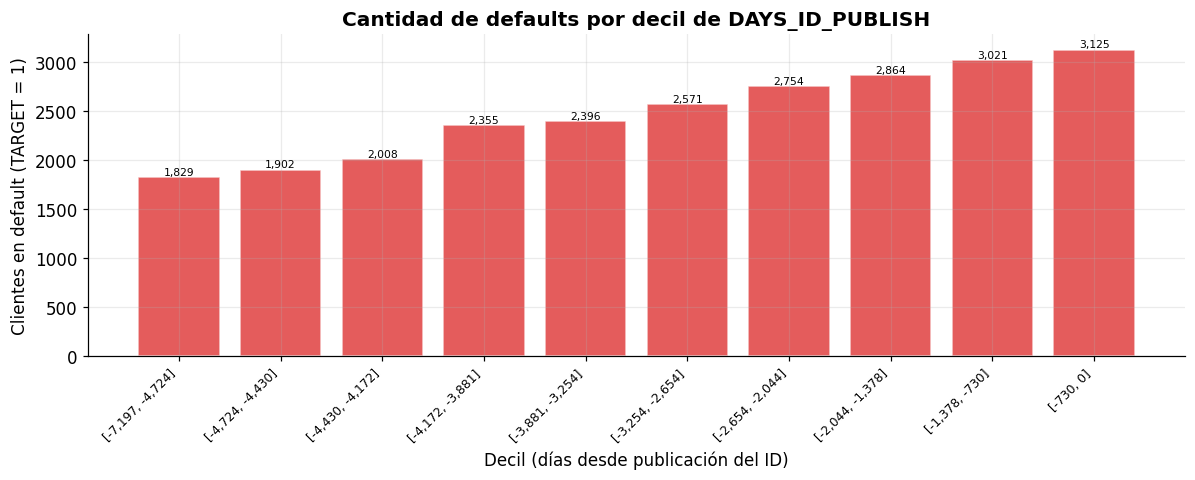

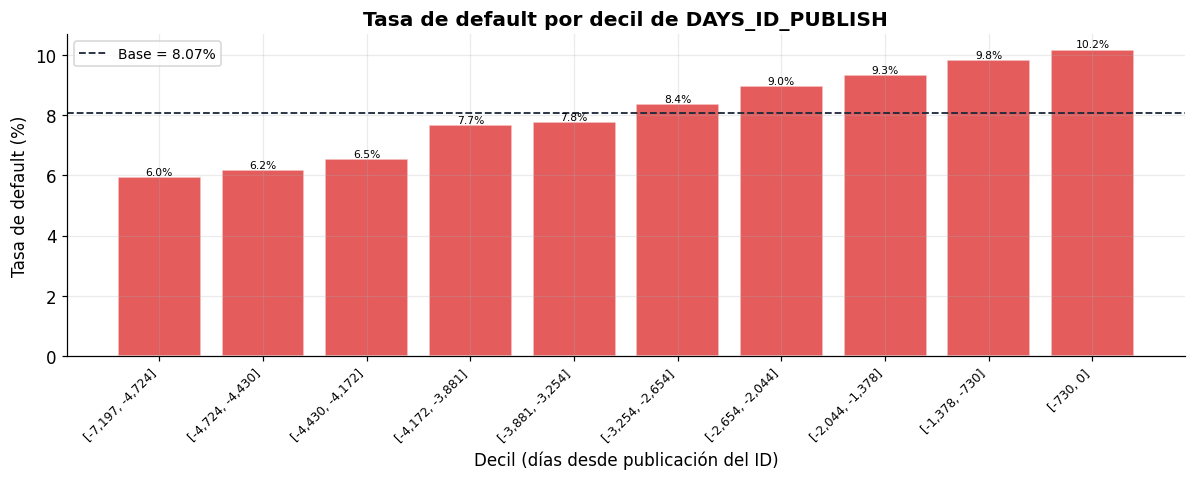

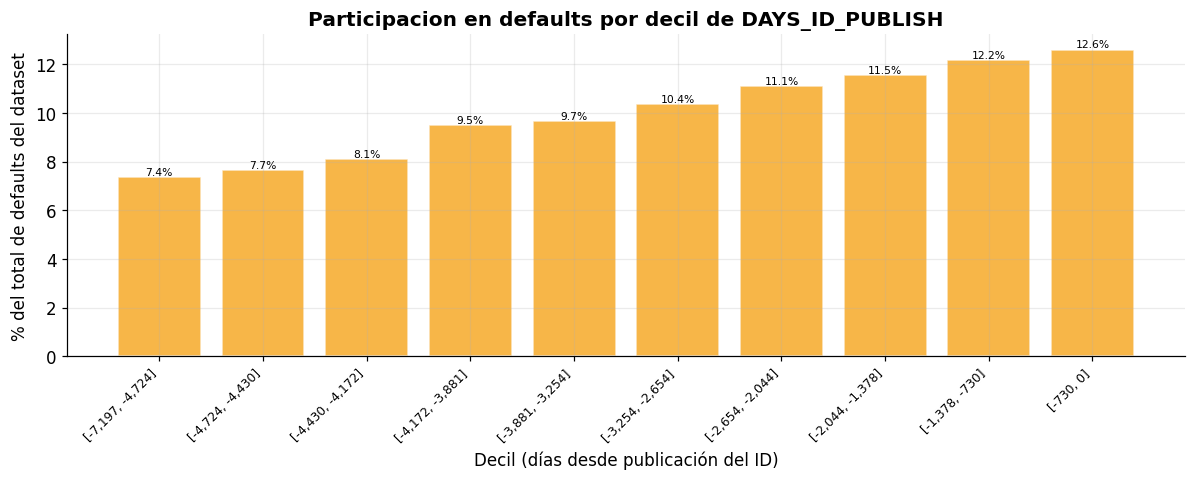


Interpretacion:
  Mayor tasa de default     : [-730, 0] (10.17%, lift=1.26x)
  Mayor cantidad de defaults: [-730, 0] (3,125 casos)
  Mayor participacion       : [-730, 0] (12.59% del total de defaults)


In [35]:
total_defaults_id_pub = int((id_publish['TARGET'] == 1).sum())
base_default_id_pub = id_publish['TARGET'].mean()

resumen_default_id_pub = (
    id_publish.groupby(['rango', 'rango_label'], observed=False)
    .agg(total_clientes=('TARGET', 'size'), clientes_default=('TARGET', 'sum'))
    .reset_index()
    .sort_values('rango')
)
resumen_default_id_pub['clientes_default'] = resumen_default_id_pub['clientes_default'].astype(int)
resumen_default_id_pub['tasa_default_pct'] = (
    resumen_default_id_pub['clientes_default'] / resumen_default_id_pub['total_clientes'] * 100
).round(2)
resumen_default_id_pub['participacion_en_defaults_pct'] = (
    resumen_default_id_pub['clientes_default'] / total_defaults_id_pub * 100
).round(2)
resumen_default_id_pub['lift'] = (
    resumen_default_id_pub['tasa_default_pct'] / (base_default_id_pub * 100)
).round(2)

print(
    f'Base de default: {base_default_id_pub * 100:.2f}%  |  '
    f'Total defaults: {total_defaults_id_pub:,}'
)
print(resumen_default_id_pub[
    ['rango_label', 'total_clientes', 'clientes_default',
     'tasa_default_pct', 'participacion_en_defaults_pct', 'lift']
].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default_id_pub['rango_label'],
    resumen_default_id_pub['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default_id_pub['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Cantidad de defaults por decil de {COL}')
ax.set_xlabel('Decil (días desde publicación del ID)')
ax.set_ylabel('Clientes en default (TARGET = 1)')
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default_id_pub['rango_label'],
    resumen_default_id_pub['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default_id_pub * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default_id_pub * 100:.2f}%')
for b, v in zip(barras, resumen_default_id_pub['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Tasa de default por decil de {COL}')
ax.set_xlabel('Decil (días desde publicación del ID)')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
barras = ax.bar(
    resumen_default_id_pub['rango_label'],
    resumen_default_id_pub['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default_id_pub['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=7)
ax.set_title(f'Participacion en defaults por decil de {COL}')
ax.set_xlabel('Decil (días desde publicación del ID)')
ax.set_ylabel('% del total de defaults del dataset')
plt.xticks(rotation=45, ha='right', fontsize=8)
fig.tight_layout()
plt.show()

r_tasa = resumen_default_id_pub.loc[resumen_default_id_pub['tasa_default_pct'].idxmax()]
r_cant = resumen_default_id_pub.loc[resumen_default_id_pub['clientes_default'].idxmax()]
r_part = resumen_default_id_pub.loc[resumen_default_id_pub['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango_label"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango_label"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango_label"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')


## Distribución de `REGION_RATING_CLIENT_W_CITY`

Rating regional del cliente respecto a la ciudad (`REGION_RATING_CLIENT_W_CITY`). Valores discretos **1, 2 y 3** (calidad / riesgo de la región). Histogramas por grupo y análisis de default **por nivel de rating**.


REGION_RATING_CLIENT_W_CITY: nulos = 0 (0.00%)
Valores únicos: [np.int8(1), np.int8(2), np.int8(3)]


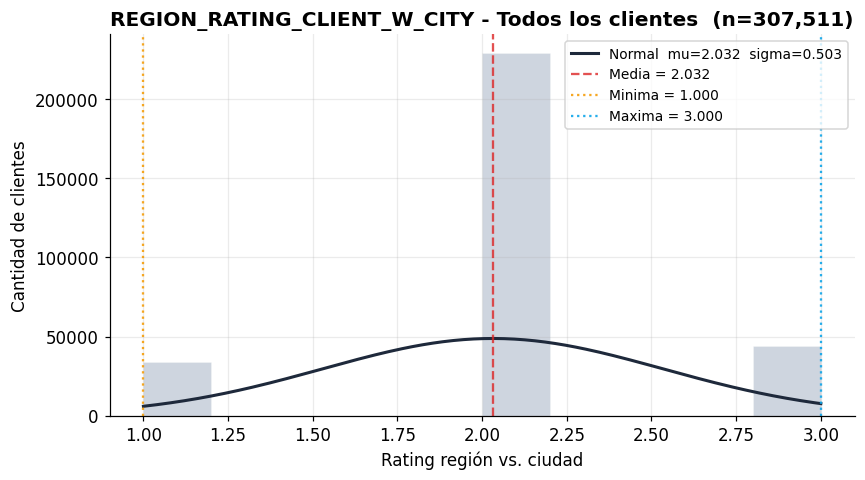

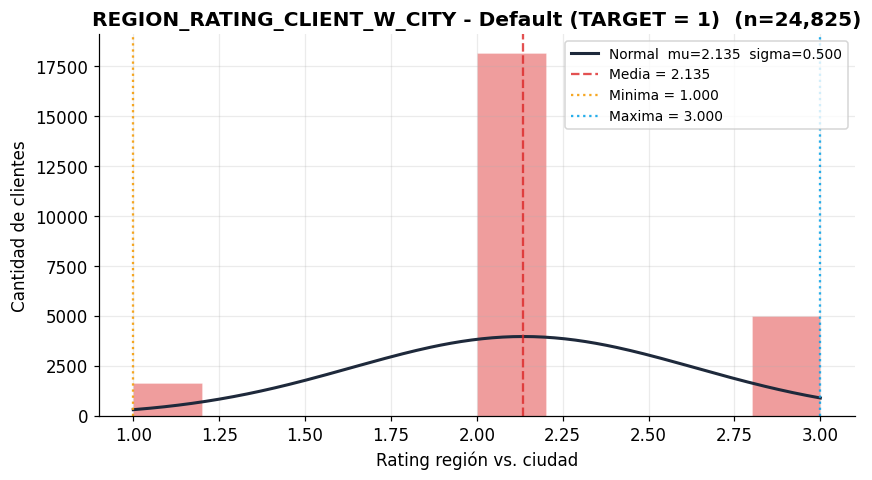

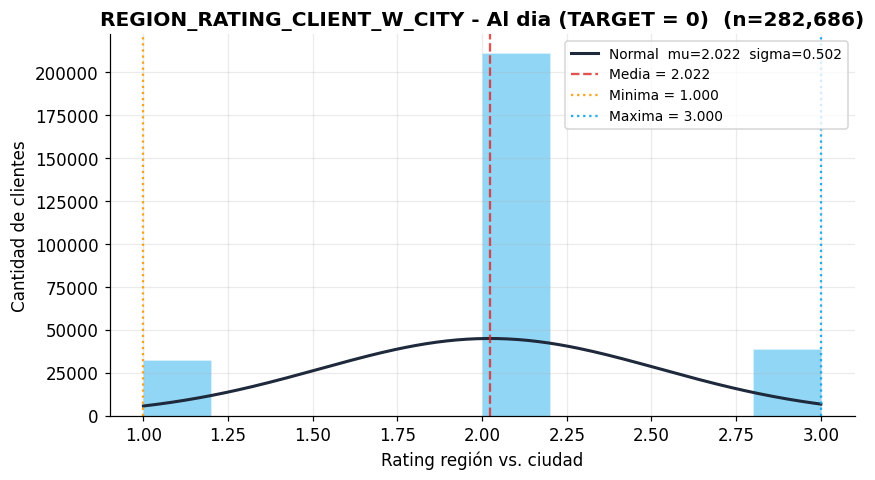


Resumen de REGION_RATING_CLIENT_W_CITY por grupo:
             minima  media  maxima   desv         n
grupo                                              
Al dia (0)      1.0  2.022     3.0  0.502  282686.0
Default (1)     1.0  2.135     3.0  0.500   24825.0
Todos           1.0  2.032     3.0  0.503  307511.0


In [29]:
COL = 'REGION_RATING_CLIENT_W_CITY'
COL_LABEL = 'Rating región vs. ciudad'

if COL not in df.columns:
    raise KeyError(f'La columna {COL} no está en el dataset cargado.')

nulos = int(df[COL].isna().sum())
print(f'{COL}: nulos = {nulos:,} ({nulos / len(df) * 100:.2f}%)')
print('Valores únicos:', sorted(df[COL].dropna().unique()))

plot_score_normal(
    df[COL], f'{COL} - Todos los clientes', BASE,
    xlabel=COL_LABEL, bins=10,
)
plot_score_normal(
    df.loc[df['TARGET'] == 1, COL], f'{COL} - Default (TARGET = 1)', RISK,
    xlabel=COL_LABEL, bins=10,
)
plot_score_normal(
    df.loc[df['TARGET'] == 0, COL], f'{COL} - Al dia (TARGET = 0)', SAFE,
    xlabel=COL_LABEL, bins=10,
)

resumen_region = (
    df.assign(grupo=df['TARGET'].map({0: 'Al dia (0)', 1: 'Default (1)'}))
    .groupby('grupo', observed=False)[COL]
    .agg(minima='min', media='mean', maxima='max', desv='std', n='count')
    .round(3)
)
resumen_region.loc['Todos'] = [
    df[COL].min(), round(df[COL].mean(), 3),
    df[COL].max(), round(df[COL].std(), 3), df[COL].count(),
]

print(f'\nResumen de {COL} por grupo:')
print(resumen_region.to_string())


### Clientes por nivel de `REGION_RATING_CLIENT_W_CITY`

Distribución de clientes en cada **categoría de rating** (1, 2, 3).


Distribución de REGION_RATING_CLIENT_W_CITY por nivel (n=307,511):
rango_label  cantidad  porcentaje
   Rating 1     34167       11.11
   Rating 2    229484       74.63
   Rating 3     43860       14.26


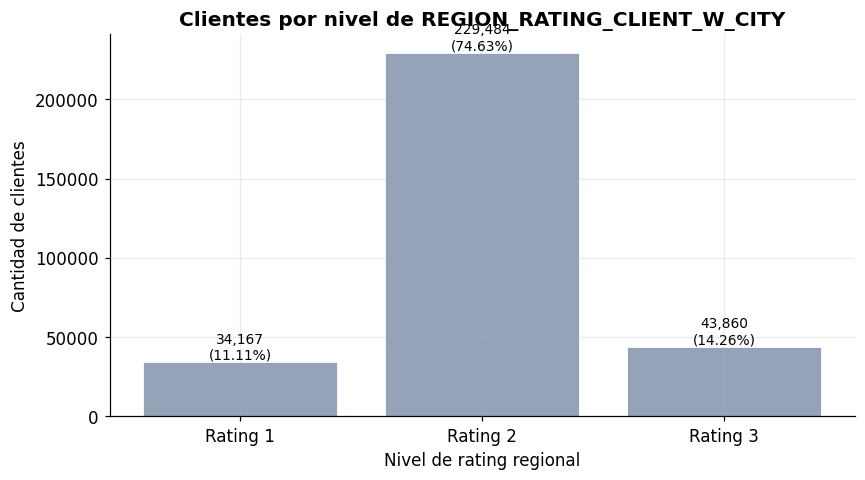

In [30]:
region_df = df[[COL, 'TARGET']].copy()
region_df[COL] = pd.to_numeric(region_df[COL], errors='coerce')
region_df = region_df.dropna(subset=[COL])
region_df['rango'] = region_df[COL].astype(int)
region_df['rango_label'] = region_df['rango'].map(lambda x: f'Rating {x}')

dist_region = (
    region_df.groupby(['rango', 'rango_label'], observed=False)
    .size()
    .reset_index(name='cantidad')
    .sort_values('rango')
)
dist_region['porcentaje'] = (
    dist_region['cantidad'] / len(region_df) * 100
).round(2)

print(f'Distribución de {COL} por nivel (n={len(region_df):,}):')
print(dist_region[['rango_label', 'cantidad', 'porcentaje']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(dist_region['rango_label'], dist_region['cantidad'],
       color=BASE, edgecolor='white', linewidth=0.5)
ax.set_title(f'Clientes por nivel de {COL}')
ax.set_xlabel('Nivel de rating regional')
ax.set_ylabel('Cantidad de clientes')
for i, (cnt, pct) in enumerate(zip(dist_region['cantidad'], dist_region['porcentaje'])):
    ax.text(i, cnt, f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
plt.show()


### Default por nivel de `REGION_RATING_CLIENT_W_CITY`

- **Cantidad de defaults** por rating.
- **Tasa de default** vs tasa base.
- **Participación en defaults** del portfolio.


Base de default: 8.07%  |  Total defaults: 24,825
rango_label  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct  lift
   Rating 1           34167              1654              4.84                           6.66  0.60
   Rating 2          229484             18170              7.92                          73.19  0.98
   Rating 3           43860              5001             11.40                          20.15  1.41


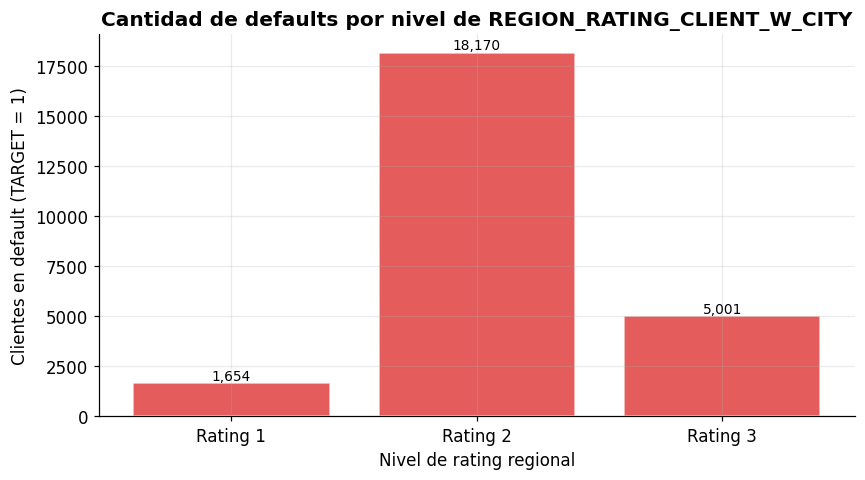

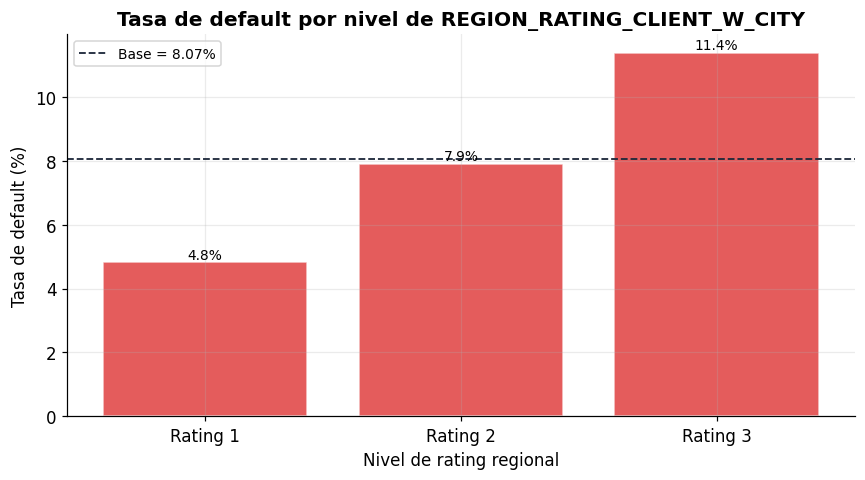

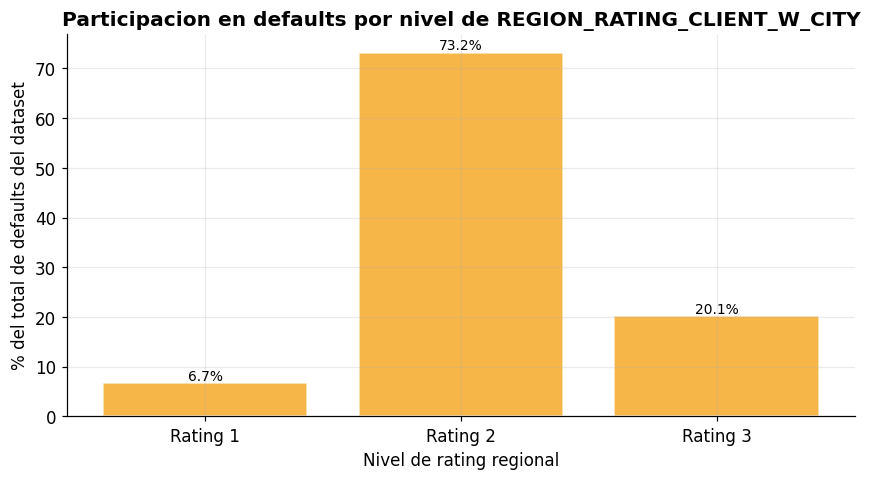


Interpretacion:
  Mayor tasa de default     : Rating 3 (11.40%, lift=1.41x)
  Mayor cantidad de defaults: Rating 2 (18,170 casos)
  Mayor participacion       : Rating 2 (73.19% del total de defaults)


In [31]:
total_defaults_region = int((region_df['TARGET'] == 1).sum())
base_default_region = region_df['TARGET'].mean()

resumen_default_region = (
    region_df.groupby(['rango', 'rango_label'], observed=False)
    .agg(total_clientes=('TARGET', 'size'), clientes_default=('TARGET', 'sum'))
    .reset_index()
    .sort_values('rango')
)
resumen_default_region['clientes_default'] = resumen_default_region['clientes_default'].astype(int)
resumen_default_region['tasa_default_pct'] = (
    resumen_default_region['clientes_default'] / resumen_default_region['total_clientes'] * 100
).round(2)
resumen_default_region['participacion_en_defaults_pct'] = (
    resumen_default_region['clientes_default'] / total_defaults_region * 100
).round(2)
resumen_default_region['lift'] = (
    resumen_default_region['tasa_default_pct'] / (base_default_region * 100)
).round(2)

print(
    f'Base de default: {base_default_region * 100:.2f}%  |  '
    f'Total defaults: {total_defaults_region:,}'
)
print(resumen_default_region[
    ['rango_label', 'total_clientes', 'clientes_default',
     'tasa_default_pct', 'participacion_en_defaults_pct', 'lift']
].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(
    resumen_default_region['rango_label'],
    resumen_default_region['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default_region['clientes_default']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=9)
ax.set_title(f'Cantidad de defaults por nivel de {COL}')
ax.set_xlabel('Nivel de rating regional')
ax.set_ylabel('Clientes en default (TARGET = 1)')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(
    resumen_default_region['rango_label'],
    resumen_default_region['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
ax.axhline(base_default_region * 100, color=INK, linestyle='--', linewidth=1.2,
           label=f'Base = {base_default_region * 100:.2f}%')
for b, v in zip(barras, resumen_default_region['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title(f'Tasa de default por nivel de {COL}')
ax.set_xlabel('Nivel de rating regional')
ax.set_ylabel('Tasa de default (%)')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(
    resumen_default_region['rango_label'],
    resumen_default_region['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, v in zip(barras, resumen_default_region['participacion_en_defaults_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.set_title(f'Participacion en defaults por nivel de {COL}')
ax.set_xlabel('Nivel de rating regional')
ax.set_ylabel('% del total de defaults del dataset')
fig.tight_layout()
plt.show()

r_tasa = resumen_default_region.loc[resumen_default_region['tasa_default_pct'].idxmax()]
r_cant = resumen_default_region.loc[resumen_default_region['clientes_default'].idxmax()]
r_part = resumen_default_region.loc[resumen_default_region['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["rango_label"]} ({r_tasa["tasa_default_pct"]:.2f}%, lift={r_tasa["lift"]:.2f}x)')
print(f'  Mayor cantidad de defaults: {r_cant["rango_label"]} ({r_cant["clientes_default"]:,} casos)')
print(f'  Mayor participacion       : {r_part["rango_label"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total de defaults)')


## Clientes sin historial de buro (`no_bureau_history`)

La bandera `no_bureau_history` indica si el cliente **no tiene registros en el buro de credito**:

- `1` = sin historial de buro (no se encontro informacion en `bureau`).
- `0` = con historial de buro.

Estos clientes son relevantes para el riesgo porque su comportamiento crediticio externo es desconocido. Contamos cuantos hay en cada caso.

Historial de buro de credito:
----------------------------------------
  Con historial (0) : 263,490  (85.7%)
  Sin historial (1) :  44,021  (14.3%)
----------------------------------------
  Total             : 307,511


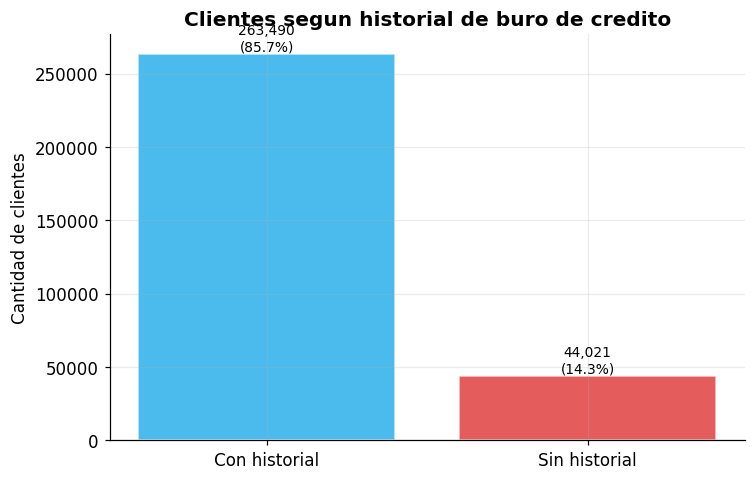

In [31]:
conteo_bureau = df['no_bureau_history'].value_counts().sort_index()
total = int(conteo_bureau.sum())
con_historial = int(conteo_bureau.get(0, 0))
sin_historial = int(conteo_bureau.get(1, 0))

print('Historial de buro de credito:')
print('-' * 40)
print(f'  Con historial (0) : {con_historial:>7,}  ({con_historial / total * 100:.1f}%)')
print(f'  Sin historial (1) : {sin_historial:>7,}  ({sin_historial / total * 100:.1f}%)')
print('-' * 40)
print(f'  Total             : {total:>7,}')

fig, ax = plt.subplots(figsize=(7, 4.5))
valores = [con_historial, sin_historial]
barras = ax.bar(['Con historial', 'Sin historial'], valores,
                color=[SAFE, RISK], alpha=0.75, edgecolor='white')
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}\n({v / total * 100:.1f}%)',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Clientes segun historial de buro de credito')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

### Tasa de default segun historial de buro

Comparamos el **riesgo proporcional** entre clientes con y sin historial de buro:

```text
Tasa de default = clientes con TARGET = 1 en el grupo / total del grupo x 100
```

Si los clientes **sin historial** tienen una tasa mas alta, la ausencia de informacion crediticia externa seria una senal de mayor riesgo a considerar en el modelo.

Tasa de default segun historial de buro:
                   total_clientes  clientes_default  tasa_default_pct
no_bureau_history                                                    
Con historial              263490             20368              7.73
Sin historial               44021              4457             10.12

Tasa base (todo el dataset): 8.07%


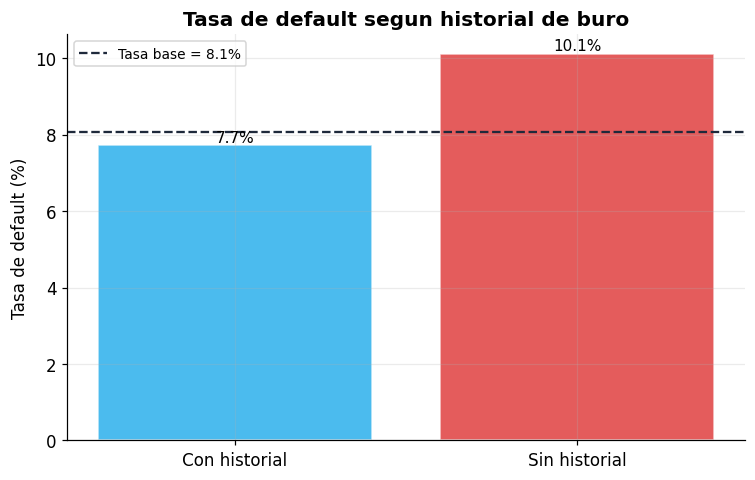

In [ ]:
resumen_bureau = (
    df.groupby('no_bureau_history')['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
)
resumen_bureau['tasa_default_pct'] = (
    resumen_bureau['clientes_default'] / resumen_bureau['total_clientes'] * 100
).round(2)
resumen_bureau.index = resumen_bureau.index.map({0: 'Con historial', 1: 'Sin historial'})

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default segun historial de buro:')
print(resumen_bureau.to_string())
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(7, 4.5))
valores = resumen_bureau['tasa_default_pct']
barras = ax.bar(resumen_bureau.index, valores,
                color=[SAFE, RISK], alpha=0.75, edgecolor='white')
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default segun historial de buro')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Distribucion del numero de creditos activos (`bureau_n_active`)

Mostramos la distribucion de `bureau_n_active` (cantidad de creditos activos en el buro) **solo para los clientes que tienen historial de buro** (`no_bureau_history == 0`). Los clientes sin historial se excluyen porque su valor es 0 por ausencia de informacion, no por no tener creditos activos.

Se incluye la curva normal ajustada `N(media, sigma)` como referencia y las lineas de minimo, media y maximo.

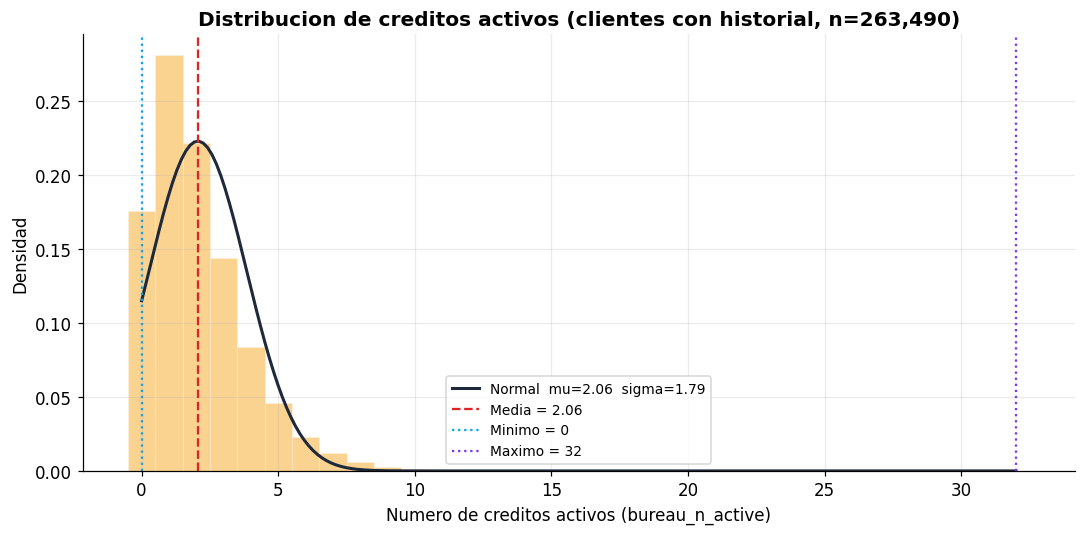

Creditos activos (clientes con historial de buro):
  Minimo : 0
  Media  : 2.06
  Mediana: 2
  Maximo : 32
  Clientes: 263,490


In [ ]:
# Solo clientes con historial de buro.
con_historial = df[df['no_bureau_history'] == 0]
datos = con_historial['bureau_n_active'].dropna()

media, desv = datos.mean(), datos.std()
val_min, val_max = datos.min(), datos.max()

fig, ax = plt.subplots(figsize=(10, 5))
# Un bin por cada valor entero de creditos activos.
bins = np.arange(datos.min(), datos.max() + 2) - 0.5
counts, edges, _ = ax.hist(datos, bins=bins, density=True, color=ACCENT,
                           alpha=0.45, edgecolor='white', linewidth=0.4)

x = np.linspace(datos.min(), datos.max(), 200)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.2f}  sigma={desv:.2f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.2f}')
ax.axvline(val_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Minimo = {val_min:.0f}')
ax.axvline(val_max, color='#7c3aed', linestyle=':', linewidth=1.5, label=f'Maximo = {val_max:.0f}')

ax.set_title(f'Distribucion de creditos activos (clientes con historial, n={len(datos):,})')
ax.set_xlabel('Numero de creditos activos (bureau_n_active)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('Creditos activos (clientes con historial de buro):')
print(f'  Minimo : {val_min:.0f}')
print(f'  Media  : {media:.2f}')
print(f'  Mediana: {datos.median():.0f}')
print(f'  Maximo : {val_max:.0f}')
print(f'  Clientes: {len(datos):,}')

### Creditos activos en cantidad de clientes

Misma distribucion de `bureau_n_active` (clientes con historial de buro), pero en el eje Y mostramos la **cantidad de clientes** en lugar de densidad. La curva normal se reescala a conteo (`pdf x n x ancho_de_bin`) para que siga calzando con las barras.

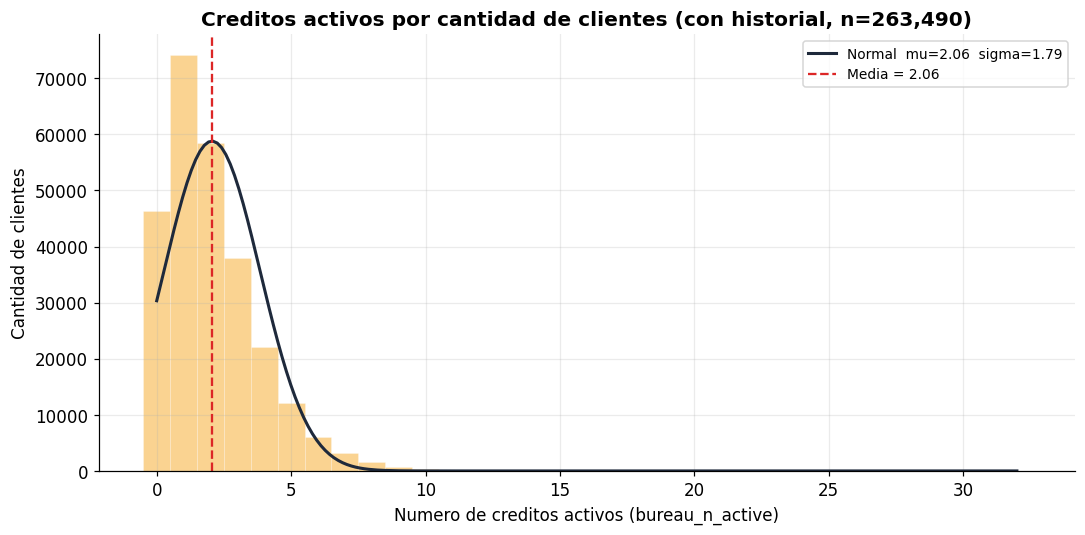

In [55]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(datos.min(), datos.max() + 2) - 0.5
counts, edges, _ = ax.hist(datos, bins=bins, color=ACCENT,
                           alpha=0.45, edgecolor='white', linewidth=0.4)

# Curva normal reescalada a conteo: pdf * n * ancho_de_bin.
ancho_bin = edges[1] - edges[0]
x = np.linspace(datos.min(), datos.max(), 200)
ax.plot(x, stats.norm.pdf(x, media, desv) * len(datos) * ancho_bin,
        color=INK, linewidth=2, label=f'Normal  mu={media:.2f}  sigma={desv:.2f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.2f}')

ax.set_title(f'Creditos activos por cantidad de clientes (con historial, n={len(datos):,})')
ax.set_xlabel('Numero de creditos activos (bureau_n_active)')
ax.set_ylabel('Cantidad de clientes')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Clientes por numero de creditos activos (0 a 10)

Cantidad de clientes con historial de buro para cada valor de creditos activos del `0` al `10`. El valor `0` corresponde a clientes con historial pero sin creditos activos actualmente. Los clientes con mas de 10 creditos activos se agrupan en `10+`.

Clientes por numero de creditos activos:
    0 :  46,341
    1 :  74,102
    2 :  58,383
    3 :  38,012
    4 :  22,040
    5 :  12,051
    6 :   6,107
    7 :   3,156
    8 :   1,648
    9 :     780
   10 :     425
  10+ :     445


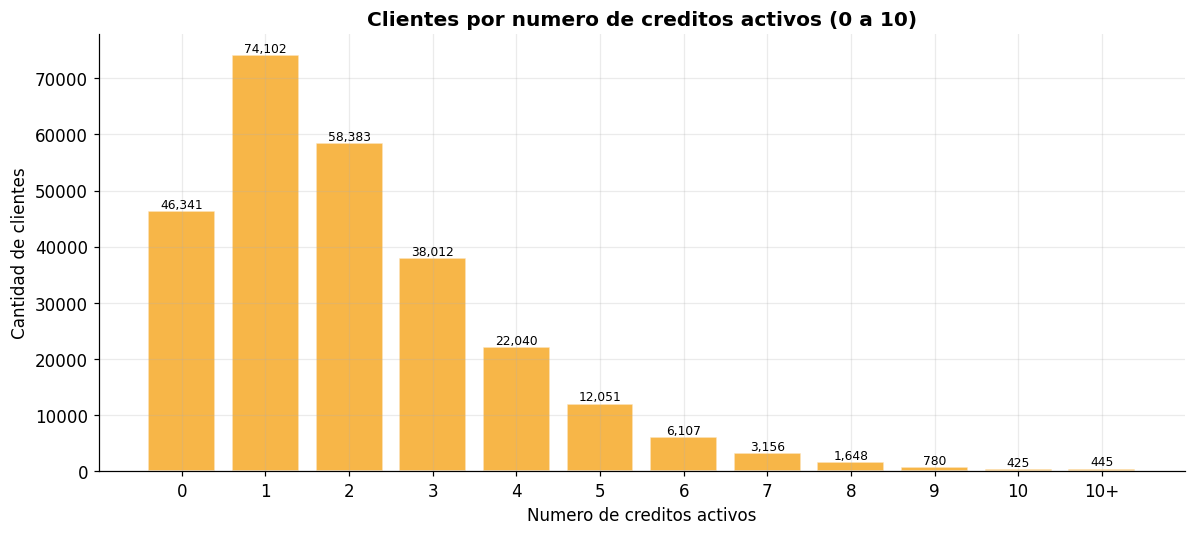

In [59]:
conteo = {str(i): int((datos == i).sum()) for i in range(0, 11)}
conteo['10+'] = int((datos > 10).sum())

etiquetas = list(conteo.keys())
valores = list(conteo.values())

print('Clientes por numero de creditos activos:')
for k, v in conteo.items():
    print(f'  {k:>3} : {v:>7,}')

fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(etiquetas, valores, color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title('Clientes por numero de creditos activos (0 a 10)')
ax.set_xlabel('Numero de creditos activos')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

### Clientes en default por numero de creditos activos (0 a 10)

Misma distribucion, pero solo para los clientes **en default** (`TARGET = 1`) con historial de buro. Muestra cuantos clientes que incumplieron tenian 0, 1, 2, ... 10 creditos activos.

Clientes en default por numero de creditos activos:
    0 :   2,621
    1 :   5,260
    2 :   4,346
    3 :   3,140
    4 :   2,035
    5 :   1,285
    6 :     714
    7 :     429
    8 :     226
    9 :     124
   10 :      73
  10+ :     115


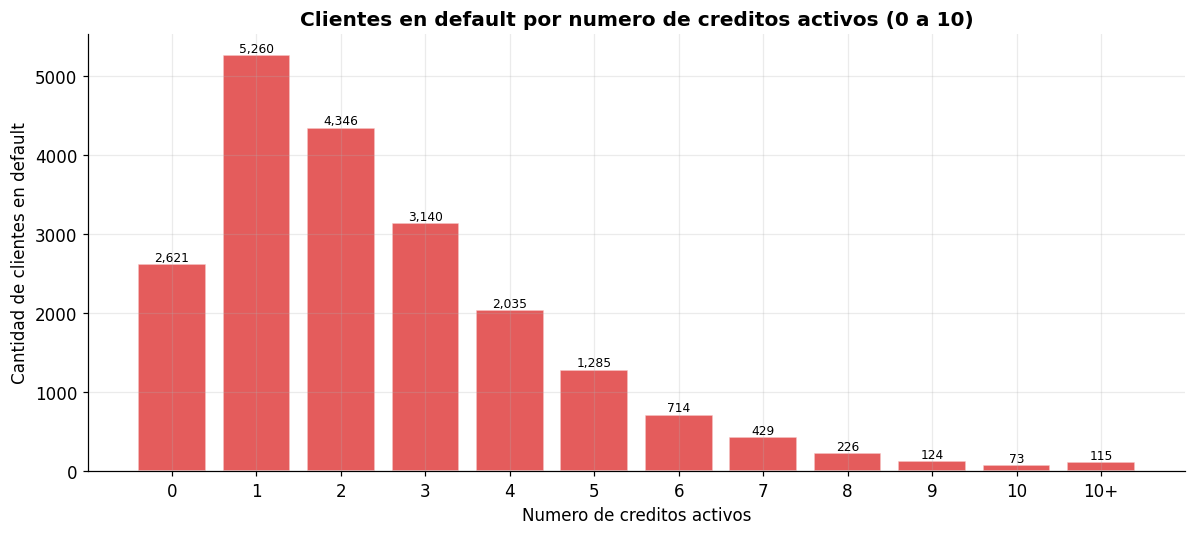

In [60]:
# Clientes en default con historial de buro.
datos_def = df[(df['no_bureau_history'] == 0) & (df['TARGET'] == 1)]['bureau_n_active'].dropna()

conteo_def = {str(i): int((datos_def == i).sum()) for i in range(0, 11)}
conteo_def['10+'] = int((datos_def > 10).sum())

etiquetas = list(conteo_def.keys())
valores = list(conteo_def.values())

print('Clientes en default por numero de creditos activos:')
for k, v in conteo_def.items():
    print(f'  {k:>3} : {v:>7,}')

fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(etiquetas, valores, color=RISK, alpha=0.75, edgecolor='white')
for b, v in zip(barras, valores):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title('Clientes en default por numero de creditos activos (0 a 10)')
ax.set_xlabel('Numero de creditos activos')
ax.set_ylabel('Cantidad de clientes en default')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Riesgo segun el numero de creditos activos (0 a 10)

Igual que con la edad, analizamos los creditos activos (`bureau_n_active`) desde dos perspectivas, usando solo clientes **con historial de buro**:

- **Tasa de default:** de cada grupo de creditos activos, que porcentaje incumplio. Mide el **riesgo proporcional**.
- **Participacion en el total de defaults:** que porcentaje del total de defaults (con historial) aporta cada grupo. Mide el **volumen**.

Los valores se agrupan de `0` a `10`, y los clientes con mas de 10 creditos activos se juntan en `10+`.

Resumen por numero de creditos activos (clientes con historial):
CREDITOS_ACTIVOS  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct
               0           46341              2621              5.66                          12.87
               1           74102              5260              7.10                          25.82
               2           58383              4346              7.44                          21.34
               3           38012              3140              8.26                          15.42
               4           22040              2035              9.23                           9.99
               5           12051              1285             10.66                           6.31
               6            6107               714             11.69                           3.51
               7            3156               429             13.59                           2.11
               8            1648   

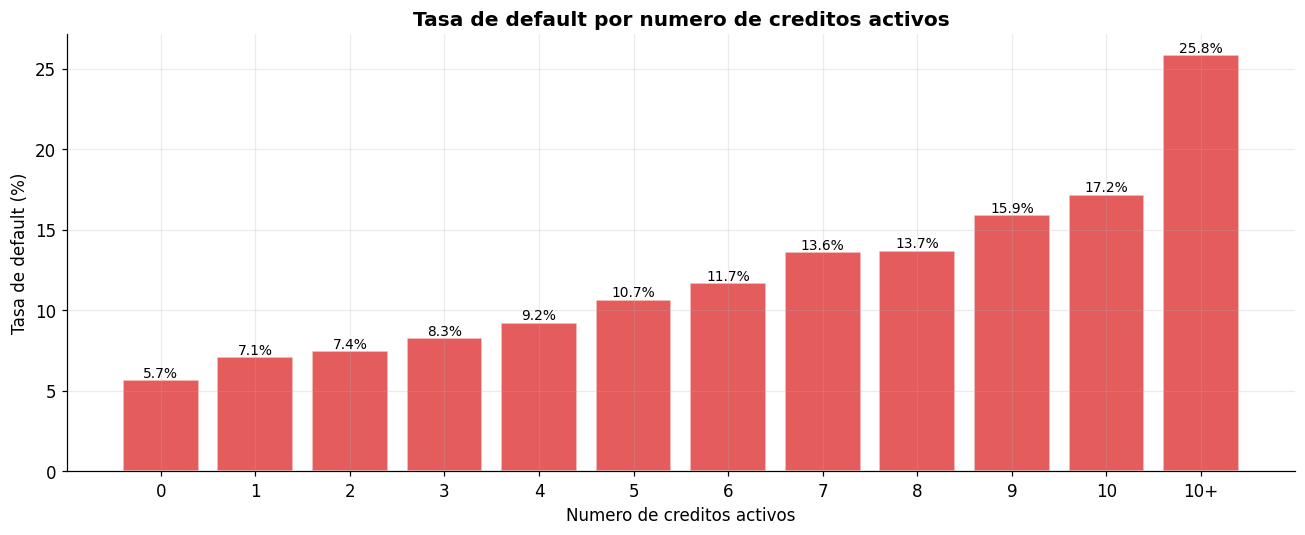

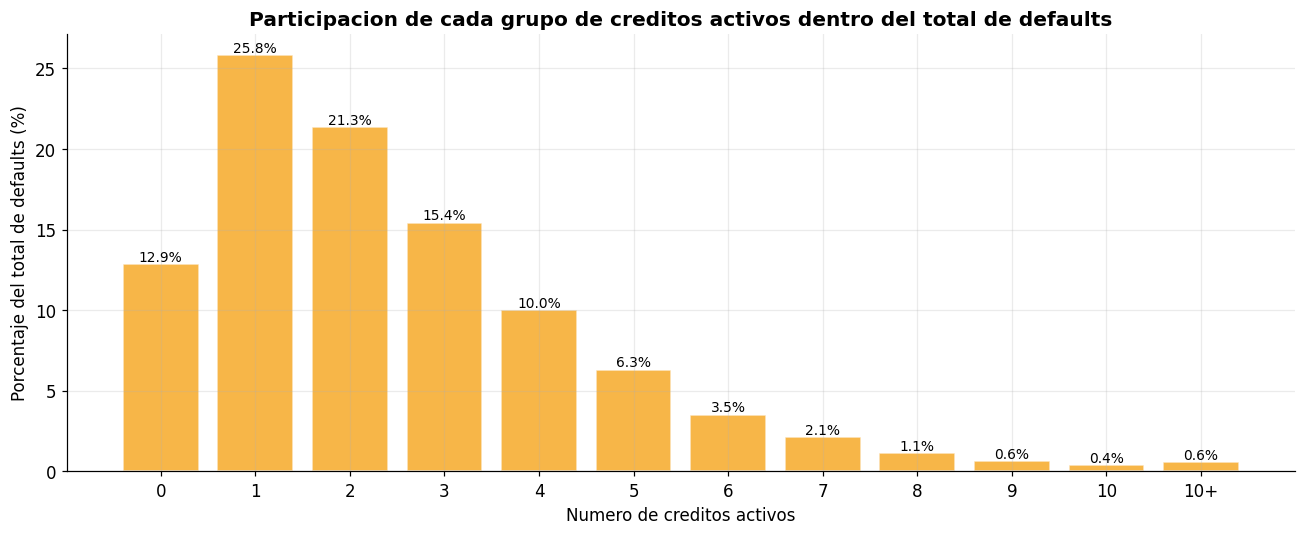

In [61]:
# Solo clientes con historial de buro.
ch = df[df['no_bureau_history'] == 0][['bureau_n_active', 'TARGET']].copy()

# Agrupa creditos activos: 0..10 y 10+.
ch['CREDITOS_ACTIVOS'] = ch['bureau_n_active'].apply(
    lambda v: '10+' if v > 10 else str(int(v))
)
orden = [str(i) for i in range(0, 11)] + ['10+']

resumen = (
    ch.groupby('CREDITOS_ACTIVOS', observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reindex(orden)
)
total_defaults = int(ch['TARGET'].sum())
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)
resumen['participacion_en_defaults_pct'] = (
    resumen['clientes_default'] / total_defaults * 100
).round(2)
resumen = resumen.reset_index()

print('Resumen por numero de creditos activos (clientes con historial):')
print(resumen.to_string(index=False))

# Grafica 1: tasa de default.
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(resumen['CREDITOS_ACTIVOS'], resumen['tasa_default_pct'],
                color=RISK, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen['tasa_default_pct']):
    if pd.notna(v):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Tasa de default por numero de creditos activos')
ax.set_xlabel('Numero de creditos activos')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

# Grafica 2: participacion dentro del total de defaults.
fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(resumen['CREDITOS_ACTIVOS'], resumen['participacion_en_defaults_pct'],
                color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen['participacion_en_defaults_pct']):
    if pd.notna(v):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
                ha='center', va='bottom', fontsize=9)
ax.set_title('Participacion de cada grupo de creditos activos dentro del total de defaults')
ax.set_xlabel('Numero de creditos activos')
ax.set_ylabel('Porcentaje del total de defaults (%)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

## Distribución del monto total de crédito en buró (`bureau_total_credit`)

`bureau_total_credit` es la **suma del monto de crédito registrado en buró** por cliente (agregación de `AMT_CREDIT_SUM` en la tabla `bureau`).

Mostramos la distribución **solo para clientes con historial de buró** (`no_bureau_history == 0`). Quienes no tienen historial quedan excluidos porque su valor en cero refleja ausencia de información, no necesariamente ausencia de deuda.

Se incluye la curva normal ajustada `N(media, σ)` como referencia y las líneas de mínimo, media y máximo.

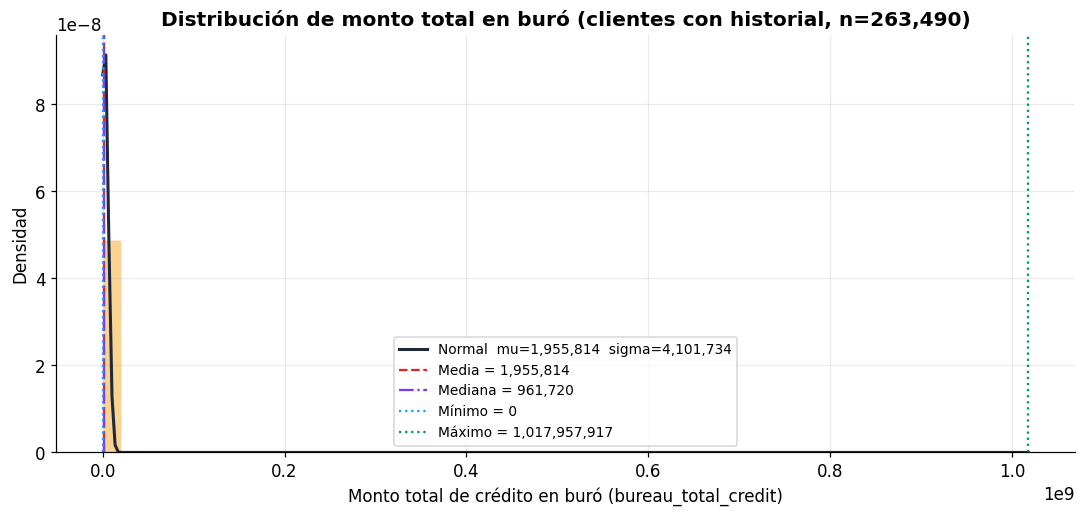

Monto total de crédito en buró (clientes con historial):
  Mínimo  : 0
  Media   : 1,955,814
  Mediana : 961,720
  Máximo  : 1,017,957,917
  % en cero: 0.4%
  Clientes: 263,490


In [ ]:
# Solo clientes con historial de buró.
con_historial = df[df['no_bureau_history'] == 0]
datos = con_historial['bureau_total_credit'].dropna()

media, desv = datos.mean(), datos.std()
val_min, val_max = datos.min(), datos.max()
p50 = datos.median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos, bins=50, density=True, color=ACCENT, alpha=0.45,
        edgecolor='white', linewidth=0.4)

x = np.linspace(datos.min(), datos.max(), 300)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:,.0f}  sigma={desv:,.0f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:,.0f}')
ax.axvline(p50, color='#7c3aed', linestyle='-.', linewidth=1.5, label=f'Mediana = {p50:,.0f}')
ax.axvline(val_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Mínimo = {val_min:,.0f}')
ax.axvline(val_max, color='#059669', linestyle=':', linewidth=1.5, label=f'Máximo = {val_max:,.0f}')

ax.set_title(f'Distribución de monto total en buró (clientes con historial, n={len(datos):,})')
ax.set_xlabel('Monto total de crédito en buró (bureau_total_credit)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('Monto total de crédito en buró (clientes con historial):')
print(f'  Mínimo  : {val_min:,.0f}')
print(f'  Media   : {media:,.0f}')
print(f'  Mediana : {p50:,.0f}')
print(f'  Máximo  : {val_max:,.0f}')
print(f'  % en cero: {(datos == 0).mean() * 100:.1f}%')
print(f'  Clientes: {len(datos):,}')

### Otras formas de ver `bureau_total_credit` (cola derecha extrema)

La grafica anterior conserva **todos** los valores, pero unos pocos montos muy altos (maximo ~1.018.000 millones) comprimen el 99% de los clientes en un solo bin.

Para ver mejor la columna usamos tres vistas complementarias (misma muestra: clientes con historial de buro):

1. **Histograma acotado al percentil 99** — muestra donde se concentra casi toda la masa; los outliers quedan fuera del eje pero se reportan aparte.
2. **Histograma en escala log10** — estira la cola derecha y hace visibles diferencias entre montos grandes y pequenos.
3. **Curva acumulada (ECDF)** — responde preguntas del tipo *"que porcentaje de clientes tiene menos de X?"* sin depender del ancho de bins.

Percentiles bureau_total_credit (clientes con historial):
  P50 (mediana): 961,720
  P90          : 4,672,451
  P95          : 6,984,877
  P99          : 14,113,114
  Maximo       : 1,017,957,917
  Clientes > P99 (fuera del recorte): 2,635 (1.00%)



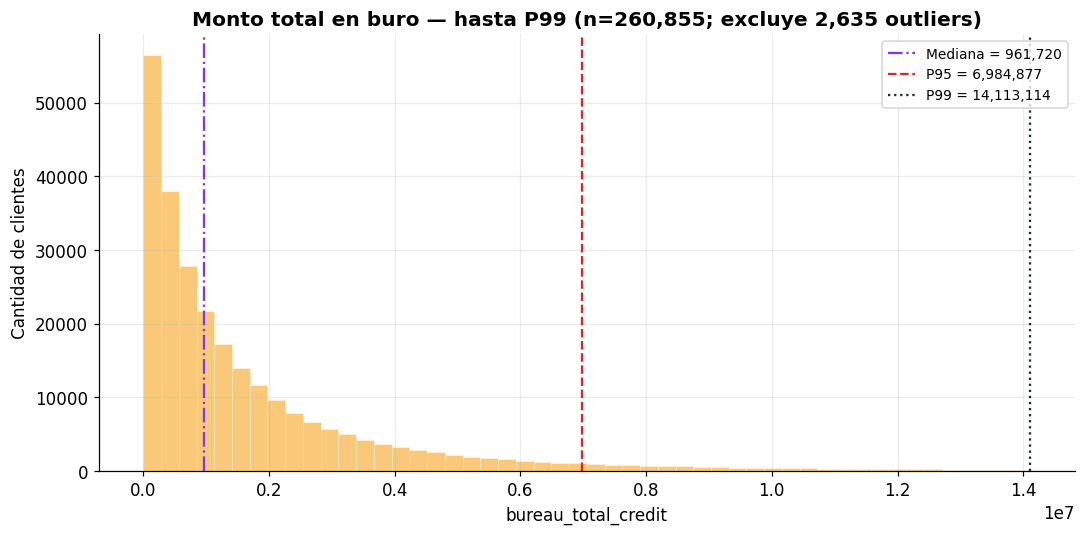

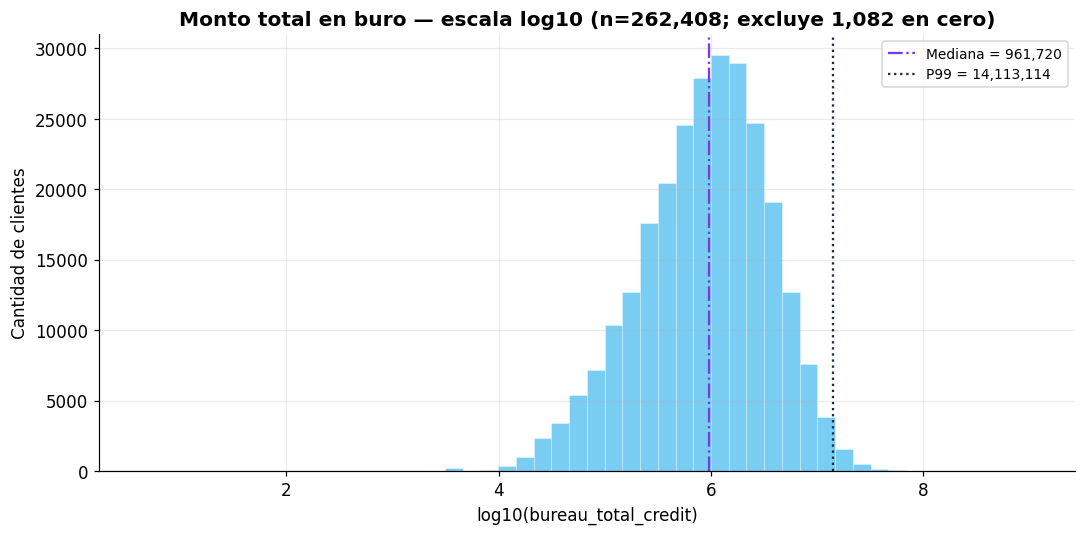

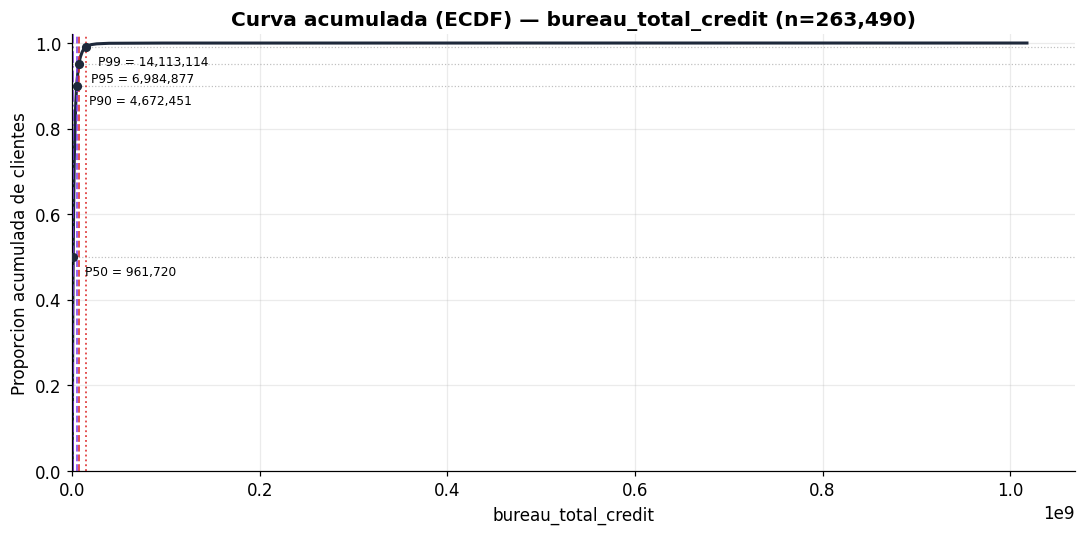

In [76]:
datos_bureau = df.loc[df['no_bureau_history'] == 0, 'bureau_total_credit'].dropna()

p50 = datos_bureau.median()
p90 = datos_bureau.quantile(0.90)
p95 = datos_bureau.quantile(0.95)
p99 = datos_bureau.quantile(0.99)
n_outliers_p99 = int((datos_bureau > p99).sum())

print('Percentiles bureau_total_credit (clientes con historial):')
print(f'  P50 (mediana): {p50:,.0f}')
print(f'  P90          : {p90:,.0f}')
print(f'  P95          : {p95:,.0f}')
print(f'  P99          : {p99:,.0f}')
print(f'  Maximo       : {datos_bureau.max():,.0f}')
print(f'  Clientes > P99 (fuera del recorte): {n_outliers_p99:,} ({n_outliers_p99 / len(datos_bureau) * 100:.2f}%)')
print()

# --- 1) Histograma acotado al P99 ---
datos_p99 = datos_bureau[datos_bureau <= p99]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos_p99, bins=50, color=ACCENT, alpha=0.55, edgecolor='white', linewidth=0.4)
ax.axvline(p50, color='#7c3aed', linestyle='-.', linewidth=1.5, label=f'Mediana = {p50:,.0f}')
ax.axvline(p95, color=RISK, linestyle='--', linewidth=1.5, label=f'P95 = {p95:,.0f}')
ax.axvline(p99, color=INK, linestyle=':', linewidth=1.5, label=f'P99 = {p99:,.0f}')

ax.set_title(f'Monto total en buro — hasta P99 (n={len(datos_p99):,}; excluye {n_outliers_p99:,} outliers)')
ax.set_xlabel('bureau_total_credit')
ax.set_ylabel('Cantidad de clientes')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# --- 2) Histograma en escala log10 (solo montos > 0) ---
datos_pos = datos_bureau[datos_bureau > 0]
log_datos = np.log10(datos_pos)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(log_datos, bins=50, color=SAFE, alpha=0.55, edgecolor='white', linewidth=0.4)
ax.axvline(np.log10(p50), color='#7c3aed', linestyle='-.', linewidth=1.5,
           label=f'Mediana = {p50:,.0f}')
ax.axvline(np.log10(p99), color=INK, linestyle=':', linewidth=1.5,
           label=f'P99 = {p99:,.0f}')

ax.set_title(f'Monto total en buro — escala log10 (n={len(datos_pos):,}; excluye {len(datos_bureau) - len(datos_pos):,} en cero)')
ax.set_xlabel('log10(bureau_total_credit)')
ax.set_ylabel('Cantidad de clientes')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# --- 3) ECDF ---
datos_ord = np.sort(datos_bureau)
ecdf_y = np.arange(1, len(datos_ord) + 1) / len(datos_ord)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(datos_ord, ecdf_y, color=INK, linewidth=2)
for pct, valor, estilo in [(0.50, p50, '-.'), (0.90, p90, '--'), (0.95, p95, '--'), (0.99, p99, ':')]:
    ax.axvline(valor, color=RISK if pct >= 0.95 else '#7c3aed', linestyle=estilo, linewidth=1.2, alpha=0.85)
    ax.axhline(pct, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
    ax.scatter([valor], [pct], color=INK, s=25, zorder=5)
    ax.annotate(f'P{int(pct*100)} = {valor:,.0f}', xy=(valor, pct), xytext=(8, -12),
                textcoords='offset points', fontsize=8)

ax.set_title(f'Curva acumulada (ECDF) — bureau_total_credit (n={len(datos_bureau):,})')
ax.set_xlabel('bureau_total_credit')
ax.set_ylabel('Proporcion acumulada de clientes')
ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)
fig.tight_layout()
plt.show()

### Tasa de default por monto total en buró (`bureau_total_credit`)

Analizamos la **tasa de default (`TARGET = 1`)** según el monto total registrado en buró, solo entre clientes **con historial de buró** (`no_bureau_history == 0`).

Usamos dos agrupaciones complementarias:

- **Deciles** — cada barra tiene tamaño de muestra similar; ayuda a ver la tendencia del riesgo sin que unos pocos outliers dominen.
- **Rangos monetarios fijos** — más fáciles de interpretar en millones (0, 0–500k, 500k–1M, etc.).

En ambos casos comparamos contra la **tasa base** del subconjunto con historial de buró.

Tasa de default por decil de bureau_total_credit (clientes con historial):
                 decil_label  total_clientes  clientes_default  tasa_default_pct  lift
          (-0.001, 124110.0]           26350              2498              9.48  1.23
        (124110.0, 261000.0]           26372              2078              7.88  1.02
      (261000.0, 443128.073]           26325              2023              7.68  0.99
     (443128.073, 671305.59]           26349              2003              7.60  0.98
      (671305.59, 961719.75]           26349              1951              7.40  0.96
     (961719.75, 1355717.61]           26349              1950              7.40  0.96
     (1355717.61, 1914187.5]           26350              2029              7.70  1.00
      (1914187.5, 2810120.4]           26348              2077              7.88  1.02
     (2810120.4, 4672451.25]           26349              2016              7.65  0.99
(4672451.25, 1017957917.385]           26349           

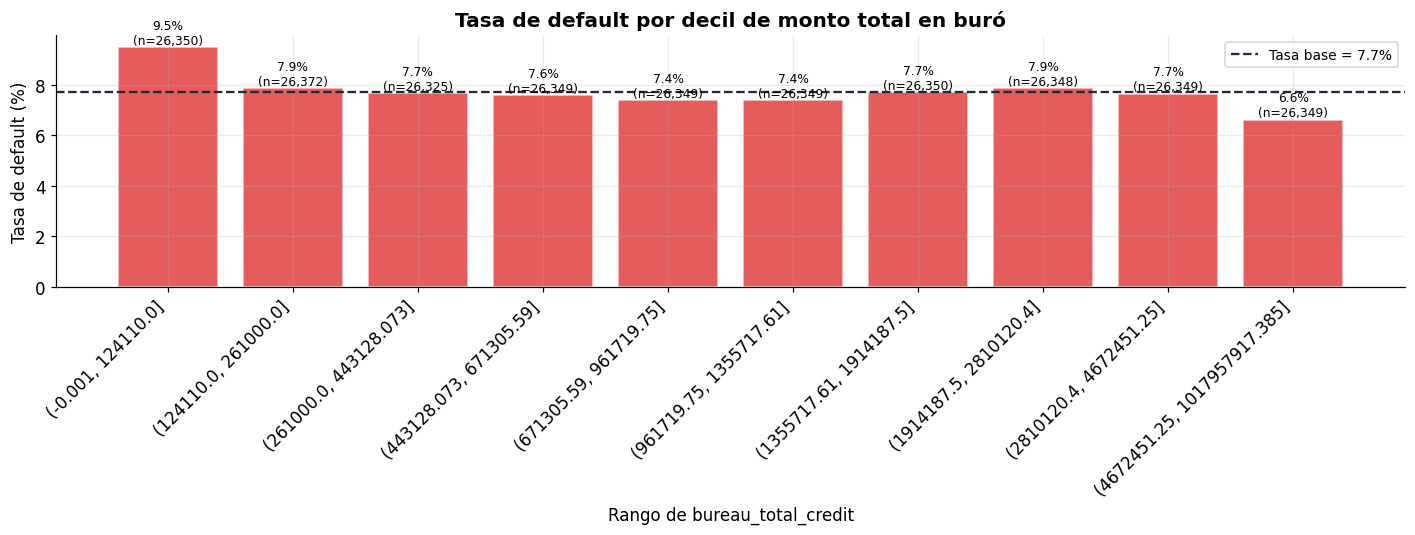


Tasa de default por rango monetario de bureau_total_credit:
MONTO_RANGE  total_clientes  clientes_default  tasa_default_pct  lift
          0            1082                89              8.23  1.06
     0-500k           85830              7115              8.29  1.07
    500k-1M           47812              3569              7.46  0.97
      1M-2M           52952              4001              7.56  0.98
      2M-5M           52170              4042              7.75  1.00
        5M+           23644              1552              6.56  0.85


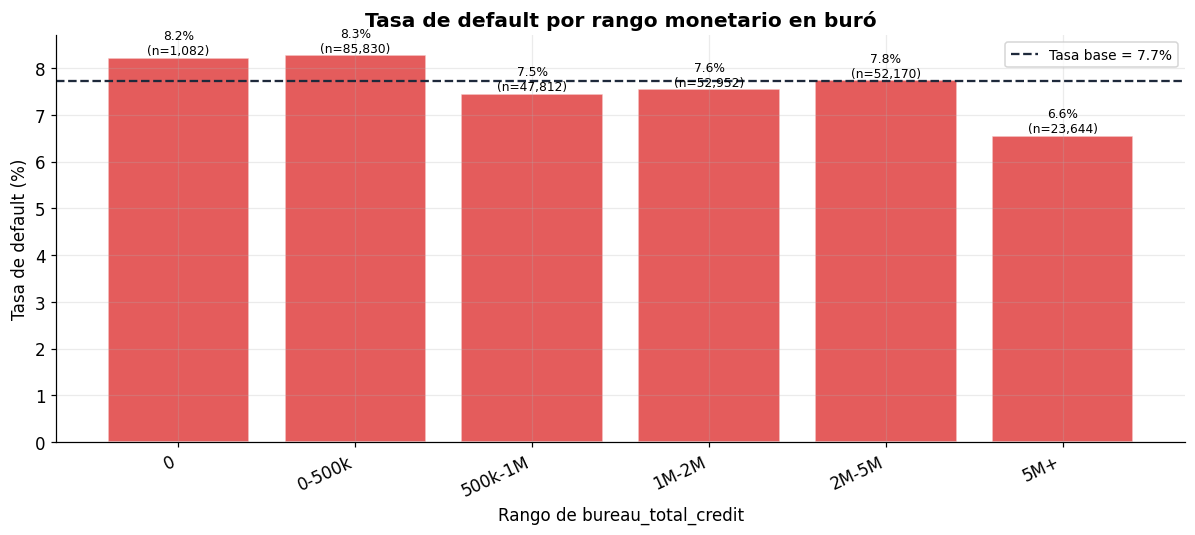


Menor tasa (rangos fijos): 5M+ (6.56%, lift=0.85x)
Mayor tasa (rangos fijos): 0-500k (8.29%, lift=1.07x)


In [77]:
ch = df.loc[df['no_bureau_history'] == 0, ['bureau_total_credit', 'TARGET']].dropna().copy()
tasa_base = ch['TARGET'].mean() * 100


def resumen_default_por_grupo(data, col_grupo, orden=None):
    res = (
        data.groupby(col_grupo, observed=False)['TARGET']
        .agg(total_clientes='size', clientes_default='sum')
    )
    if orden is not None:
        res = res.reindex(orden)
    res = res.reset_index()
    res['tasa_default_pct'] = (
        res['clientes_default'] / res['total_clientes'] * 100
    ).round(2)
    res['lift'] = (res['tasa_default_pct'] / tasa_base).round(2)
    return res


def plot_tasa_default(resumen, col_x, titulo, figsize=(12, 5), rotacion=35):
    fig, ax = plt.subplots(figsize=figsize)
    x_labels = resumen[col_x].astype(str)
    barras = ax.bar(x_labels, resumen['tasa_default_pct'],
                    color=RISK, alpha=0.75, edgecolor='white')
    for b, row in zip(barras, resumen.itertuples()):
        if pd.notna(row.tasa_default_pct):
            ax.text(b.get_x() + b.get_width() / 2, row.tasa_default_pct,
                    f'{row.tasa_default_pct:.1f}%\n(n={row.total_clientes:,})',
                    ha='center', va='bottom', fontsize=8)
    ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
               label=f'Tasa base = {tasa_base:.1f}%')
    ax.set_title(titulo)
    ax.set_xlabel('Rango de bureau_total_credit')
    ax.set_ylabel('Tasa de default (%)')
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=9)
    plt.xticks(rotation=rotacion, ha='right')
    fig.tight_layout()
    plt.show()


# --- Deciles ---
ch_dec = ch.copy()
ch_dec['decil'] = pd.qcut(ch_dec['bureau_total_credit'], q=10, duplicates='drop')
resumen_dec = resumen_default_por_grupo(ch_dec, 'decil')
resumen_dec['decil_label'] = resumen_dec['decil'].astype(str)

print('Tasa de default por decil de bureau_total_credit (clientes con historial):')
print(resumen_dec[['decil_label', 'total_clientes', 'clientes_default',
                   'tasa_default_pct', 'lift']].to_string(index=False))
print(f'\nTasa base (con historial de buró): {tasa_base:.2f}%')

plot_tasa_default(
    resumen_dec, 'decil_label',
    'Tasa de default por decil de monto total en buró',
    figsize=(13, 5), rotacion=45,
)

# --- Rangos monetarios fijos ---
bins_monto = [-1, 0, 500_000, 1_000_000, 2_000_000, 5_000_000, np.inf]
labels_monto = ['0', '0-500k', '500k-1M', '1M-2M', '2M-5M', '5M+']

ch_rng = ch.copy()
ch_rng['MONTO_RANGE'] = pd.cut(
    ch_rng['bureau_total_credit'], bins=bins_monto, labels=labels_monto, right=True
)
resumen_rng = resumen_default_por_grupo(ch_rng, 'MONTO_RANGE', orden=labels_monto)

print('\nTasa de default por rango monetario de bureau_total_credit:')
print(resumen_rng[['MONTO_RANGE', 'total_clientes', 'clientes_default',
                   'tasa_default_pct', 'lift']].to_string(index=False))

plot_tasa_default(
    resumen_rng, 'MONTO_RANGE',
    'Tasa de default por rango monetario en buró',
    figsize=(11, 5), rotacion=25,
)

mejor = resumen_rng.loc[resumen_rng['tasa_default_pct'].idxmin()]
peor = resumen_rng.loc[resumen_rng['tasa_default_pct'].idxmax()]
print(f'\nMenor tasa (rangos fijos): {mejor["MONTO_RANGE"]} ({mejor["tasa_default_pct"]:.2f}%, lift={mejor["lift"]:.2f}x)')
print(f'Mayor tasa (rangos fijos): {peor["MONTO_RANGE"]} ({peor["tasa_default_pct"]:.2f}%, lift={peor["lift"]:.2f}x)')

### Cantidad de clientes en default por monto total en buró

Aquí no miramos la **tasa proporcional**, sino el **volumen absoluto** de clientes con `TARGET = 1` en cada rango de `bureau_total_credit` (solo clientes con historial de buró).

También mostramos la **participación en el total de defaults** del subconjunto: qué porcentaje de todos los incumplimientos con historial de buró aporta cada grupo.

Cantidad de clientes en default por rango de bureau_total_credit:
MONTO_RANGE  total_clientes  clientes_default  participacion_en_defaults_pct
          0            1082                89                           0.44
     0-500k           85830              7115                          34.93
    500k-1M           47812              3569                          17.52
      1M-2M           52952              4001                          19.64
      2M-5M           52170              4042                          19.84
        5M+           23644              1552                           7.62

Total defaults (con historial de buró): 20,368


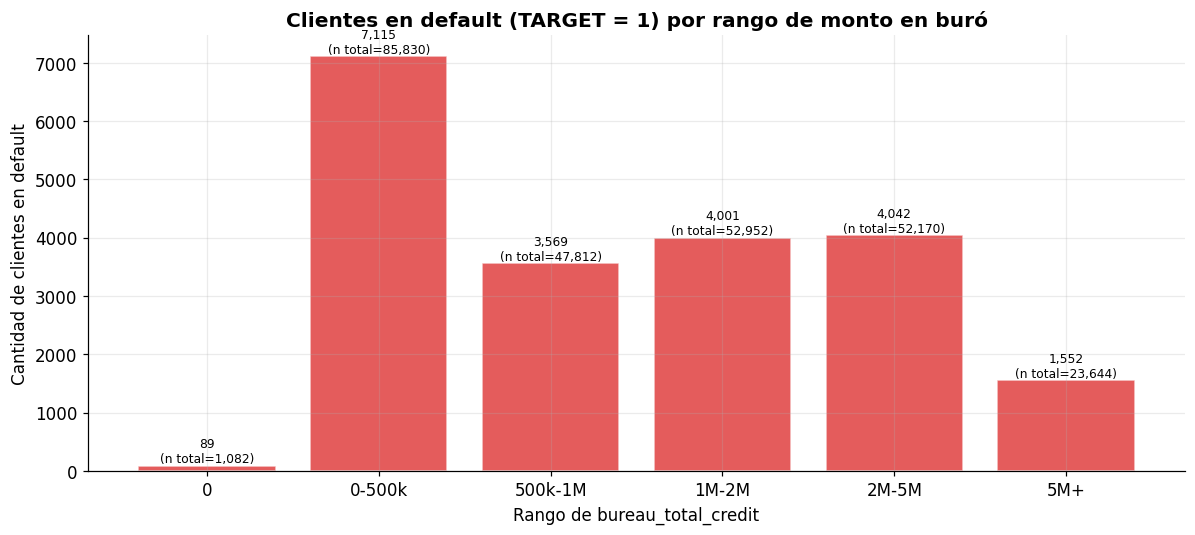

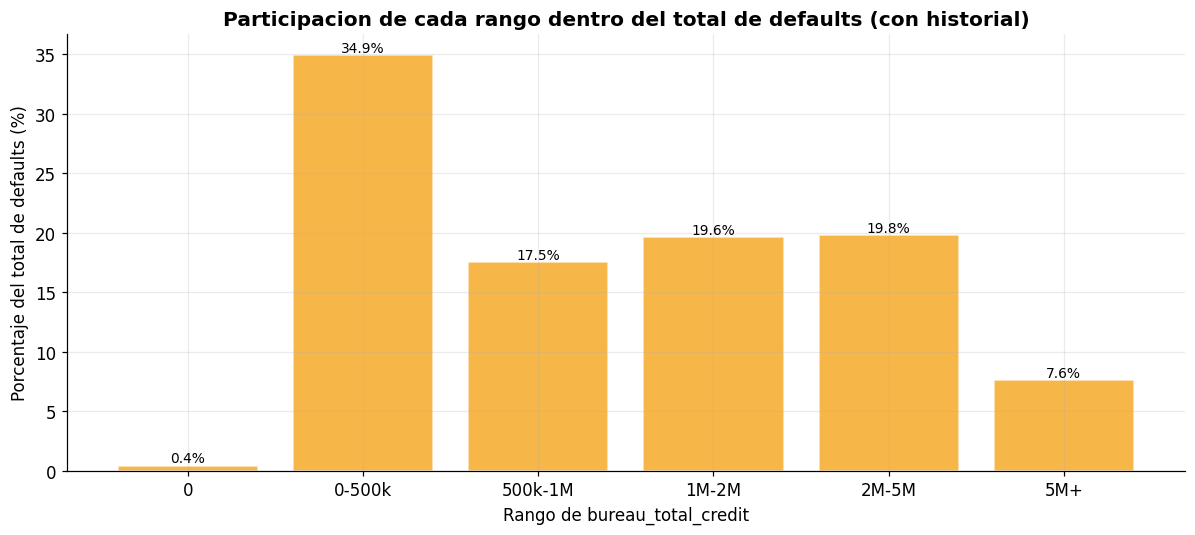

Mayor cantidad de defaults : 0-500k (7,115 casos)
Mayor participacion        : 0-500k (34.93% del total)


In [ ]:
ch = df.loc[df['no_bureau_history'] == 0, ['bureau_total_credit', 'TARGET']].dropna().copy()
total_defaults = int(ch['TARGET'].sum())

bins_monto = [-1, 0, 500_000, 1_000_000, 2_000_000, 5_000_000, np.inf]
labels_monto = ['0', '0-500k', '500k-1M', '1M-2M', '2M-5M', '5M+']

ch['MONTO_RANGE'] = pd.cut(
    ch['bureau_total_credit'], bins=bins_monto, labels=labels_monto, right=True
)

resumen_cnt = (
    ch.groupby('MONTO_RANGE', observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reindex(labels_monto)
    .reset_index()
)
resumen_cnt['participacion_en_defaults_pct'] = (
    resumen_cnt['clientes_default'] / total_defaults * 100
).round(2)

print('Cantidad de clientes en default por rango de bureau_total_credit:')
print(resumen_cnt.to_string(index=False))
print(f'\nTotal defaults (con historial de buró): {total_defaults:,}')

# Grafica 1: cantidad absoluta de defaults.
fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(
    resumen_cnt['MONTO_RANGE'].astype(str),
    resumen_cnt['clientes_default'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, row in zip(barras, resumen_cnt.itertuples()):
    if pd.notna(row.clientes_default):
        ax.text(
            b.get_x() + b.get_width() / 2, row.clientes_default,
            f'{int(row.clientes_default):,}\n(n total={row.total_clientes:,})',
            ha='center', va='bottom', fontsize=8,
        )
ax.set_title('Clientes en default (TARGET = 1) por rango de monto en buró')
ax.set_xlabel('Rango de bureau_total_credit')
ax.set_ylabel('Cantidad de clientes en default')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

# Grafica 2: participacion dentro del total de defaults.
fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(
    resumen_cnt['MONTO_RANGE'].astype(str),
    resumen_cnt['participacion_en_defaults_pct'],
    color=ACCENT, alpha=0.75, edgecolor='white',
)
for b, row in zip(barras, resumen_cnt.itertuples()):
    if pd.notna(row.participacion_en_defaults_pct):
        ax.text(
            b.get_x() + b.get_width() / 2, row.participacion_en_defaults_pct,
            f'{row.participacion_en_defaults_pct:.1f}%',
            ha='center', va='bottom', fontsize=9,
        )
ax.set_title('Participacion de cada rango dentro del total de defaults (con historial)')
ax.set_xlabel('Rango de bureau_total_credit')
ax.set_ylabel('Porcentaje del total de defaults (%)')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

r_cant = resumen_cnt.loc[resumen_cnt['clientes_default'].idxmax()]
r_part = resumen_cnt.loc[resumen_cnt['participacion_en_defaults_pct'].idxmax()]
print(f'Mayor cantidad de defaults : {r_cant["MONTO_RANGE"]} ({int(r_cant["clientes_default"]):,} casos)')
print(f'Mayor participacion        : {r_part["MONTO_RANGE"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total)')

### Cantidad total de clientes por rango (`TARGET = 0` y `TARGET = 1`)

Con los **mismos rangos monetarios** de `bureau_total_credit`, mostramos cuántos clientes hay en cada grupo, separando:

- **`TARGET = 0`** — clientes al día
- **`TARGET = 1`** — clientes en default

Solo clientes con historial de buró (`no_bureau_history == 0`).

## Distribucion de `bureau_pct_paid_early`

`bureau_pct_paid_early` es la **proporcion de creditos cerrados en el buro que se pagaron antes de lo esperado** (valor entre 0 y 1). Un valor alto indica buen historial de pago anticipado.

Nota: los clientes **sin historial de buro** (`no_bureau_history = 1`) tienen valor 0, por eso hay un pico grande en cero. La grafica siguiente muestra **todos los clientes**; la curva normal es solo referencia (la variable no es simetrica).

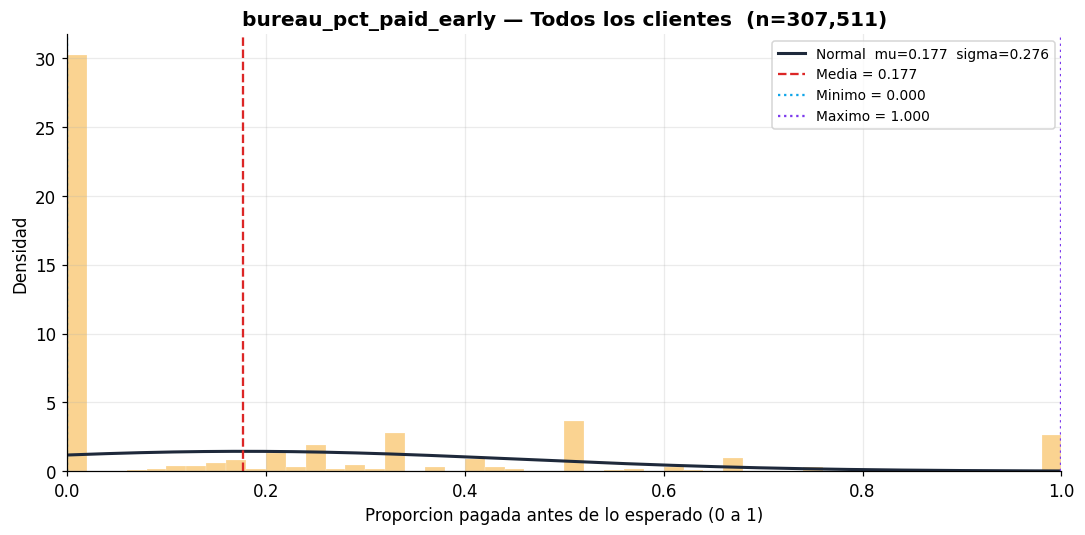

bureau_pct_paid_early — Todos:
  Minimo : 0.0000
  Media  : 0.1772
  Mediana: 0.0000
  Maximo : 1.0000
  % en cero: 60.4%


In [ ]:
datos = df['bureau_pct_paid_early'].dropna()
media, desv = datos.mean(), datos.std()
v_min, v_max = datos.min(), datos.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos, bins=50, density=True, color=ACCENT, alpha=0.45,
        edgecolor='white', linewidth=0.3)

x = np.linspace(0, 1, 300)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.3f}  sigma={desv:.3f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.3f}')
ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Minimo = {v_min:.3f}')
ax.axvline(v_max, color='#7c3aed', linestyle=':', linewidth=1.5, label=f'Maximo = {v_max:.3f}')

ax.set_title(f'bureau_pct_paid_early — Todos los clientes  (n={len(datos):,})')
ax.set_xlabel('Proporcion pagada antes de lo esperado (0 a 1)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('bureau_pct_paid_early — Todos:')
print(f'  Minimo : {v_min:.4f}')
print(f'  Media  : {media:.4f}')
print(f'  Mediana: {datos.median():.4f}')
print(f'  Maximo : {v_max:.4f}')
print(f'  % en cero: {(datos == 0).mean() * 100:.1f}%')

### `bureau_pct_paid_early` — Solo clientes en default (`TARGET = 1`)

Distribucion de la proporcion de creditos cerrados pagados antes de lo esperado, unicamente para los clientes que incumplieron.

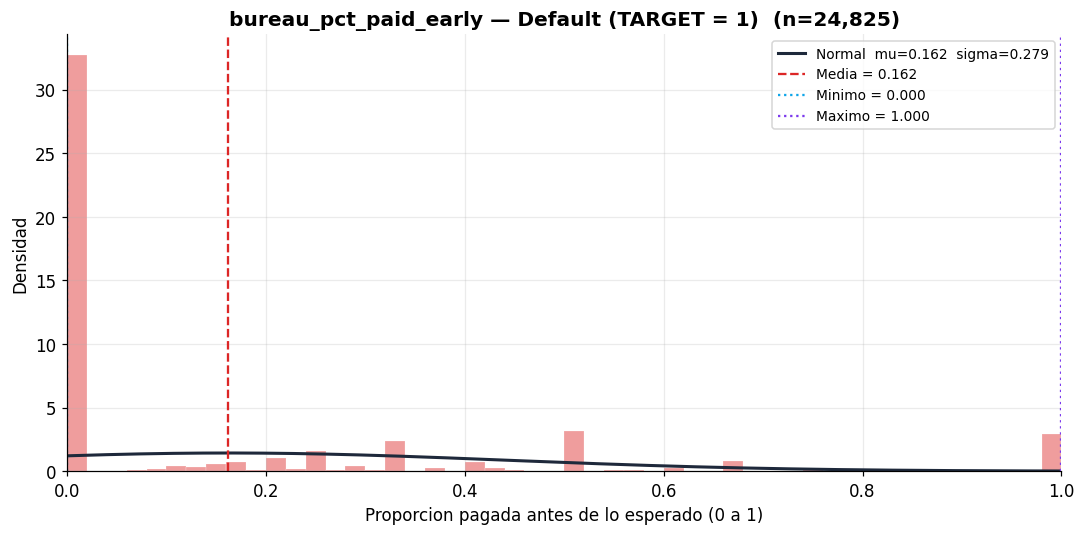

bureau_pct_paid_early — Default:
  Minimo : 0.0000
  Media  : 0.1622
  Mediana: 0.0000
  Maximo : 1.0000
  % en cero: 65.4%

Comparacion de medias:
  Todos   : 0.1772
  Default : 0.1622
  Al dia  : 0.1785


In [70]:
datos = df.loc[df['TARGET'] == 1, 'bureau_pct_paid_early'].dropna()
media, desv = datos.mean(), datos.std()
v_min, v_max = datos.min(), datos.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos, bins=50, density=True, color=RISK, alpha=0.45,
        edgecolor='white', linewidth=0.3)

x = np.linspace(0, 1, 300)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.3f}  sigma={desv:.3f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.3f}')
ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Minimo = {v_min:.3f}')
ax.axvline(v_max, color='#7c3aed', linestyle=':', linewidth=1.5, label=f'Maximo = {v_max:.3f}')

ax.set_title(f'bureau_pct_paid_early — Default (TARGET = 1)  (n={len(datos):,})')
ax.set_xlabel('Proporcion pagada antes de lo esperado (0 a 1)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print('bureau_pct_paid_early — Default:')
print(f'  Minimo : {v_min:.4f}')
print(f'  Media  : {media:.4f}')
print(f'  Mediana: {datos.median():.4f}')
print(f'  Maximo : {v_max:.4f}')
print(f'  % en cero: {(datos == 0).mean() * 100:.1f}%')

print()
print('Comparacion de medias:')
print(f'  Todos   : {df["bureau_pct_paid_early"].mean():.4f}')
print(f'  Default : {df.loc[df["TARGET"] == 1, "bureau_pct_paid_early"].mean():.4f}')
print(f'  Al dia  : {df.loc[df["TARGET"] == 0, "bureau_pct_paid_early"].mean():.4f}')

### ¿Pagar antes de tiempo implica menor default?

**Dos histogramas** (default vs al día) ayudan como primera pista: si quienes están al día tienen la distribución desplazada hacia la derecha (más % pagado anticipado), eso sugiere menor riesgo.

Pero **no responden del todo** porque muchos clientes tienen valor `0` (sin historial de buró o sin pagos anticipados). La gráfica que sí responde la pregunta es la **tasa de default por rango** de `bureau_pct_paid_early`: si la tasa baja cuando sube la proporción, entonces quienes pagan más antes de tiempo tienen menos default.

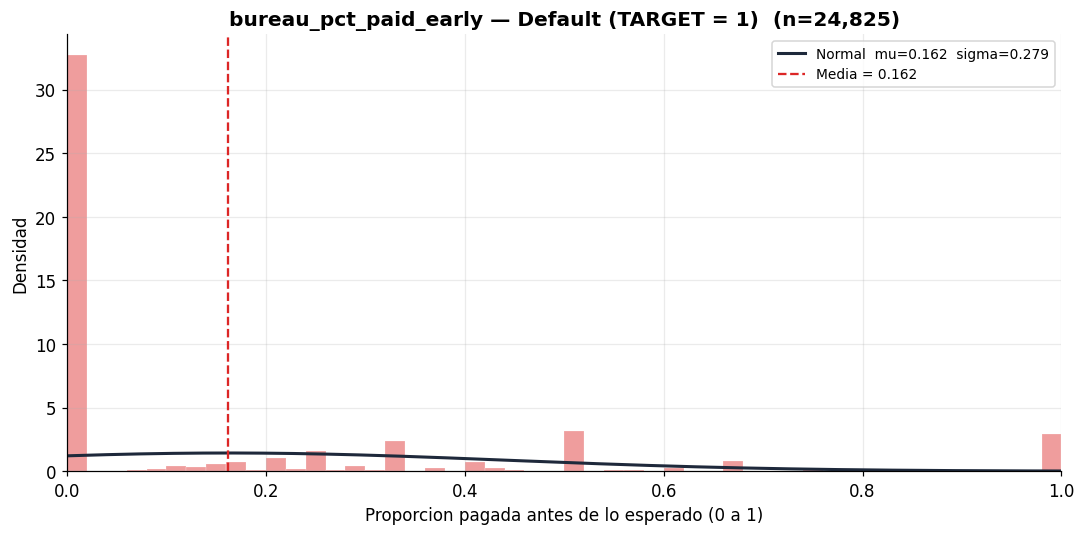

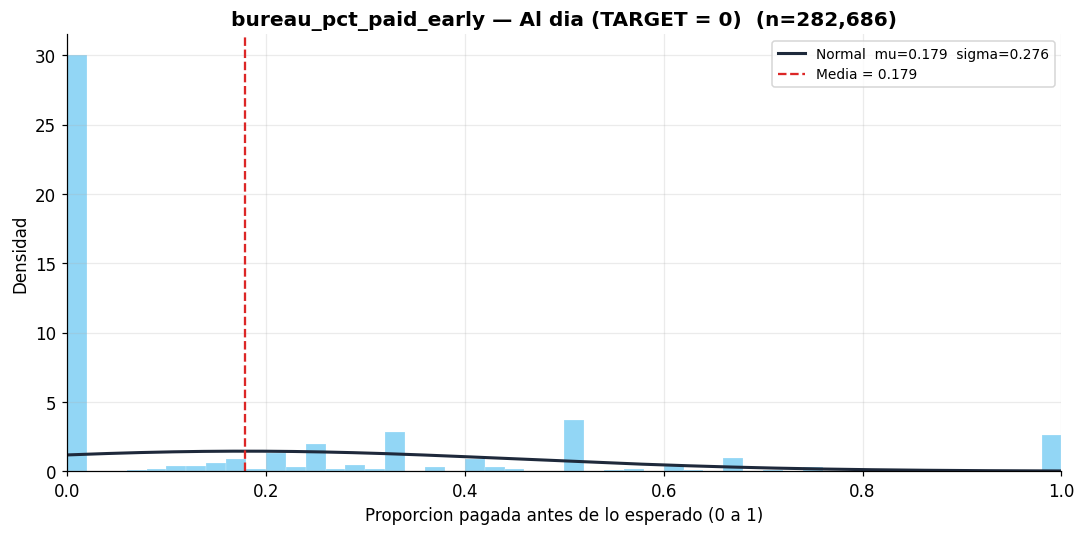

Media - Default : 0.1622
Media - Al dia  : 0.1785
Diferencia      : 0.0163  (positivo = al dia paga mas anticipado)


In [ ]:
def plot_pct_early(serie, titulo, color, bins=50):
    datos = serie.dropna()
    media, desv = datos.mean(), datos.std()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(datos, bins=bins, density=True, color=color, alpha=0.45,
            edgecolor='white', linewidth=0.3)

    x = np.linspace(0, 1, 300)
    ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
            label=f'Normal  mu={media:.3f}  sigma={desv:.3f}')
    ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5,
               label=f'Media = {media:.3f}')

    ax.set_title(f'{titulo}  (n={len(datos):,})')
    ax.set_xlabel('Proporcion pagada antes de lo esperado (0 a 1)')
    ax.set_ylabel('Densidad')
    ax.set_xlim(0, 1)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
    return media


media_def = plot_pct_early(
    df.loc[df['TARGET'] == 1, 'bureau_pct_paid_early'],
    'bureau_pct_paid_early — Default (TARGET = 1)', RISK,
)
media_ok = plot_pct_early(
    df.loc[df['TARGET'] == 0, 'bureau_pct_paid_early'],
    'bureau_pct_paid_early — Al dia (TARGET = 0)', SAFE,
)

print(f'Media - Default : {media_def:.4f}')
print(f'Media - Al dia  : {media_ok:.4f}')
print(f'Diferencia      : {media_ok - media_def:.4f}  (positivo = al dia paga mas anticipado)')

Tasa de default por rango de bureau_pct_paid_early:
       rango  total  defaults  tasa_pct  lift
           0 185835     16237      8.74  1.08
   (0, 0.10]   2879       239      8.30  1.03
(0.10, 0.25]  35048      2334      6.66  0.82
(0.25, 0.50]  54761      3729      6.81  0.84
(0.50, 0.75]  11638       764      6.56  0.81
(0.75, 1.00]  17350      1522      8.77  1.09

Tasa base: 8.07%


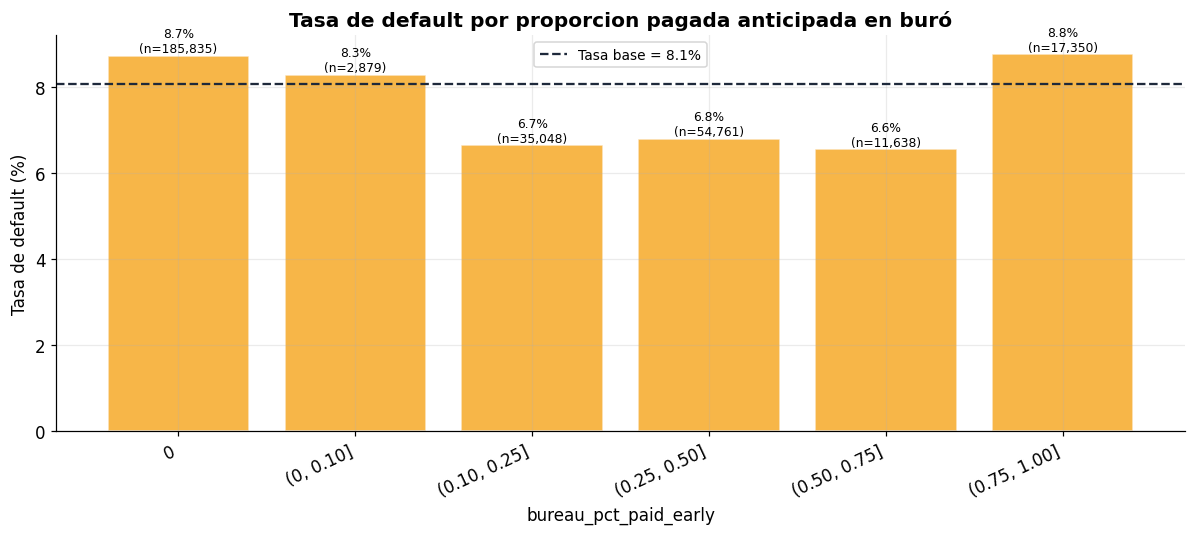


Menor tasa: (0.50, 0.75] (6.56%, lift=0.81x)
Mayor tasa: (0.75, 1.00] (8.77%, lift=1.09x)


In [ ]:
col = df[['bureau_pct_paid_early', 'TARGET']].copy()

bins = [-0.001, 0.001, 0.10, 0.25, 0.50, 0.75, 1.0]
etiquetas = ['0', '(0, 0.10]', '(0.10, 0.25]', '(0.25, 0.50]', '(0.50, 0.75]', '(0.75, 1.00]']

col['rango'] = pd.cut(col['bureau_pct_paid_early'], bins=bins, labels=etiquetas, ordered=True)

tasa_base = col['TARGET'].mean() * 100

resumen = (
    col.groupby('rango', observed=False)
    .agg(total=('TARGET', 'size'), defaults=('TARGET', 'sum'))
    .reset_index()
)
resumen['tasa_pct'] = (resumen['defaults'] / resumen['total'] * 100).round(2)
resumen['lift'] = (resumen['tasa_pct'] / tasa_base).round(2)

print('Tasa de default por rango de bureau_pct_paid_early:')
print(resumen.to_string(index=False))
print(f'\nTasa base: {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(resumen))
barras = ax.bar(x, resumen['tasa_pct'], color=ACCENT, alpha=0.75, edgecolor='white')
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')

for i, (b, row) in enumerate(zip(barras, resumen.itertuples())):
    ax.text(b.get_x() + b.get_width() / 2, row.tasa_pct,
            f'{row.tasa_pct:.1f}%\n(n={row.total:,})',
            ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(resumen['rango'], rotation=25, ha='right')
ax.set_title('Tasa de default por proporcion pagada anticipada en buró')
ax.set_xlabel('bureau_pct_paid_early')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

mejor = resumen.loc[resumen['tasa_pct'].idxmin()]
peor = resumen.loc[resumen['tasa_pct'].idxmax()]
print(f'\nMenor tasa: {mejor["rango"]} ({mejor["tasa_pct"]:.2f}%, lift={mejor["lift"]:.2f}x)')
print(f'Mayor tasa: {peor["rango"]} ({peor["tasa_pct"]:.2f}%, lift={peor["lift"]:.2f}x)')

## Distribución de la tasa de rechazo previa (`prev_refused_rate`)

`prev_refused_rate` es la **proporción de solicitudes anteriores rechazadas** por cliente (valor entre 0 y 1), calculada desde `previous_application`. Un valor de `0` puede indicar que no hubo rechazos o que el cliente no tiene historial de solicitudes previas.

Histograma de densidad con curva normal ajustada `N(media, σ)` y líneas de mínimo, media y máximo.

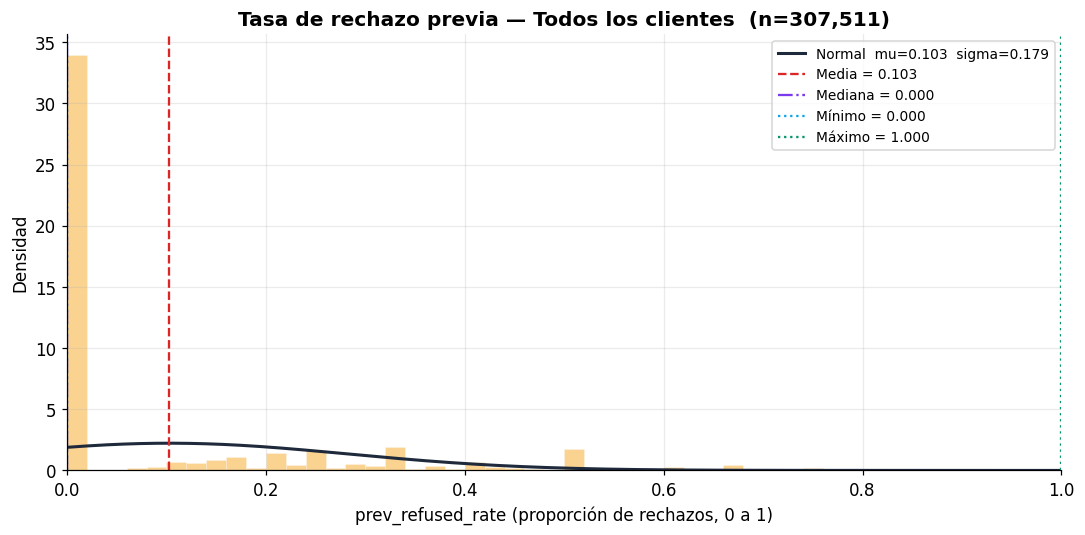

prev_refused_rate — todos los clientes:
  Mínimo  : 0.0000
  Media   : 0.1028
  Mediana : 0.0000
  Máximo  : 1.0000
  % en cero: 67.9%
  Clientes: 307,511


In [ ]:
col_refused = 'prev_refused_rate'
if col_refused not in df.columns and 'refused_rate' in df.columns:
    col_refused = 'refused_rate'

datos = df[col_refused].dropna()
media, desv = datos.mean(), datos.std()
v_min, v_max = datos.min(), datos.max()
p50 = datos.median()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos, bins=50, density=True, color=ACCENT, alpha=0.45,
        edgecolor='white', linewidth=0.4)

x = np.linspace(0, 1, 300)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.3f}  sigma={desv:.3f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.3f}')
ax.axvline(p50, color='#7c3aed', linestyle='-.', linewidth=1.5, label=f'Mediana = {p50:.3f}')
ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Mínimo = {v_min:.3f}')
ax.axvline(v_max, color='#059669', linestyle=':', linewidth=1.5, label=f'Máximo = {v_max:.3f}')

ax.set_title(f'Tasa de rechazo previa — Todos los clientes  (n={len(datos):,})')
ax.set_xlabel(f'{col_refused} (proporción de rechazos, 0 a 1)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 1)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f'{col_refused} — todos los clientes:')
print(f'  Mínimo  : {v_min:.4f}')
print(f'  Media   : {media:.4f}')
print(f'  Mediana : {p50:.4f}')
print(f'  Máximo  : {v_max:.4f}')
print(f'  % en cero: {(datos == 0).mean() * 100:.1f}%')
print(f'  Clientes: {len(datos):,}')

## Gráfica 5. Matriz: tasa de rechazo × cantidad de solicitudes previas

Mapa de calor para formular hipótesis sobre el riesgo según **historial de solicitudes anteriores**:

- **Eje X** — grupo de número de solicitudes previas (`prev_app_count`)
- **Eje Y** — grupo de tasa de rechazo (`prev_refused_rate`)
- **Valor en cada celda** — tasa de default (`TARGET = 1`)

Solo clientes con **al menos 1 solicitud previa** (`prev_app_count ≥ 1`). Las celdas con muestra baja se ocultan en la gráfica para no interpretar tasas inestables.

Matriz de tasa de default (%) — rechazo x solicitudes previas:
GRUPO_SOLICITUDES  1 solicitud  2 a 3  4 a 5  6 a 10  Más de 10
GRUPO_RECHAZO                                                  
0%                        8.39   7.07   6.18    5.83       5.90
Hasta 25%                  NaN    NaN   8.83    8.03       7.83
25% a 50%                  NaN  11.24  11.93   11.28      11.66
Más de 50%                 NaN  14.88  16.41   16.40      16.44
100%                      9.80  10.34  18.52   18.18      33.33

Cantidad de clientes (n) por celda:
GRUPO_SOLICITUDES  1 solicitud  2 a 3  4 a 5  6 a 10  Más de 10
GRUPO_RECHAZO                                                  
0%                       52420  71920  38458   26796       2659
Hasta 25%                    0      0  13629   22925      10568
25% a 50%                    0  12307   5413   14149       9099
Más de 50%                   0   1882   2255    3481       2652
100%                       255    145     27      11          3


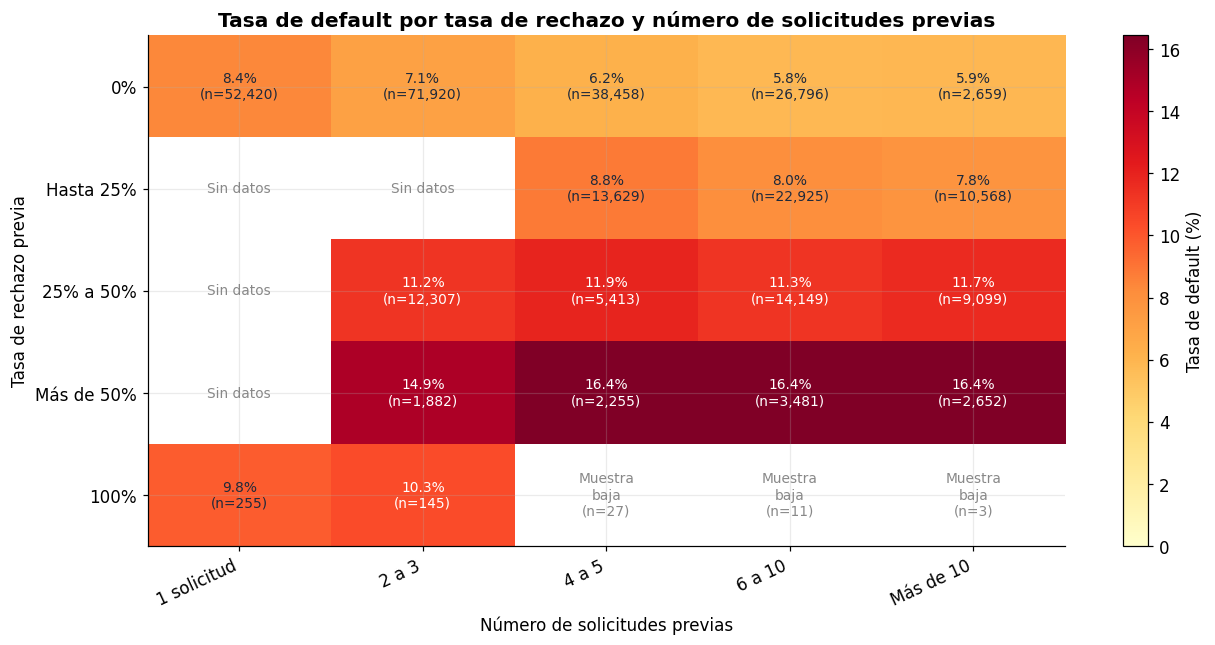


Tasa base (clientes con solicitudes previas): 8.19%
Mayor tasa (n>=100): Más de 50% | Más de 10 (16.44%, n=2,652)
Menor tasa (n>=100): 0% | 6 a 10 (5.83%, n=26,796)


In [81]:
col_refused = 'prev_refused_rate' if 'prev_refused_rate' in df.columns else 'refused_rate'
col_count = 'prev_app_count'

work = df[[col_count, col_refused, 'TARGET']].dropna().copy()
work = work[work[col_count] >= 1].copy()

orden_rechazo = ['0%', 'Hasta 25%', '25% a 50%', 'Más de 50%', '100%']
orden_solicitudes = ['1 solicitud', '2 a 3', '4 a 5', '6 a 10', 'Más de 10']


def grupo_rechazo(r):
    if r == 0:
        return '0%'
    if r == 1:
        return '100%'
    if r <= 0.25:
        return 'Hasta 25%'
    if r <= 0.50:
        return '25% a 50%'
    return 'Más de 50%'


def grupo_solicitudes(n):
    n = int(n)
    if n == 1:
        return '1 solicitud'
    if n <= 3:
        return '2 a 3'
    if n <= 5:
        return '4 a 5'
    if n <= 10:
        return '6 a 10'
    return 'Más de 10'


work['GRUPO_RECHAZO'] = work[col_refused].map(grupo_rechazo)
work['GRUPO_SOLICITUDES'] = work[col_count].map(grupo_solicitudes)

tabla = (
    work.groupby(['GRUPO_RECHAZO', 'GRUPO_SOLICITUDES'], observed=False)
    .agg(total_clientes=('TARGET', 'size'), clientes_default=('TARGET', 'sum'))
    .reset_index()
)
tabla['tasa_default_pct'] = (
    tabla['clientes_default'] / tabla['total_clientes'] * 100
).round(2)

# Tabla completa ordenada (como la matriz pedida).
matriz_tabla = (
    tabla.pivot(index='GRUPO_RECHAZO', columns='GRUPO_SOLICITUDES', values='tasa_default_pct')
    .reindex(index=orden_rechazo, columns=orden_solicitudes)
)
matriz_n = (
    tabla.pivot(index='GRUPO_RECHAZO', columns='GRUPO_SOLICITUDES', values='total_clientes')
    .reindex(index=orden_rechazo, columns=orden_solicitudes)
    .fillna(0)
    .astype(int)
)

print('Matriz de tasa de default (%) — rechazo x solicitudes previas:')
print(matriz_tabla.to_string(float_format=lambda x: f'{x:.2f}' if pd.notna(x) else '—'))
print('\nCantidad de clientes (n) por celda:')
print(matriz_n.to_string())

MIN_CLIENTES = 100
matriz_vis = matriz_tabla.where(matriz_n >= MIN_CLIENTES)

fig, ax = plt.subplots(figsize=(12, 6))
datos = matriz_vis.to_numpy(dtype=float)
vmax = np.nanmax(datos) if np.isfinite(np.nanmax(datos)) else 1
im = ax.imshow(datos, cmap='YlOrRd', aspect='auto', vmin=0, vmax=max(vmax, 1))

ax.set_xticks(range(len(orden_solicitudes)))
ax.set_xticklabels(orden_solicitudes, rotation=25, ha='right')
ax.set_yticks(range(len(orden_rechazo)))
ax.set_yticklabels(orden_rechazo)

for i in range(len(orden_rechazo)):
    for j in range(len(orden_solicitudes)):
        tasa = datos[i, j]
        n = int(matriz_n.iloc[i, j])
        if n == 0:
            texto, color = 'Sin datos', '#888888'
        elif np.isnan(tasa):
            texto, color = f'Muestra\nbaja\n(n={n:,})', '#888888'
        else:
            color = 'white' if tasa > 0.6 * max(vmax, 1) else INK
            texto = f'{tasa:.1f}%\n(n={n:,})'
        ax.text(j, i, texto, ha='center', va='center', fontsize=9, color=color)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Tasa de default (%)')
ax.set_title('Tasa de default por tasa de rechazo y número de solicitudes previas')
ax.set_xlabel('Número de solicitudes previas')
ax.set_ylabel('Tasa de rechazo previa')
fig.tight_layout()
plt.show()

tasa_base = work['TARGET'].mean() * 100
validas = tabla[tabla['total_clientes'] >= MIN_CLIENTES]
if not validas.empty:
    r_max = validas.loc[validas['tasa_default_pct'].idxmax()]
    r_min = validas.loc[validas['tasa_default_pct'].idxmin()]
    print(f'\nTasa base (clientes con solicitudes previas): {tasa_base:.2f}%')
    print(f'Mayor tasa (n>={MIN_CLIENTES}): {r_max["GRUPO_RECHAZO"]} | {r_max["GRUPO_SOLICITUDES"]} '
          f'({r_max["tasa_default_pct"]:.2f}%, n={int(r_max["total_clientes"]):,})')
    print(f'Menor tasa (n>={MIN_CLIENTES}): {r_min["GRUPO_RECHAZO"]} | {r_min["GRUPO_SOLICITUDES"]} '
          f'({r_min["tasa_default_pct"]:.2f}%, n={int(r_min["total_clientes"]):,})')

# Educación, ocupación e ingreso

Variables categóricas socio-laborales. El cruce edad × educación y la curva por edad reutilizan `bins_edad`/`labels_edad` y `plot_age_normal` definidos antes.

## Tasa de default por nivel de educacion (`NAME_EDUCATION_TYPE`)

Comparamos el **riesgo proporcional** segun el nivel educativo del cliente. Ademas de la tasa de default por grupo, mostramos cuantos clientes hay en cada nivel, ya que algunos (como `Academic degree`) tienen muy pocos registros y su tasa puede ser inestable.

```text
Tasa de default = clientes con TARGET = 1 en el nivel / total del nivel x 100
```

Las barras se ordenan de mayor a menor tasa de default y se compara contra la **tasa base** del dataset.

Tasa de default por nivel de educacion:
          NAME_EDUCATION_TYPE  total_clientes  clientes_default  tasa_default_pct
              Lower secondary            3816               417             10.93
Secondary / secondary special          218391             19524              8.94
            Incomplete higher           10277               872              8.48
             Higher education           74863              4009              5.36
              Academic degree             164                 3              1.83

Tasa base (todo el dataset): 8.07%


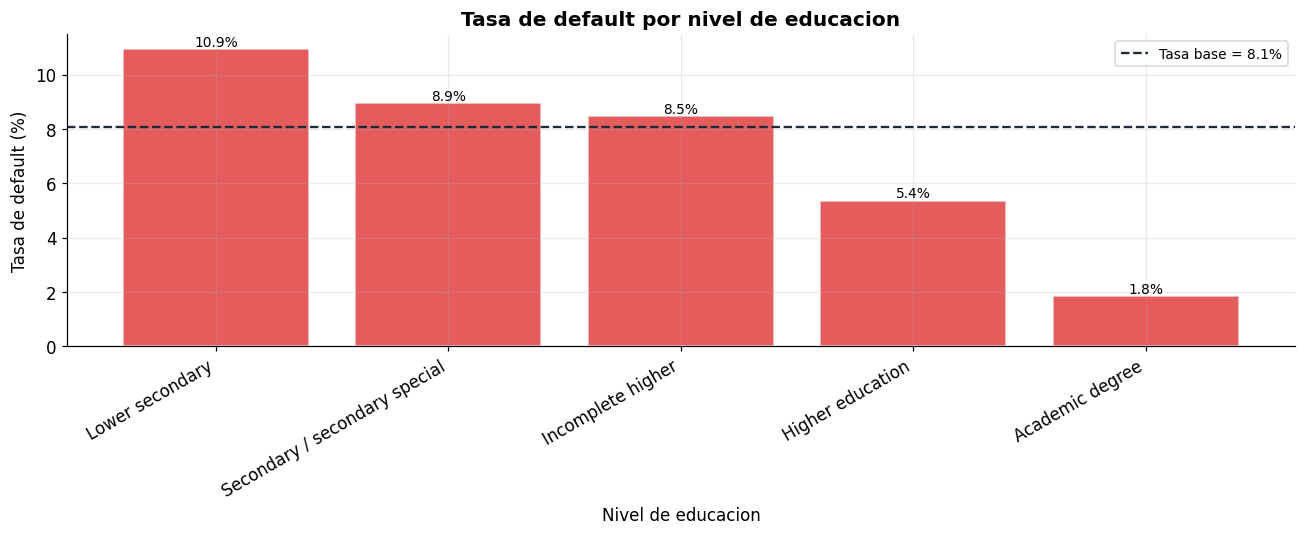

In [33]:
resumen_educ = (
    df.groupby('NAME_EDUCATION_TYPE')['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
)
resumen_educ['tasa_default_pct'] = (
    resumen_educ['clientes_default'] / resumen_educ['total_clientes'] * 100
).round(2)
resumen_educ = resumen_educ.sort_values('tasa_default_pct', ascending=False).reset_index()

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default por nivel de educacion:')
print(resumen_educ.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(resumen_educ['NAME_EDUCATION_TYPE'], resumen_educ['tasa_default_pct'],
                color=RISK, alpha=0.75, edgecolor='white')
for b, v in zip(barras, resumen_educ['tasa_default_pct']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=9)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por nivel de educacion')
ax.set_xlabel('Nivel de educacion')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
plt.show()

## Edad y educacion combinadas: matriz de calor de tasa de default

Hasta ahora vimos edad y educacion **por separado**:

- La grafica por **edad** muestra como cambia la tasa de default al aumentar la edad.
- La grafica por **educacion** muestra diferencias entre niveles educativos.

La **matriz de calor** cruza ambas variables a la vez. Cada celda responde:

> Que porcentaje de clientes de este rango de edad y este nivel educativo presento default?

**Ejemplo:**

```text
Clientes de 20-25 anios con educacion secundaria:
  1.000 clientes en total
    150 clientes en default
Tasa de default = 150 / 1.000 x 100 = 15%
```

Consideraciones importantes:

- Esto **no implica causalidad**: la edad o la educacion no "causan" el default; son senales asociadas al riesgo.
- Las combinaciones con **pocos clientes** pueden dar porcentajes altos o bajos poco estables. Por eso, las combinaciones con menos de `MIN_CLIENTES = 100` observaciones se **ocultan en la visualizacion** (no se eliminan del dataset).

Tabla edad x educacion (ordenada):
AGE_RANGE           NAME_EDUCATION_TYPE  total_clientes  clientes_default  tasa_default_pct
    20-25               Academic degree               3                 0              0.00
    20-25              Higher education            2572               199              7.74
    20-25             Incomplete higher            1958               163              8.32
    20-25               Lower secondary             111                18             16.22
    20-25 Secondary / secondary special            7589              1124             14.81
    25-30               Academic degree              12                 0              0.00
    25-30              Higher education           11291               727              6.44
    25-30             Incomplete higher            2510               266             10.60
    25-30               Lower secondary             259                44             16.99
    25-30 Secondary / secondary special      

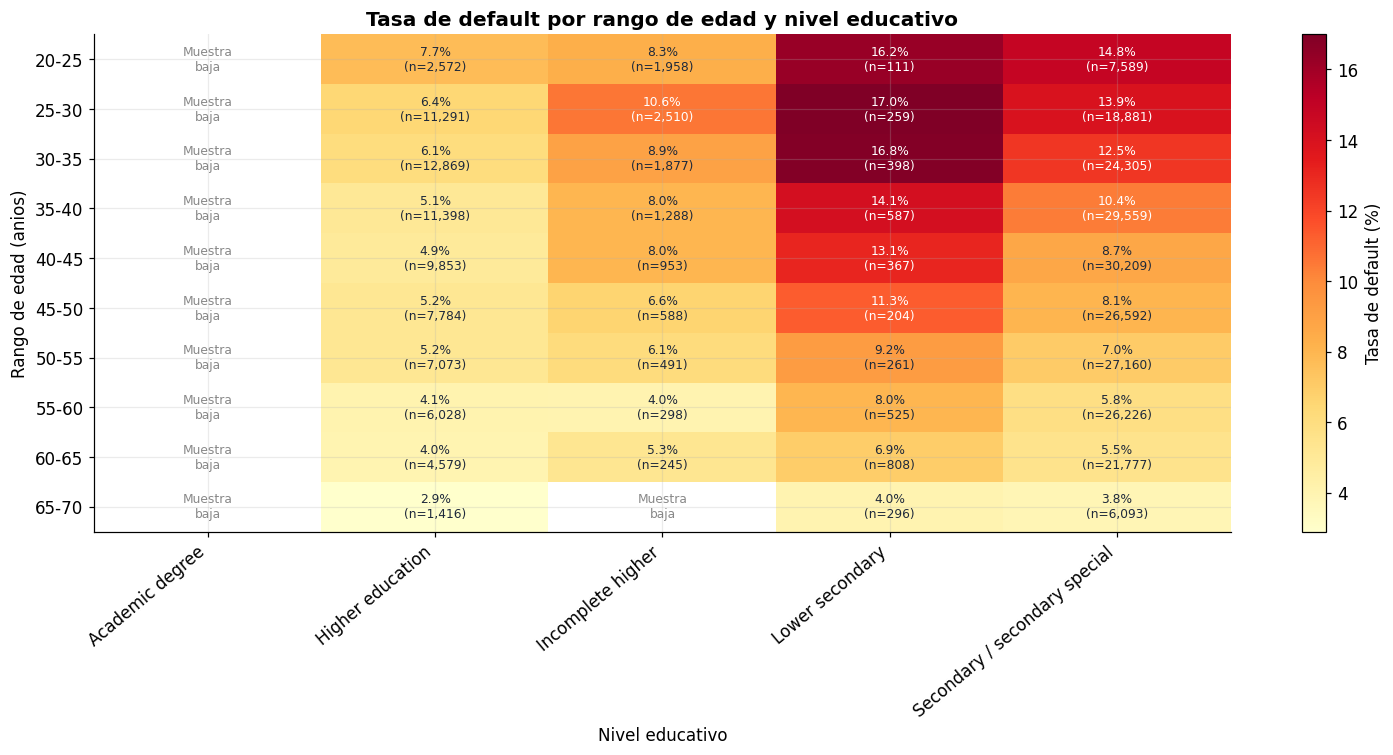


Hallazgos:
  Mayor tasa de default     : 25-30 | Lower secondary (16.99%, n=259)
  Mayor cantidad de defaults: 35-40 | Secondary / secondary special (3,076 casos)
  Mayor numero de clientes  : 40-45 | Secondary / secondary special (30,209 clientes)
  Combinaciones excluidas   : 11 (por muestra baja)


In [34]:
# 1. Copia segura: no modificamos el DataFrame original.
df_edad_educacion = df[["AGE_YEARS", "NAME_EDUCATION_TYPE", "TARGET"]].copy()

bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70]
etiquetas = ['20-25', '25-30', '30-35', '35-40', '40-45',
             '45-50', '50-55', '55-60', '60-65', '65-70']
df_edad_educacion["AGE_RANGE"] = pd.cut(
    df_edad_educacion["AGE_YEARS"], bins=bins, right=False,
    labels=etiquetas, ordered=True,
)

# 2. Tabla cruzada edad x educacion.
tabla_edad_educacion = (
    df_edad_educacion.groupby(["AGE_RANGE", "NAME_EDUCATION_TYPE"], observed=False)
    .agg(total_clientes=("TARGET", "size"), clientes_default=("TARGET", "sum"))
)
tabla_edad_educacion["tasa_default_pct"] = (
    tabla_edad_educacion["clientes_default"] / tabla_edad_educacion["total_clientes"] * 100
).round(2)
tabla_edad_educacion = tabla_edad_educacion.reset_index()

print("Tabla edad x educacion (ordenada):")
print(tabla_edad_educacion.sort_values(["AGE_RANGE", "NAME_EDUCATION_TYPE"]).to_string(index=False))

# 3. Umbral de representatividad.
MIN_CLIENTES = 100

# Las combinaciones con pocos clientes se ocultan unicamente en la visualizacion
# para evitar interpretar tasas inestables. No se eliminan registros del dataset.
tabla_vis = tabla_edad_educacion.copy()
tabla_vis["tasa_default_pct"] = tabla_vis["tasa_default_pct"].where(
    tabla_vis["total_clientes"] >= MIN_CLIENTES, np.nan
)

excluidas = tabla_edad_educacion[tabla_edad_educacion["total_clientes"] < MIN_CLIENTES]
print(f"\nCombinaciones excluidas de la grafica por muestra baja (< {MIN_CLIENTES} clientes): {len(excluidas)}")
if not excluidas.empty:
    print(excluidas.sort_values("total_clientes").to_string(index=False))

# 4. Matrices para la visualizacion.
matriz_tasa_default = tabla_vis.pivot(
    index="AGE_RANGE", columns="NAME_EDUCATION_TYPE", values="tasa_default_pct"
)
matriz_total_clientes = tabla_edad_educacion.pivot(
    index="AGE_RANGE", columns="NAME_EDUCATION_TYPE", values="total_clientes"
)

# 5. Heatmap con matplotlib.
fig, ax = plt.subplots(figsize=(14, 7))
datos = matriz_tasa_default.to_numpy(dtype=float)
im = ax.imshow(datos, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(matriz_tasa_default.shape[1]))
ax.set_xticklabels(matriz_tasa_default.columns, rotation=40, ha="right")
ax.set_yticks(range(matriz_tasa_default.shape[0]))
ax.set_yticklabels(matriz_tasa_default.index)

for i in range(matriz_tasa_default.shape[0]):
    for j in range(matriz_tasa_default.shape[1]):
        tasa = datos[i, j]
        n = matriz_total_clientes.iloc[i, j]
        if np.isnan(tasa):
            texto, color = "Muestra\nbaja", "#888888"
        else:
            # Texto en blanco sobre celdas oscuras (tasas altas).
            vmax = np.nanmax(datos)
            color = "white" if tasa > 0.6 * vmax else INK
            texto = f"{tasa:.1f}%\n(n={int(n):,})"
        ax.text(j, i, texto, ha="center", va="center", fontsize=8, color=color)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Tasa de default (%)")
ax.set_title("Tasa de default por rango de edad y nivel educativo")
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Rango de edad (anios)")
fig.tight_layout()
plt.show()

# 6. Hallazgos automaticos (solo combinaciones con representatividad suficiente).
validas = tabla_edad_educacion[tabla_edad_educacion["total_clientes"] >= MIN_CLIENTES]
r_tasa = validas.loc[validas["tasa_default_pct"].idxmax()]
r_def = tabla_edad_educacion.loc[tabla_edad_educacion["clientes_default"].idxmax()]
r_tot = tabla_edad_educacion.loc[tabla_edad_educacion["total_clientes"].idxmax()]

print("\nHallazgos:")
print(f"  Mayor tasa de default     : {r_tasa['AGE_RANGE']} | {r_tasa['NAME_EDUCATION_TYPE']} "
      f"({r_tasa['tasa_default_pct']:.2f}%, n={int(r_tasa['total_clientes']):,})")
print(f"  Mayor cantidad de defaults: {r_def['AGE_RANGE']} | {r_def['NAME_EDUCATION_TYPE']} "
      f"({int(r_def['clientes_default']):,} casos)")
print(f"  Mayor numero de clientes  : {r_tot['AGE_RANGE']} | {r_tot['NAME_EDUCATION_TYPE']} "
      f"({int(r_tot['total_clientes']):,} clientes)")
print(f"  Combinaciones excluidas   : {len(excluidas)} (por muestra baja)")

La matriz de calor permite identificar si la relacion entre edad y riesgo de incumplimiento se mantiene al considerar el nivel educativo. Una tasa elevada en una combinacion especifica no implica que la edad o el nivel educativo causen directamente el default. Estas variables deben interpretarse como senales asociadas al riesgo y analizarse junto con ingresos, historial crediticio, estabilidad laboral y comportamiento previo de pago.

## Cantidad de clientes por nivel educativo

Distribucion de clientes segun su nivel educativo (`NAME_EDUCATION_TYPE`), ordenada de mayor a menor cantidad.

Cantidad de clientes por nivel educativo:
  Secondary / secondary special   : 218,391  (71.0%)
  Higher education                :  74,863  (24.3%)
  Incomplete higher               :  10,277  (3.3%)
  Lower secondary                 :   3,816  (1.2%)
  Academic degree                 :     164  (0.1%)


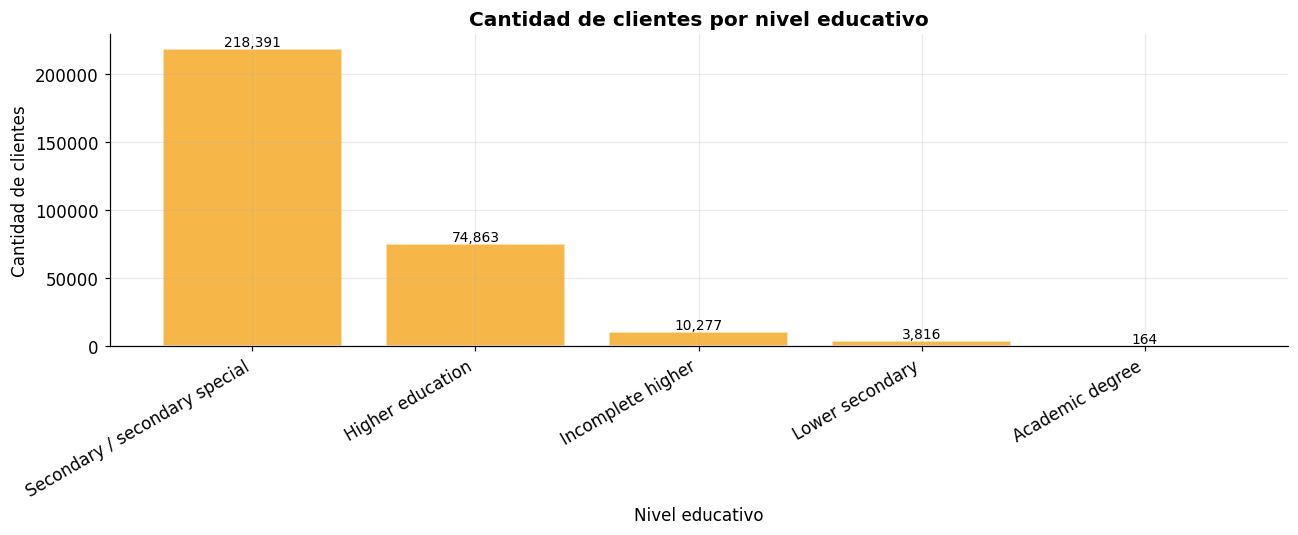

In [45]:
conteo_educ = df['NAME_EDUCATION_TYPE'].value_counts()
total = int(conteo_educ.sum())

print('Cantidad de clientes por nivel educativo:')
for nivel, cant in conteo_educ.items():
    print(f'  {nivel:<32}: {cant:>7,}  ({cant / total * 100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 5))
barras = ax.bar(conteo_educ.index, conteo_educ.values,
                color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, conteo_educ.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{int(v):,}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Cantidad de clientes por nivel educativo')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
plt.show()

## Tasa de default por nivel educativo: hombres vs mujeres

Como los grupos estan **desbalanceados** (mas mujeres que hombres y niveles educativos de tamano muy distinto), comparamos la **tasa de default** y no la cantidad. Asi el riesgo es comparable entre grupos sin importar su tamano.

```text
Tasa de default = clientes con TARGET = 1 del grupo / total del grupo x 100
```

Barras agrupadas por nivel educativo, una para hombres y otra para mujeres.

Tasa de default (%) por nivel educativo y genero:
CODE_GENDER                    Hombres  Mujeres
NAME_EDUCATION_TYPE                            
Lower secondary                  13.49     9.26
Secondary / secondary special    11.36     7.68
Incomplete higher                 9.22     8.02
Higher education                  6.39     4.85
Academic degree                   0.00     3.00

Tasa base (todo el dataset): 8.07%


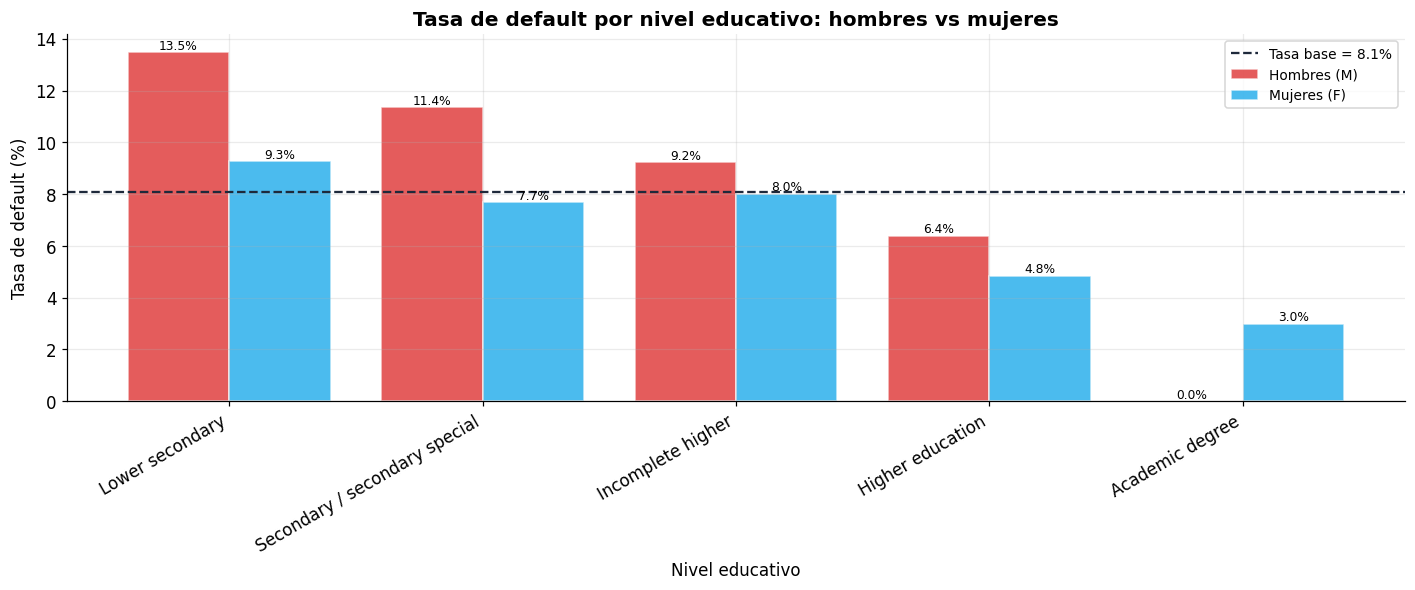

In [46]:
ge = df[df['CODE_GENDER'].isin(['M', 'F'])]

tabla = (
    ge.groupby(['NAME_EDUCATION_TYPE', 'CODE_GENDER'], observed=False)['TARGET']
    .agg(total='size', defaults='sum')
)
tabla['tasa_default_pct'] = (tabla['defaults'] / tabla['total'] * 100).round(2)

matriz_tasa = tabla['tasa_default_pct'].unstack('CODE_GENDER').reindex(columns=['M', 'F'])
# Ordena los niveles por la tasa promedio entre generos (mayor a menor).
matriz_tasa = matriz_tasa.loc[matriz_tasa.mean(axis=1).sort_values(ascending=False).index]

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default (%) por nivel educativo y genero:')
print(matriz_tasa.rename(columns={'M': 'Hombres', 'F': 'Mujeres'}).to_string())
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

niveles = list(matriz_tasa.index)
x = np.arange(len(niveles))
ancho = 0.4

fig, ax = plt.subplots(figsize=(13, 5.5))
b1 = ax.bar(x - ancho / 2, matriz_tasa['M'].values, ancho, label='Hombres (M)',
            color=RISK, alpha=0.75, edgecolor='white')
b2 = ax.bar(x + ancho / 2, matriz_tasa['F'].values, ancho, label='Mujeres (F)',
            color=SAFE, alpha=0.75, edgecolor='white')

for barras in (b1, b2):
    for b in barras:
        h = b.get_height()
        if pd.notna(h):
            ax.text(b.get_x() + b.get_width() / 2, h, f'{h:.1f}%',
                    ha='center', va='bottom', fontsize=8)

ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_xticks(x)
ax.set_xticklabels(niveles, rotation=30, ha='right')
ax.set_title('Tasa de default por nivel educativo: hombres vs mujeres')
ax.set_xlabel('Nivel educativo')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Tasa de default por nivel educativo a lo largo de la edad

En lugar de comparar por genero, cruzamos **nivel educativo** con los **rangos de edad de 5 en 5** (`20-25`, ..., `65-70`). Cada linea es un nivel educativo y muestra como cambia su **tasa de default** segun la edad.

```text
Tasa de default = clientes con TARGET = 1 en (nivel, rango) / total en (nivel, rango) x 100
```

Las combinaciones con menos de 100 clientes se ocultan (quedan como `NaN`) para no mostrar tasas inestables.

Tasa de default (%) por edad y nivel educativo:
NAME_EDUCATION_TYPE  Academic degree  Higher education  Incomplete higher  Lower secondary  Secondary / secondary special
AGE_RANGE                                                                                                                
20-25                            NaN              7.74               8.32            16.22                          14.81
25-30                            NaN              6.44              10.60            16.99                          13.93
30-35                            NaN              6.06               8.90            16.83                          12.50
35-40                            NaN              5.10               8.00            14.14                          10.41
40-45                            NaN              4.90               7.97            13.08                           8.72
45-50                            NaN              5.20               6.63            11.27        

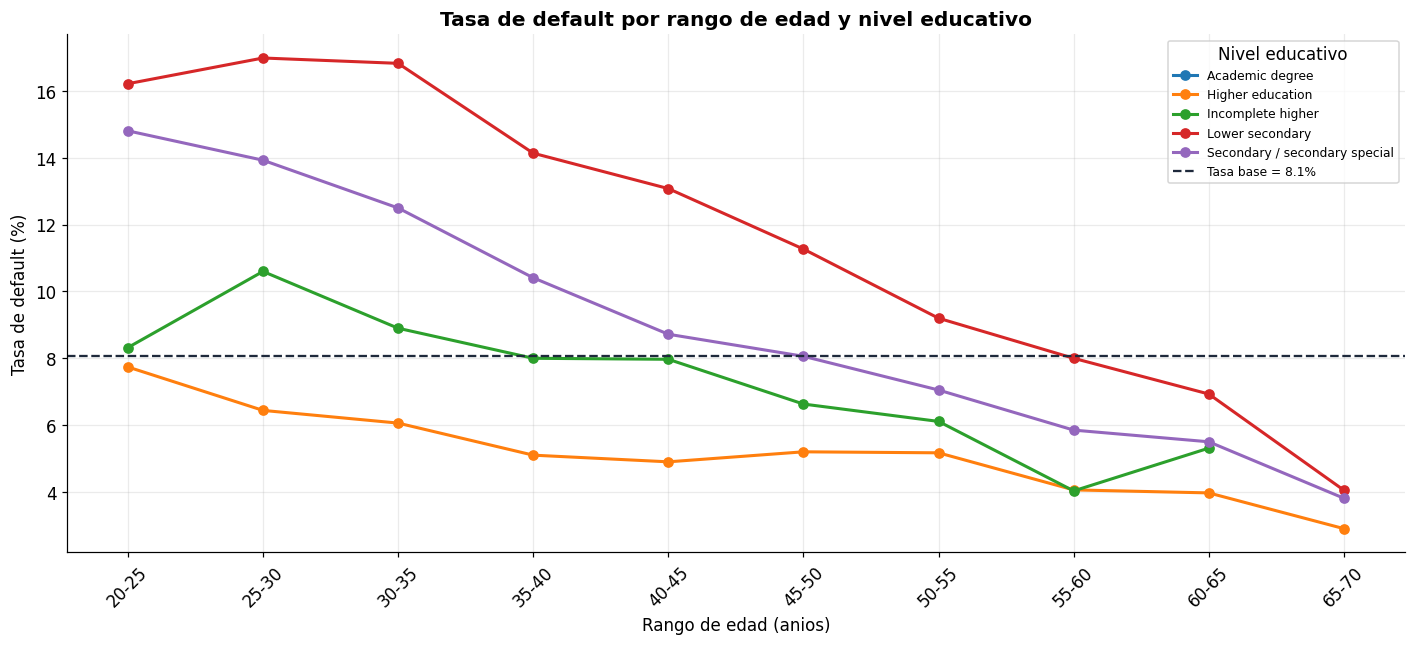

In [47]:
MIN_CLIENTES = 100

sub = df[['AGE_YEARS', 'NAME_EDUCATION_TYPE', 'TARGET']].copy()
sub['AGE_RANGE'] = pd.cut(sub['AGE_YEARS'], bins=bins_edad, right=False,
                          labels=labels_edad, ordered=True)

tabla = (
    sub.groupby(['AGE_RANGE', 'NAME_EDUCATION_TYPE'], observed=False)['TARGET']
    .agg(total='size', defaults='sum')
)
tabla['tasa_default_pct'] = (tabla['defaults'] / tabla['total'] * 100).round(2)
# Oculta tasas con muestra baja (no se elimina nada del dataset).
tabla['tasa_vis'] = tabla['tasa_default_pct'].where(tabla['total'] >= MIN_CLIENTES, np.nan)

matriz = tabla['tasa_vis'].unstack('NAME_EDUCATION_TYPE')

print('Tasa de default (%) por edad y nivel educativo:')
print(matriz.to_string())

tasa_base = (df['TARGET'] == 1).mean() * 100

fig, ax = plt.subplots(figsize=(13, 6))
for nivel in matriz.columns:
    ax.plot(matriz.index.astype(str), matriz[nivel].values,
            marker='o', linewidth=2, label=nivel)

ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por rango de edad y nivel educativo')
ax.set_xlabel('Rango de edad (anios)')
ax.set_ylabel('Tasa de default (%)')
ax.grid(alpha=0.25)
ax.legend(fontsize=8, title='Nivel educativo')
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Clientes con `Academic degree` en default

Calculamos cuantos clientes con nivel educativo `Academic degree` incumplieron (`TARGET = 1`), su total y su tasa de default. Es el nivel con menos clientes, por eso su tasa es poco estable.

In [48]:
academic = df[df['NAME_EDUCATION_TYPE'] == 'Academic degree']

total_academic = len(academic)
default_academic = int((academic['TARGET'] == 1).sum())
no_default_academic = int((academic['TARGET'] == 0).sum())
tasa_academic = default_academic / total_academic * 100 if total_academic else 0

print('Clientes con Academic degree:')
print('-' * 40)
print(f'  Total                : {total_academic:>5,}')
print(f'  En default (TARGET=1): {default_academic:>5,}')
print(f'  Al dia (TARGET=0)    : {no_default_academic:>5,}')
print(f'  Tasa de default      : {tasa_academic:.2f}%')

Clientes con Academic degree:
----------------------------------------
  Total                :   164
  En default (TARGET=1):     3
  Al dia (TARGET=0)    :   161
  Tasa de default      : 1.83%


### Distribucion de edad de los clientes con `Academic degree`

Edad de los clientes con nivel educativo `Academic degree`, con curva normal ajustada y lineas de edad minima, media y maxima. Recordar que son pocos clientes (~164), asi que la distribucion es solo referencial.

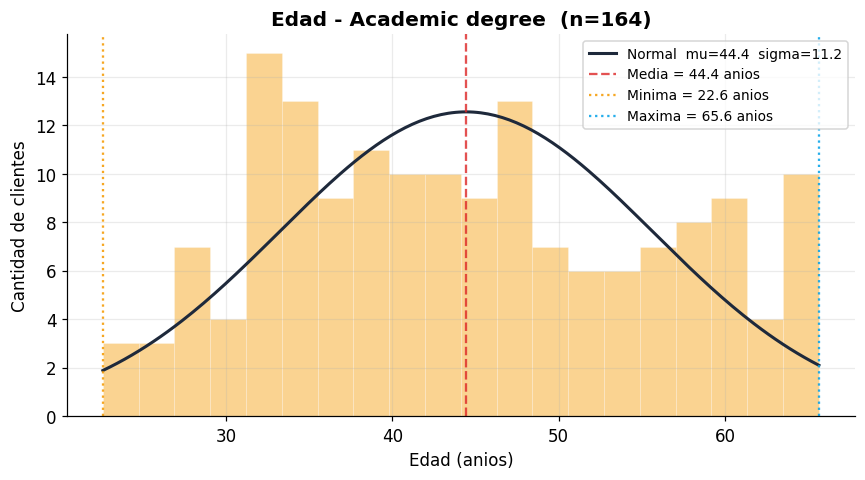

Edad - Academic degree
  Edad minima : 22.6
  Edad media  : 44.4
  Edad maxima : 65.6


In [ ]:
edad_academic = df[df['NAME_EDUCATION_TYPE'] == 'Academic degree']['AGE_YEARS']
plot_age_normal(edad_academic, 'Edad - Academic degree', ACCENT, bins=20)

## Porcentaje de clientes por tipo de ocupacion

Distribucion de clientes segun `OCCUPATION_TYPE`, en porcentaje del total y ordenada de mayor a menor. La categoria `Unknown` corresponde a clientes sin ocupacion registrada.

Porcentaje de clientes por tipo de ocupacion:
  Unknown                 :  31.4%  (96,391)
  Laborers                :  17.9%  (55,186)
  Sales staff             :  10.4%  (32,102)
  Core staff              :   9.0%  (27,570)
  Managers                :   7.0%  (21,371)
  Drivers                 :   6.0%  (18,603)
  High skill tech staff   :   3.7%  (11,380)
  Accountants             :   3.2%  (9,813)
  Medicine staff          :   2.8%  (8,537)
  Security staff          :   2.2%  (6,721)
  Cooking staff           :   1.9%  (5,946)
  Cleaning staff          :   1.5%  (4,653)
  Private service staff   :   0.9%  (2,652)
  Low-skill Laborers      :   0.7%  (2,093)
  Waiters/barmen staff    :   0.4%  (1,348)
  Secretaries             :   0.4%  (1,305)
  Realty agents           :   0.2%  (751)
  HR staff                :   0.2%  (563)
  IT staff                :   0.2%  (526)


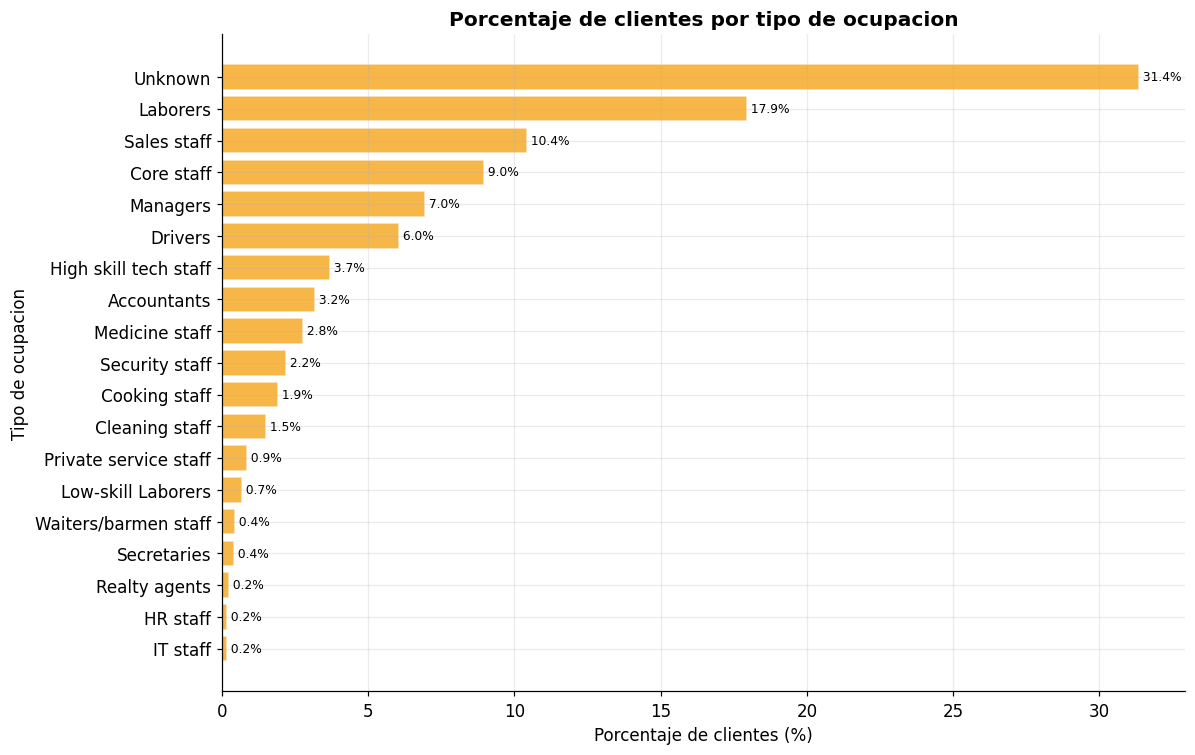

In [51]:
conteo_ocup = df['OCCUPATION_TYPE'].value_counts()
total = int(conteo_ocup.sum())
pct_ocup = (conteo_ocup / total * 100).round(2)

print('Porcentaje de clientes por tipo de ocupacion:')
for ocup, p in pct_ocup.items():
    print(f'  {ocup:<24}: {p:>5.1f}%  ({int(conteo_ocup[ocup]):,})')

# Barras horizontales: muchas categorias, se leen mejor.
fig, ax = plt.subplots(figsize=(11, 7))
orden = pct_ocup.sort_values()
barras = ax.barh(orden.index, orden.values, color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, orden.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f' {v:.1f}%',
            va='center', ha='left', fontsize=8)
ax.set_title('Porcentaje de clientes por tipo de ocupacion')
ax.set_xlabel('Porcentaje de clientes (%)')
ax.set_ylabel('Tipo de ocupacion')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

## Porcentaje de clientes por tipo de ingreso

Distribucion de clientes segun `NAME_INCOME_TYPE` (fuente principal de ingreso), en porcentaje del total y ordenada de mayor a menor.

Porcentaje de clientes por tipo de ingreso:
  Working               :  51.63%  (158,774)
  Commercial associate  :  23.29%  (71,617)
  Pensioner             :  18.00%  (55,362)
  State servant         :   7.06%  (21,703)
  Unemployed            :   0.01%  (22)
  Student               :   0.01%  (18)
  Businessman           :   0.00%  (10)
  Maternity leave       :   0.00%  (5)


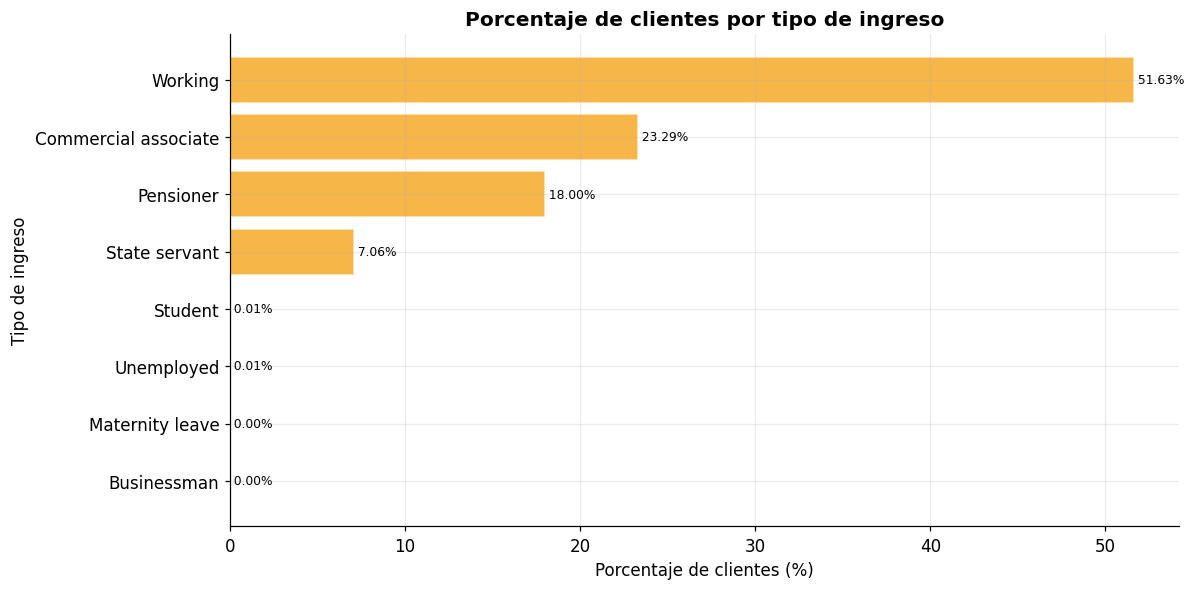

In [52]:
conteo_ingreso = df['NAME_INCOME_TYPE'].value_counts()
total = int(conteo_ingreso.sum())
pct_ingreso = (conteo_ingreso / total * 100).round(2)

print('Porcentaje de clientes por tipo de ingreso:')
for tipo, p in pct_ingreso.items():
    print(f'  {tipo:<22}: {p:>6.2f}%  ({int(conteo_ingreso[tipo]):,})')

fig, ax = plt.subplots(figsize=(11, 5.5))
orden = pct_ingreso.sort_values()
barras = ax.barh(orden.index, orden.values, color=ACCENT, alpha=0.75, edgecolor='white')
for b, v in zip(barras, orden.values):
    ax.text(v, b.get_y() + b.get_height() / 2, f' {v:.2f}%',
            va='center', ha='left', fontsize=8)
ax.set_title('Porcentaje de clientes por tipo de ingreso')
ax.set_xlabel('Porcentaje de clientes (%)')
ax.set_ylabel('Tipo de ingreso')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

## Tasa de default por tipo de ingreso

Comparamos el **riesgo proporcional** segun la fuente de ingreso (`NAME_INCOME_TYPE`). Como los grupos estan muy desbalanceados, usamos la tasa de default y mostramos tambien el total por grupo, ya que categorias como `Student` o `Businessman` tienen muy pocos clientes y su tasa es poco estable.

```text
Tasa de default = clientes con TARGET = 1 del tipo / total del tipo x 100
```

Tasa de default por tipo de ingreso:
    NAME_INCOME_TYPE  total_clientes  clientes_default  tasa_default_pct
     Maternity leave               5                 2             40.00
          Unemployed              22                 8             36.36
             Working          158774             15224              9.59
Commercial associate           71617              5360              7.48
       State servant           21703              1249              5.75
           Pensioner           55362              2982              5.39
         Businessman              10                 0              0.00
             Student              18                 0              0.00

Tasa base (todo el dataset): 8.07%


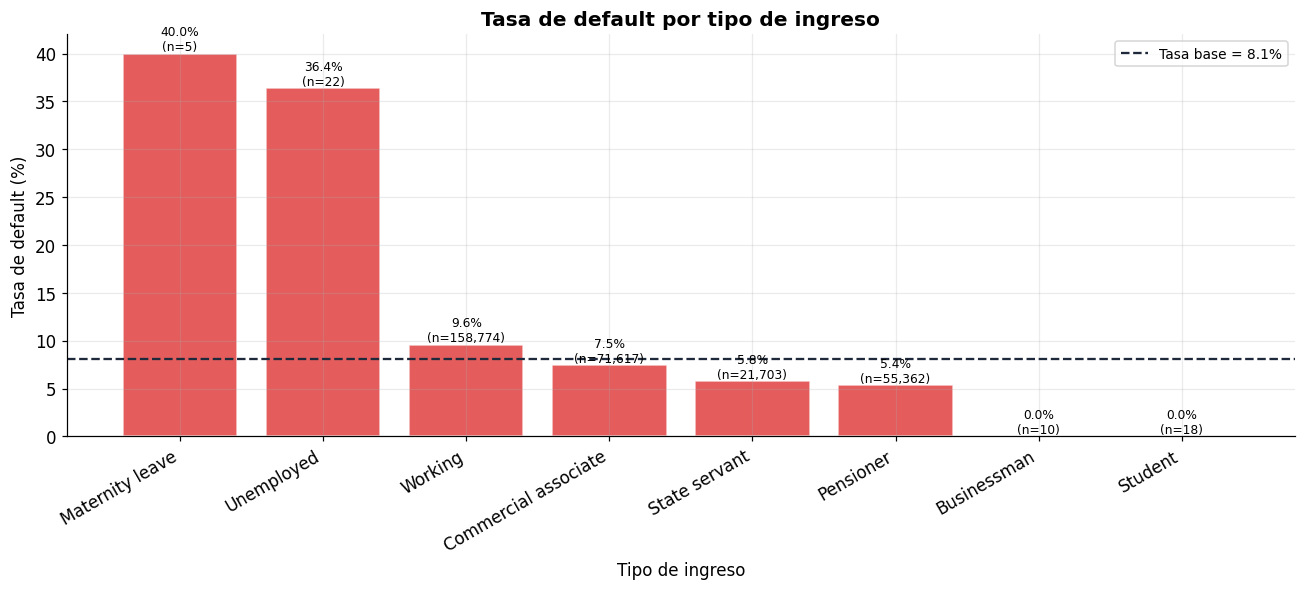

In [ ]:
resumen_ingreso = (
    df.groupby('NAME_INCOME_TYPE')['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
)
resumen_ingreso['tasa_default_pct'] = (
    resumen_ingreso['clientes_default'] / resumen_ingreso['total_clientes'] * 100
).round(2)
resumen_ingreso = resumen_ingreso.sort_values('tasa_default_pct', ascending=False).reset_index()

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default por tipo de ingreso:')
print(resumen_ingreso.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(12, 5.5))
barras = ax.bar(resumen_ingreso['NAME_INCOME_TYPE'], resumen_ingreso['tasa_default_pct'],
                color=RISK, alpha=0.75, edgecolor='white')
for b, v, n in zip(barras, resumen_ingreso['tasa_default_pct'], resumen_ingreso['total_clientes']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%\n(n={int(n):,})',
            ha='center', va='bottom', fontsize=8)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por tipo de ingreso')
ax.set_xlabel('Tipo de ingreso')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right')
fig.tight_layout()
plt.show()

# Crédito, empleo y vivienda

Cuota del crédito, apalancamiento, hijos, antigüedad laboral, organización y propiedad inmobiliaria. `AMT_ANNUITY` define sus propias funciones de distribución.

## Riesgo segun el ratio credito / ingreso (`CREDIT_INCOME_RATIO`)

> Nota: el dataset reducido no contiene `AMT_CREDIT`. En su lugar usamos `CREDIT_INCOME_RATIO` (monto del credito dividido por el ingreso del cliente), que mide el **nivel de apalancamiento**: cuantas veces el credito supera al ingreso. Es un proxy directo del esfuerzo financiero asociado al monto solicitado.

Observar solo la **cantidad absoluta** de clientes en default por rango puede ser enganoso, porque un rango con muchos clientes acumulara muchos defaults aunque su riesgo proporcional sea bajo.

**Ejemplo:**

```text
Rango A: 20.000 clientes, 2.000 en default -> tasa = 10%
Rango B:  5.000 clientes, 1.000 en default -> tasa = 20%
```

El rango A tiene **mas defaults en terminos absolutos**, pero el rango B tiene **mayor proporcion de incumplimiento**, por lo que B presenta mayor **riesgo relativo**.

**Formulas:**

```text
Tasa de default =
  clientes con TARGET = 1 dentro del rango
  ----------------------------------------- x 100
  total de clientes dentro del mismo rango

Participacion dentro del total de defaults =
  clientes con TARGET = 1 dentro del rango
  ----------------------------------------- x 100
  total de clientes con TARGET = 1
```

Cada metrica responde algo distinto:

- **Cantidad absoluta:** donde se concentran mas casos de default.
- **Tasa de default:** que rango es proporcionalmente mas riesgoso.
- **Participacion en el total de defaults:** que rangos generan mayor volumen de incumplimientos.

Resumen por rango de ratio credito/ingreso:
CREDIT_RANGE  total_clientes  clientes_default  tasa_default_pct  participacion_en_defaults_pct
         0-1           14238               933              6.55                           3.76
         1-2           56798              4384              7.72                          17.66
         2-3           66240              5762              8.70                          23.21
         3-4           50380              4461              8.85                          17.97
         4-5           35929              3094              8.61                          12.46
         5-7           46644              3541              7.59                          14.26
        7-10           26253              1923              7.32                           7.75
       10-15            9622               611              6.35                           2.46
         15+            1407               116              8.24                           0

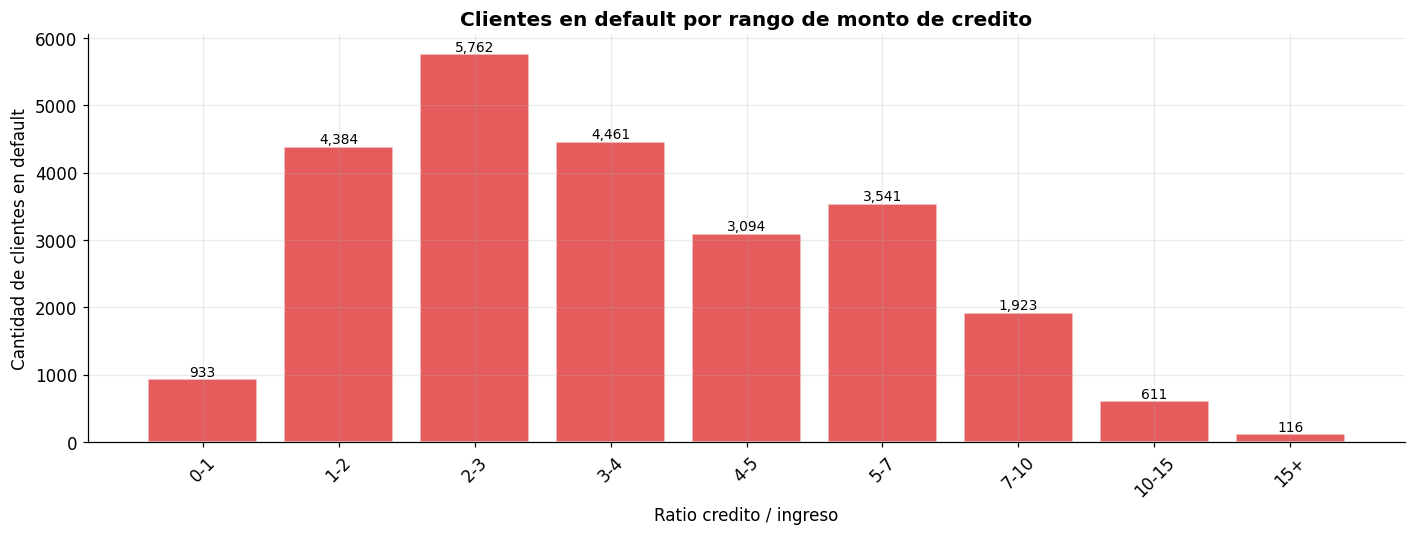

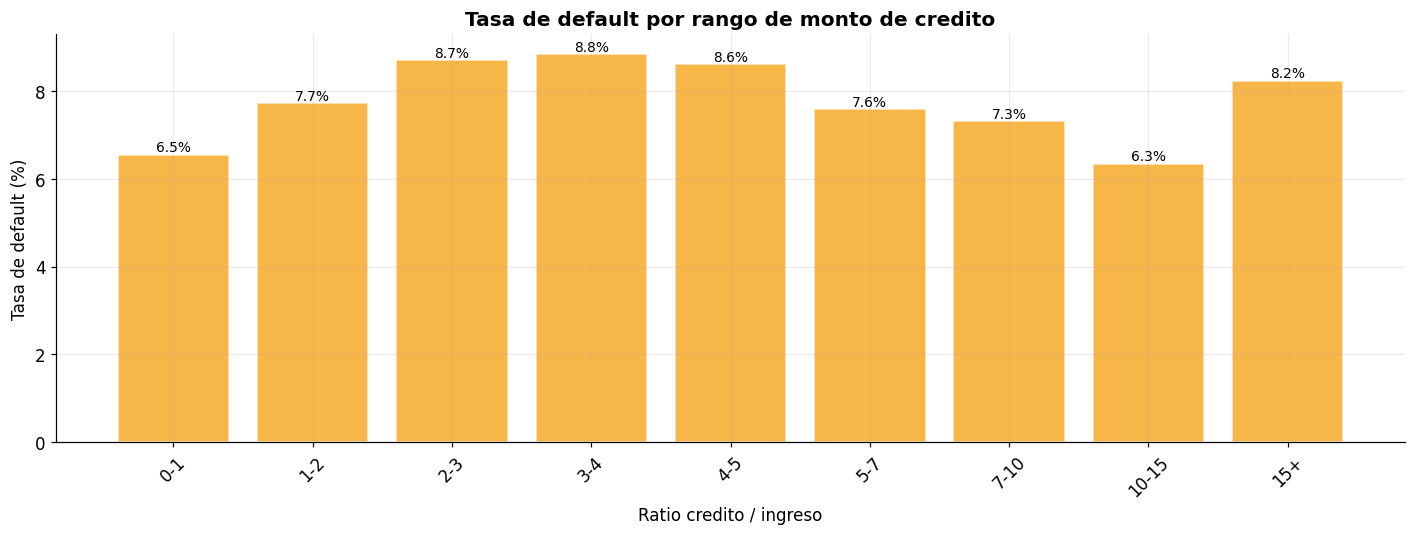

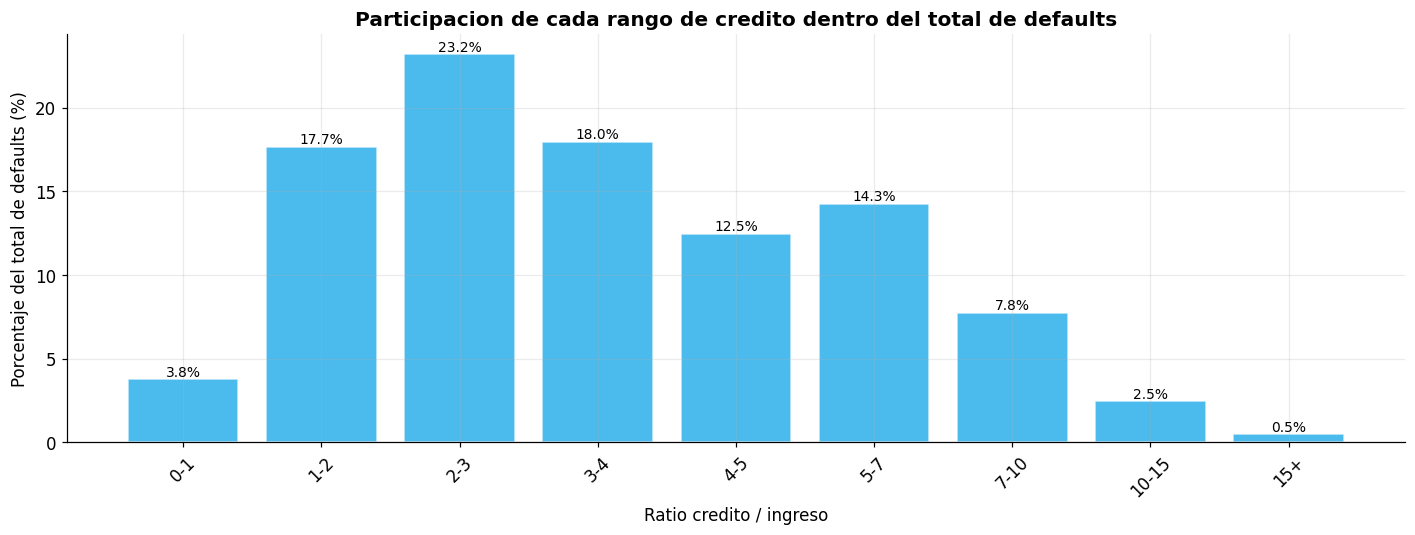


Interpretacion:
  Mayor tasa de default     : 3-4 (8.85%)
  Mayor cantidad de defaults: 2-3 (5,762 casos)
  Mayor participacion       : 2-3 (23.21% del total)


In [30]:
# Trabajamos sobre una copia para no modificar el df original.
monto = df[['CREDIT_INCOME_RATIO', 'TARGET']].copy()

# Rangos del ratio credito/ingreso. El ultimo bucket (15+) captura la cola alta.
bins = [0, 1, 2, 3, 4, 5, 7, 10, 15, np.inf]
etiquetas = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-7', '7-10', '10-15', '15+']

monto['CREDIT_RANGE'] = pd.cut(monto['CREDIT_INCOME_RATIO'], bins=bins,
                               right=False, labels=etiquetas, ordered=True)

total_defaults = int((monto['TARGET'] == 1).sum())

resumen = (
    monto.groupby('CREDIT_RANGE', observed=False)
    .agg(
        total_clientes=('TARGET', 'size'),
        clientes_default=('TARGET', 'sum'),
    )
)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)
resumen['participacion_en_defaults_pct'] = (
    resumen['clientes_default'] / total_defaults * 100
).round(2)
resumen = resumen.reset_index()

print('Resumen por rango de ratio credito/ingreso:')
print(resumen.to_string(index=False))


def barras_etiquetadas(x, y, titulo, ylabel, color, fmt):
    fig, ax = plt.subplots(figsize=(13, 5))
    barras = ax.bar(x, y, color=color, alpha=0.75, edgecolor='white')
    for b, v in zip(barras, y):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt(v),
                ha='center', va='bottom', fontsize=9)
    ax.set_title(titulo)
    ax.set_xlabel('Ratio credito / ingreso')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.25)
    plt.xticks(rotation=45)
    fig.tight_layout()
    plt.show()


# Grafica 1: cantidad absoluta de defaults.
barras_etiquetadas(
    resumen['CREDIT_RANGE'], resumen['clientes_default'],
    'Clientes en default por rango de monto de credito',
    'Cantidad de clientes en default', RISK,
    lambda v: f'{int(v):,}',
)

# Grafica 2: tasa de default.
barras_etiquetadas(
    resumen['CREDIT_RANGE'], resumen['tasa_default_pct'],
    'Tasa de default por rango de monto de credito',
    'Tasa de default (%)', ACCENT,
    lambda v: f'{v:.1f}%',
)

# Grafica 3: participacion dentro del total de defaults.
barras_etiquetadas(
    resumen['CREDIT_RANGE'], resumen['participacion_en_defaults_pct'],
    'Participacion de cada rango de credito dentro del total de defaults',
    'Porcentaje del total de defaults (%)', SAFE,
    lambda v: f'{v:.1f}%',
)

# Interpretacion breve.
r_tasa = resumen.loc[resumen['tasa_default_pct'].idxmax()]
r_cant = resumen.loc[resumen['clientes_default'].idxmax()]
r_part = resumen.loc[resumen['participacion_en_defaults_pct'].idxmax()]

print('\nInterpretacion:')
print(f'  Mayor tasa de default     : {r_tasa["CREDIT_RANGE"]} ({r_tasa["tasa_default_pct"]:.2f}%)')
print(f'  Mayor cantidad de defaults: {r_cant["CREDIT_RANGE"]} ({int(r_cant["clientes_default"]):,} casos)')
print(f'  Mayor participacion       : {r_part["CREDIT_RANGE"]} ({r_part["participacion_en_defaults_pct"]:.2f}% del total)')

## Distribucion de la cuota del credito (`AMT_ANNUITY`)

`AMT_ANNUITY` es el monto de la cuota periodica del credito. Mostramos su distribucion con curva normal ajustada y lineas de minimo, media y maximo:

1. **Todos los clientes.**
2. **Solo clientes en default** (`TARGET = 1`).

Nota: `AMT_ANNUITY` esta sesgada a la derecha (pocas cuotas muy altas), por lo que la curva normal es solo una referencia visual.

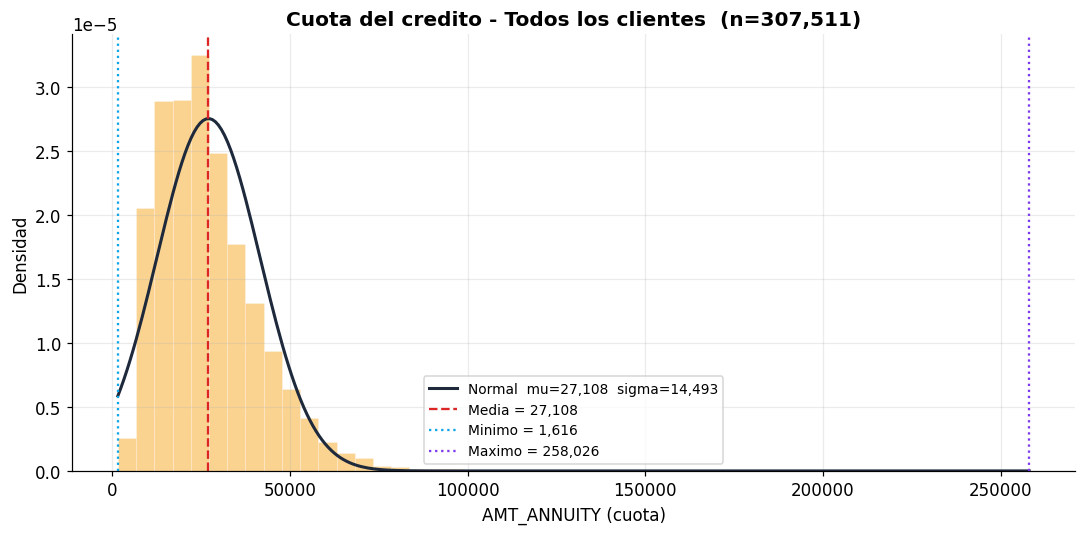

In [ ]:
def plot_dist_normal(serie, titulo, xlabel, color, bins=50):
    """Histograma de densidad con curva normal y lineas min/media/max."""
    datos = serie.dropna()
    media, desv = datos.mean(), datos.std()
    v_min, v_max = datos.min(), datos.max()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(datos, bins=bins, density=True, color=color, alpha=0.45,
            edgecolor='white', linewidth=0.4)

    x = np.linspace(datos.min(), datos.max(), 300)
    ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
            label=f'Normal  mu={media:,.0f}  sigma={desv:,.0f}')
    ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:,.0f}')
    ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Minimo = {v_min:,.0f}')
    ax.axvline(v_max, color='#7c3aed', linestyle=':', linewidth=1.5, label=f'Maximo = {v_max:,.0f}')

    ax.set_title(f'{titulo}  (n={len(datos):,})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


plot_dist_normal(df['AMT_ANNUITY'], 'Cuota del credito - Todos los clientes',
                 'AMT_ANNUITY (cuota)', ACCENT)

### Cuota del credito - Solo clientes en default (`TARGET = 1`)

Distribucion de `AMT_ANNUITY` unicamente para los clientes que incumplieron.

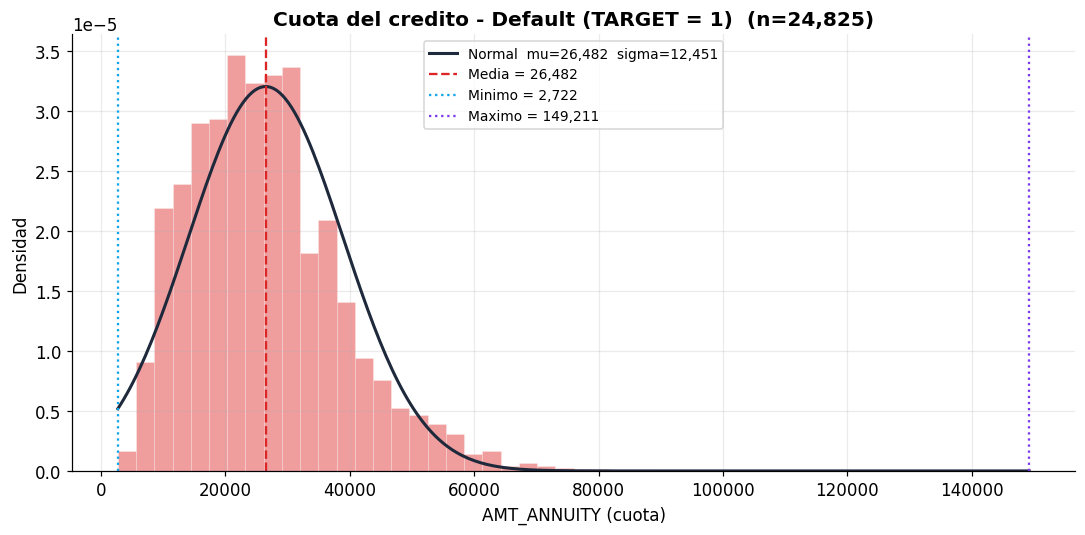

AMT_ANNUITY media - Todos   : 27108.5
AMT_ANNUITY media - Default : 26481.7
AMT_ANNUITY media - Al dia  : 27163.5


In [ ]:
plot_dist_normal(df.loc[df['TARGET'] == 1, 'AMT_ANNUITY'],
                 'Cuota del credito - Default (TARGET = 1)',
                 'AMT_ANNUITY (cuota)', RISK)

print('AMT_ANNUITY media - Todos   :', round(df['AMT_ANNUITY'].mean(), 1))
print('AMT_ANNUITY media - Default :', round(df.loc[df['TARGET'] == 1, 'AMT_ANNUITY'].mean(), 1))
print('AMT_ANNUITY media - Al dia  :', round(df.loc[df['TARGET'] == 0, 'AMT_ANNUITY'].mean(), 1))

### Clientes en default por rango de cuota (de 5.000 en 5.000)

Cantidad de clientes en default (`TARGET = 1`) segun su cuota `AMT_ANNUITY`, agrupada en rangos de 5.000. Las cuotas mayores a 80.000 se juntan en `80k+` por ser muy pocas.

Clientes en default por rango de cuota (AMT_ANNUITY):
     0-5k :     63
    5-10k :  1,587
   10-15k :  2,797
   15-20k :  3,637
   20-25k :  4,153
   25-30k :  4,105
   30-35k :  3,089
   35-40k :  2,162
   40-45k :  1,239
   45-50k :    770
   50-55k :    565
   55-60k :    323
   60-65k :    154
   65-70k :     63
   70-75k :     50
   75-80k :     23
     80k+ :     45
  Total default: 24,825


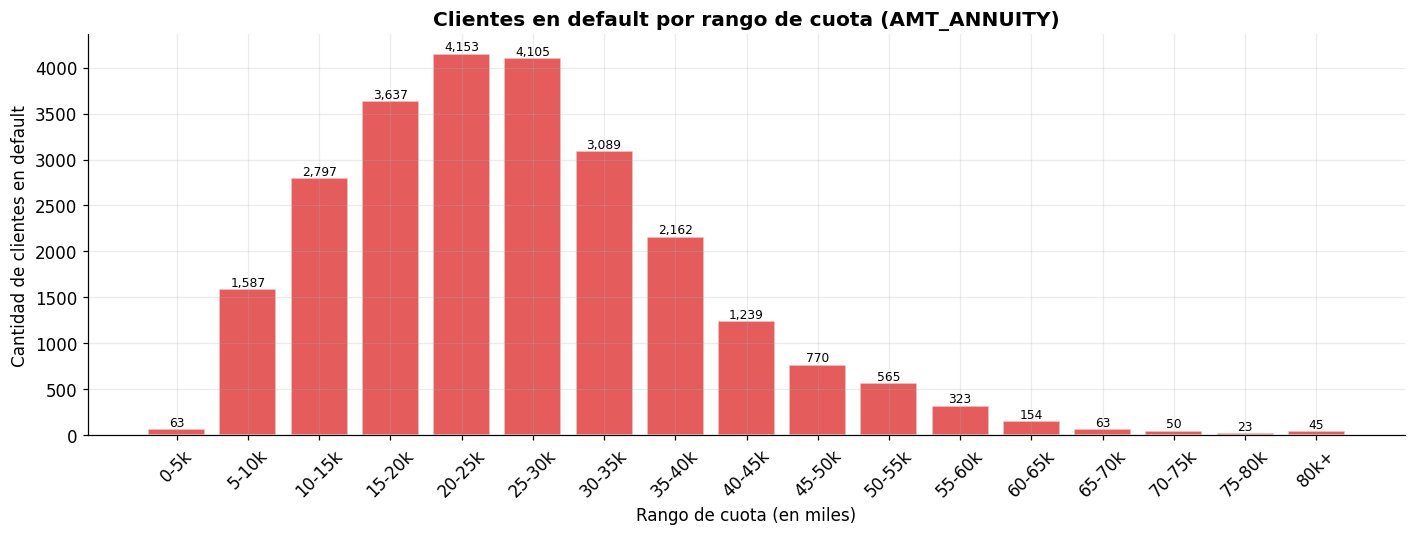

In [65]:
cuota_def = df.loc[df['TARGET'] == 1, 'AMT_ANNUITY'].dropna()

# Rangos de 5.000 hasta 80.000, y un ultimo grupo 80k+.
tope = 80000
bins = list(range(0, tope + 5000, 5000)) + [np.inf]
labels = [f'{i // 1000}-{(i + 5000) // 1000}k' for i in range(0, tope, 5000)] + ['80k+']

conteo = pd.cut(cuota_def, bins=bins, right=False, labels=labels).value_counts().sort_index()

print('Clientes en default por rango de cuota (AMT_ANNUITY):')
for rango, cant in conteo.items():
    print(f'  {rango:>7} : {cant:>6,}')
print(f'  Total default: {len(cuota_def):,}')

fig, ax = plt.subplots(figsize=(13, 5))
barras = ax.bar(conteo.index.astype(str), conteo.values,
                color=RISK, alpha=0.75, edgecolor='white')
for b, v in zip(barras, conteo.values):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,}',
            ha='center', va='bottom', fontsize=8)
ax.set_title('Clientes en default por rango de cuota (AMT_ANNUITY)')
ax.set_xlabel('Rango de cuota (en miles)')
ax.set_ylabel('Cantidad de clientes en default')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Tasa de default por rango de cuota (de 5.000 en 5.000)

Comparamos el **riesgo proporcional** segun la cuota `AMT_ANNUITY`, agrupada en rangos de 5.000. A diferencia del conteo absoluto, la tasa permite ver si cuotas mas altas se asocian a mayor incumplimiento, sin depender del tamano de cada grupo.

Tasa de default por rango de cuota (AMT_ANNUITY):
CUOTA_RANGE  total_clientes  clientes_default  tasa_default_pct
       0-5k            1141                63              5.52
      5-10k           22142              1587              7.17
     10-15k           40397              2797              6.92
     15-20k           42825              3637              8.49
     20-25k           48374              4153              8.59
     25-30k           44104              4105              9.31
     30-35k           33668              3089              9.17
     35-40k           24894              2162              8.68
     40-45k           16197              1239              7.65
     45-50k           12472               770              6.17
     50-55k            8371               565              6.75
     55-60k            4794               323              6.74
     60-65k            2653               154              5.80
     65-70k            2398                63         

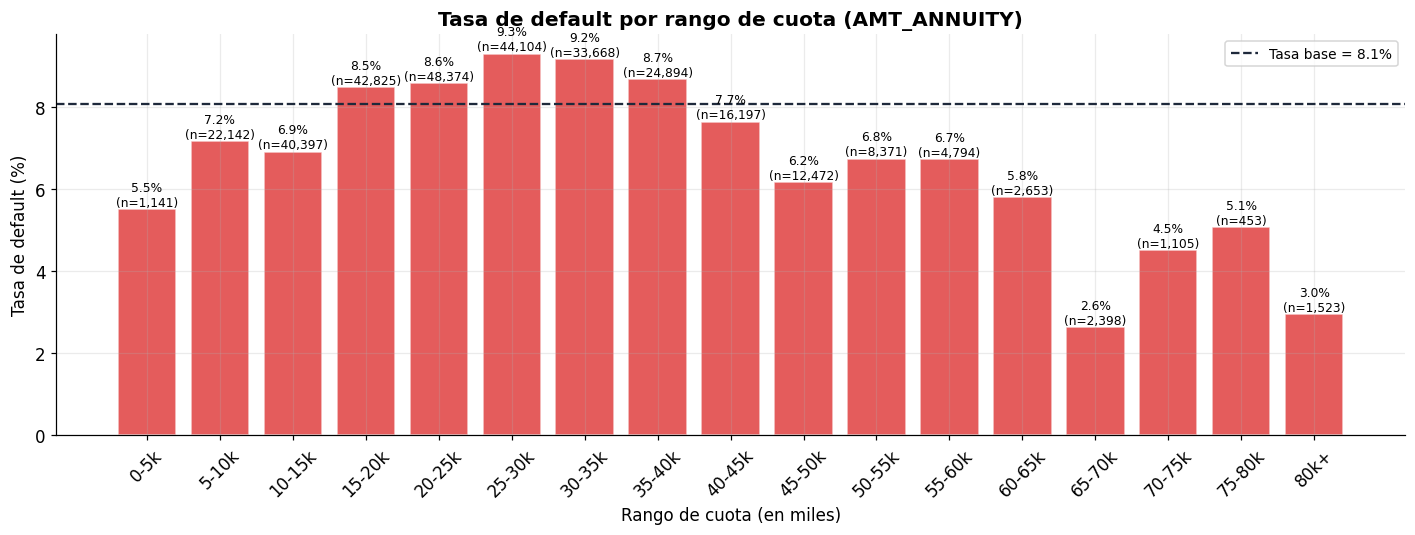

In [66]:
tope = 80000
bins_cuota = list(range(0, tope + 5000, 5000)) + [np.inf]
labels_cuota = [f'{i // 1000}-{(i + 5000) // 1000}k' for i in range(0, tope, 5000)] + ['80k+']

cuota = df[['AMT_ANNUITY', 'TARGET']].copy()
cuota['CUOTA_RANGE'] = pd.cut(cuota['AMT_ANNUITY'], bins=bins_cuota, right=False, labels=labels_cuota)

resumen_cuota = (
    cuota.groupby('CUOTA_RANGE', observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
)
resumen_cuota['tasa_default_pct'] = (
    resumen_cuota['clientes_default'] / resumen_cuota['total_clientes'] * 100
).round(2)
resumen_cuota = resumen_cuota.reset_index()

tasa_base = (df['TARGET'] == 1).mean() * 100

print('Tasa de default por rango de cuota (AMT_ANNUITY):')
print(resumen_cuota.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

fig, ax = plt.subplots(figsize=(13, 5))
barras = ax.bar(resumen_cuota['CUOTA_RANGE'].astype(str), resumen_cuota['tasa_default_pct'],
                color=RISK, alpha=0.75, edgecolor='white')
for b, v, n in zip(barras, resumen_cuota['tasa_default_pct'], resumen_cuota['total_clientes']):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.1f}%\n(n={int(n):,})',
            ha='center', va='bottom', fontsize=8)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por rango de cuota (AMT_ANNUITY)')
ax.set_xlabel('Rango de cuota (en miles)')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Distribucion continua de la cuota (`AMT_ANNUITY`) — sin agrupaciones

A diferencia de los rangos de 5.000, aqui usamos la variable **continua**: histograma de densidad + curva normal ajustada `N(media, sigma)` para comparar la forma de la cuota entre clientes en default y al dia.

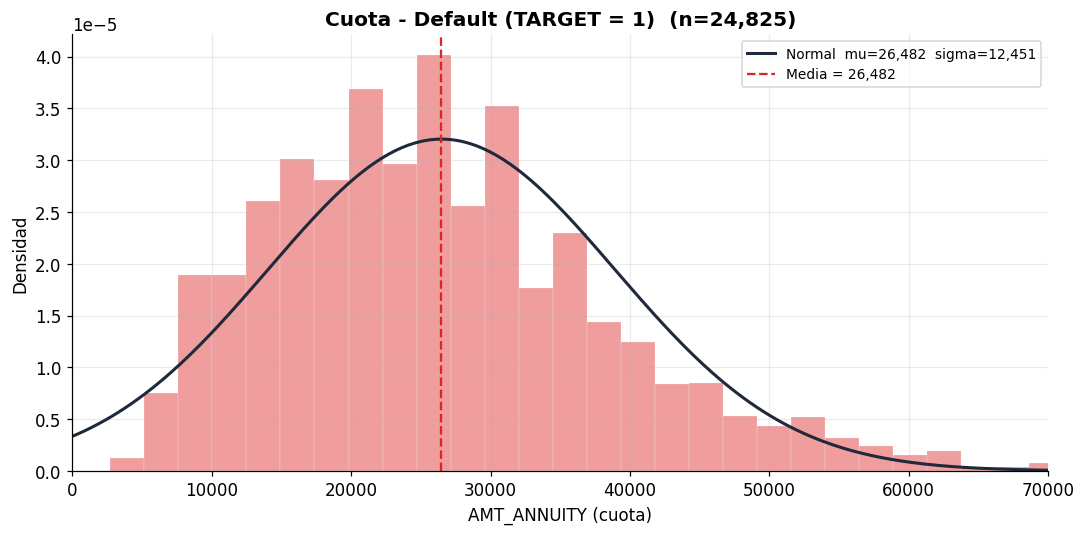

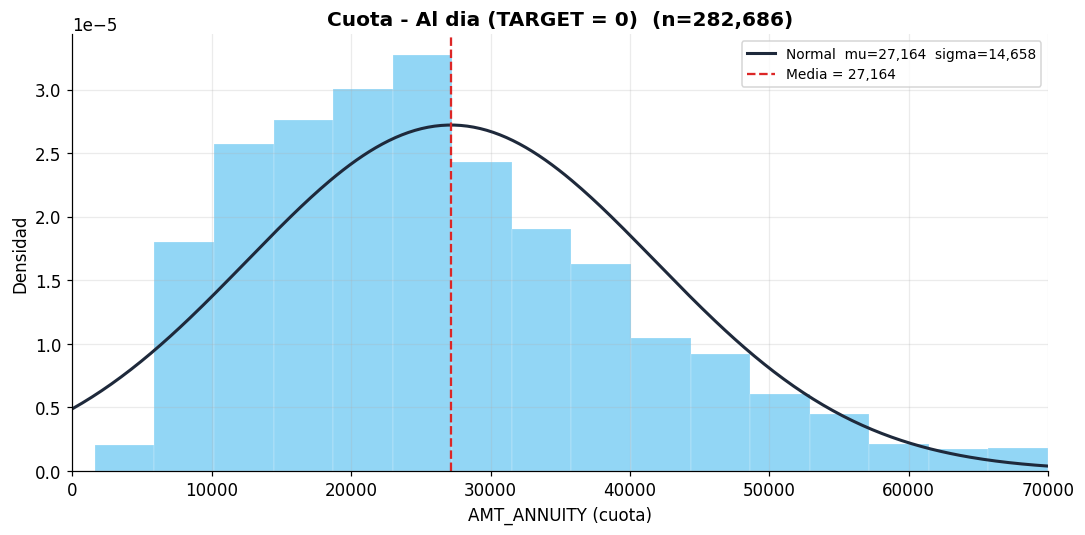

Media AMT_ANNUITY - Default : 26,481.7
Media AMT_ANNUITY - Al dia  : 27,163.5
Diferencia                  : -681.8


In [ ]:
def plot_dist_normal_compare(serie, titulo, color, bins=60, xlim=None):
    datos = serie.dropna()
    media, desv = datos.mean(), datos.std()
    v_min, v_max = datos.min(), datos.max()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(datos, bins=bins, density=True, color=color, alpha=0.45,
            edgecolor='white', linewidth=0.3)

    lo = datos.min() if xlim is None else xlim[0]
    hi = datos.max() if xlim is None else xlim[1]
    x = np.linspace(lo, hi, 300)
    ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
            label=f'Normal  mu={media:,.0f}  sigma={desv:,.0f}')
    ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:,.0f}')

    if xlim:
        ax.set_xlim(xlim)
    ax.set_title(f'{titulo}  (n={len(datos):,})')
    ax.set_xlabel('AMT_ANNUITY (cuota)')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
    return media


# Mismo rango visual para comparar default vs al dia (hasta percentil 99).
xlim = (0, df['AMT_ANNUITY'].quantile(0.99))

media_def = plot_dist_normal_compare(
    df.loc[df['TARGET'] == 1, 'AMT_ANNUITY'],
    'Cuota - Default (TARGET = 1)', RISK, xlim=xlim,
)
media_ok = plot_dist_normal_compare(
    df.loc[df['TARGET'] == 0, 'AMT_ANNUITY'],
    'Cuota - Al dia (TARGET = 0)', SAFE, xlim=xlim,
)

print(f'Media AMT_ANNUITY - Default : {media_def:,.1f}')
print(f'Media AMT_ANNUITY - Al dia  : {media_ok:,.1f}')
print(f'Diferencia                  : {media_def - media_ok:,.1f}')

### Tasa de default continua (bins finos, sin rangos de 5.000)

Para ver como cambia la **tasa de default** a lo largo de la cuota sin agrupar de 5.000 en 5.000, usamos muchos intervalos finos (50) y los unimos con una linea. Sigue siendo un calculo por intervalo, pero la curva se lee como tendencia continua.

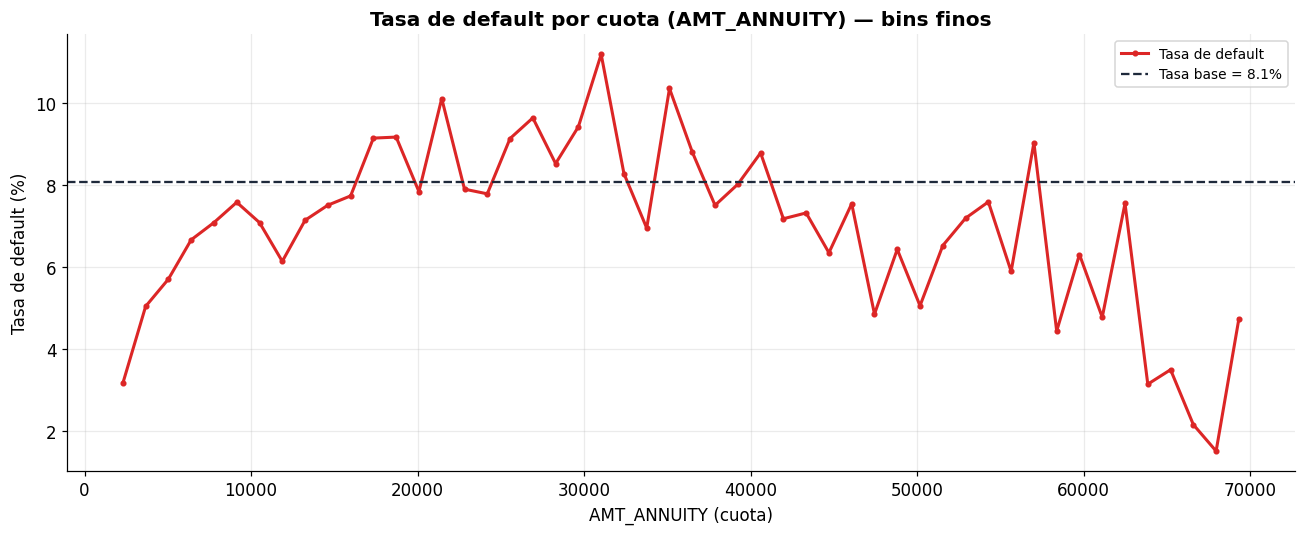

In [ ]:
cuota = df['AMT_ANNUITY'].dropna()
target = df.loc[cuota.index, 'TARGET']

# Percentil 99 para ignorar la cola extrema en la visualizacion.
p99 = cuota.quantile(0.99)
mask = cuota <= p99
cuota_vis = cuota[mask]
target_vis = target[mask]

n_bins = 50
counts, edges = np.histogram(cuota_vis, bins=n_bins)
defaults, _ = np.histogram(cuota_vis[target_vis == 1], bins=edges)

with np.errstate(divide='ignore', invalid='ignore'):
    tasa = np.where(counts > 0, defaults / counts * 100, np.nan)

centros = (edges[:-1] + edges[1:]) / 2
tasa_base = (df['TARGET'] == 1).mean() * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(centros, tasa, color=RISK, linewidth=2, marker='o', markersize=3, label='Tasa de default')
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por cuota (AMT_ANNUITY) — bins finos')
ax.set_xlabel('AMT_ANNUITY (cuota)')
ax.set_ylabel('Tasa de default (%)')
ax.grid(alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Cantidad de hijos (`CNT_CHILDREN`)

Analizamos el número de hijos declarado por el cliente:

1. **Distribución** con curva normal de referencia (variable entera: un bin por cada valor).
2. **Tasa de default** por cantidad de hijos.
3. **Cantidad total de clientes** al día (`TARGET = 0`) vs en default (`TARGET = 1`) por cantidad de hijos.

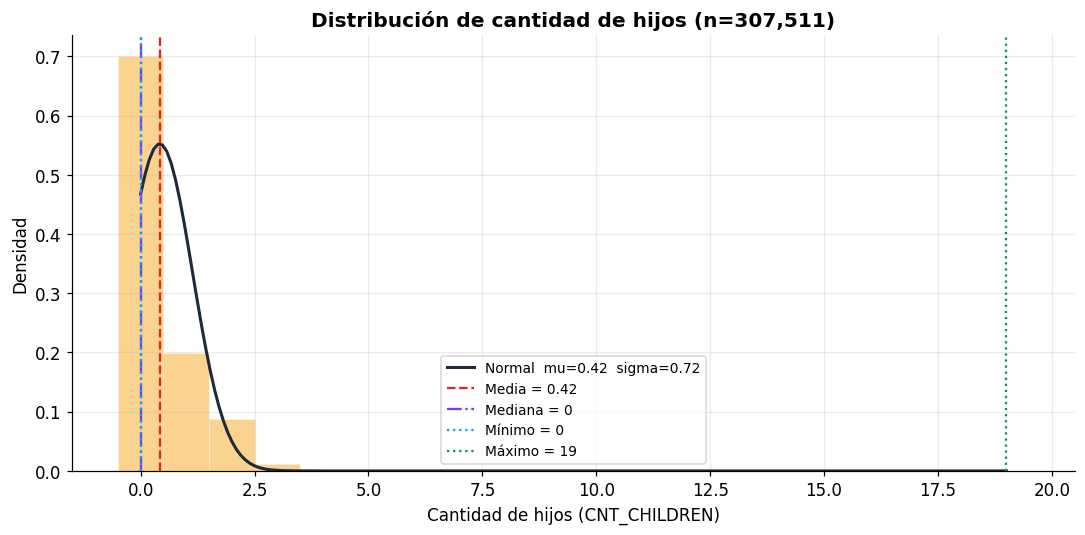

CNT_CHILDREN:
  Mínimo  : 0
  Media   : 0.42
  Mediana : 0
  Máximo  : 19
  % con 0 hijos: 70.0%

Resumen por cantidad de hijos:
GRUPO_HIJOS  total_clientes  clientes_default  clientes_al_dia  tasa_default_pct
          0          215371             16609           198762              7.71
          1           61119              5454            55665              8.92
          2           26749              2333            24416              8.72
          3            3717               358             3359              9.63
          4             429                55              374             12.82
         5+             126                16              110             12.70

Tasa base (todo el dataset): 8.07%


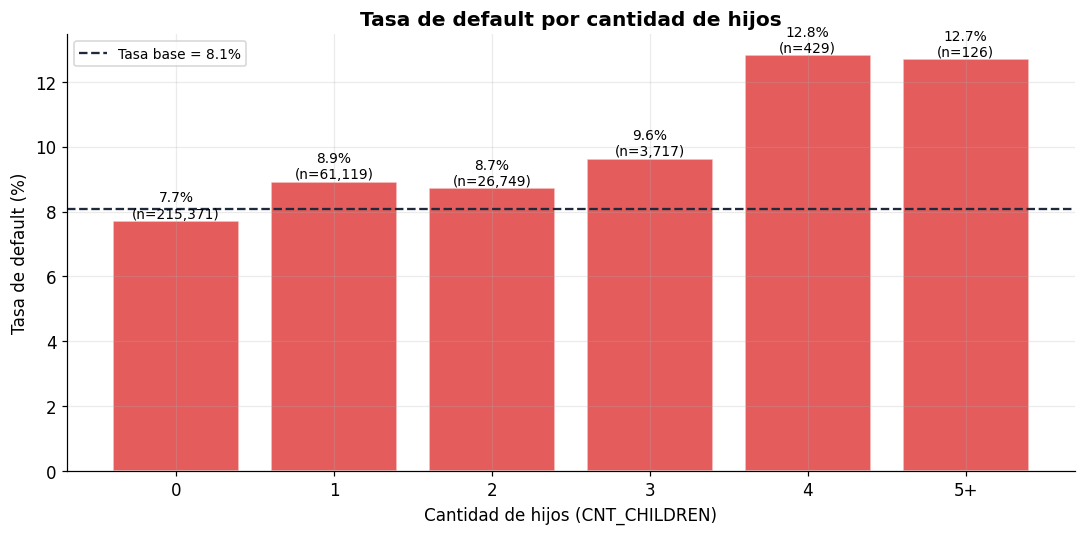

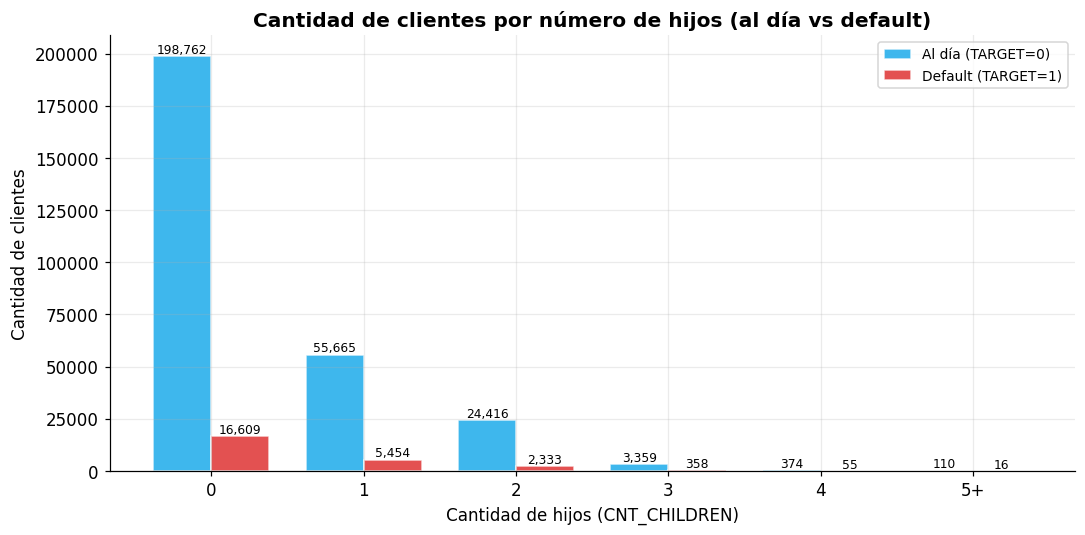

In [86]:
col = 'CNT_CHILDREN'
datos = df[col].dropna().astype(int)


def grupo_hijos(n):
    n = int(n)
    return str(n) if n < 5 else '5+'


orden_hijos = [str(i) for i in range(5)] + ['5+']

# --- 1) Distribución normal ---
media, desv = datos.mean(), datos.std()
v_min, v_max = int(datos.min()), int(datos.max())

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.arange(v_min, v_max + 2) - 0.5
ax.hist(datos, bins=bins, density=True, color=ACCENT, alpha=0.45,
        edgecolor='white', linewidth=0.4)

x = np.linspace(v_min, v_max, 200)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.2f}  sigma={desv:.2f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.2f}')
ax.axvline(datos.median(), color='#7c3aed', linestyle='-.', linewidth=1.5,
           label=f'Mediana = {datos.median():.0f}')
ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Mínimo = {v_min}')
ax.axvline(v_max, color='#059669', linestyle=':', linewidth=1.5, label=f'Máximo = {v_max}')

ax.set_title(f'Distribución de cantidad de hijos (n={len(datos):,})')
ax.set_xlabel('Cantidad de hijos (CNT_CHILDREN)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f'{col}:')
print(f'  Mínimo  : {v_min}')
print(f'  Media   : {media:.2f}')
print(f'  Mediana : {datos.median():.0f}')
print(f'  Máximo  : {v_max}')
print(f'  % con 0 hijos: {(datos == 0).mean() * 100:.1f}%')

# --- Tabla resumen por grupo ---
ch = df[[col, 'TARGET']].dropna().copy()
ch[col] = ch[col].astype(int)
ch['GRUPO_HIJOS'] = ch[col].map(grupo_hijos)

resumen = (
    ch.groupby('GRUPO_HIJOS', observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reindex(orden_hijos)
    .reset_index()
)
resumen['clientes_al_dia'] = (
    resumen['total_clientes'] - resumen['clientes_default']
).astype(int)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)

tasa_base = df['TARGET'].mean() * 100

print('\nResumen por cantidad de hijos:')
print(resumen.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

# --- 2) Tasa de default ---
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.bar(
    resumen['GRUPO_HIJOS'].astype(str),
    resumen['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, row in zip(barras, resumen.itertuples()):
    ax.text(b.get_x() + b.get_width() / 2, row.tasa_default_pct,
            f'{row.tasa_default_pct:.1f}%\n(n={row.total_clientes:,})',
            ha='center', va='bottom', fontsize=9)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por cantidad de hijos')
ax.set_xlabel('Cantidad de hijos (CNT_CHILDREN)')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# --- 3) Cantidad total: al día vs default (barras agrupadas) ---
x = np.arange(len(orden_hijos))
ancho = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
b0 = ax.bar(x - ancho / 2, resumen['clientes_al_dia'], width=ancho,
            color=SAFE, alpha=0.8, edgecolor='white', label='Al día (TARGET=0)')
b1 = ax.bar(x + ancho / 2, resumen['clientes_default'], width=ancho,
            color=RISK, alpha=0.8, edgecolor='white', label='Default (TARGET=1)')

for barras in (b0, b1):
    for b in barras:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width() / 2, h, f'{int(h):,}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(orden_hijos)
ax.set_title('Cantidad de clientes por número de hijos (al día vs default)')
ax.set_xlabel('Cantidad de hijos (CNT_CHILDREN)')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Años empleados (`YEARS_EMPLOYED`)

Analizamos los años de antigüedad laboral declarados por el cliente:

1. **Distribución** con curva normal de referencia.
2. **Tasa de default** por rango de años empleados.
3. **Cantidad total de clientes** al día (`TARGET = 0`) vs en default (`TARGET = 1`) por rango.

Rangos usados: `< 1 año`, `1-3 años`, `3-5 años`, `5-10 años`, `10-20 años`, `20+ años`.

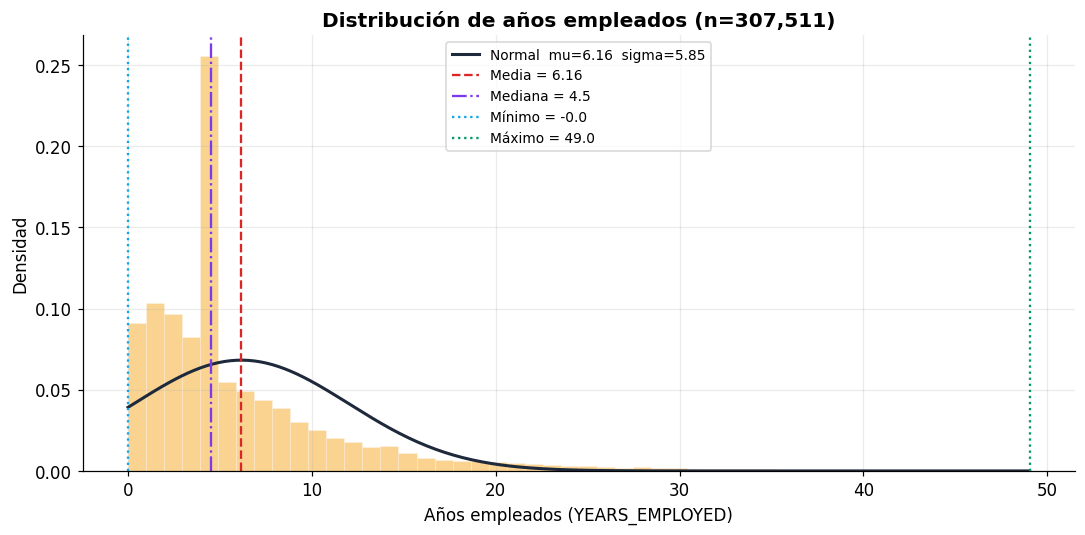

YEARS_EMPLOYED:
  Mínimo  : -0.00
  Media   : 6.16
  Mediana : 4.51
  Máximo  : 49.04
  % con < 1 año: 9.1%

Resumen por años empleados:
GRUPO_EMPLEO  total_clientes  clientes_default  clientes_al_dia  tasa_default_pct
     < 1 año           27982              3070            24912             10.97
    1-3 años           61472              6807            54665             11.07
    3-5 años          102276              7526            94750              7.36
   5-10 años           64871              4782            60089              7.37
  10-20 años           38381              2116            36265              5.51
    20+ años           12529               524            12005              4.18

Tasa base (todo el dataset): 8.07%


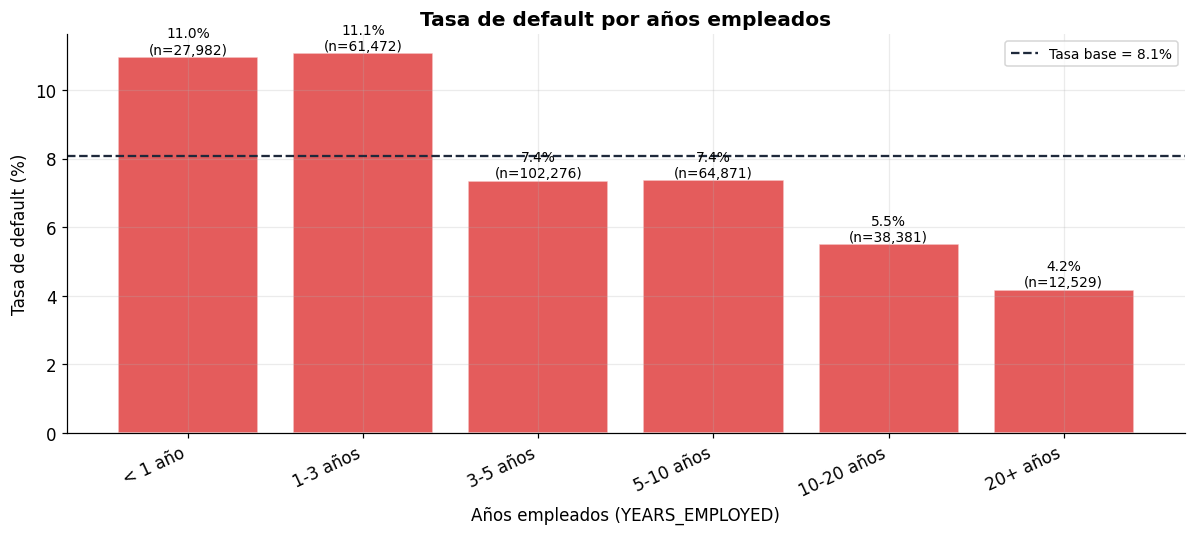

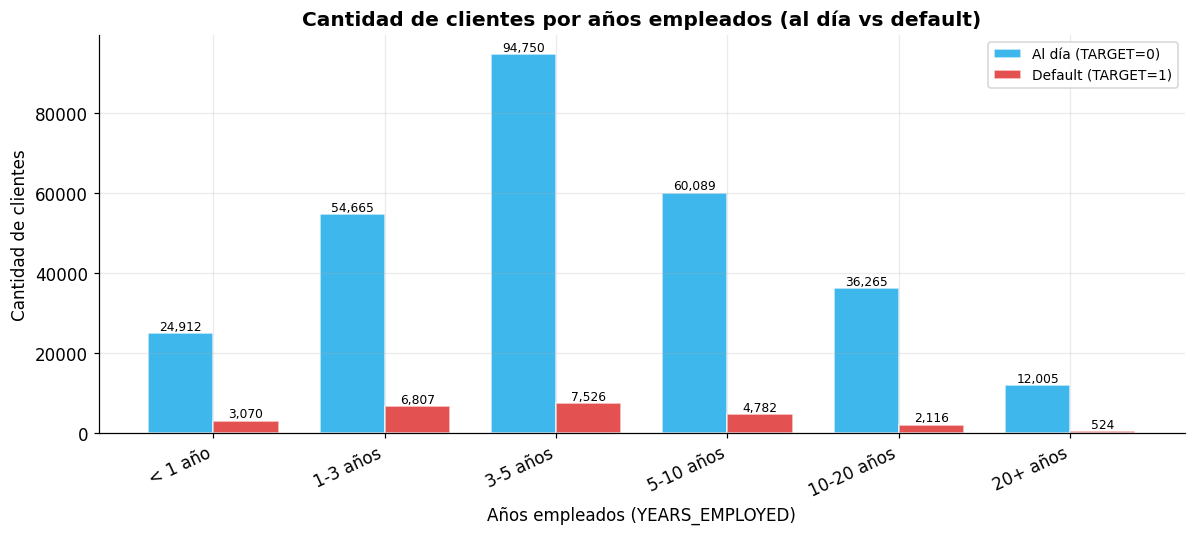

In [87]:
# --- YEARS_EMPLOYED: distribución, tasa de default y cantidad al día vs default ---
col = 'YEARS_EMPLOYED'
datos = df[col].dropna()

bins_grupo = [-0.001, 1, 3, 5, 10, 20, np.inf]
labels_grupo = ['< 1 año', '1-3 años', '3-5 años', '5-10 años', '10-20 años', '20+ años']

# --- 1) Distribución normal ---
media, desv = datos.mean(), datos.std()
v_min, v_max = datos.min(), datos.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(datos, bins=50, density=True, color=ACCENT, alpha=0.45,
        edgecolor='white', linewidth=0.4)

x = np.linspace(datos.min(), datos.max(), 300)
ax.plot(x, stats.norm.pdf(x, media, desv), color=INK, linewidth=2,
        label=f'Normal  mu={media:.2f}  sigma={desv:.2f}')
ax.axvline(media, color=RISK, linestyle='--', linewidth=1.5, label=f'Media = {media:.2f}')
ax.axvline(datos.median(), color='#7c3aed', linestyle='-.', linewidth=1.5,
           label=f'Mediana = {datos.median():.1f}')
ax.axvline(v_min, color=SAFE, linestyle=':', linewidth=1.5, label=f'Mínimo = {v_min:.1f}')
ax.axvline(v_max, color='#059669', linestyle=':', linewidth=1.5, label=f'Máximo = {v_max:.1f}')

ax.set_title(f'Distribución de años empleados (n={len(datos):,})')
ax.set_xlabel('Años empleados (YEARS_EMPLOYED)')
ax.set_ylabel('Densidad')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

print(f'{col}:')
print(f'  Mínimo  : {v_min:.2f}')
print(f'  Media   : {media:.2f}')
print(f'  Mediana : {datos.median():.2f}')
print(f'  Máximo  : {v_max:.2f}')
print(f'  % con < 1 año: {(datos < 1).mean() * 100:.1f}%')

# --- Tabla resumen por grupo ---
ch = df[[col, 'TARGET']].dropna().copy()
ch['GRUPO_EMPLEO'] = pd.cut(
    ch[col], bins=bins_grupo, labels=labels_grupo, right=True, ordered=True
)

resumen = (
    ch.groupby('GRUPO_EMPLEO', observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reindex(labels_grupo)
    .reset_index()
)
resumen['clientes_al_dia'] = (
    resumen['total_clientes'] - resumen['clientes_default']
).astype(int)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)

tasa_base = df['TARGET'].mean() * 100

print('\nResumen por años empleados:')
print(resumen.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')

# --- 2) Tasa de default ---
fig, ax = plt.subplots(figsize=(11, 5))
barras = ax.bar(
    resumen['GRUPO_EMPLEO'].astype(str),
    resumen['tasa_default_pct'],
    color=RISK, alpha=0.75, edgecolor='white',
)
for b, row in zip(barras, resumen.itertuples()):
    ax.text(b.get_x() + b.get_width() / 2, row.tasa_default_pct,
            f'{row.tasa_default_pct:.1f}%\n(n={row.total_clientes:,})',
            ha='center', va='bottom', fontsize=9)
ax.axhline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_title('Tasa de default por años empleados')
ax.set_xlabel('Años empleados (YEARS_EMPLOYED)')
ax.set_ylabel('Tasa de default (%)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
plt.xticks(rotation=25, ha='right')
fig.tight_layout()
plt.show()

# --- 3) Cantidad total: al día vs default (barras agrupadas) ---
x = np.arange(len(labels_grupo))
ancho = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
b0 = ax.bar(x - ancho / 2, resumen['clientes_al_dia'], width=ancho,
            color=SAFE, alpha=0.8, edgecolor='white', label='Al día (TARGET=0)')
b1 = ax.bar(x + ancho / 2, resumen['clientes_default'], width=ancho,
            color=RISK, alpha=0.8, edgecolor='white', label='Default (TARGET=1)')

for barras in (b0, b1):
    for b in barras:
        h = b.get_height()
        if h > 0:
            ax.text(b.get_x() + b.get_width() / 2, h, f'{int(h):,}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_grupo, rotation=25, ha='right')
ax.set_title('Cantidad de clientes por años empleados (al día vs default)')
ax.set_xlabel('Años empleados (YEARS_EMPLOYED)')
ax.set_ylabel('Cantidad de clientes')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Tipo de organización (`ORGANIZATION_TYPE`)

Analizamos el empleador u organización declarada por el cliente:

1. **Cantidad de clientes** en cada categoría de organización.
2. **Comparativa al día vs default** (`TARGET = 0` vs `TARGET = 1`) por categoría.
3. **Tasa de default** por categoría.

Los valores nulos se agrupan como `Sin información`. Las categorías se ordenan de mayor a menor número de clientes.

Resumen por tipo de organización:
     ORGANIZATION_TYPE  total_clientes  clientes_default  clientes_al_dia  tasa_default_pct
Business Entity Type 3           67992              6323            61669              9.30
                   XNA           55374              2990            52384              5.40
         Self-employed           38412              3908            34504             10.17
                 Other           16683              1275            15408              7.64
              Medicine           11193               737            10456              6.58
Business Entity Type 2           10553               900             9653              8.53
            Government           10404               726             9678              6.98
                School            8893               526             8367              5.91
         Trade: type 7            7831               740             7091              9.45
          Kindergarten            6880        

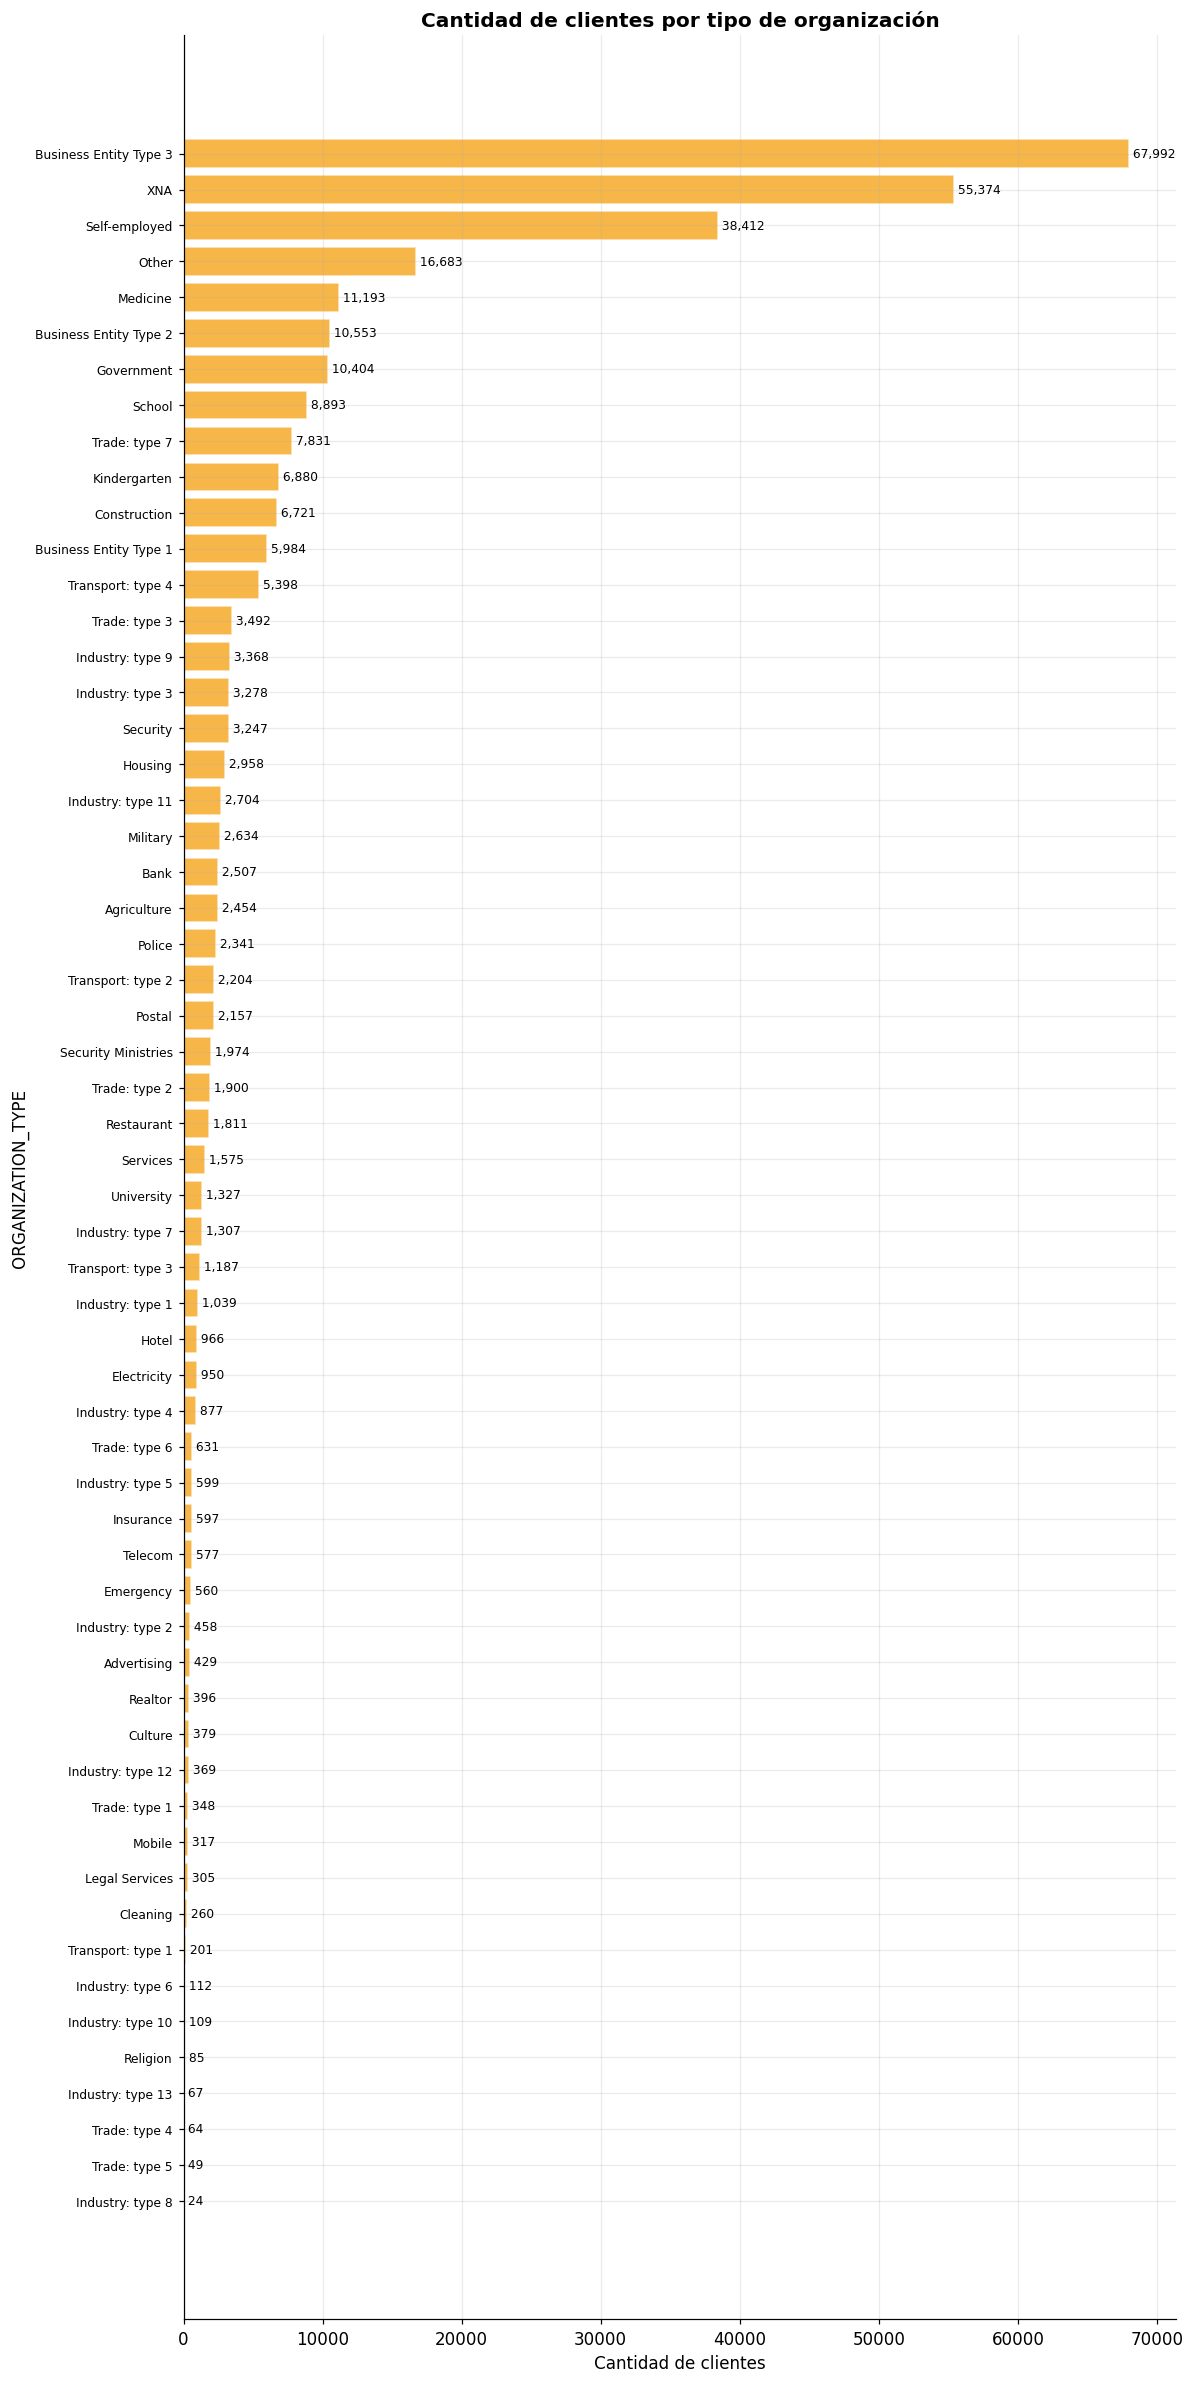

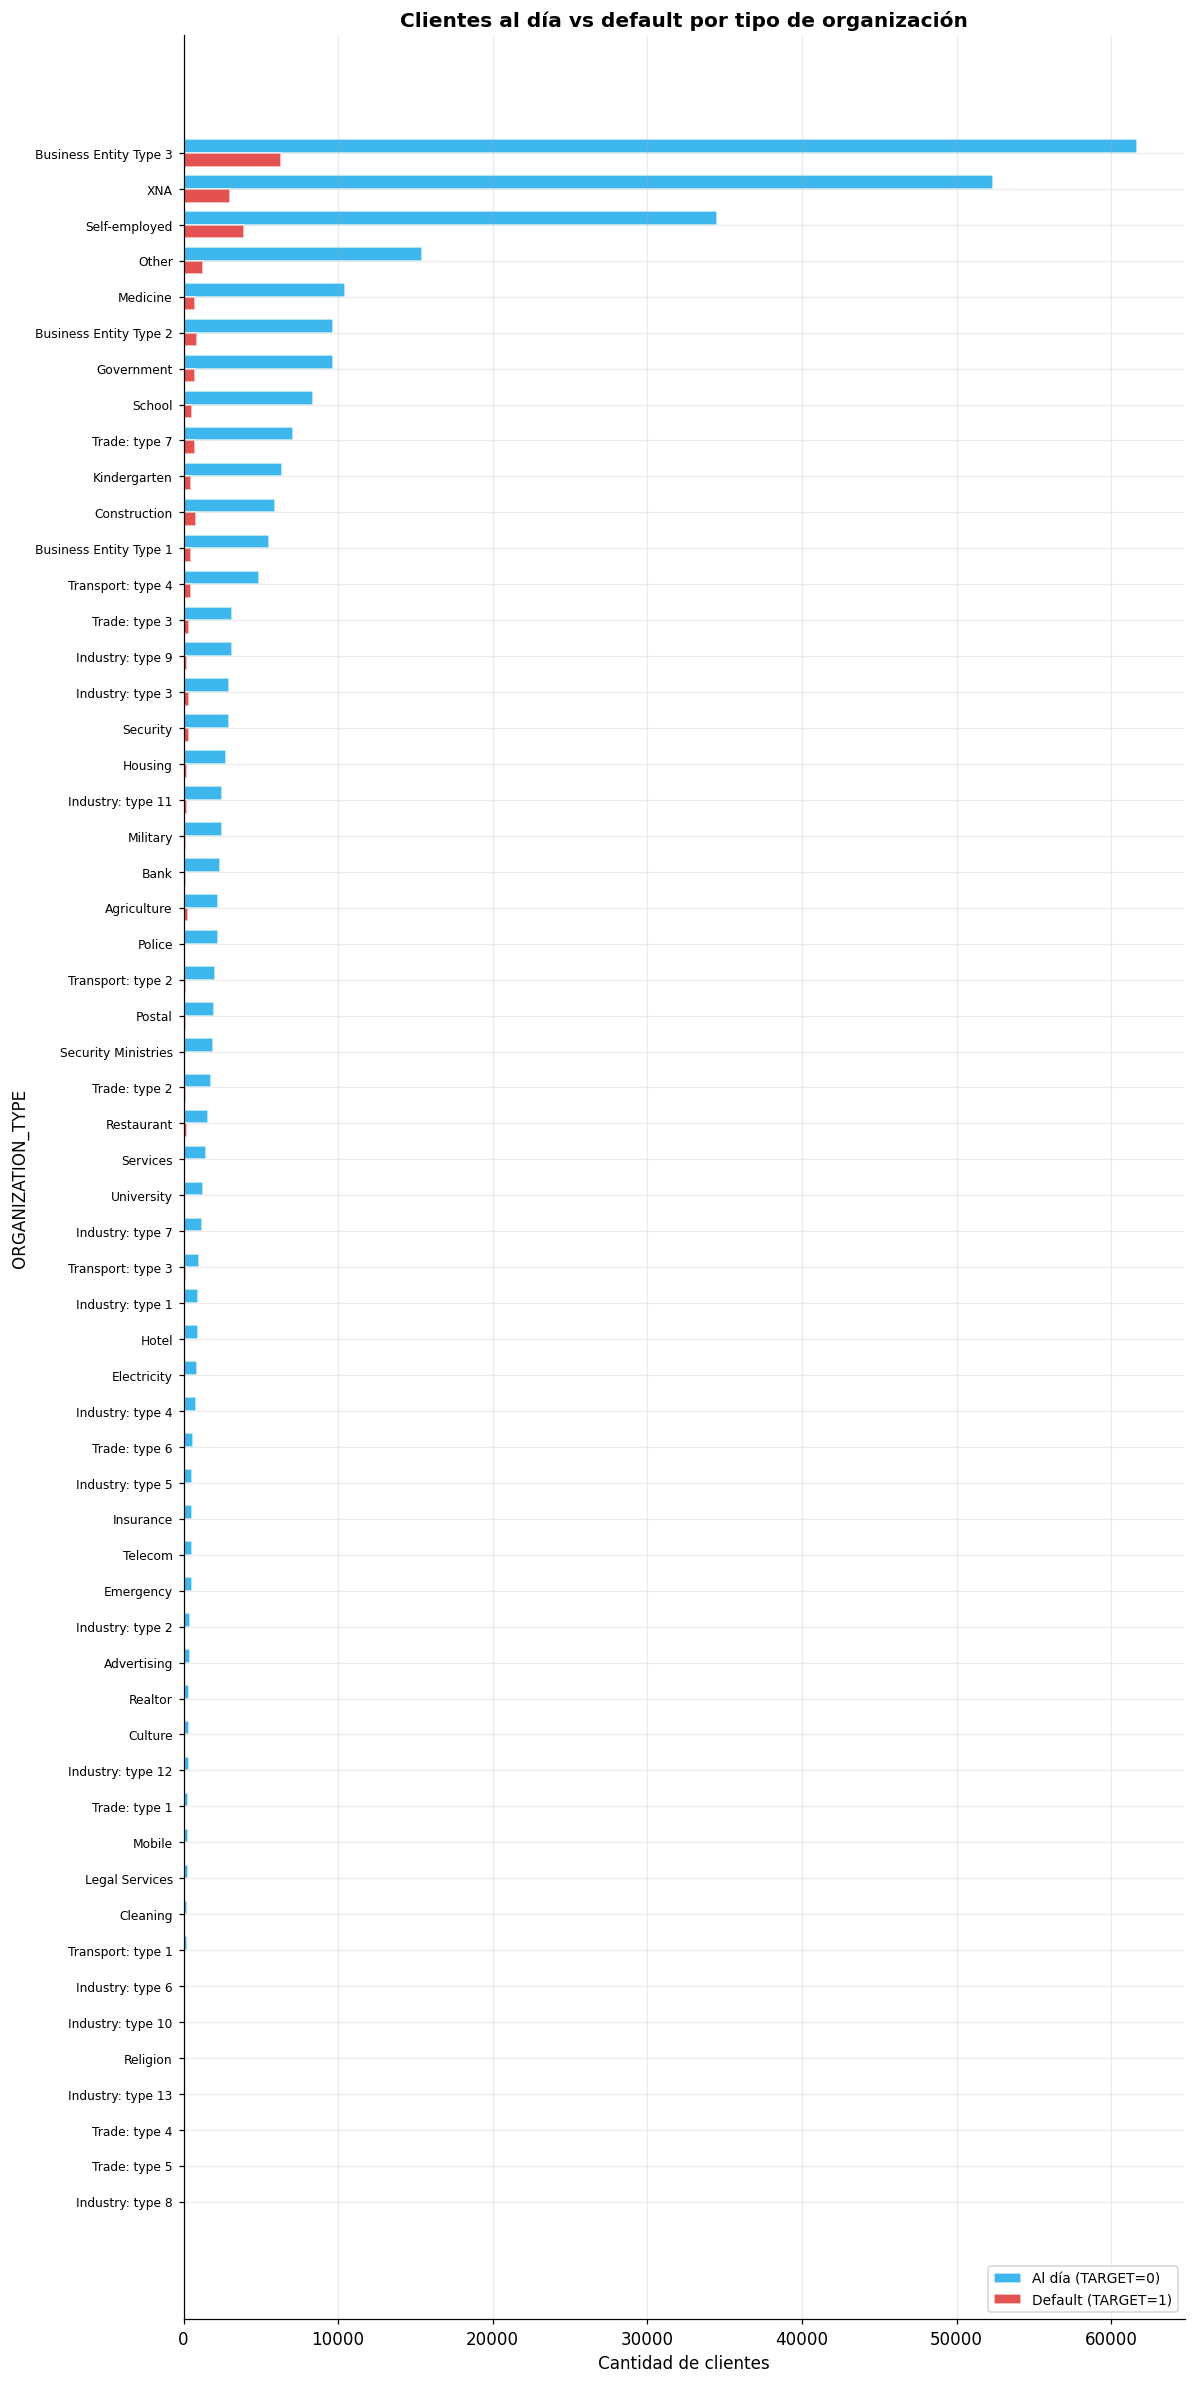

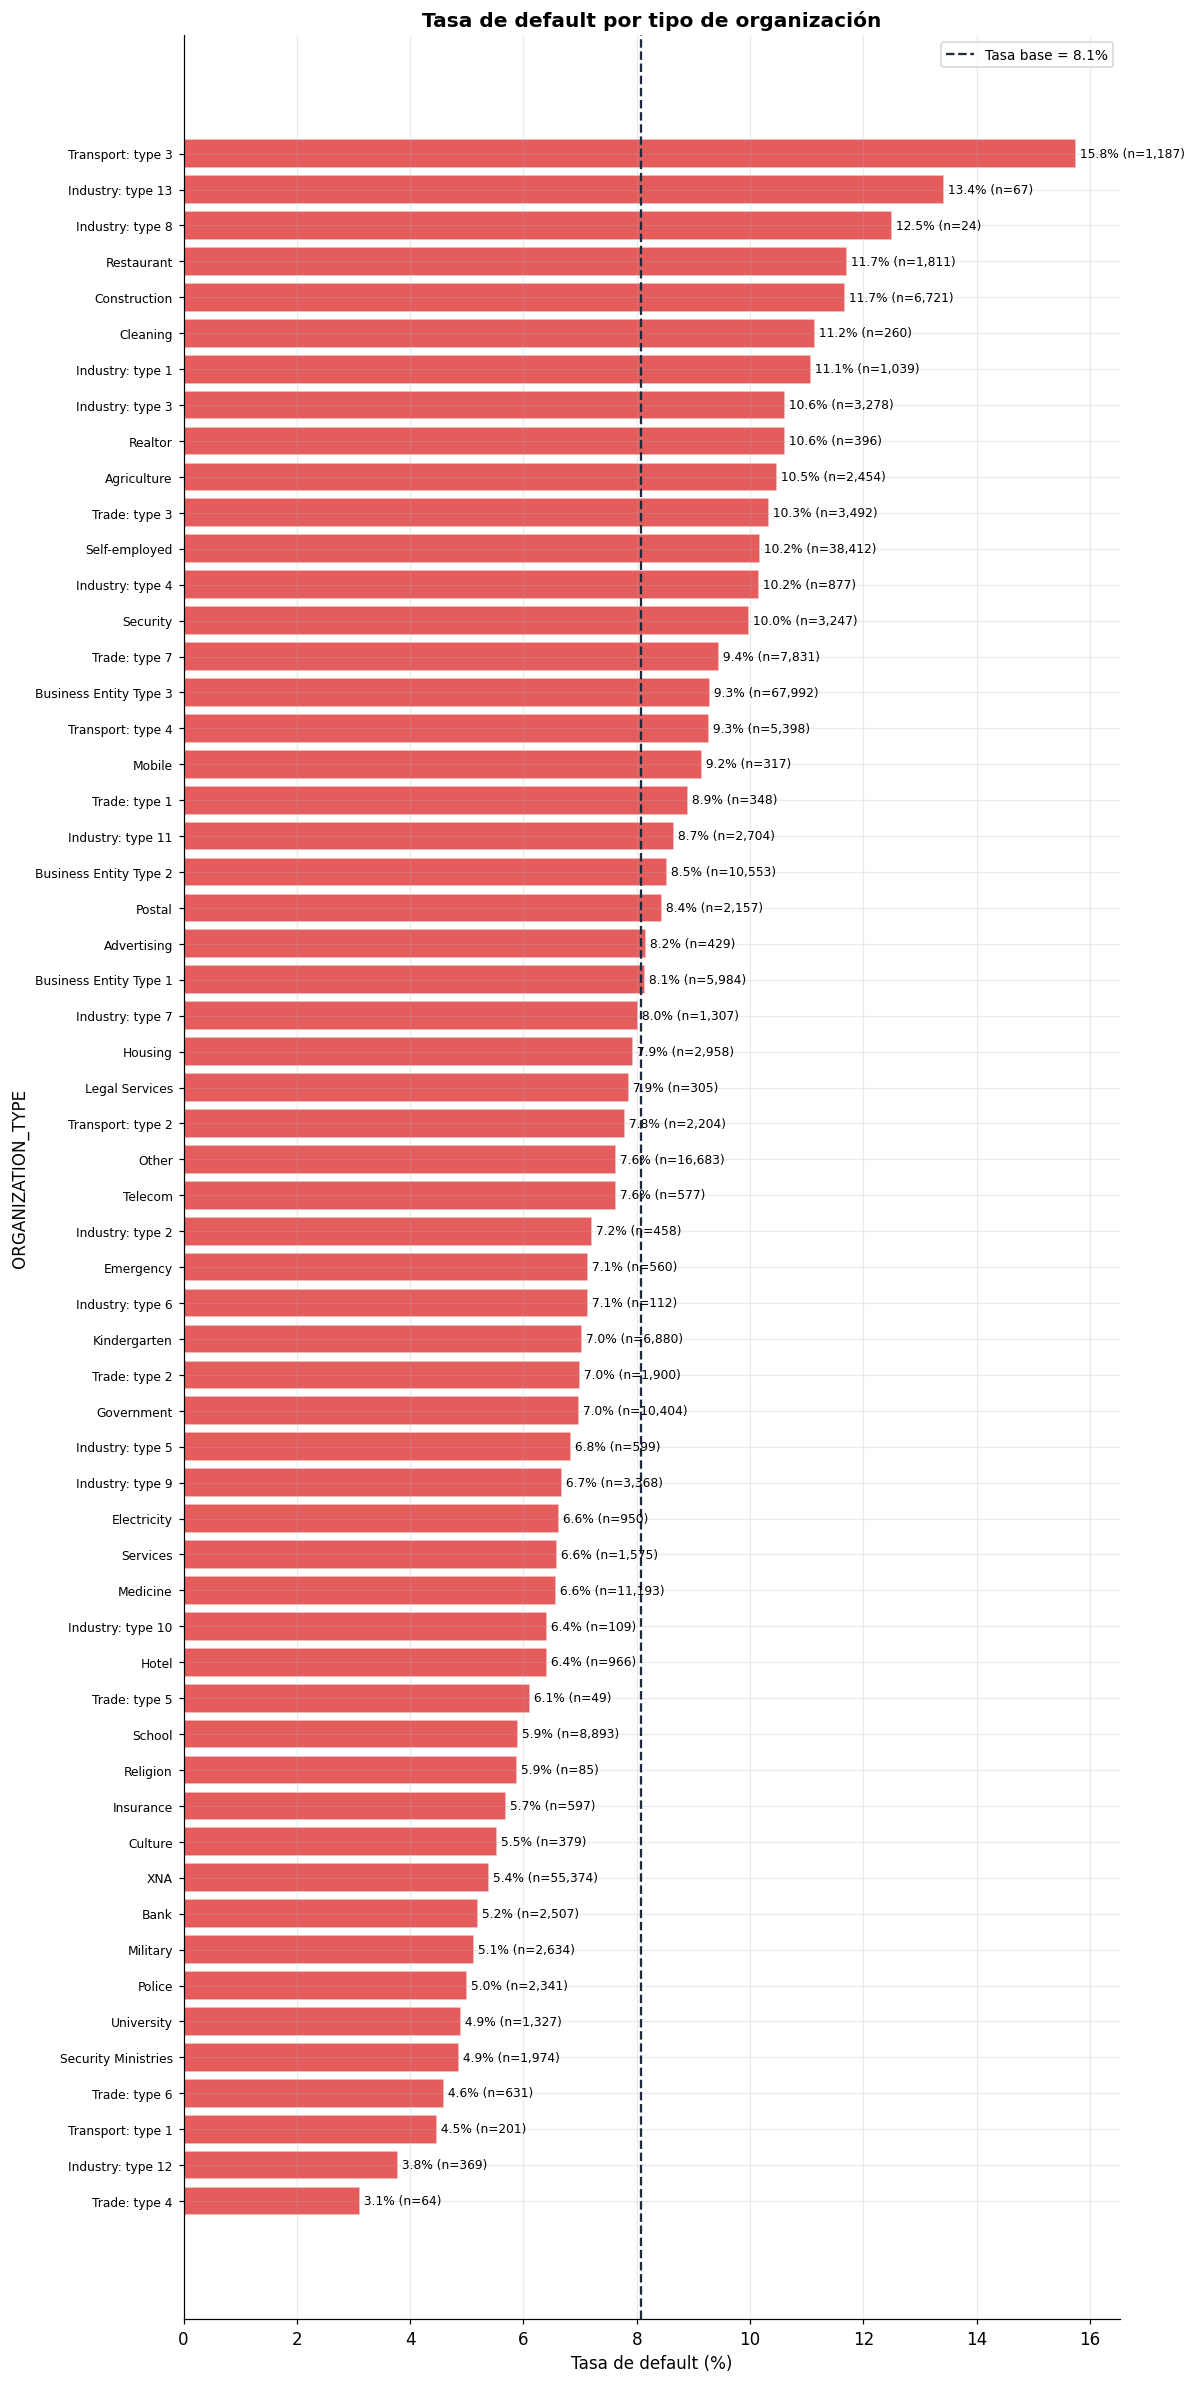


Mayor tasa de default : Transport: type 3 (15.75%, n=1,187)
Menor tasa de default : Trade: type 4 (3.12%, n=64)
Mayor volumen default : Business Entity Type 3 (6,323 casos)


In [88]:
col = 'ORGANIZATION_TYPE'
work = df[[col, 'TARGET']].copy()
work[col] = work[col].fillna('Sin información')

resumen = (
    work.groupby(col, observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reset_index()
)
resumen['clientes_al_dia'] = (
    resumen['total_clientes'] - resumen['clientes_default']
).astype(int)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)
resumen = resumen.sort_values('total_clientes', ascending=False).reset_index(drop=True)

tasa_base = df['TARGET'].mean() * 100
categorias = resumen[col].tolist()

print('Resumen por tipo de organización:')
print(resumen.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')
print(f'Categorías distintas: {len(resumen):,}')

# --- 1) Cantidad de clientes por categoría ---
fig_h = max(5, 0.35 * len(resumen) + 1.5)
fig, ax = plt.subplots(figsize=(11, fig_h))
y = np.arange(len(resumen))
ax.barh(y, resumen['total_clientes'], color=ACCENT, alpha=0.75, edgecolor='white')
for i, row in enumerate(resumen.itertuples()):
    ax.text(row.total_clientes, i, f' {row.total_clientes:,}',
            va='center', ha='left', fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([str(c)[:40] for c in categorias], fontsize=8)
ax.invert_yaxis()
ax.set_title('Cantidad de clientes por tipo de organización')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('ORGANIZATION_TYPE')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

# --- 2) Comparativa al día vs default ---
fig, ax = plt.subplots(figsize=(11, fig_h))
ancho = 0.38
ax.barh(y - ancho / 2, resumen['clientes_al_dia'], height=ancho,
        color=SAFE, alpha=0.8, edgecolor='white', label='Al día (TARGET=0)')
ax.barh(y + ancho / 2, resumen['clientes_default'], height=ancho,
        color=RISK, alpha=0.8, edgecolor='white', label='Default (TARGET=1)')
ax.set_yticks(y)
ax.set_yticklabels([str(c)[:40] for c in categorias], fontsize=8)
ax.invert_yaxis()
ax.set_title('Clientes al día vs default por tipo de organización')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('ORGANIZATION_TYPE')
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
plt.show()

# --- 3) Tasa de default ---
resumen_tasa = resumen.sort_values('tasa_default_pct', ascending=True).reset_index(drop=True)
y2 = np.arange(len(resumen_tasa))
fig_h2 = max(5, 0.35 * len(resumen_tasa) + 1.5)

fig, ax = plt.subplots(figsize=(11, fig_h2))
ax.barh(y2, resumen_tasa['tasa_default_pct'], color=RISK, alpha=0.75, edgecolor='white')
for i, row in enumerate(resumen_tasa.itertuples()):
    ax.text(row.tasa_default_pct, i,
            f' {row.tasa_default_pct:.1f}% (n={row.total_clientes:,})',
            va='center', ha='left', fontsize=8)
ax.axvline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_yticks(y2)
ax.set_yticklabels([str(c)[:40] for c in resumen_tasa[col]], fontsize=8)
ax.set_title('Tasa de default por tipo de organización')
ax.set_xlabel('Tasa de default (%)')
ax.set_ylabel('ORGANIZATION_TYPE')
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

if not resumen.empty:
    r_max = resumen_tasa.iloc[-1]
    r_min = resumen_tasa.iloc[0]
    r_vol = resumen.loc[resumen['clientes_default'].idxmax()]
    print(f'\nMayor tasa de default : {r_max[col]} ({r_max["tasa_default_pct"]:.2f}%, n={r_max["total_clientes"]:,})')
    print(f'Menor tasa de default : {r_min[col]} ({r_min["tasa_default_pct"]:.2f}%, n={r_min["total_clientes"]:,})')
    print(f'Mayor volumen default : {r_vol[col]} ({int(r_vol["clientes_default"]):,} casos)')

## Propiedad inmobiliaria (`FLAG_OWN_REALTY`)

Indica si el cliente **posee bienes raíces** (`Y` = sí, `N` = no). Misma lectura que en organización:

1. **Cantidad de clientes** por categoría.
2. **Comparativa al día vs default** (`TARGET = 0` vs `TARGET = 1`).
3. **Tasa de default** por categoría.

Resumen por FLAG_OWN_REALTY:
FLAG_OWN_REALTY  total_clientes  clientes_default  clientes_al_dia  tasa_default_pct
              Y          213312             16983           196329              7.96
              N           94199              7842            86357              8.32

Tasa base (todo el dataset): 8.07%
Categorías distintas: 2


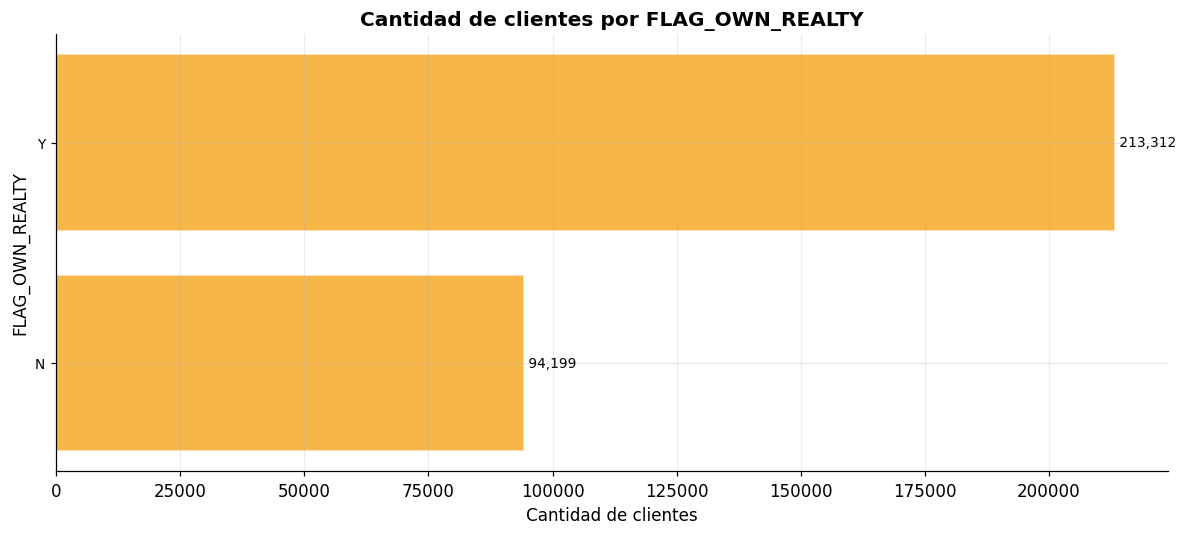

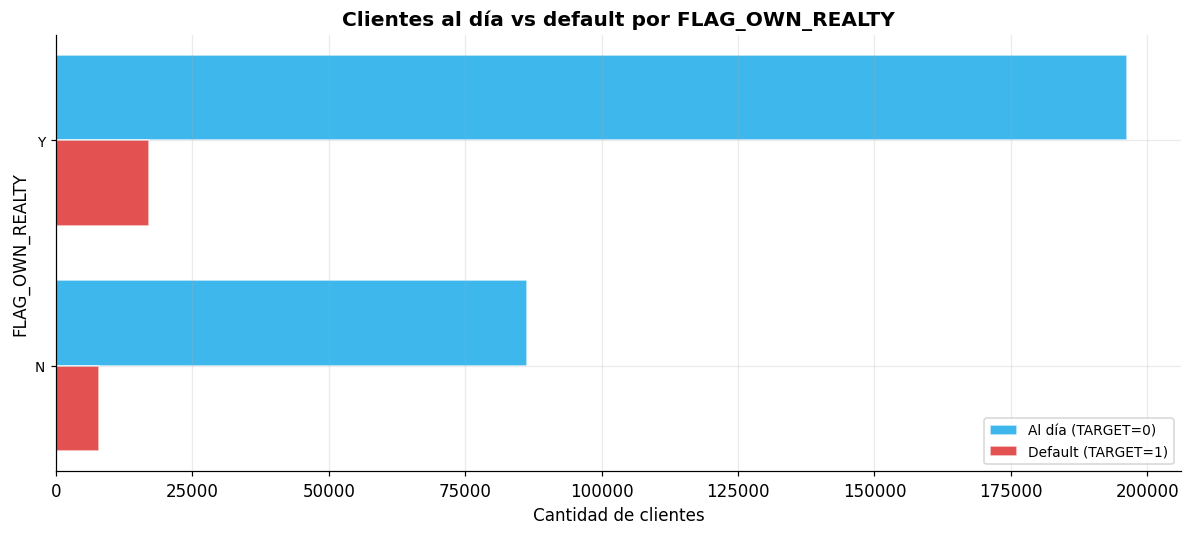

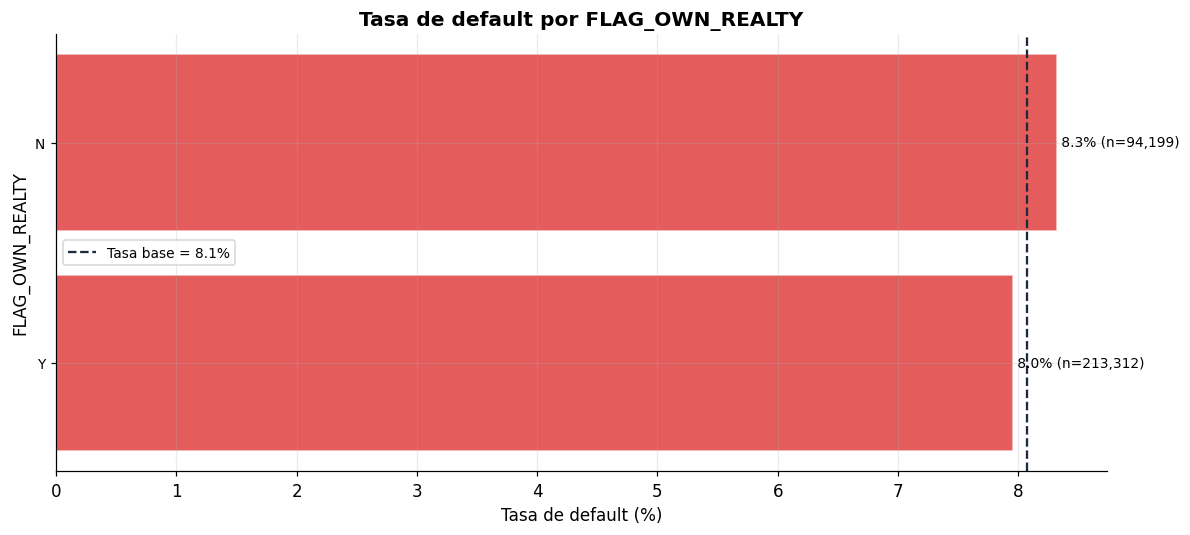


Mayor tasa de default : N (8.32%, n=94,199)
Menor tasa de default : Y (7.96%, n=213,312)
Mayor volumen default : Y (16,983 casos)


In [90]:
col = 'FLAG_OWN_REALTY'
work = df[[col, 'TARGET']].copy()
work[col] = work[col].fillna('Sin información')

resumen = (
    work.groupby(col, observed=False)['TARGET']
    .agg(total_clientes='size', clientes_default='sum')
    .reset_index()
)
resumen['clientes_al_dia'] = (
    resumen['total_clientes'] - resumen['clientes_default']
).astype(int)
resumen['tasa_default_pct'] = (
    resumen['clientes_default'] / resumen['total_clientes'] * 100
).round(2)
resumen = resumen.sort_values('total_clientes', ascending=False).reset_index(drop=True)

tasa_base = df['TARGET'].mean() * 100
categorias = resumen[col].tolist()

print('Resumen por FLAG_OWN_REALTY:')
print(resumen.to_string(index=False))
print(f'\nTasa base (todo el dataset): {tasa_base:.2f}%')
print(f'Categorías distintas: {len(resumen):,}')

# --- 1) Cantidad de clientes por categoría ---
fig_h = max(5, 0.35 * len(resumen) + 1.5)
fig, ax = plt.subplots(figsize=(11, fig_h))
y = np.arange(len(resumen))
ax.barh(y, resumen['total_clientes'], color=ACCENT, alpha=0.75, edgecolor='white')
for i, row in enumerate(resumen.itertuples()):
    ax.text(row.total_clientes, i, f' {row.total_clientes:,}',
            va='center', ha='left', fontsize=9)
ax.set_yticks(y)
ax.set_yticklabels(categorias, fontsize=9)
ax.invert_yaxis()
ax.set_title('Cantidad de clientes por FLAG_OWN_REALTY')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('FLAG_OWN_REALTY')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
plt.show()

# --- 2) Comparativa al día vs default ---
fig, ax = plt.subplots(figsize=(11, fig_h))
ancho = 0.38
ax.barh(y - ancho / 2, resumen['clientes_al_dia'], height=ancho,
        color=SAFE, alpha=0.8, edgecolor='white', label='Al día (TARGET=0)')
ax.barh(y + ancho / 2, resumen['clientes_default'], height=ancho,
        color=RISK, alpha=0.8, edgecolor='white', label='Default (TARGET=1)')
ax.set_yticks(y)
ax.set_yticklabels(categorias, fontsize=9)
ax.invert_yaxis()
ax.set_title('Clientes al día vs default por FLAG_OWN_REALTY')
ax.set_xlabel('Cantidad de clientes')
ax.set_ylabel('FLAG_OWN_REALTY')
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()
plt.show()

# --- 3) Tasa de default ---
resumen_tasa = resumen.sort_values('tasa_default_pct', ascending=True).reset_index(drop=True)
y2 = np.arange(len(resumen_tasa))
fig_h2 = max(5, 0.35 * len(resumen_tasa) + 1.5)

fig, ax = plt.subplots(figsize=(11, fig_h2))
ax.barh(y2, resumen_tasa['tasa_default_pct'], color=RISK, alpha=0.75, edgecolor='white')
for i, row in enumerate(resumen_tasa.itertuples()):
    ax.text(row.tasa_default_pct, i,
            f' {row.tasa_default_pct:.1f}% (n={row.total_clientes:,})',
            va='center', ha='left', fontsize=9)
ax.axvline(tasa_base, color=INK, linestyle='--', linewidth=1.5,
           label=f'Tasa base = {tasa_base:.1f}%')
ax.set_yticks(y2)
ax.set_yticklabels(resumen_tasa[col].tolist(), fontsize=9)
ax.set_title('Tasa de default por FLAG_OWN_REALTY')
ax.set_xlabel('Tasa de default (%)')
ax.set_ylabel('FLAG_OWN_REALTY')
ax.grid(axis='x', alpha=0.25)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

if not resumen.empty:
    r_max = resumen_tasa.iloc[-1]
    r_min = resumen_tasa.iloc[0]
    r_vol = resumen.loc[resumen['clientes_default'].idxmax()]
    print(f'\nMayor tasa de default : {r_max[col]} ({r_max["tasa_default_pct"]:.2f}%, n={r_max["total_clientes"]:,})')
    print(f'Menor tasa de default : {r_min[col]} ({r_min["tasa_default_pct"]:.2f}%, n={r_min["total_clientes"]:,})')
    print(f'Mayor volumen default : {r_vol[col]} ({int(r_vol["clientes_default"]):,} casos)')

# Boxplots comparativos TARGET 0 vs 1

Cierre visual: comparación y outliers (IQR) de las variables numéricas continuas estudiadas en los bloques anteriores.

## Boxplots: comparación TARGET = 0 vs TARGET = 1

Variables **numéricas continuas** ya estudiadas en secciones anteriores (distribución / deciles). Se excluyen identificadores, texto, categóricas, binarias, one-hot y `TARGET`.

Outliers con criterio IQR: `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` (no se eliminan del gráfico ni del dataset).


C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


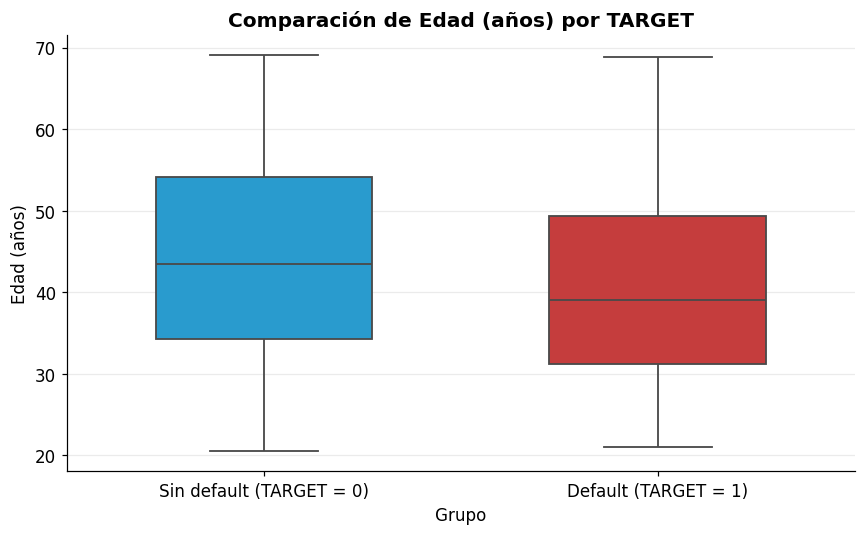

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


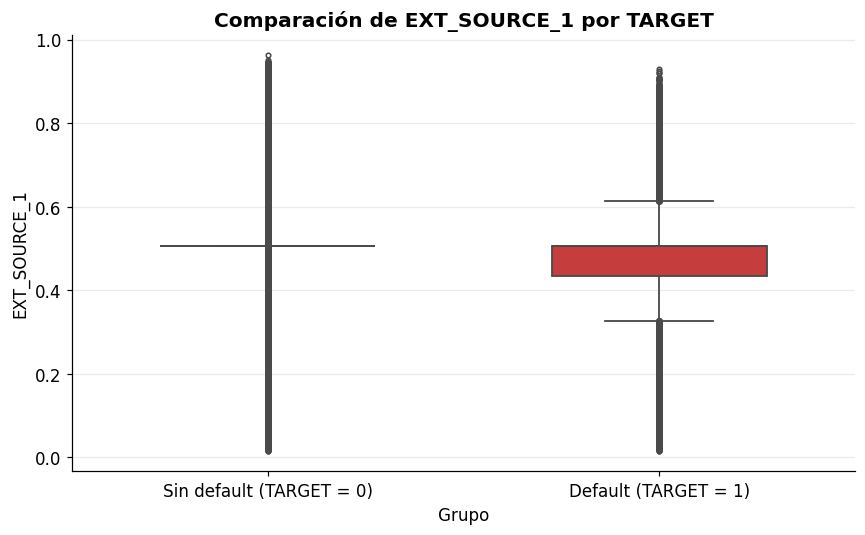

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


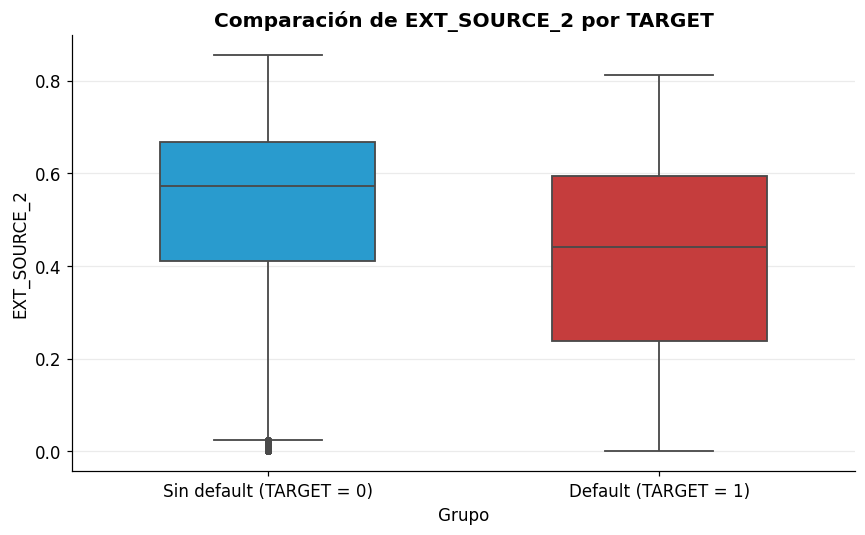

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


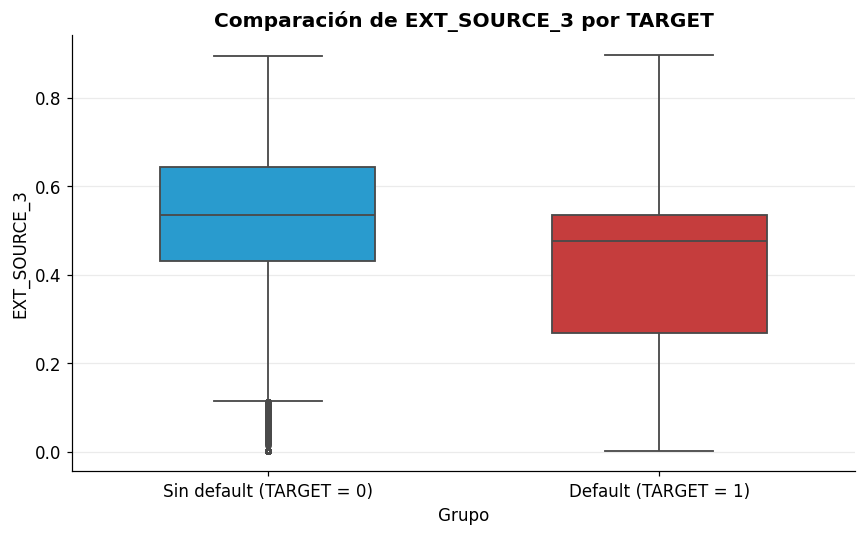

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


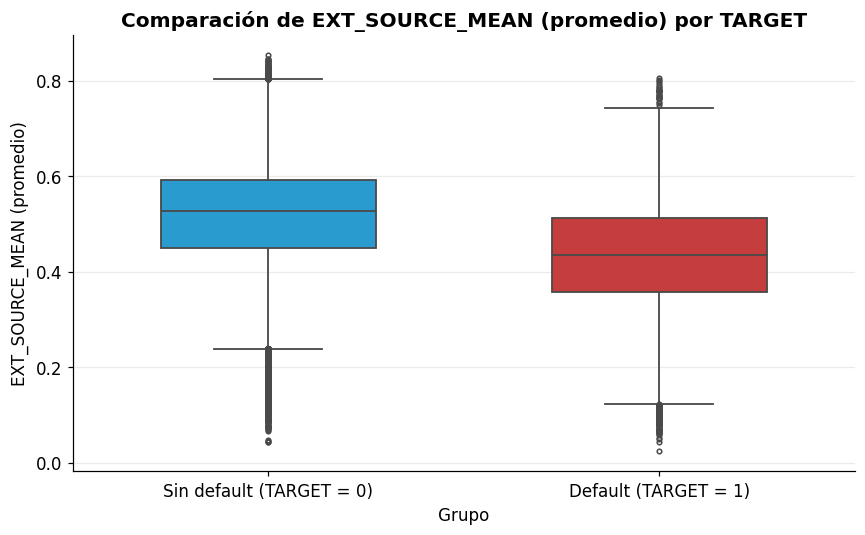

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


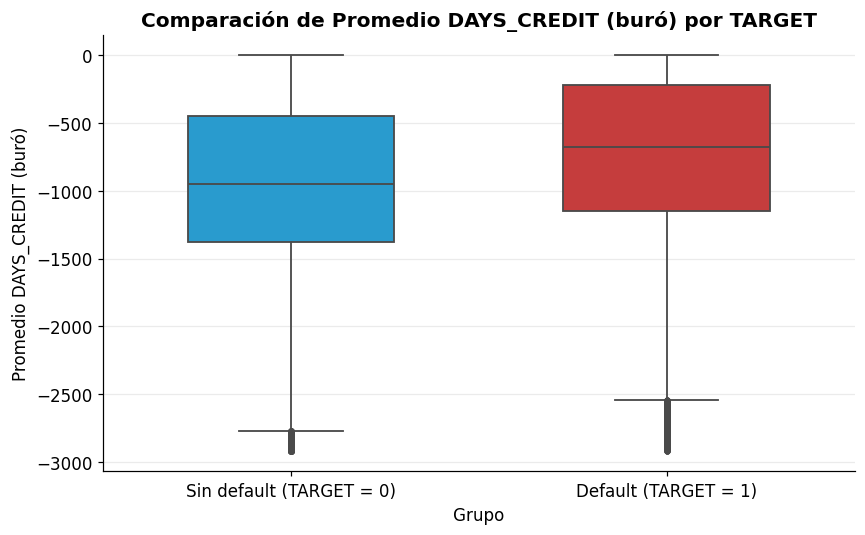

[AVISO] bureau_avg_days_update no está en df; se omite.


C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


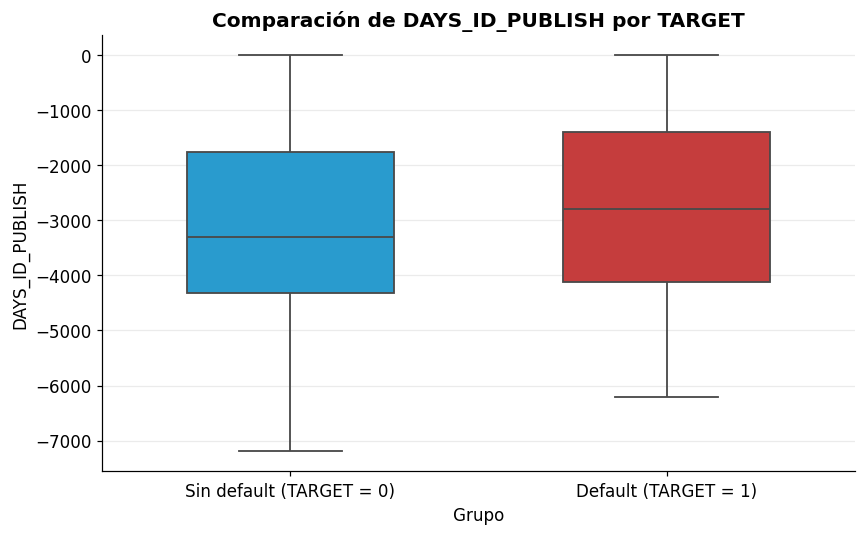

C:\Users\camil\AppData\Local\Temp\ipykernel_19068\2544507874.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


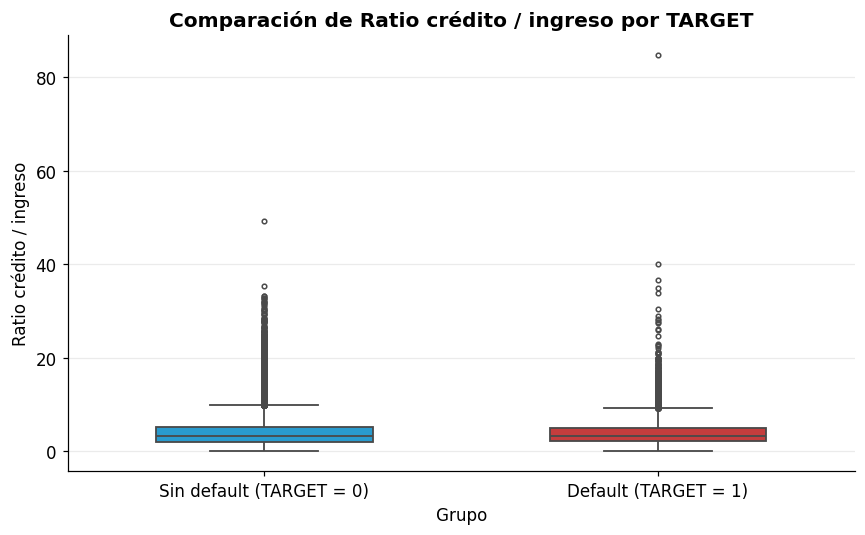


Resumen de outliers (criterio IQR) por variable y grupo:
              variable                    grupo      n  n_outliers  pct_outliers         q1         q3       iqr  limite_inferior  limite_superior
             AGE_YEARS Sin default (TARGET = 0) 282686           0          0.00    34.3217    54.1923   19.8706           4.5157          83.9983
             AGE_YEARS     Default (TARGET = 1)  24825           0          0.00    31.2005    49.3826   18.1821           3.9274          76.6557
          EXT_SOURCE_1 Sin default (TARGET = 0) 282686      124077         43.89     0.5060     0.5060    0.0000           0.5060           0.5060
          EXT_SOURCE_1     Default (TARGET = 1)  24825        6125         24.67     0.4347     0.5060    0.0713           0.3278           0.6129
          EXT_SOURCE_2 Sin default (TARGET = 0) 282686        1853          0.66     0.4103     0.6675    0.2572           0.0246           1.0533
          EXT_SOURCE_2     Default (TARGET = 1)  24825      

In [36]:
import seaborn as sns

# Variables continuas con análisis previo en este notebook (histogramas / deciles / rangos).
VARS_BOXPLOT = [
    ('AGE_YEARS', 'Edad (años)'),
    ('EXT_SOURCE_1', 'EXT_SOURCE_1'),
    ('EXT_SOURCE_2', 'EXT_SOURCE_2'),
    ('EXT_SOURCE_3', 'EXT_SOURCE_3'),
    ('EXT_SOURCE_MEAN', 'EXT_SOURCE_MEAN (promedio)'),
    ('bureau_avg_days_credit', 'Promedio DAYS_CREDIT (buró)'),
    ('bureau_avg_days_update', 'Promedio DAYS_CREDIT_UPDATE (buró)'),
    ('DAYS_ID_PUBLISH', 'DAYS_ID_PUBLISH'),
    ('CREDIT_INCOME_RATIO', 'Ratio crédito / ingreso'),
]

ETIQUETAS_TARGET = {
    0: 'Sin default (TARGET = 0)',
    1: 'Default (TARGET = 1)',
}
ORDEN_GRUPOS = [ETIQUETAS_TARGET[0], ETIQUETAS_TARGET[1]]
COLORES_GRUPOS = [SAFE, RISK]


def contar_outliers_iqr(serie: pd.Series) -> dict:
    """Outliers por criterio IQR sobre una serie numérica (sin NaN)."""
    s = pd.to_numeric(serie, errors='coerce').dropna()
    if s.empty:
        return {
            'n': 0, 'n_outliers': 0, 'pct_outliers': 0.0,
            'q1': np.nan, 'q3': np.nan, 'iqr': np.nan,
            'limite_inferior': np.nan, 'limite_superior': np.nan,
        }
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = int(((s < lim_inf) | (s > lim_sup)).sum())
    return {
        'n': len(s),
        'n_outliers': n_out,
        'pct_outliers': round(n_out / len(s) * 100, 2),
        'q1': round(float(q1), 4),
        'q3': round(float(q3), 4),
        'iqr': round(float(iqr), 4),
        'limite_inferior': round(float(lim_inf), 4),
        'limite_superior': round(float(lim_sup), 4),
    }


filas_outliers = []

for var, etiqueta in VARS_BOXPLOT:
    if var not in df.columns:
        print(f'[AVISO] {var} no está en df; se omite.')
        continue

    nulos = int(df[var].isna().sum())
    pct_nulos = nulos / len(df) * 100
    if pct_nulos > 30:
        print(f'[AVISO] {var}: {nulos:,} nulos ({pct_nulos:.1f}%) — boxplot solo con valores observados.')

    plot_df = df[[var, 'TARGET']].copy()
    plot_df[var] = pd.to_numeric(plot_df[var], errors='coerce')
    plot_df = plot_df.dropna(subset=[var])
    plot_df = plot_df[plot_df['TARGET'].isin([0, 1])].copy()
    plot_df['grupo'] = plot_df['TARGET'].map(ETIQUETAS_TARGET)

    if plot_df.empty:
        print(f'[AVISO] {var}: sin datos válidos; se omite.')
        continue

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.boxplot(
        data=plot_df,
        x='grupo',
        y=var,
        order=ORDEN_GRUPOS,
        palette=COLORES_GRUPOS,
        width=0.55,
        linewidth=1.2,
        fliersize=3,
        ax=ax,
    )
    ax.set_title(f'Comparación de {etiqueta} por TARGET')
    ax.set_xlabel('Grupo')
    ax.set_ylabel(etiqueta)
    ax.grid(True, alpha=0.25, axis='y')
    fig.tight_layout()
    plt.show()

    for target_val in [0, 1]:
        sub = plot_df.loc[plot_df['TARGET'] == target_val, var]
        stats = contar_outliers_iqr(sub)
        filas_outliers.append({
            'variable': var,
            'grupo': ETIQUETAS_TARGET[target_val],
            **stats,
        })

tabla_outliers = pd.DataFrame(filas_outliers)
if not tabla_outliers.empty:
    print('\nResumen de outliers (criterio IQR) por variable y grupo:')
    print(
        tabla_outliers[
            ['variable', 'grupo', 'n', 'n_outliers', 'pct_outliers',
             'q1', 'q3', 'iqr', 'limite_inferior', 'limite_superior']
        ].to_string(index=False)
    )

    print('\nVariables con mayor % de outliers en default (TARGET = 1):')
    top_def = (
        tabla_outliers[tabla_outliers['grupo'] == ETIQUETAS_TARGET[1]]
        .sort_values('pct_outliers', ascending=False)
        .head(5)
    )
    print(top_def[['variable', 'n_outliers', 'pct_outliers']].to_string(index=False))
else:
    print('No se generó tabla de outliers (ninguna variable disponible).')
